## The Dataset

In [ ]:
# import matplotlib.pyplot as plt
# import matplotlib.cm as cm
# import tensorflow as tf
# import numpy as np
# %matplotlib inline

# training_files = ["dichasus/dichasus-0152.tfrecords", "dichasus/dichasus-0153.tfrecords"]
# test_files = ["dichasus/dichasus-0154.tfrecords"]

# def record_parse_function(proto):
# 	record = tf.io.parse_single_example(proto, {
# 		"csi": tf.io.FixedLenFeature([], tf.string, default_value = ''),
# 		"pos-tachy": tf.io.FixedLenFeature([], tf.string, default_value = '')
# 	})
# 	csi = tf.ensure_shape(tf.io.parse_tensor(record["csi"], out_type = tf.float32), (32, 1024, 2))
# 	pos_tachy = tf.ensure_shape(tf.io.parse_tensor(record["pos-tachy"], out_type = tf.float64), (3))

# 	# We only care about x/y position dimensions, z is always close to 0
# 	return csi, pos_tachy[:2]

# training_set = tf.data.TFRecordDataset(training_files).map(record_parse_function)
# test_set = tf.data.TFRecordDataset(test_files).map(record_parse_function)

### Positioning "Ground Truth" Information

In [ ]:
# positions = [] # Test Data
# for datapoint in test_set:
# 	positions.append(datapoint[1].numpy())
# positions = np.vstack(positions)

# plt.figure(figsize=(5, 6))
# plt.scatter(positions[:, 0], positions[:, 1])
# plt.axis("equal")
# plt.xlabel("x coordinate [m]")
# plt.ylabel("y coordinate [m]")
# plt.show()

In [ ]:
# train_0152 = tf.data.TFRecordDataset(
#     ["dichasus/dichasus-0152.tfrecords"]
# ).map(record_parse_function)

# positions_0152 = []

# for datapoint in train_0152:
#     positions_0152.append(datapoint[1].numpy())

# positions_0152 = np.vstack(positions_0152)

# plt.figure(figsize=(5, 6))

# plt.scatter(
#     positions_0152[:, 0],
#     positions_0152[:, 1],
#     s=3
# )

# plt.axis("equal")

# plt.xlabel("x coordinate [m]")
# plt.ylabel("y coordinate [m]")

# plt.title("Training Run 0152")

# plt.show()

## Channel Coefficients

In [ ]:
# csi_tensor = next(iter(test_set.shuffle(1000).take(1)))[0]

# plt.figure(figsize = (10, 7))
# plt.subplot(211)
# plt.title("Channel State Information: Channel Coefficients")
# plt.xlabel("Subcarrier $i$")
# plt.ylabel("Referenced channel coeff.,\n abs. value $|h_i|_{dB}$ [dB]")
# for antenna_csi in tf.unstack(csi_tensor):
# 	plt.plot(10 * np.log10(np.abs(np.fft.fftshift(antenna_csi[:,0]**2 + antenna_csi[:,1]**2))))

# plt.subplot(212)
# plt.xlabel("Subcarrier $i$")
# plt.ylabel("Referenced channel coeff.,\nphase shift $arg(h_i)$")
# for antenna_csi in tf.unstack(csi_tensor):
# 	plt.plot(np.unwrap(np.fft.fftshift(np.arctan2(antenna_csi[:,1], antenna_csi[:,0]))))

# plt.show()

## Feature Engineering and Input Normalization

In [ ]:
# def get_feature_mapping(chunksize = 32): ######
# 	def compute_features(csi, pos_tachy):
# 		assert(csi.shape[1] % chunksize == 0)
# 		featurecount = csi.shape[1] // chunksize
# 		csi_averaged = tf.stack([tf.math.reduce_mean(csi[:, (chunksize * s):(chunksize * (s + 1)), :], axis = 1) for s in range(featurecount)], axis = 1)
# 		return csi_averaged, pos_tachy

# 	return compute_features

# training_set_features = training_set.map(get_feature_mapping(32))
# test_set_features = test_set.map(get_feature_mapping(32))

# training_set_features = training_set_features.shuffle(buffer_size = 100000)
# test_set_features = test_set_features.shuffle(buffer_size = 100000)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os

LOCAL_DICHASUS_DIR = "/content/drive/MyDrive/dichasus"

print("Dataset folder:")
print(LOCAL_DICHASUS_DIR)

print("\nFolder exists?")
print(os.path.exists(LOCAL_DICHASUS_DIR))

if not os.path.exists(LOCAL_DICHASUS_DIR):
    raise FileNotFoundError(
        "Dataset folder was not found. Please make sure the dichasus folder exists in MyDrive."
    )

In [ ]:
# # Download required DICHASUS 015x files into Google Drive

# !wget --content-disposition "https://darus.uni-stuttgart.de/api/access/datafile/:persistentId?persistentId=doi:10.18419/darus-2202/2" -P "/content/drive/MyDrive/dichasus"  # dichasus-0152
# !wget --content-disposition "https://darus.uni-stuttgart.de/api/access/datafile/:persistentId?persistentId=doi:10.18419/darus-2202/3" -P "/content/drive/MyDrive/dichasus"  # dichasus-0153
# !wget --content-disposition "https://darus.uni-stuttgart.de/api/access/datafile/:persistentId?persistentId=doi:10.18419/darus-2202/4" -P "/content/drive/MyDrive/dichasus"  # dichasus-0154
# !wget --content-disposition "https://darus.uni-stuttgart.de/api/access/datafile/:persistentId?persistentId=doi:10.18419/darus-2202/5" -P "/content/drive/MyDrive/dichasus"  # dichasus-0155
# !wget --content-disposition "https://darus.uni-stuttgart.de/api/access/datafile/:persistentId?persistentId=doi:10.18419/darus-2202/6" -P "/content/drive/MyDrive/dichasus"  # dichasus-0157

In [ ]:
import os

LOCAL_DICHASUS_DIR = "/content/drive/MyDrive/dichasus"

required_files = [
    "dichasus-0152.tfrecords",
    "dichasus-0153.tfrecords",
    "dichasus-0154.tfrecords",
    "dichasus-0155.tfrecords",
    "dichasus-0157.tfrecords",
]

print("Dataset check")
print("-" * 50)

for filename in required_files:
    path = os.path.join(LOCAL_DICHASUS_DIR, filename)

    if os.path.exists(path):
        size_gb = os.path.getsize(path) / (1024 ** 3)
        print(f"{filename}: OK | {size_gb:.2f} GB")
    else:
        raise FileNotFoundError(
            f"Missing dataset file: {filename}"
        )

In [ ]:
import os

required_files = [
    "dichasus-0152.tfrecords",
    "dichasus-0153.tfrecords",
    "dichasus-0154.tfrecords",
    "dichasus-0155.tfrecords",
    "dichasus-0157.tfrecords",
]

print("Dataset folder:")
print(LOCAL_DICHASUS_DIR)

print("\nFiles check:")
for filename in required_files:
    path = os.path.join(LOCAL_DICHASUS_DIR, filename)

    if os.path.exists(path):
        size_gb = os.path.getsize(path) / (1024 ** 3)
        print(f"{filename}: OK | {size_gb:.2f} GB")
    else:
        print(f"{filename}: MISSING")

In [ ]:
# # ============================================================
# # Imports, final split, and TFRecord loading with Mag + Phase
# # ============================================================

# import os
# import json
# import numpy as np
# import pandas as pd
# import tensorflow as tf
# import matplotlib.pyplot as plt
# import matplotlib.cm as cm

# %matplotlib inline

# # ------------------------------------------------------------
# # Global settings
# # ------------------------------------------------------------

# LOCAL_DICHASUS_DIR = "/content/drive/MyDrive/dichasus"

# training_files = [
#     f"{LOCAL_DICHASUS_DIR}/dichasus-0152.tfrecords",
#     f"{LOCAL_DICHASUS_DIR}/dichasus-0153.tfrecords",
#     f"{LOCAL_DICHASUS_DIR}/dichasus-0155.tfrecords"
# ]

# validation_files = [
#     f"{LOCAL_DICHASUS_DIR}/dichasus-0157.tfrecords"
# ]

# test_files = [
#     f"{LOCAL_DICHASUS_DIR}/dichasus-0154.tfrecords"
# ]

# CHUNKSIZE = 32
# HORIZON = 1
# BATCH_SIZE = 64
# EPOCHS = 150
# SEED = 42

# np.random.seed(SEED)
# tf.random.set_seed(SEED)

# print("Training files:", training_files)
# print("Validation files:", validation_files)
# print("Test files:", test_files)

# print("CHUNKSIZE:", CHUNKSIZE)
# print("HORIZON:", HORIZON)
# print("BATCH_SIZE:", BATCH_SIZE)
# print("EPOCHS:", EPOCHS)
# print("SEED:", SEED)


# # ------------------------------------------------------------
# # Parse TFRecord with timestamp
# # ------------------------------------------------------------

# def record_parse_function_with_time(proto):
#     feature_description = {
#         "csi": tf.io.FixedLenFeature([], tf.string, default_value=""),
#         "pos-tachy": tf.io.FixedLenFeature([], tf.string, default_value=""),
#         "time": tf.io.FixedLenFeature([], tf.float32, default_value=0.0),
#     }

#     record = tf.io.parse_single_example(proto, feature_description)

#     csi = tf.ensure_shape(
#         tf.io.parse_tensor(record["csi"], out_type=tf.float32),
#         (32, 1024, 2)
#     )

#     pos_tachy = tf.ensure_shape(
#         tf.io.parse_tensor(record["pos-tachy"], out_type=tf.float64),
#         (3,)
#     )

#     pos_xy = tf.cast(pos_tachy[:2], tf.float32)
#     time = tf.ensure_shape(record["time"], ())

#     return csi, pos_xy, time


# # ------------------------------------------------------------
# # Average subcarriers and convert Real/Imag to Magnitude/Phase
# # ------------------------------------------------------------

# def average_csi_subcarriers(csi, chunksize=32):
#     featurecount = csi.shape[1] // chunksize

#     csi_averaged = tf.stack([
#         tf.reduce_mean(
#             csi[:, chunksize * s:chunksize * (s + 1), :],
#             axis=1
#         )
#         for s in range(featurecount)
#     ], axis=1)

#     real = csi_averaged[..., 0]
#     imag = csi_averaged[..., 1]

#     magnitude = tf.sqrt(tf.square(real) + tf.square(imag))
#     phase = tf.atan2(imag, real)

#     csi_mag_phase = tf.stack([magnitude, phase], axis=-1)

#     return csi_mag_phase


# # ------------------------------------------------------------
# # Load one file in timestamp order
# # ------------------------------------------------------------

# def load_one_file_ordered(file_path, chunksize=32):
#     raw_dataset = tf.data.TFRecordDataset([file_path])
#     dataset = raw_dataset.map(record_parse_function_with_time)

#     csi_list = []
#     pos_list = []
#     time_list = []

#     for csi, pos_xy, time in dataset:
#         csi_avg = average_csi_subcarriers(
#             csi,
#             chunksize=chunksize
#         )

#         csi_list.append(csi_avg.numpy())
#         pos_list.append(pos_xy.numpy())
#         time_list.append(time.numpy())

#     X_csi = np.asarray(csi_list, dtype=np.float32)
#     pos = np.asarray(pos_list, dtype=np.float32)
#     time = np.asarray(time_list, dtype=np.float32)

#     order = np.argsort(time)

#     X_csi = X_csi[order]
#     pos = pos[order]
#     time = time[order]

#     return X_csi, pos, time


# # ------------------------------------------------------------
# # Load multiple files separately
# # ------------------------------------------------------------

# def load_multiple_files_separately(file_paths, chunksize=32):
#     runs = []

#     for file_path in file_paths:
#         print(f"Loading: {file_path}")

#         X_csi, pos, time = load_one_file_ordered(
#             file_path,
#             chunksize=chunksize
#         )

#         print("  X_csi:", X_csi.shape, "pos:", pos.shape, "time:", time.shape)

#         runs.append({
#             "file": file_path,
#             "X_csi": X_csi,
#             "pos": pos,
#             "time": time
#         })

#     return runs


# # ------------------------------------------------------------
# # Load train, validation, and test runs
# # ------------------------------------------------------------

# train_runs = load_multiple_files_separately(
#     training_files,
#     chunksize=CHUNKSIZE
# )

# val_runs = load_multiple_files_separately(
#     validation_files,
#     chunksize=CHUNKSIZE
# )

# test_runs = load_multiple_files_separately(
#     test_files,
#     chunksize=CHUNKSIZE
# )

In [ ]:
# import os
# import numpy as np

# CACHE_DIR = "/content/drive/MyDrive/dichasus_cache"
# os.makedirs(CACHE_DIR, exist_ok=True)

# def save_runs_to_npz(runs, output_path):
#     data = {}

#     for i, run in enumerate(runs):
#         data[f"file_{i}"] = run["file"]
#         data[f"X_csi_{i}"] = run["X_csi"]
#         data[f"pos_{i}"] = run["pos"]
#         data[f"time_{i}"] = run["time"]

#     data["num_runs"] = len(runs)

#     np.savez_compressed(output_path, **data)

#     print("Saved:", output_path)


# save_runs_to_npz(
#     train_runs,
#     os.path.join(CACHE_DIR, "train_runs_mag_phase.npz")
# )

# save_runs_to_npz(
#     val_runs,
#     os.path.join(CACHE_DIR, "val_runs_mag_phase.npz")
# )

# save_runs_to_npz(
#     test_runs,
#     os.path.join(CACHE_DIR, "test_runs_mag_phase.npz")
# )

In [ ]:
# ============================================================
# Load cached runs instead of reloading TFRecords
# ============================================================

import os
import numpy as np

CACHE_DIR = "/content/drive/MyDrive/dichasus_cache"

def load_runs_from_npz(input_path):
    loaded = np.load(input_path, allow_pickle=True)

    runs = []
    num_runs = int(loaded["num_runs"])

    for i in range(num_runs):
        runs.append({
            "file": str(loaded[f"file_{i}"]),
            "X_csi": loaded[f"X_csi_{i}"].astype(np.float32),
            "pos": loaded[f"pos_{i}"].astype(np.float32),
            "time": loaded[f"time_{i}"].astype(np.float32),
        })

    print("Loaded:", input_path)

    for r in runs:
        print(
            r["file"],
            "X_csi:", r["X_csi"].shape,
            "pos:", r["pos"].shape,
            "time:", r["time"].shape
        )

    return runs


train_runs = load_runs_from_npz(
    os.path.join(CACHE_DIR, "train_runs_mag_phase.npz")
)

val_runs = load_runs_from_npz(
    os.path.join(CACHE_DIR, "val_runs_mag_phase.npz")
)

test_runs = load_runs_from_npz(
    os.path.join(CACHE_DIR, "test_runs_mag_phase.npz")
)

Loaded: /content/drive/MyDrive/dichasus_cache/train_runs_mag_phase.npz
/content/drive/MyDrive/dichasus/dichasus-0152.tfrecords X_csi: (13496, 32, 32, 2) pos: (13496, 2) time: (13496,)
/content/drive/MyDrive/dichasus/dichasus-0153.tfrecords X_csi: (14297, 32, 32, 2) pos: (14297, 2) time: (14297,)
/content/drive/MyDrive/dichasus/dichasus-0155.tfrecords X_csi: (16137, 32, 32, 2) pos: (16137, 2) time: (16137,)
Loaded: /content/drive/MyDrive/dichasus_cache/val_runs_mag_phase.npz
/content/drive/MyDrive/dichasus/dichasus-0157.tfrecords X_csi: (14511, 32, 32, 2) pos: (14511, 2) time: (14511,)
Loaded: /content/drive/MyDrive/dichasus_cache/test_runs_mag_phase.npz
/content/drive/MyDrive/dichasus/dichasus-0154.tfrecords X_csi: (15233, 32, 32, 2) pos: (15233, 2) time: (15233,)


In [ ]:
# ============================================================
# Prepare data for Integrated Gradients
# ============================================================

import numpy as np

X_train_ig = np.concatenate(
    [run["X_csi"] for run in train_runs],
    axis=0
)

y_train_ig = np.concatenate(
    [run["pos"] for run in train_runs],
    axis=0
)

X_val_ig = np.concatenate(
    [run["X_csi"] for run in val_runs],
    axis=0
)

y_val_ig = np.concatenate(
    [run["pos"] for run in val_runs],
    axis=0
)

print("X_train_ig:", X_train_ig.shape)
print("y_train_ig:", y_train_ig.shape)

print("X_val_ig:", X_val_ig.shape)
print("y_val_ig:", y_val_ig.shape)

X_train_ig: (43930, 32, 32, 2)
y_train_ig: (43930, 2)
X_val_ig: (14511, 32, 32, 2)
y_val_ig: (14511, 2)


## Neural Network Architecture

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

In [ ]:
nn_input = tf.keras.Input(shape=(32,32,2), name="input")

nn_output = tf.keras.layers.Flatten()(nn_input)
nn_output = tf.keras.layers.Dense(units=512, activation="relu")(nn_output)
nn_output = tf.keras.layers.Dense(units=128, activation="relu")(nn_output)
nn_output = tf.keras.layers.Dense(units=128, activation="relu")(nn_output)
nn_output = tf.keras.layers.Dense(units=2, activation="linear", name="output")(nn_output)

nn = tf.keras.Model(inputs=nn_input, outputs=nn_output, name="localization")

## Training and Validation

In [ ]:
nn.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.MeanSquaredError()
)

history_nn = nn.fit(
    X_train_ig,
    y_train_ig,
    validation_data=(X_val_ig, y_val_ig),
    epochs=20,
    batch_size=64,
    verbose=1
)

nn.save("localization_model.keras")

Epoch 1/20
687/687 ━━━━━━━━━━━━━━━━━━━━ 19s 25ms/step - loss: 0.8104 - val_loss: 0.2929
Epoch 2/20
687/687 ━━━━━━━━━━━━━━━━━━━━ 14s 21ms/step - loss: 0.1983 - val_loss: 0.2442
Epoch 3/20
687/687 ━━━━━━━━━━━━━━━━━━━━ 14s 21ms/step - loss: 0.1429 - val_loss: 0.1744
Epoch 4/20
687/687 ━━━━━━━━━━━━━━━━━━━━ 21s 22ms/step - loss: 0.1085 - val_loss: 0.1697
Epoch 5/20
687/687 ━━━━━━━━━━━━━━━━━━━━ 14s 21ms/step - loss: 0.1026 - val_loss: 0.1550
Epoch 6/20
687/687 ━━━━━━━━━━━━━━━━━━━━ 14s 21ms/step - loss: 0.1059 - val_loss: 0.1385
Epoch 7/20
687/687 ━━━━━━━━━━━━━━━━━━━━ 14s 21ms/step - loss: 0.1049 - val_loss: 0.1425
Epoch 8/20
687/687 ━━━━━━━━━━━━━━━━━━━━ 14s 21ms/step - loss: 0.0890 - val_loss: 0.1287
Epoch 9/20
687/687 ━━━━━━━━━━━━━━━━━━━━ 14s 21ms/step - loss: 0.0806 - val_loss: 0.1245
Epoch 10/20
687/687 ━━━━━━━━━━━━━━━━━━━━ 14s 21ms/step - loss: 0.0831 - val_loss: 0.1105
Epoch 11/20
687/687 ━━━━━━━━━━━━━━━━━━━━ 20s 21ms/step - loss: 0.0824 - val_loss: 0.1309
Epoch 12/20
687/687 ━━━━━━━━━━

In [ ]:
# Save trained model
nn.save("localization_model.keras")

NameError: name 'nn' is not defined

In [ ]:
#nn = tf.keras.models.load_model("localization_model.keras")

In [ ]:
# ------------------------------------------------------------
# Compute mean baseline from training CSI only
# ------------------------------------------------------------

import numpy as np

def compute_mean_baseline_from_runs(runs):
    all_csi = np.concatenate(
        [r["X_csi"] for r in runs],
        axis=0
    )

    baseline = np.mean(
        all_csi,
        axis=0,
        keepdims=True
    ).astype(np.float32)

    return baseline


mean_baseline = compute_mean_baseline_from_runs(train_runs)

print("Mean baseline shape:", mean_baseline.shape)

Mean baseline shape: (1, 32, 32, 2)


In [ ]:
# ============================================================
# IG function definitions only
# ============================================================

import numpy as np
import tensorflow as tf

def antenna_importance_from_attribution(attr):
    attr = np.asarray(attr)

    attr_magnitude = np.sqrt(
        attr[..., 0] ** 2 +
        attr[..., 1] ** 2
    )

    antenna_importance = np.mean(
        attr_magnitude,
        axis=2
    )

    return antenna_importance.astype(np.float32)


def integrated_gradients_importance(
    model,
    X,
    baseline,
    steps=50,
    batch_size=64,
    normalize_importance=False
):
    X = X.astype(np.float32)
    baseline = baseline.astype(np.float32)

    all_importances = []
    n = X.shape[0]
    alphas = tf.linspace(0.0, 1.0, steps)

    for start in range(0, n, batch_size):
        end = min(start + batch_size, n)

        X_batch = X[start:end]
        B = X_batch.shape[0]

        X_batch_tf = tf.convert_to_tensor(X_batch, dtype=tf.float32)

        baseline_tf = tf.convert_to_tensor(
            np.repeat(baseline, B, axis=0),
            dtype=tf.float32
        )

        total_grad_x = tf.zeros_like(X_batch_tf)
        total_grad_y = tf.zeros_like(X_batch_tf)

        for i, alpha in enumerate(alphas):
            interpolated = baseline_tf + alpha * (X_batch_tf - baseline_tf)

            with tf.GradientTape(persistent=True) as tape:
                tape.watch(interpolated)
                pred = model(interpolated, training=False)
                output_x = pred[:, 0]
                output_y = pred[:, 1]

            grad_x = tape.gradient(output_x, interpolated)
            grad_y = tape.gradient(output_y, interpolated)

            weight = 0.5 if (i == 0 or i == steps - 1) else 1.0

            total_grad_x += weight * grad_x
            total_grad_y += weight * grad_y

            del tape

        avg_grad_x = total_grad_x / tf.cast(steps - 1, tf.float32)
        avg_grad_y = total_grad_y / tf.cast(steps - 1, tf.float32)

        attr_x = (X_batch_tf - baseline_tf) * avg_grad_x
        attr_y = (X_batch_tf - baseline_tf) * avg_grad_y

        attr_combined = tf.sqrt(
            tf.square(attr_x) +
            tf.square(attr_y)
        )

        batch_importance = antenna_importance_from_attribution(
            attr_combined.numpy()
        )

        if normalize_importance:
            batch_importance = batch_importance / (
                np.sum(batch_importance, axis=1, keepdims=True) + 1e-8
            )

        all_importances.append(batch_importance)

        print(f"Computed importance: {end}/{n} samples")

    return np.vstack(all_importances).astype(np.float32)


def add_importance_to_runs(
    runs,
    model,
    baseline,
    steps=50,
    batch_size=64,
    normalize_importance=False
):
    for r in runs:
        print("\nComputing antenna importance for:", r["file"])

        r["importance"] = integrated_gradients_importance(
            model=model,
            X=r["X_csi"],
            baseline=baseline,
            steps=steps,
            batch_size=batch_size,
            normalize_importance=normalize_importance
        )

        print("Importance shape:", r["importance"].shape)

    return runs

print("IG functions are ready.")

IG functions are ready.


In [ ]:
# ------------------------------------------------------------
# Select model for IG
# ------------------------------------------------------------

if "nn" in globals() and hasattr(nn, "predict"):
    localization_model = nn
    print("Using nn as localization_model")
else:
    raise RuntimeError(
        "nn was not found. First build/train or load nn."
    )

Using nn as localization_model


In [ ]:
# ------------------------------------------------------------
# 6. Compute or load IG importance for train and validation only
# ------------------------------------------------------------

import os
import numpy as np

IG_CACHE_DIR = "/content/drive/MyDrive/dichasus_cache/ig_importance"
os.makedirs(IG_CACHE_DIR, exist_ok=True)

NORMALIZE_IG_IMPORTANCE = False
IG_STEPS = 50
IG_BATCH_SIZE = 64

TRAIN_IG_CACHE = os.path.join(
    IG_CACHE_DIR,
    f"train_importance_steps{IG_STEPS}_norm{NORMALIZE_IG_IMPORTANCE}.npz"
)

VAL_IG_CACHE = os.path.join(
    IG_CACHE_DIR,
    f"val_importance_steps{IG_STEPS}_norm{NORMALIZE_IG_IMPORTANCE}.npz"
)


def save_importance_runs(runs, output_path):
    data = {}

    for i, r in enumerate(runs):
        data[f"file_{i}"] = r["file"]
        data[f"importance_{i}"] = r["importance"]

    data["num_runs"] = len(runs)

    np.savez_compressed(output_path, **data)
    print("Saved IG importance:", output_path)


def load_importance_runs(runs, input_path):
    loaded = np.load(input_path, allow_pickle=True)

    num_runs = int(loaded["num_runs"])

    if num_runs != len(runs):
        raise ValueError(
            f"Cached importance has {num_runs} runs, but current runs has {len(runs)}."
        )

    for i, r in enumerate(runs):
        cached_file = str(loaded[f"file_{i}"])

        if os.path.basename(cached_file) != os.path.basename(r["file"]):
            raise ValueError(
                f"File mismatch at run {i}: cache has {cached_file}, current has {r['file']}"
            )

        r["importance"] = loaded[f"importance_{i}"].astype(np.float32)

        print(
            "Loaded importance:",
            os.path.basename(r["file"]),
            r["importance"].shape
        )

    return runs


if os.path.exists(TRAIN_IG_CACHE):
    print("Loading cached train IG importance...")
    train_runs = load_importance_runs(train_runs, TRAIN_IG_CACHE)
else:
    print("Computing train IG importance...")
    train_runs = add_importance_to_runs(
        train_runs,
        model=localization_model,
        baseline=mean_baseline,
        steps=IG_STEPS,
        batch_size=IG_BATCH_SIZE,
        normalize_importance=NORMALIZE_IG_IMPORTANCE
    )

    save_importance_runs(train_runs, TRAIN_IG_CACHE)


if os.path.exists(VAL_IG_CACHE):
    print("Loading cached validation IG importance...")
    val_runs = load_importance_runs(val_runs, VAL_IG_CACHE)
else:
    print("Computing validation IG importance...")
    val_runs = add_importance_to_runs(
        val_runs,
        model=localization_model,
        baseline=mean_baseline,
        steps=IG_STEPS,
        batch_size=IG_BATCH_SIZE,
        normalize_importance=NORMALIZE_IG_IMPORTANCE
    )

    save_importance_runs(val_runs, VAL_IG_CACHE)

Loading cached train IG importance...
Loaded importance: dichasus-0152.tfrecords (13496, 32)
Loaded importance: dichasus-0153.tfrecords (14297, 32)
Loaded importance: dichasus-0155.tfrecords (16137, 32)
Loading cached validation IG importance...
Loaded importance: dichasus-0157.tfrecords (14511, 32)


In [ ]:
train_importance_all = np.concatenate(
    [r["importance"] for r in train_runs],
    axis=0
)

val_importance_all = np.concatenate(
    [r["importance"] for r in val_runs],
    axis=0
)

global_importance = np.concatenate(
    [
        train_importance_all,
        val_importance_all
    ],
    axis=0
).mean(axis=0)

antenna_ranking_global = np.argsort(global_importance)[::-1]

antenna_ranking_names = [
    f"A{i+1}" for i in antenna_ranking_global
]

print(antenna_ranking_names)

['A7', 'A31', 'A27', 'A3', 'A11', 'A25', 'A26', 'A12', 'A32', 'A14', 'A13', 'A17', 'A30', 'A22', 'A29', 'A18', 'A15', 'A16', 'A19', 'A1', 'A6', 'A20', 'A4', 'A24', 'A21', 'A9', 'A23', 'A5', 'A2', 'A10', 'A28', 'A8']


## Evaluation

In [ ]:
# true_positions_val = [] # Model Evaluation - Prediction robot position
# predictions_val = []

# val_set_batched = validation_set_features.batch(4096)

# for channel_coeffs, positions in val_set_batched:
# 	true_positions_val.append(positions)
# 	predictions_val.append(nn.predict(channel_coeffs))

# true_positions_val = np.vstack(true_positions_val)
# predictions_val = np.vstack(predictions_val)

# error_vectors_val = predictions_val - true_positions_val
# absolute_errors_val = np.sqrt(error_vectors_val[:,0]**2 + error_vectors_val[:,1]**2)

In [ ]:
# true_positions = [] # Model Evaluation - Prediction robot position
# predictions = []

# dataset_batched = training_set_features.batch(4096)
# test_set_batched = test_set_features.batch(4096)

# for channel_coeffs, positions in test_set_batched:
# 	true_positions.append(positions)
# 	predictions.append(nn.predict(channel_coeffs))

# true_positions = np.vstack(true_positions)
# predictions = np.vstack(predictions)

# error_vectors = predictions - true_positions
# absolute_errors = np.sqrt(error_vectors[:,0]**2 + error_vectors[:,1]**2)


In [ ]:
# plt.figure(figsize=(12,3))

# plt.title('Error distance distribution_val')
# plt.xlabel('error distance in m')
# plt.ylabel('occurrences')

# plt.hist(absolute_errors_val, bins=100, range=(0,1))

# plt.xlim(0,1)
# plt.ylim(0,1200)

# plt.show()

In [ ]:
# plt.figure(figsize=(12,3))

# plt.title('Error distance distribution')
# plt.xlabel('error distance in m')
# plt.ylabel('occurrences')

# plt.hist(absolute_errors, bins=100, range=(0,1))

# plt.xlim(0,1)
# plt.ylim(0,1200)

# plt.show()

In [ ]:
# plt.figure(figsize=(12, 12))

# plt.hexbin(true_positions_val[:,0], true_positions_val[:,1], C = absolute_errors_val, gridsize = 35, cmap = cm.jet, vmin = 0, vmax = 0.5)
# plt.axis("equal")
# cb = plt.colorbar()
# cb.set_label("Absolute Error [m]", fontsize = 14)
# plt.xlabel("x [m]", fontsize = 14)
# plt.ylabel("y [m]", fontsize = 14)
# plt.show()

In [ ]:
# plt.figure(figsize=(12, 12))

# plt.hexbin(true_positions[:,0], true_positions[:,1], C = absolute_errors, gridsize = 35, cmap = cm.jet, vmin = 0, vmax = 0.5)
# plt.axis("equal")
# cb = plt.colorbar()
# cb.set_label("Absolute Error [m]", fontsize = 14)
# plt.xlabel("x [m]", fontsize = 14)
# plt.ylabel("y [m]", fontsize = 14)
# plt.show()

In [ ]:
# mean_error_val = np.mean(absolute_errors_val)
# median_error_val = np.median(absolute_errors_val)
# rmse_error_val = np.sqrt(np.mean(absolute_errors_val**2))

# std_error_val = np.std(absolute_errors_val)
# min_error_val = np.min(absolute_errors_val)
# max_error_val = np.max(absolute_errors_val)

# accuracy_5cm_val = np.mean(absolute_errors_val <= 0.05) * 100
# accuracy_10cm_val = np.mean(absolute_errors_val <= 0.10) * 100
# accuracy_20cm_val = np.mean(absolute_errors_val <= 0.20) * 100
# accuracy_30cm_val = np.mean(absolute_errors_val <= 0.30) * 100
# accuracy_50cm_val = np.mean(absolute_errors_val <= 0.50) * 100

# print("Localization Evaluation Metrics")
# print("--------------------------------")
# print(f"Mean Error:   {mean_error_val:.4f} m")
# print(f"Median Error: {median_error_val:.4f} m")
# print(f"RMSE Error:   {rmse_error_val:.4f} m")
# print(f"Std Error:    {std_error_val:.4f} m")
# print(f"Min Error:    {min_error_val:.4f} m")
# print(f"Max Error:    {max_error_val:.4f} m")

# print()
# print("Positioning Accuracy within Distance Threshold")
# print("--------------------------------")
# print(f"Accuracy within 5 cm: {accuracy_5cm_val:.2f}%")
# print(f"Accuracy within 10 cm: {accuracy_10cm_val:.2f}%")
# print(f"Accuracy within 20 cm: {accuracy_20cm_val:.2f}%")
# print(f"Accuracy within 30 cm: {accuracy_30cm_val:.2f}%")
# print(f"Accuracy within 50 cm: {accuracy_50cm_val:.2f}%")

In [ ]:
# mean_error = np.mean(absolute_errors)
# median_error = np.median(absolute_errors)
# rmse_error = np.sqrt(np.mean(absolute_errors**2))

# std_error = np.std(absolute_errors)
# min_error = np.min(absolute_errors)
# max_error = np.max(absolute_errors)

# accuracy_5cm = np.mean(absolute_errors <= 0.05) * 100
# accuracy_10cm = np.mean(absolute_errors <= 0.10) * 100
# accuracy_20cm = np.mean(absolute_errors <= 0.20) * 100
# accuracy_30cm = np.mean(absolute_errors <= 0.30) * 100
# accuracy_50cm = np.mean(absolute_errors <= 0.50) * 100

# print("Localization Evaluation Metrics")
# print("--------------------------------")
# print(f"Mean Error:   {mean_error:.4f} m")
# print(f"Median Error: {median_error:.4f} m")
# print(f"RMSE Error:   {rmse_error:.4f} m")
# print(f"Std Error:    {std_error:.4f} m")
# print(f"Min Error:    {min_error:.4f} m")
# print(f"Max Error:    {max_error:.4f} m")

# print()
# print("Positioning Accuracy within Distance Threshold")
# print("--------------------------------")
# print(f"Accuracy within 5 cm: {accuracy_5cm:.2f}%")
# print(f"Accuracy within 10 cm: {accuracy_10cm:.2f}%")
# print(f"Accuracy within 20 cm: {accuracy_20cm:.2f}%")
# print(f"Accuracy within 30 cm: {accuracy_30cm:.2f}%")
# print(f"Accuracy within 50 cm: {accuracy_50cm:.2f}%")

In [ ]:
#!pip install alibi

In [ ]:
#!pip install alibi -q

In [ ]:
# !pip install -q --force-reinstall numpy==1.26.4
# !pip install -q --force-reinstall thinc
# !pip install -q --force-reinstall alibi

In [ ]:
#from alibi.explainers import IntegratedGradients

#print("Alibi IntegratedGradients imported successfully.")

In [ ]:
# zero_baseline = np.zeros((1, 32, 32, 2), dtype=np.float32)

# mean_baseline = np.mean(
#     X_train_ig,
#     axis=0,
#     keepdims=True
# ).astype(np.float32)

# print("Zero baseline:", zero_baseline.shape)
# print("Mean baseline:", mean_baseline.shape)

In [ ]:
# ig = IntegratedGradients(
#     nn,
#     method="gausslegendre",
#     n_steps=50,
#     internal_batch_size=64
# )

In [ ]:
#sample = X_test_ig[0:1]   # shape: (1, 32, 32, 2)

In [ ]:
# def antenna_importance_from_attr(attr):
#     attr = np.asarray(attr)

#     if attr.ndim == 4:
#         # shape: (batch, 32, 32, 2)
#         attr = attr[0]

#     if attr.shape != (32, 32, 2):
#         raise ValueError(f"Expected attribution shape (32, 32, 2), got {attr.shape}")

#     attr_magnitude = np.sqrt(
#         attr[:, :, 0] ** 2 +
#         attr[:, :, 1] ** 2
#     )

#     antenna_importance = np.mean(
#         attr_magnitude,
#         axis=1
#     )

#     return antenna_importance.astype(np.float32)

In [ ]:
# num_x_regions = 8
# num_y_regions = 8

# y_region_source = np.concatenate(
#     [y_train_ig, y_val_ig],
#     axis=0
# )

# x_min, x_max = y_region_source[:, 0].min(), y_region_source[:, 0].max()
# y_min, y_max = y_region_source[:, 1].min(), y_region_source[:, 1].max()

# x_edges = np.linspace(x_min, x_max, num_x_regions + 1)
# y_edges = np.linspace(y_min, y_max, num_y_regions + 1)

# print("x_edges:", x_edges)
# print("y_edges:", y_edges)

In [ ]:
# def plot_sample_based_antenna_patch(
#     x_query,
#     y_query,
#     z_query=0.0,
#     tolerance=1e-6,
#     cmap=cm.viridis
# ):

#     result = get_sample_based_antenna_importance(
#         x_query=x_query,
#         y_query=y_query,
#         tolerance=tolerance
#     )

#     relevance = result["importance_combined"]
#     antenna_ranking = result["antenna_ranking"]
#     sample_position = result["sample_position"]

#     patch_map = np.zeros_like(
#         antenna_channel_assignments,
#         dtype=float
#     )

#     for r in range(antenna_channel_assignments.shape[0]):
#         for c in range(antenna_channel_assignments.shape[1]):

#             ant_idx = antenna_channel_assignments[r, c]

#             patch_map[r, c] = relevance[ant_idx]

#     robot_position = np.array([
#         sample_position[0],
#         sample_position[1],
#         z_query
#     ])

#     distance_2d_to_array = np.linalg.norm(
#         robot_position[:2] - array_center[:2]
#     )

#     distance_3d_to_array = np.linalg.norm(
#         robot_position - array_center
#     )

#     norm = Normalize(
#         vmin=np.min(relevance),
#         vmax=np.max(relevance)
#     )

#     fig, axes = plt.subplots(
#         1,
#         3,
#         figsize=(17, 6),
#         gridspec_kw={"width_ratios": [1.4, 1.15, 0.05]}
#     )

#     ax_map = axes[0]
#     ax_patch = axes[1]
#     cax = axes[2]

#     # ==========================================================
#     # Robot trajectory
#     # ==========================================================

#     ax_map.scatter(
#         y_test_ig[:, 0],
#         y_test_ig[:, 1],
#         s=5,
#         alpha=0.35,
#         color="blue",
#         label="Test positions"
#     )

#     # ==========================================================
#     # 8x8 spatial grid (BOLDER)
#     # ==========================================================

#     for x in x_edges:
#         ax_map.axvline(
#             x,
#             linestyle="--",
#             linewidth=1.4,
#             color="black",
#             alpha=0.9,
#             zorder=3
#         )

#     for y in y_edges:
#         ax_map.axhline(
#             y,
#             linestyle="--",
#             linewidth=1.4,
#             color="black",
#             alpha=0.9,
#             zorder=3
#         )

#     # ==========================================================
#     # Array center
#     # ==========================================================

#     ax_map.scatter(
#         array_center[0],
#         array_center[1],
#         marker="*",
#         s=450,
#         color="cyan",
#         edgecolor="black",
#         linewidths=1.5,
#         zorder=10,
#         label="Array center"
#     )

#     # ==========================================================
#     # Array orientation arrow
#     # ==========================================================

#     ax_map.arrow(
#         array_center[0],
#         array_center[1],
#         array_direction[0] * 0.8,
#         array_direction[1] * 0.8,
#         width=0.025,
#         head_width=0.18,
#         head_length=0.18,
#         color="red",
#         length_includes_head=True,
#         zorder=11
#     )

#     # ==========================================================
#     # Query point
#     # ==========================================================

#     ax_map.scatter(
#         x_query,
#         y_query,
#         marker="x",
#         s=180,
#         color="red",
#         linewidths=3,
#         zorder=13,
#         label="Query position"
#     )

#     # ==========================================================
#     # Nearest sample if exact point does not exist
#     # ==========================================================

#     if not result["is_exact"]:

#         ax_map.scatter(
#             sample_position[0],
#             sample_position[1],
#             marker="o",
#             s=90,
#             color="blue",
#             edgecolor="white",
#             linewidths=1.2,
#             zorder=14,
#             label="Nearest sample used"
#         )

#     # ==========================================================
#     # Map formatting
#     # ==========================================================

#     ax_map.set_xlabel("x coordinate [m]")
#     ax_map.set_ylabel("y coordinate [m]")

#     ax_map.set_title(
#         "Sample-based Antenna Attribution"
#     )

#     ax_map.set_xlim(-6, 0.2)
#     ax_map.set_ylim(-3.5, 3.8)

#     ax_map.set_aspect(
#         "equal",
#         adjustable="box"
#     )

#     ax_map.legend()

#     # ==========================================================
#     # Antenna patch map
#     # ==========================================================

#     im = ax_patch.imshow(
#         patch_map,
#         cmap=cmap,
#         norm=norm,
#         origin="upper"
#     )

#     rows, cols = antenna_channel_assignments.shape

#     for r in range(rows):
#         for c in range(cols):

#             ant_idx = antenna_channel_assignments[r, c]
#             ant_number = ant_idx + 1

#             ax_patch.text(
#                 c,
#                 r,
#                 f"A{ant_number}",
#                 ha="center",
#                 va="center",
#                 fontsize=9,
#                 fontweight="bold",
#                 color="black"
#             )

#     ax_patch.set_xticks(
#         np.arange(-0.5, cols, 1),
#         minor=True
#     )

#     ax_patch.set_yticks(
#         np.arange(-0.5, rows, 1),
#         minor=True
#     )

#     ax_patch.grid(
#         which="minor",
#         color="black",
#         linestyle="-",
#         linewidth=1
#     )

#     ax_patch.set_xticks([])
#     ax_patch.set_yticks([])

#     ax_patch.set_title(
#         "Physical Antenna Patch Attribution Map"
#     )

#     # ==========================================================
#     # Colorbar
#     # ==========================================================

#     cb = plt.colorbar(
#         im,
#         cax=cax
#     )

#     cb.set_label("IG relevance")

#     plt.tight_layout()

#     # ==========================================================
#     # Save figures
#     # ==========================================================

#     filename_base = (
#         f"sample_based_antenna_patch_x_{x_query}_y_{y_query}"
#     )

#     plt.savefig(
#         filename_base + ".png",
#         dpi=300,
#         bbox_inches="tight"
#     )

#     plt.savefig(
#         filename_base + ".pdf",
#         bbox_inches="tight"
#     )

#     plt.show()

#     # ==========================================================
#     # Console output
#     # ==========================================================

#     print(f"Query position: ({x_query}, {y_query})")

#     print(
#         f"Used sample index: "
#         f"{result['sample_idx']}"
#     )

#     print(
#         f"Used sample position: "
#         f"{sample_position}"
#     )

#     print(
#         f"Exact match used: "
#         f"{result['is_exact']}"
#     )

#     print(
#         f"Distance query to used sample: "
#         f"{result['query_to_sample_distance']:.6f} m"
#     )

#     print(
#         f"Array center: "
#         f"{array_center.tolist()}"
#     )

#     print(
#         f"Antenna array pointing direction: "
#         f"{array_direction.tolist()}"
#     )

#     print(
#         "Array points toward negative x-axis."
#     )

#     print(
#         f"2D distance to array center: "
#         f"{distance_2d_to_array:.4f} m"
#     )

#     print(
#         f"3D distance to array center: "
#         f"{distance_3d_to_array:.4f} m"
#     )

#     print("Top-5 antennas:")

#     print([
#         f"A{a+1}"
#         for a in antenna_ranking[:5]
#     ])

#     print("All antennas by importance:")

#     print([
#         f"A{a+1}"
#         for a in antenna_ranking
#     ])

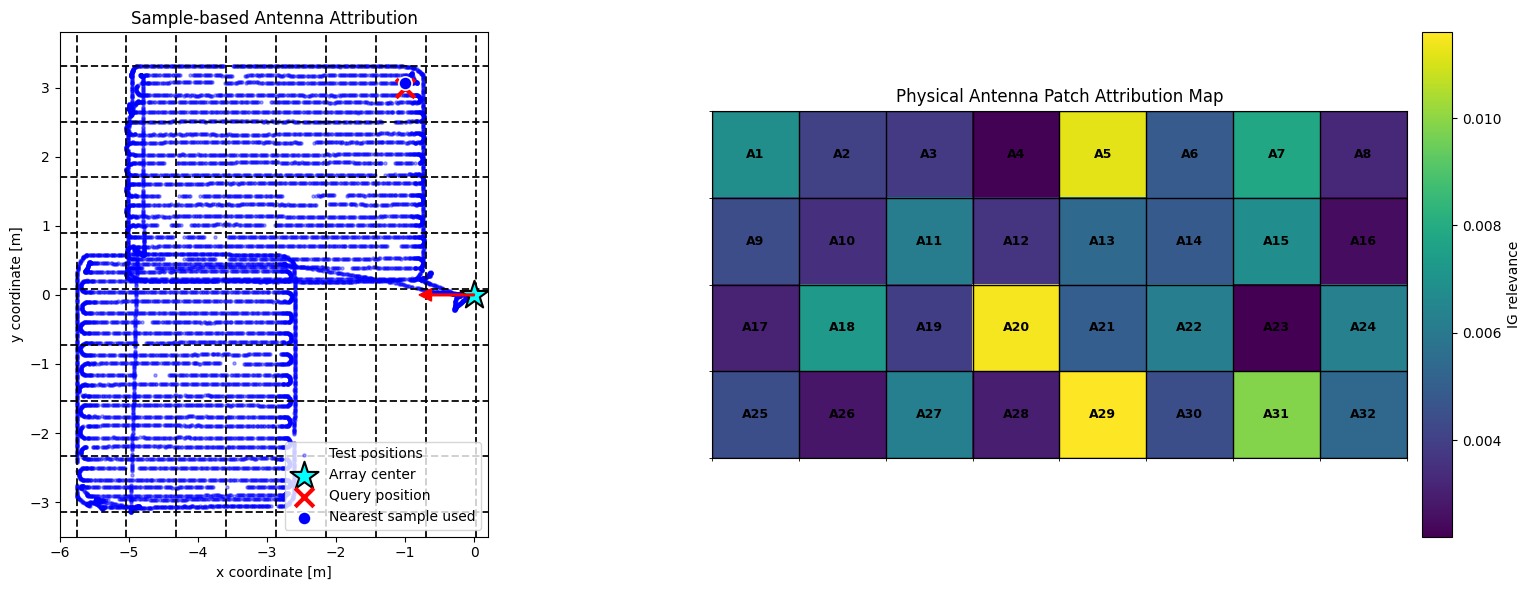

Query position: (-1.0, 3.0)
Used sample index: 1667
Used sample position: [-1.0042851  3.0693936]
Exact match used: False
Distance query to used sample: 0.069526 m
Array center: [0.0, 0.0, 0.0]
Antenna array pointing direction: [-1.0, 0.0, 0.0]
Array points toward negative x-axis.
2D distance to array center: 3.2295 m
3D distance to array center: 3.2295 m
Top-5 antennas:
['A29', 'A20', 'A5', 'A31', 'A7']
All antennas by importance:
['A29', 'A20', 'A5', 'A31', 'A7', 'A18', 'A1', 'A15', 'A24', 'A27', 'A22', 'A11', 'A13', 'A32', 'A21', 'A6', 'A14', 'A30', 'A25', 'A9', 'A2', 'A19', 'A3', 'A12', 'A10', 'A8', 'A17', 'A28', 'A26', 'A16', 'A4', 'A23']


In [ ]:
# import numpy as np
# from scipy.spatial.distance import cdist
# from matplotlib.colors import Normalize

# # Define antenna_channel_assignments
# antenna_channel_assignments = np.array([
#     [ 0,  1,  2,  3,  4,  5,  6,  7],
#     [ 8,  9, 10, 11, 12, 13, 14, 15],
#     [16, 17, 18, 19, 20, 21, 22, 23],
#     [24, 25, 26, 27, 28, 29, 30, 31]
# ])

# # Define array_center and array_direction based on context (e.g., from original notebook or typical setup)
# # Assuming a default center at origin and direction along negative x-axis
# array_center = np.array([0.0, 0.0, 0.0])  # Example values, adjust if precise values are known
# array_direction = np.array([-1.0, 0.0, 0.0]) # Example: array points towards negative x-axis

# # Define get_sample_based_antenna_importance based on usage and other helper functions
# def get_sample_based_antenna_importance(x_query, y_query, tolerance=1e-6):
#     # Find the closest sample in y_test_ig to (x_query, y_query)
#     query_point = np.array([[x_query, y_query]])
#     distances = cdist(query_point, y_test_ig)
#     min_distance_idx = np.argmin(distances)
#     min_distance = distances[0, min_distance_idx]
#     sample_position = y_test_ig[min_distance_idx:min_distance_idx+1] # Keep dimensions for ig.explain
#     sample_csi = X_test_ig[min_distance_idx:min_distance_idx+1] # Keep dimensions for ig.explain

#     is_exact = min_distance <= tolerance

#     # Calculate Integrated Gradients
#     # ig, mean_baseline, and antenna_importance_from_attr are assumed to be globally available
#     exp_x = ig.explain(sample_csi, baselines=mean_baseline, target=0)
#     exp_y = ig.explain(sample_csi, baselines=mean_baseline, target=1)

#     attr_x = exp_x.attributions[0]
#     attr_y = exp_y.attributions[0]

#     # Note: Using antenna_importance_from_attr as defined in J7LruPevzSe0.
#     imp_x = antenna_importance_from_attr(attr_x)
#     imp_y = antenna_importance_from_attr(attr_y)

#     importance_combined = (imp_x + imp_y) / 2
#     antenna_ranking = np.argsort(importance_combined)[::-1]

#     return {
#         "sample_idx": min_distance_idx,
#         "sample_position": sample_position.flatten(), # Flatten sample_position for consistency with original notebook's likely usage
#         "is_exact": is_exact,
#         "query_to_sample_distance": min_distance,
#         "importance_combined": importance_combined,
#         "antenna_ranking": antenna_ranking
#     }

# plot_sample_based_antenna_patch(
#     x_query=-1.0,
#     y_query=3.0
# )

In [ ]:
# all_positions = y_test_ig

# print("========================================")
# print("ALL TEST SAMPLE POSITIONS")
# print("========================================")

# for i, pos in enumerate(all_positions):
#     print(
#         f"Sample {i}: "
#         f"x = {pos[0]:.6f}, "
#         f"y = {pos[1]:.6f}"
#     )

# print()
# print("========================================")
# print(f"TOTAL NUMBER OF TEST SAMPLES: {len(all_positions)}")
# print("========================================")

ALL TEST SAMPLE POSITIONS
Sample 0: x = -4.784574, y = 0.204043
Sample 1: x = -4.799080, y = -1.592605
Sample 2: x = -3.663045, y = -2.504717
Sample 3: x = -0.277355, y = -0.176884
Sample 4: x = -0.955935, y = 2.786774
Sample 5: x = -5.753350, y = 0.296011
Sample 6: x = -0.021180, y = -0.039589
Sample 7: x = -5.037055, y = 1.200241
Sample 8: x = -3.469586, y = -0.398349
Sample 9: x = -4.087233, y = -2.905632
Sample 10: x = 0.018027, y = -0.035072
Sample 11: x = -4.385002, y = -2.376422
Sample 12: x = -4.981660, y = 1.296941
Sample 13: x = -2.478569, y = 1.616373
Sample 14: x = -3.024828, y = -2.681543
Sample 15: x = -1.579288, y = 1.617822
Sample 16: x = -2.325696, y = 1.616403
Sample 17: x = -5.741221, y = 0.372297
Sample 18: x = -5.755036, y = -0.305148
Sample 19: x = -3.595077, y = 0.198125
Sample 20: x = -4.936339, y = 0.700865
Sample 21: x = -0.157021, y = -0.081108
Sample 22: x = -4.707039, y = 2.643708
Sample 23: x = -4.979295, y = -3.129239
Sample 24: x = -3.840168, y = -0.9900

In [ ]:
# def compute_average_attribution_for_area(
#     area_name,
#     x_min_area,
#     x_max_area,
#     y_min_area,
#     y_max_area,
#     max_samples=None,
#     random_seed=42
# ):
#     mask = (
#         (y_test_ig[:, 0] >= x_min_area) &
#         (y_test_ig[:, 0] <= x_max_area) &
#         (y_test_ig[:, 1] >= y_min_area) &
#         (y_test_ig[:, 1] <= y_max_area)
#     )

#     area_indices = np.where(mask)[0]

#     if len(area_indices) == 0:
#         print(f"{area_name}: no samples found.")
#         return None

#     if max_samples is not None:
#         rng = np.random.default_rng(random_seed)
#         area_indices = rng.choice(
#             area_indices,
#             size=min(max_samples, len(area_indices)),
#             replace=False
#         )

#     antenna_importances = []

#     for count, idx in enumerate(area_indices):

#         sample = X_test_ig[idx:idx+1]

#         exp_x = ig.explain(
#             sample,
#             baselines=mean_baseline,
#             target=0
#         )

#         exp_y = ig.explain(
#             sample,
#             baselines=mean_baseline,
#             target=1
#         )

#         attr_x = exp_x.attributions[0]
#         attr_y = exp_y.attributions[0]

#         imp_x = antenna_importance_from_attr_sample(attr_x)
#         imp_y = antenna_importance_from_attr_sample(attr_y)

#         combined_imp = (imp_x + imp_y) / 2

#         antenna_importances.append(combined_imp)

#         if count % 50 == 0:
#             print(f"{area_name}: processed {count}/{len(area_indices)} samples")

#     mean_importance = np.mean(antenna_importances, axis=0)

#     antenna_ranking = np.argsort(mean_importance)[::-1]

#     return {
#         "area_name": area_name,
#         "indices": area_indices,
#         "num_samples": len(area_indices),
#         "importance_combined": mean_importance,
#         "antenna_ranking": antenna_ranking,
#         "top_antennas": antenna_ranking[:5]
#     }


# def plot_average_area_attribution(result, cmap=cm.viridis):

#     relevance = result["importance_combined"]

#     patch_map = np.zeros_like(
#         antenna_channel_assignments,
#         dtype=float
#     )

#     for r in range(antenna_channel_assignments.shape[0]):
#         for c in range(antenna_channel_assignments.shape[1]):
#             ant_idx = antenna_channel_assignments[r, c]
#             patch_map[r, c] = relevance[ant_idx]

#     plt.figure(figsize=(9, 4))

#     im = plt.imshow(
#         patch_map,
#         cmap=cmap,
#         origin="upper"
#     )

#     rows, cols = antenna_channel_assignments.shape

#     for r in range(rows):
#         for c in range(cols):
#             ant_idx = antenna_channel_assignments[r, c]
#             plt.text(
#                 c,
#                 r,
#                 f"A{ant_idx + 1}",
#                 ha="center",
#                 va="center",
#                 fontsize=9,
#                 fontweight="bold",
#                 color="black"
#             )

#     plt.xticks(np.arange(-0.5, cols, 1), minor=True)
#     plt.yticks(np.arange(-0.5, rows, 1), minor=True)

#     plt.grid(
#         which="minor",
#         color="black",
#         linestyle="-",
#         linewidth=1
#     )

#     plt.xticks([])
#     plt.yticks([])

#     plt.title(
#         f"{result['area_name']} - Average Antenna Attribution\n"
#         f"Samples used: {result['num_samples']}"
#     )

#     cb = plt.colorbar(im)
#     cb.set_label("Average IG relevance")

#     plt.tight_layout()
#     plt.show()

#     print(f"{result['area_name']}")
#     print("Number of samples:", result["num_samples"])
#     print("Top-5 antennas:", [f"A{a+1}" for a in result["top_antennas"]])
#     print("All antennas by importance:")
#     print([f"A{a+1}" for a in result["antenna_ranking"]])

In [ ]:
# def compute_average_attribution_for_area(
#     area_name,
#     x_min_area,
#     x_max_area,
#     y_min_area,
#     y_max_area,
#     max_samples=None,
#     random_seed=42
# ):
#     mask = (
#         (y_test_ig[:, 0] >= x_min_area) &
#         (y_test_ig[:, 0] <= x_max_area) &
#         (y_test_ig[:, 1] >= y_min_area) &
#         (y_test_ig[:, 1] <= y_max_area)
#     )

#     area_indices = np.where(mask)[0]

#     if len(area_indices) == 0:
#         print(f"{area_name}: no samples found.")
#         return None

#     if max_samples is not None:
#         rng = np.random.default_rng(random_seed)
#         area_indices = rng.choice(
#             area_indices,
#             size=min(max_samples, len(area_indices)),
#             replace=False
#         )

#     antenna_importances = []

#     for count, idx in enumerate(area_indices):

#         sample = X_test_ig[idx:idx+1]

#         exp_x = ig.explain(
#             sample,
#             baselines=mean_baseline,
#             target=0
#         )

#         exp_y = ig.explain(
#             sample,
#             baselines=mean_baseline,
#             target=1
#         )

#         attr_x = exp_x.attributions[0]
#         attr_y = exp_y.attributions[0]

#         # Corrected function name
#         imp_x = antenna_importance_from_attr(attr_x)
#         imp_y = antenna_importance_from_attr(attr_y)

#         combined_imp = (imp_x + imp_y) / 2

#         antenna_importances.append(combined_imp)

#         if count % 50 == 0:
#             print(f"{area_name}: processed {count}/{len(area_indices)} samples")

#     mean_importance = np.mean(antenna_importances, axis=0)

#     antenna_ranking = np.argsort(mean_importance)[::-1]

#     return {
#         "area_name": area_name,
#         "indices": area_indices,
#         "num_samples": len(area_indices),
#         "importance_combined": mean_importance,
#         "antenna_ranking": antenna_ranking,
#         "top_antennas": antenna_ranking[:5]
#     }

# lower_area_result = compute_average_attribution_for_area(
#     area_name="Lower Area",
#     x_min_area=-5.8,
#     x_max_area=-2.6,
#     y_min_area=-3.2,
#     y_max_area=0.6,
#     max_samples=None
# )

# upper_area_result = compute_average_attribution_for_area(
#     area_name="Upper Area",
#     x_min_area=-5.0,
#     x_max_area=-0.7,
#     y_min_area=0.1,
#     y_max_area=3.4,
#     max_samples=None
# )

Lower Area: processed 0/7089 samples
Lower Area: processed 50/7089 samples
Lower Area: processed 100/7089 samples
Lower Area: processed 150/7089 samples
Lower Area: processed 200/7089 samples
Lower Area: processed 250/7089 samples
Lower Area: processed 300/7089 samples
Lower Area: processed 350/7089 samples
Lower Area: processed 400/7089 samples
Lower Area: processed 450/7089 samples
Lower Area: processed 500/7089 samples
Lower Area: processed 550/7089 samples
Lower Area: processed 600/7089 samples
Lower Area: processed 650/7089 samples
Lower Area: processed 700/7089 samples
Lower Area: processed 750/7089 samples
Lower Area: processed 800/7089 samples
Lower Area: processed 850/7089 samples
Lower Area: processed 900/7089 samples
Lower Area: processed 950/7089 samples
Lower Area: processed 1000/7089 samples
Lower Area: processed 1050/7089 samples
Lower Area: processed 1100/7089 samples
Lower Area: processed 1150/7089 samples
Lower Area: processed 1200/7089 samples
Lower Area: processed 1

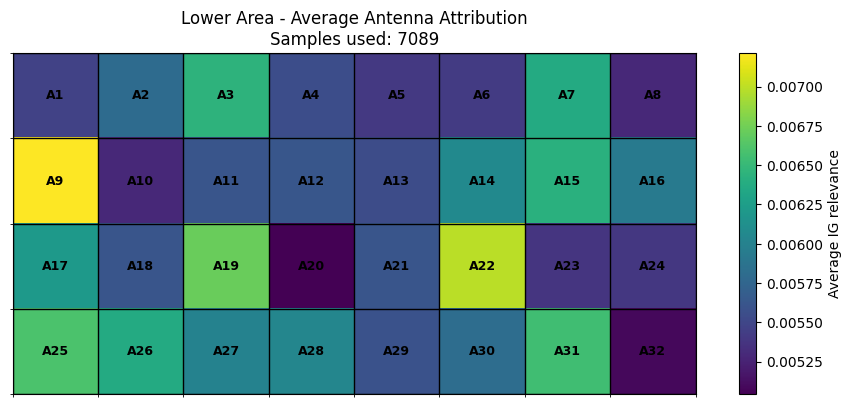

Lower Area
Number of samples: 7089
Top-5 antennas: ['A9', 'A22', 'A19', 'A25', 'A31']
All antennas by importance:
['A9', 'A22', 'A19', 'A25', 'A31', 'A3', 'A15', 'A26', 'A7', 'A17', 'A14', 'A28', 'A27', 'A16', 'A30', 'A2', 'A12', 'A11', 'A21', 'A18', 'A29', 'A4', 'A13', 'A1', 'A6', 'A5', 'A24', 'A23', 'A8', 'A10', 'A32', 'A20']


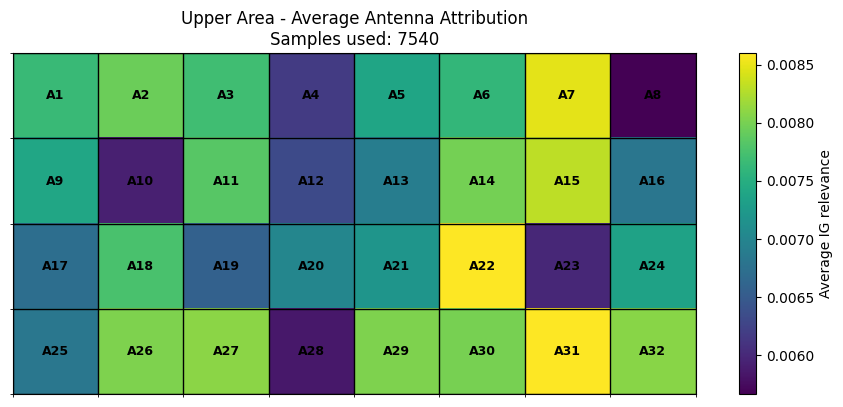

Upper Area
Number of samples: 7540
Top-5 antennas: ['A22', 'A31', 'A7', 'A15', 'A27']
All antennas by importance:
['A22', 'A31', 'A7', 'A15', 'A27', 'A32', 'A29', 'A26', 'A30', 'A14', 'A2', 'A11', 'A18', 'A3', 'A1', 'A6', 'A9', 'A5', 'A24', 'A21', 'A20', 'A13', 'A25', 'A16', 'A17', 'A19', 'A12', 'A4', 'A23', 'A10', 'A28', 'A8']


In [ ]:
# plot_average_area_attribution(lower_area_result)
# plot_average_area_attribution(upper_area_result)

In [ ]:
# from matplotlib.patches import Rectangle
# from matplotlib.colors import Normalize

# def compute_average_attribution_for_subregion(
#     ix,
#     iy,
#     max_samples_per_subregion=None,
#     random_seed=42
# ):
#     rng = np.random.default_rng(random_seed)

#     x_low, x_high = x_edges[ix], x_edges[ix + 1]
#     y_low, y_high = y_edges[iy], y_edges[iy + 1]

#     x_mask = (y_test_ig[:, 0] >= x_low) & (y_test_ig[:, 0] < x_high)
#     y_mask = (y_test_ig[:, 1] >= y_low) & (y_test_ig[:, 1] < y_high)

#     if ix == num_x_regions - 1:
#         x_mask = (y_test_ig[:, 0] >= x_low) & (y_test_ig[:, 0] <= x_high)

#     if iy == num_y_regions - 1:
#         y_mask = (y_test_ig[:, 1] >= y_low) & (y_test_ig[:, 1] <= y_high)

#     subregion_indices = np.where(x_mask & y_mask)[0]

#     if len(subregion_indices) == 0:
#         print(f"Sub-region X{ix+1}-Y{iy+1}: no samples")
#         return None

#     if max_samples_per_subregion is None:
#         selected_indices = subregion_indices
#     else:
#         selected_indices = rng.choice(
#             subregion_indices,
#             size=min(max_samples_per_subregion, len(subregion_indices)),
#             replace=False
#         )

#     antenna_importances = []

#     for count, idx in enumerate(selected_indices):
#         sample = X_test_ig[idx:idx+1]

#         exp_x = ig.explain(
#             sample,
#             baselines=mean_baseline,
#             target=0
#         )

#         exp_y = ig.explain(
#             sample,
#             baselines=mean_baseline,
#             target=1
#         )

#         attr_x = exp_x.attributions[0]
#         attr_y = exp_y.attributions[0]

#         imp_x = antenna_importance_from_attr_sample(attr_x)
#         imp_y = antenna_importance_from_attr_sample(attr_y)

#         combined_imp = (imp_x + imp_y) / 2
#         antenna_importances.append(combined_imp)

#     mean_importance = np.mean(antenna_importances, axis=0)
#     antenna_ranking = np.argsort(mean_importance)[::-1]

#     return {
#         "ix": ix,
#         "iy": iy,
#         "x_range": (x_low, x_high),
#         "y_range": (y_low, y_high),
#         "num_samples_total": len(subregion_indices),
#         "num_samples_used": len(selected_indices),
#         "importance_combined": mean_importance,
#         "antenna_ranking": antenna_ranking,
#         "top_antennas": antenna_ranking[:5]
#     }


# def plot_average_subregion_attribution(
#     result,
#     cmap=cm.viridis,
#     save=True
# ):
#     ix = result["ix"]
#     iy = result["iy"]

#     x_low, x_high = result["x_range"]
#     y_low, y_high = result["y_range"]

#     relevance = result["importance_combined"]
#     antenna_ranking = result["antenna_ranking"]

#     patch_map = np.zeros_like(
#         antenna_channel_assignments,
#         dtype=float
#     )

#     for r in range(antenna_channel_assignments.shape[0]):
#         for c in range(antenna_channel_assignments.shape[1]):
#             ant_idx = antenna_channel_assignments[r, c]
#             patch_map[r, c] = relevance[ant_idx]

#     norm = Normalize(
#         vmin=np.min(relevance),
#         vmax=np.max(relevance)
#     )

#     fig, axes = plt.subplots(
#         1,
#         3,
#         figsize=(17, 6),
#         gridspec_kw={"width_ratios": [1.4, 1.15, 0.05]}
#     )

#     ax_map = axes[0]
#     ax_patch = axes[1]
#     cax = axes[2]

#     ax_map.scatter(
#         y_test_ig[:, 0],
#         y_test_ig[:, 1],
#         s=5,
#         alpha=0.35,
#         color="blue",
#         label="Test positions"
#     )

#     for x in x_edges:
#         ax_map.axvline(
#             x,
#             linestyle="--",
#             linewidth=1.4,
#             color="black",
#             alpha=0.9
#         )

#     for y in y_edges:
#         ax_map.axhline(
#             y,
#             linestyle="--",
#             linewidth=1.4,
#             color="black",
#             alpha=0.9
#         )

#     rect = Rectangle(
#         (x_low, y_low),
#         x_high - x_low,
#         y_high - y_low,
#         linewidth=3,
#         edgecolor="red",
#         facecolor="none",
#         zorder=10,
#         label="Current sub-region"
#     )

#     ax_map.add_patch(rect)

#     ax_map.scatter(
#         array_center[0],
#         array_center[1],
#         marker="*",
#         s=450,
#         color="cyan",
#         edgecolor="black",
#         linewidths=1.5,
#         zorder=11,
#         label="Array center"
#     )

#     ax_map.arrow(
#         array_center[0],
#         array_center[1],
#         array_direction[0] * 0.8,
#         array_direction[1] * 0.8,
#         width=0.025,
#         head_width=0.18,
#         head_length=0.18,
#         color="red",
#         length_includes_head=True,
#         zorder=12
#     )

#     ax_map.set_xlabel("x coordinate [m]")
#     ax_map.set_ylabel("y coordinate [m]")

#     ax_map.set_title(
#         f"Average Attribution in Sub-region X{ix+1}-Y{iy+1}"
#     )

#     ax_map.set_xlim(-6, 0.2)
#     ax_map.set_ylim(-3.5, 3.8)
#     ax_map.set_aspect("equal", adjustable="box")
#     ax_map.legend()

#     im = ax_patch.imshow(
#         patch_map,
#         cmap=cmap,
#         norm=norm,
#         origin="upper"
#     )

#     rows, cols = antenna_channel_assignments.shape

#     for r in range(rows):
#         for c in range(cols):
#             ant_idx = antenna_channel_assignments[r, c]
#             ant_number = ant_idx + 1

#             ax_patch.text(
#                 c,
#                 r,
#                 f"A{ant_number}",
#                 ha="center",
#                 va="center",
#                 fontsize=9,
#                 fontweight="bold",
#                 color="black"
#             )

#     ax_patch.set_xticks(np.arange(-0.5, cols, 1), minor=True)
#     ax_patch.set_yticks(np.arange(-0.5, rows, 1), minor=True)

#     ax_patch.grid(
#         which="minor",
#         color="black",
#         linestyle="-",
#         linewidth=1
#     )

#     ax_patch.set_xticks([])
#     ax_patch.set_yticks([])

#     ax_patch.set_title(
#         "Physical Antenna Patch Attribution Map"
#     )

#     cb = plt.colorbar(
#         im,
#         cax=cax
#     )

#     cb.set_label("Average IG relevance")

#     plt.tight_layout()

#     if save:
#         filename_base = f"avg_subregion_X{ix+1}_Y{iy+1}"

#         plt.savefig(
#             filename_base + ".png",
#             dpi=300,
#             bbox_inches="tight"
#         )

#         plt.savefig(
#             filename_base + ".pdf",
#             bbox_inches="tight"
#         )

#     plt.show()

#     print(f"Sub-region: X{ix+1}-Y{iy+1}")
#     print(f"x range: {x_low:.4f} to {x_high:.4f}")
#     print(f"y range: {y_low:.4f} to {y_high:.4f}")
#     print(f"Total samples in sub-region: {result['num_samples_total']}")
#     print(f"Samples used: {result['num_samples_used']}")
#     print("Top-5 antennas:")
#     print([f"A{a+1}" for a in antenna_ranking[:5]])
#     print("All antennas by importance:")
#     print([f"A{a+1}" for a in antenna_ranking])

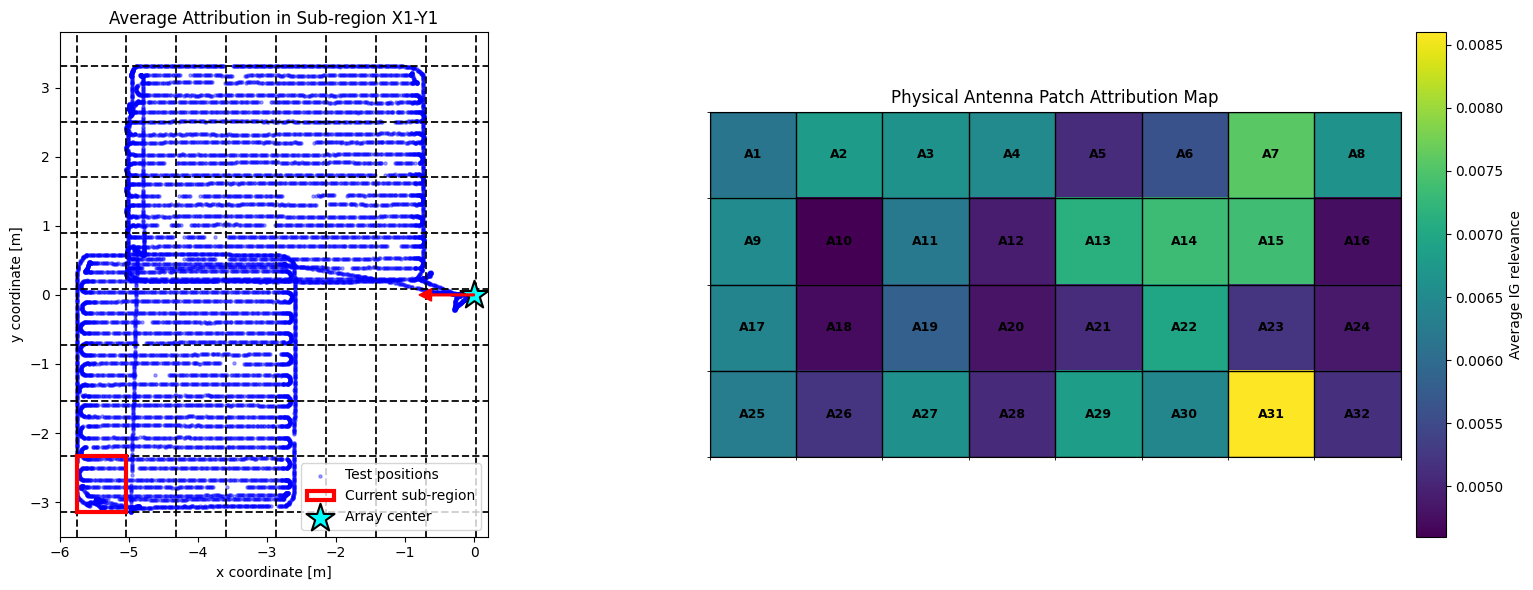

Sub-region: X1-Y1
x range: -5.7565 to -5.0346
y range: -3.1435 to -2.3363
Total samples in sub-region: 507
Samples used: 507
Top-5 antennas:
['A31', 'A7', 'A15', 'A14', 'A13']
All antennas by importance:
['A31', 'A7', 'A15', 'A14', 'A13', 'A22', 'A29', 'A2', 'A3', 'A8', 'A27', 'A9', 'A4', 'A30', 'A17', 'A25', 'A11', 'A1', 'A19', 'A6', 'A26', 'A23', 'A32', 'A21', 'A5', 'A28', 'A12', 'A24', 'A20', 'A16', 'A18', 'A10']


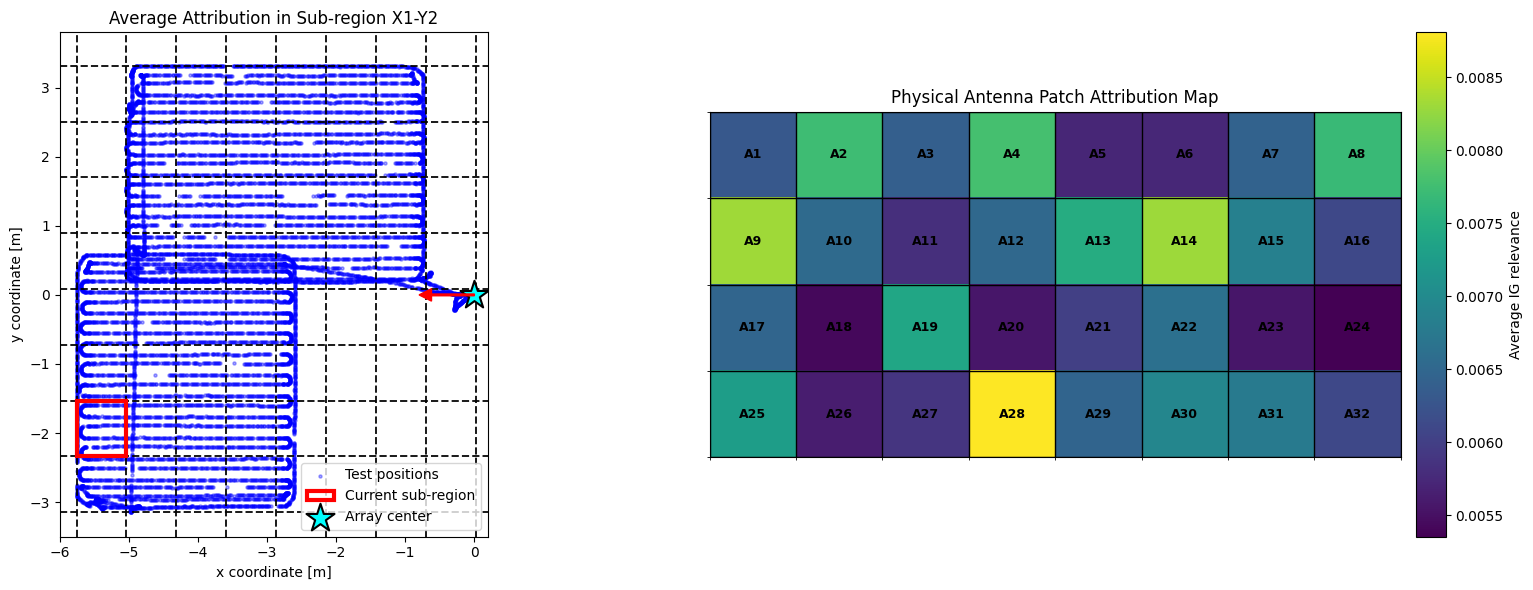

Sub-region: X1-Y2
x range: -5.7565 to -5.0346
y range: -2.3363 to -1.5291
Total samples in sub-region: 339
Samples used: 339
Top-5 antennas:
['A28', 'A9', 'A14', 'A4', 'A2']
All antennas by importance:
['A28', 'A9', 'A14', 'A4', 'A2', 'A8', 'A13', 'A19', 'A25', 'A30', 'A15', 'A31', 'A22', 'A10', 'A12', 'A17', 'A29', 'A7', 'A3', 'A1', 'A16', 'A32', 'A21', 'A27', 'A11', 'A6', 'A5', 'A26', 'A23', 'A20', 'A18', 'A24']


KeyboardInterrupt: 

In [ ]:
# import numpy as np
# import matplotlib.cm as cm
# from matplotlib.patches import Rectangle
# from matplotlib.colors import Normalize

# def compute_average_attribution_for_subregion(
#     ix,
#     iy,
#     max_samples_per_subregion=None,
#     random_seed=42
# ):
#     rng = np.random.default_rng(random_seed)

#     x_low, x_high = x_edges[ix], x_edges[ix + 1]
#     y_low, y_high = y_edges[iy], y_edges[iy + 1]

#     x_mask = (y_test_ig[:, 0] >= x_low) & (y_test_ig[:, 0] < x_high)
#     y_mask = (y_test_ig[:, 1] >= y_low) & (y_test_ig[:, 1] < y_high)

#     if ix == num_x_regions - 1:
#         x_mask = (y_test_ig[:, 0] >= x_low) & (y_test_ig[:, 0] <= x_high)

#     if iy == num_y_regions - 1:
#         y_mask = (y_test_ig[:, 1] >= y_low) & (y_test_ig[:, 1] <= y_high)

#     subregion_indices = np.where(x_mask & y_mask)[0]

#     if len(subregion_indices) == 0:
#         print(f"Sub-region X{ix+1}-Y{iy+1}: no samples")
#         return None

#     if max_samples_per_subregion is None:
#         selected_indices = subregion_indices
#     else:
#         selected_indices = rng.choice(
#             subregion_indices,
#             size=min(max_samples_per_subregion, len(subregion_indices)),
#             replace=False
#         )

#     antenna_importances = []

#     for count, idx in enumerate(selected_indices):
#         sample = X_test_ig[idx:idx+1]

#         exp_x = ig.explain(
#             sample,
#             baselines=mean_baseline,
#             target=0
#         )

#         exp_y = ig.explain(
#             sample,
#             baselines=mean_baseline,
#             target=1
#         )

#         attr_x = exp_x.attributions[0]
#         attr_y = exp_y.attributions[0]

#         imp_x = antenna_importance_from_attr(attr_x)
#         imp_y = antenna_importance_from_attr(attr_y)

#         combined_imp = (imp_x + imp_y) / 2
#         antenna_importances.append(combined_imp)

#     mean_importance = np.mean(antenna_importances, axis=0)
#     antenna_ranking = np.argsort(mean_importance)[::-1]

#     return {
#         "ix": ix,
#         "iy": iy,
#         "x_range": (x_low, x_high),
#         "y_range": (y_low, y_high),
#         "num_samples_total": len(subregion_indices),
#         "num_samples_used": len(selected_indices),
#         "importance_combined": mean_importance,
#         "antenna_ranking": antenna_ranking,
#         "top_antennas": antenna_ranking[:5]
#     }


# def plot_average_subregion_attribution(
#     result,
#     cmap=cm.viridis,
#     save=True
# ):
#     ix = result["ix"]
#     iy = result["iy"]

#     x_low, x_high = result["x_range"]
#     y_low, y_high = result["y_range"]

#     relevance = result["importance_combined"]
#     antenna_ranking = result["antenna_ranking"]

#     patch_map = np.zeros_like(
#         antenna_channel_assignments,
#         dtype=float
#     )

#     for r in range(antenna_channel_assignments.shape[0]):
#         for c in range(antenna_channel_assignments.shape[1]):
#             ant_idx = antenna_channel_assignments[r, c]
#             patch_map[r, c] = relevance[ant_idx]

#     norm = Normalize(
#         vmin=np.min(relevance),
#         vmax=np.max(relevance)
#     )

#     fig, axes = plt.subplots(
#         1,
#         3,
#         figsize=(17, 6),
#         gridspec_kw={"width_ratios": [1.4, 1.15, 0.05]}
#     )

#     ax_map = axes[0]
#     ax_patch = axes[1]
#     cax = axes[2]

#     ax_map.scatter(
#         y_test_ig[:, 0],
#         y_test_ig[:, 1],
#         s=5,
#         alpha=0.35,
#         color="blue",
#         label="Test positions"
#     )

#     for x in x_edges:
#         ax_map.axvline(
#             x,
#             linestyle="--",
#             linewidth=1.4,
#             color="black",
#             alpha=0.9
#         )

#     for y in y_edges:
#         ax_map.axhline(
#             y,
#             linestyle="--",
#             linewidth=1.4,
#             color="black",
#             alpha=0.9
#         )

#     rect = Rectangle(
#         (x_low, y_low),
#         x_high - x_low,
#         y_high - y_low,
#         linewidth=3,
#         edgecolor="red",
#         facecolor="none",
#         zorder=10,
#         label="Current sub-region"
#     )

#     ax_map.add_patch(rect)

#     ax_map.scatter(
#         array_center[0],
#         array_center[1],
#         marker="*",
#         s=450,
#         color="cyan",
#         edgecolor="black",
#         linewidths=1.5,
#         zorder=11,
#         label="Array center"
#     )

#     ax_map.arrow(
#         array_center[0],
#         array_center[1],
#         array_direction[0] * 0.8,
#         array_direction[1] * 0.8,
#         width=0.025,
#         head_width=0.18,
#         head_length=0.18,
#         color="red",
#         length_includes_head=True,
#         zorder=12
#     )

#     ax_map.set_xlabel("x coordinate [m]")
#     ax_map.set_ylabel("y coordinate [m]")

#     ax_map.set_title(
#         f"Average Attribution in Sub-region X{ix+1}-Y{iy+1}"
#     )

#     ax_map.set_xlim(-6, 0.2)
#     ax_map.set_ylim(-3.5, 3.8)
#     ax_map.set_aspect("equal", adjustable="box")
#     ax_map.legend()

#     im = ax_patch.imshow(
#         patch_map,
#         cmap=cmap,
#         norm=norm,
#         origin="upper"
#     )

#     rows, cols = antenna_channel_assignments.shape

#     for r in range(rows):
#         for c in range(cols):
#             ant_idx = antenna_channel_assignments[r, c]
#             ant_number = ant_idx + 1

#             ax_patch.text(
#                 c,
#                 r,
#                 f"A{ant_number}",
#                 ha="center",
#                 va="center",
#                 fontsize=9,
#                 fontweight="bold",
#                 color="black"
#             )

#     ax_patch.set_xticks(np.arange(-0.5, cols, 1), minor=True)
#     ax_patch.set_yticks(np.arange(-0.5, rows, 1), minor=True)

#     ax_patch.grid(
#         which="minor",
#         color="black",
#         linestyle="-",
#         linewidth=1
#     )

#     ax_patch.set_xticks([])
#     ax_patch.set_yticks([])

#     ax_patch.set_title(
#         "Physical Antenna Patch Attribution Map"
#     )

#     cb = plt.colorbar(
#         im,
#         cax=cax
#     )

#     cb.set_label("Average IG relevance")

#     plt.tight_layout()

#     if save:
#         filename_base = f"avg_subregion_X{ix+1}_Y{iy+1}"

#         plt.savefig(
#             filename_base + ".png",
#             dpi=300,
#             bbox_inches="tight"
#         )

#         plt.savefig(
#             filename_base + ".pdf",
#             bbox_inches="tight"
#         )

#     plt.show()

#     print(f"Sub-region: X{ix+1}-Y{iy+1}")
#     print(f"x range: {x_low:.4f} to {x_high:.4f}")
#     print(f"y range: {y_low:.4f} to {y_high:.4f}")
#     print(f"Total samples in sub-region: {result['num_samples_total']}")
#     print(f"Samples used: {result['num_samples_used']}")
#     print("Top-5 antennas:")
#     print([f"A{a+1}" for a in antenna_ranking[:5]])
#     print("All antennas by importance:")
#     print([f"A{a+1}" for a in antenna_ranking])


# all_subregion_results = {}

# for ix in range(num_x_regions):
#     for iy in range(num_y_regions):

#         result = compute_average_attribution_for_subregion(
#             ix=ix,
#             iy=iy,
#             max_samples_per_subregion=None
#         )

#         if result is not None:
#             all_subregion_results[(ix, iy)] = result
#             plot_average_subregion_attribution(result)

In [ ]:
# from scipy.stats import spearmanr
# import numpy as np
# import matplotlib.pyplot as plt

# valid_subregions = sorted(all_subregion_results.keys())

# n = len(valid_subregions)

# spearman_matrix = np.zeros((n, n))

# subregion_labels = [
#     f"X{ix+1}-Y{iy+1}"
#     for ix, iy in valid_subregions
# ]

# for i, region_i in enumerate(valid_subregions):

#     imp_i = all_subregion_results[
#         region_i
#     ]["importance_combined"]

#     for j, region_j in enumerate(valid_subregions):

#         imp_j = all_subregion_results[
#             region_j
#         ]["importance_combined"]

#         rho, p_value = spearmanr(
#             imp_i,
#             imp_j
#         )

#         spearman_matrix[i, j] = rho


# fig, ax = plt.subplots(figsize=(12, 10))

# im = ax.imshow(
#     spearman_matrix,
#     cmap="viridis",
#     vmin=-1,
#     vmax=1
# )

# cbar = fig.colorbar(
#     im,
#     ax=ax
# )

# cbar.set_label("Spearman correlation")

# ax.set_xticks(np.arange(n))
# ax.set_yticks(np.arange(n))

# ax.set_xticklabels(
#     subregion_labels,
#     rotation=90,
#     fontsize=7
# )

# ax.set_yticklabels(
#     subregion_labels,
#     fontsize=7
# )

# ax.set_title(
#     "Subregion-by-Subregion Spearman Correlation of Antenna Importance"
# )

# plt.tight_layout()

# output_path = "spearman_subregion_correlation.png"

# fig.savefig(
#     output_path,
#     dpi=300,
#     bbox_inches="tight"
# )

# print(f"Saved figure to: {output_path}")

# plt.close(fig)

In [ ]:
# print("Spearman correlation matrix shape:", spearman_matrix.shape)

# for i, label_i in enumerate(subregion_labels):
#     for j, label_j in enumerate(subregion_labels):
#         print(
#             f"{label_i} vs {label_j}: "
#             f"Spearman rho = {spearman_matrix[i, j]:.4f}"
#         )

Spearman correlation matrix shape: (50, 50)
X1-Y1 vs X1-Y1: Spearman rho = 1.0000
X1-Y1 vs X1-Y2: Spearman rho = 0.5132
X1-Y1 vs X1-Y3: Spearman rho = -0.2423
X1-Y1 vs X1-Y4: Spearman rho = -0.2643
X1-Y1 vs X1-Y5: Spearman rho = -0.2764
X1-Y1 vs X1-Y6: Spearman rho = 0.1635
X1-Y1 vs X1-Y7: Spearman rho = -0.0444
X1-Y1 vs X2-Y1: Spearman rho = -0.2122
X1-Y1 vs X2-Y2: Spearman rho = 0.5147
X1-Y1 vs X2-Y3: Spearman rho = 0.5682
X1-Y1 vs X2-Y4: Spearman rho = 0.5689
X1-Y1 vs X2-Y5: Spearman rho = 0.6140
X1-Y1 vs X2-Y6: Spearman rho = 0.5381
X1-Y1 vs X2-Y7: Spearman rho = 0.2104
X1-Y1 vs X2-Y8: Spearman rho = 0.4897
X1-Y1 vs X3-Y1: Spearman rho = 0.7342
X1-Y1 vs X3-Y2: Spearman rho = 0.2540
X1-Y1 vs X3-Y3: Spearman rho = 0.5715
X1-Y1 vs X3-Y4: Spearman rho = 0.3200
X1-Y1 vs X3-Y5: Spearman rho = 0.4960
X1-Y1 vs X3-Y6: Spearman rho = 0.4304
X1-Y1 vs X3-Y7: Spearman rho = 0.3288
X1-Y1 vs X3-Y8: Spearman rho = 0.5084
X1-Y1 vs X4-Y1: Spearman rho = 0.0711
X1-Y1 vs X4-Y2: Spearman rho = 0.3339
X

In [ ]:
# def plot_average_full_trajectory_attribution(
#     result,
#     cmap=cm.viridis
# ):
#     relevance = result["importance_combined"]
#     antenna_ranking = result["antenna_ranking"]

#     patch_map = np.zeros_like(
#         antenna_channel_assignments,
#         dtype=float
#     )

#     for r in range(antenna_channel_assignments.shape[0]):
#         for c in range(antenna_channel_assignments.shape[1]):
#             ant_idx = antenna_channel_assignments[r, c]
#             patch_map[r, c] = relevance[ant_idx]

#     plt.figure(figsize=(9, 4))

#     im = plt.imshow(
#         patch_map,
#         cmap=cmap,
#         origin="upper"
#     )

#     rows, cols = antenna_channel_assignments.shape

#     for r in range(rows):
#         for c in range(cols):
#             ant_idx = antenna_channel_assignments[r, c]

#             plt.text(
#                 c,
#                 r,
#                 f"A{ant_idx + 1}",
#                 ha="center",
#                 va="center",
#                 fontsize=9,
#                 fontweight="bold",
#                 color="black"
#             )

#     plt.xticks(np.arange(-0.5, cols, 1), minor=True)
#     plt.yticks(np.arange(-0.5, rows, 1), minor=True)

#     plt.grid(
#         which="minor",
#         color="black",
#         linestyle="-",
#         linewidth=1
#     )

#     plt.xticks([])
#     plt.yticks([])

#     plt.title(
#         "Average Antenna Attribution Over Full Robot Trajectory"
#     )

#     cb = plt.colorbar(im)
#     cb.set_label("Average IG relevance")

#     plt.tight_layout()

#     plt.savefig(
#         "average_full_trajectory_attribution.png",
#         dpi=300,
#         bbox_inches="tight"
#     )

#     plt.savefig(
#         "average_full_trajectory_attribution.pdf",
#         bbox_inches="tight"
#     )

#     plt.show()

#     print("Average attribution over full robot trajectory")
#     print("Total samples:", result["num_samples_total"])
#     print("Used samples:", result["num_samples_used"])
#     print("Top-5 antennas:")
#     print([f"A{a+1}" for a in antenna_ranking[:5]])
#     print("All antennas by importance:")
#     print([f"A{a+1}" for a in antenna_ranking])

Computing average attribution for full trajectory...
Processed 1000/15233 samples
Processed 2000/15233 samples
Processed 3000/15233 samples
Processed 4000/15233 samples
Processed 5000/15233 samples
Processed 6000/15233 samples
Processed 7000/15233 samples
Processed 8000/15233 samples
Processed 9000/15233 samples
Processed 10000/15233 samples
Processed 11000/15233 samples
Processed 12000/15233 samples
Processed 13000/15233 samples
Processed 14000/15233 samples
Processed 15000/15233 samples
Processed 15233/15233 samples


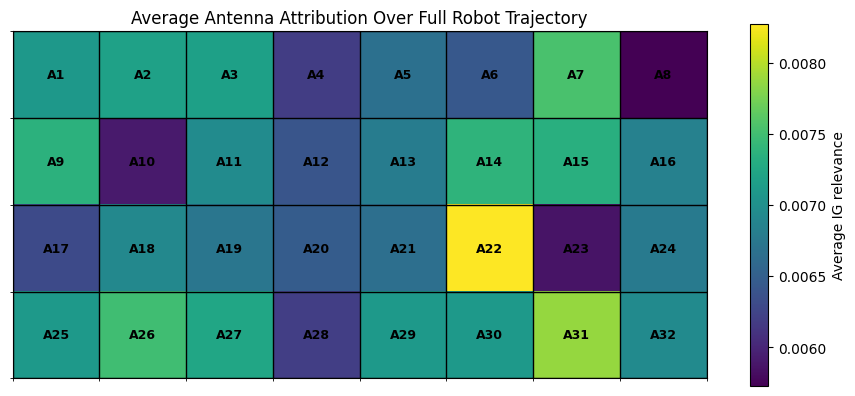

Average attribution over full robot trajectory
Total samples: 15233
Used samples: 15233
Top-5 antennas:
['A22', 'A31', 'A7', 'A26', 'A14']
All antennas by importance:
['A22', 'A31', 'A7', 'A26', 'A14', 'A9', 'A15', 'A27', 'A2', 'A3', 'A25', 'A30', 'A29', 'A1', 'A11', 'A32', 'A18', 'A16', 'A13', 'A24', 'A19', 'A5', 'A21', 'A20', 'A6', 'A12', 'A17', 'A28', 'A4', 'A10', 'A23', 'A8']


In [ ]:
# def compute_average_attribution_for_full_trajectory(max_samples=None, random_seed=42):
#     total_samples = len(X_test_ig)
#     indices = np.arange(total_samples)

#     if max_samples is not None:
#         rng = np.random.default_rng(random_seed)
#         indices = rng.choice(
#             indices,
#             size=min(max_samples, total_samples),
#             replace=False
#         )

#     antenna_importances = []

#     print("Computing average attribution for full trajectory...")
#     for count, idx in enumerate(indices):
#         sample = X_test_ig[idx:idx+1]

#         exp_x = ig.explain(
#             sample,
#             baselines=mean_baseline,
#             target=0
#         )

#         exp_y = ig.explain(
#             sample,
#             baselines=mean_baseline,
#             target=1
#         )

#         attr_x = exp_x.attributions[0]
#         attr_y = exp_y.attributions[0]

#         imp_x = antenna_importance_from_attr(attr_x)
#         imp_y = antenna_importance_from_attr(attr_y)

#         combined_imp = (imp_x + imp_y) / 2
#         antenna_importances.append(combined_imp)

#         if (count + 1) % 1000 == 0 or (count + 1) == len(indices):
#             print(f"Processed {count + 1}/{len(indices)} samples")

#     mean_importance = np.mean(antenna_importances, axis=0)
#     antenna_ranking = np.argsort(mean_importance)[::-1]

#     return {
#         "num_samples_total": total_samples,
#         "num_samples_used": len(indices),
#         "importance_combined": mean_importance,
#         "antenna_ranking": antenna_ranking
#     }

# full_trajectory_result = compute_average_attribution_for_full_trajectory(
#     max_samples=None
# )

# plot_average_full_trajectory_attribution(
#     full_trajectory_result
# )

In [ ]:
print("ablation_df exists:", "ablation_df" in globals())
print("random_guess_mean exists:", "random_guess_mean" in globals())
print("random_guess_median exists:", "random_guess_median" in globals())
print("random_guess_rmse exists:", "random_guess_rmse" in globals())

ablation_df exists: False
random_guess_mean exists: False
random_guess_median exists: False
random_guess_rmse exists: False


Using model: nn
X_ablation: (15233, 32, 32, 2)
y_ablation: (15233, 2)
Antenna ranking from Train + Validation IG:
['A7', 'A31', 'A27', 'A3', 'A11', 'A25', 'A26', 'A12', 'A32', 'A14', 'A13', 'A17', 'A30', 'A22', 'A29', 'A18', 'A15', 'A16', 'A19', 'A1', 'A6', 'A20', 'A4', 'A24', 'A21', 'A9', 'A23', 'A5', 'A2', 'A10', 'A28', 'A8']
100% | Mean: 0.3115 m | Median: 0.2568 m | RMSE: 0.3853 m
90% | Mean: 0.3920 m | Median: 0.3217 m | RMSE: 0.4885 m
80% | Mean: 0.5784 m | Median: 0.5042 m | RMSE: 0.7005 m
70% | Mean: 0.9011 m | Median: 0.8458 m | RMSE: 1.0488 m
60% | Mean: 1.2218 m | Median: 1.1804 m | RMSE: 1.3774 m
50% | Mean: 1.5226 m | Median: 1.4960 m | RMSE: 1.7124 m
40% | Mean: 1.8699 m | Median: 1.8507 m | RMSE: 2.0875 m
30% | Mean: 2.2468 m | Median: 2.2514 m | RMSE: 2.4714 m
20% | Mean: 2.5795 m | Median: 2.6032 m | RMSE: 2.8202 m
10% | Mean: 2.7335 m | Median: 2.7902 m | RMSE: 2.9988 m
Random guess bounds from TRAIN set:
x range: [-5.756, 0.015]
y range: [-3.147, 3.305]

Random Guess

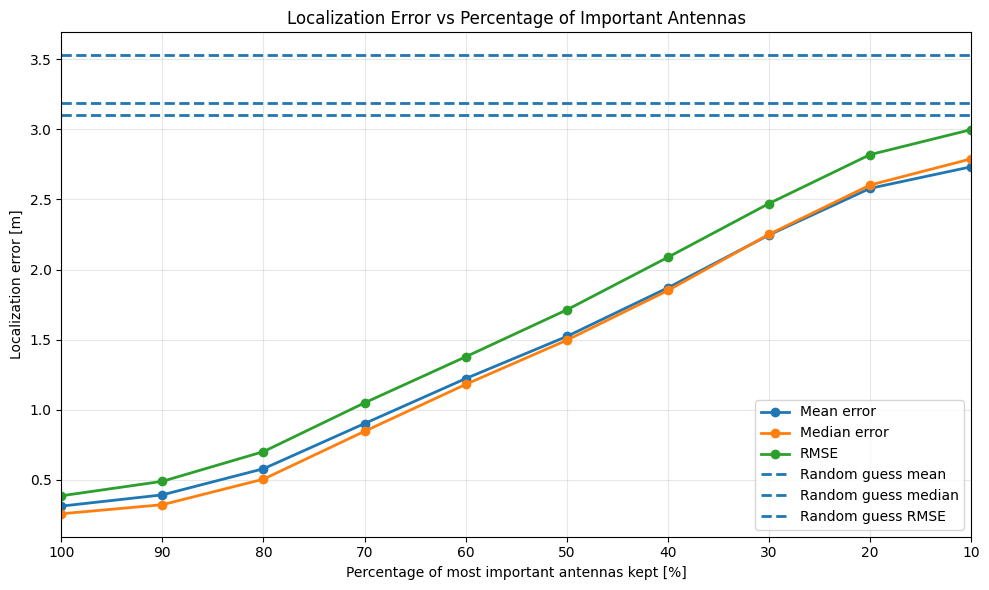

In [ ]:
# ============================================================
# Antenna Ablation Test
# ONLY plot: Localization Error vs Important Antennas + Random Guess
# Uses IG ranking computed from Train + Validation only
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RESULT_DIR = "antenna_ablation_results"
os.makedirs(RESULT_DIR, exist_ok=True)

# ------------------------------------------------------------
# 1. Model for ablation
# ------------------------------------------------------------

if "nn" in globals() and hasattr(nn, "predict"):
    ablation_model = nn
    print("Using model: nn")
else:
    raise RuntimeError(
        "Model 'nn' not found. Train or load nn before ablation."
    )


# ------------------------------------------------------------
# 2. Test data
# ------------------------------------------------------------

if "test_runs" not in globals():
    raise RuntimeError(
        "test_runs not found. Load cached runs or TFRecords first."
    )

X_ablation = np.concatenate(
    [run["X_csi"] for run in test_runs],
    axis=0
).astype(np.float32)

y_ablation = np.concatenate(
    [run["pos"] for run in test_runs],
    axis=0
).astype(np.float32)

print("X_ablation:", X_ablation.shape)
print("y_ablation:", y_ablation.shape)

if X_ablation.shape[1] != 32:
    raise ValueError(
        f"Expected 32 antennas at axis=1, got {X_ablation.shape}"
    )


# ------------------------------------------------------------
# 3. Antenna ranking from IG
# ------------------------------------------------------------
# Important:
# antenna_ranking_global must be computed from Train + Validation IG only.
# Do NOT use a hard-coded ranking and do NOT use Test IG for ranking.

if "antenna_ranking_global" not in globals():
    raise RuntimeError(
        "antenna_ranking_global not found. Run the corrected IG + ranking cell first."
    )

antenna_ranking_global = np.asarray(
    antenna_ranking_global,
    dtype=int
)

if antenna_ranking_global.shape[0] != 32:
    raise ValueError(
        f"antenna_ranking_global must contain 32 antennas, got {antenna_ranking_global.shape}"
    )

print("Antenna ranking from Train + Validation IG:")
print([f"A{i + 1}" for i in antenna_ranking_global])


# ------------------------------------------------------------
# 4. Metrics
# ------------------------------------------------------------

def compute_localization_metrics(y_true, y_pred):
    errors = np.linalg.norm(
        y_true - y_pred,
        axis=1
    )

    metrics = {
        "mean_error": float(np.mean(errors)),
        "median_error": float(np.median(errors)),
        "rmse_error": float(np.sqrt(np.mean(errors ** 2))),
    }

    return metrics, errors


# ------------------------------------------------------------
# 5. Mask antennas using TRAIN mean
# ------------------------------------------------------------

if "X_train_ig" in globals():
    train_antenna_mean = np.mean(
        X_train_ig,
        axis=0,
        keepdims=True
    ).astype(np.float32)

elif "train_runs" in globals():
    X_train_for_mean = np.concatenate(
        [run["X_csi"] for run in train_runs],
        axis=0
    ).astype(np.float32)

    train_antenna_mean = np.mean(
        X_train_for_mean,
        axis=0,
        keepdims=True
    ).astype(np.float32)

else:
    raise RuntimeError(
        "Training CSI not found. Need X_train_ig or train_runs for train-mean masking."
    )


def mask_antennas_with_train_mean(X, keep_indices):
    X_masked = X.copy()

    all_indices = np.arange(32)
    keep_indices = np.asarray(
        keep_indices,
        dtype=int
    )

    remove_indices = np.array(
        [i for i in all_indices if i not in set(keep_indices)],
        dtype=int
    )

    X_masked[:, remove_indices, ...] = train_antenna_mean[:, remove_indices, ...]

    return X_masked, remove_indices


# ------------------------------------------------------------
# 6. Run IG-ranked antenna ablation
# ------------------------------------------------------------

KEEP_PERCENTAGES = [100, 90, 80, 70, 60, 50, 40, 30, 20, 10]

ablation_results = []

for keep_percentage in KEEP_PERCENTAGES:
    keep_count = int(round(32 * keep_percentage / 100))
    keep_count = max(1, min(32, keep_count))

    selected_indices = antenna_ranking_global[:keep_count]

    X_masked, removed_indices = mask_antennas_with_train_mean(
        X_ablation,
        selected_indices
    )

    y_pred = ablation_model.predict(
        X_masked,
        batch_size=256,
        verbose=0
    )

    metrics, errors = compute_localization_metrics(
        y_ablation,
        y_pred
    )

    row = {
        "keep_percentage": keep_percentage,
        "keep_count": keep_count,
        "mean_error": metrics["mean_error"],
        "median_error": metrics["median_error"],
        "rmse_error": metrics["rmse_error"],
    }

    ablation_results.append(row)

    print(
        f"{keep_percentage}% | "
        f"Mean: {metrics['mean_error']:.4f} m | "
        f"Median: {metrics['median_error']:.4f} m | "
        f"RMSE: {metrics['rmse_error']:.4f} m"
    )

ablation_df = pd.DataFrame(ablation_results)

ablation_df.to_csv(
    os.path.join(
        RESULT_DIR,
        "ablation_only_error_results.csv"
    ),
    index=False
)


# ------------------------------------------------------------
# 7. Random Guess baseline
# ------------------------------------------------------------
# This is location random guessing, not random antenna selection.

RANDOM_GUESS_REPEATS = 20
RANDOM_GUESS_SEED = 42

rng_random_guess = np.random.default_rng(RANDOM_GUESS_SEED)

# Use TRAIN positions for random-guess bounds
# Avoid using any statistics from the test set

y_train_all = np.concatenate(
    [run["pos"] for run in train_runs],
    axis=0
).astype(np.float32)

x_min, x_max = (
    y_train_all[:, 0].min(),
    y_train_all[:, 0].max()
)

y_min, y_max = (
    y_train_all[:, 1].min(),
    y_train_all[:, 1].max()
)

print("Random guess bounds from TRAIN set:")
print(f"x range: [{x_min:.3f}, {x_max:.3f}]")
print(f"y range: [{y_min:.3f}, {y_max:.3f}]")

random_mean_errors = []
random_median_errors = []
random_rmse_errors = []

for _ in range(RANDOM_GUESS_REPEATS):
    y_random = np.zeros_like(y_ablation)

    y_random[:, 0] = rng_random_guess.uniform(
        x_min,
        x_max,
        size=len(y_ablation)
    )

    y_random[:, 1] = rng_random_guess.uniform(
        y_min,
        y_max,
        size=len(y_ablation)
    )

    random_metrics, _ = compute_localization_metrics(
        y_ablation,
        y_random
    )

    random_mean_errors.append(random_metrics["mean_error"])
    random_median_errors.append(random_metrics["median_error"])
    random_rmse_errors.append(random_metrics["rmse_error"])

random_guess_mean = float(np.mean(random_mean_errors))
random_guess_median = float(np.mean(random_median_errors))
random_guess_rmse = float(np.mean(random_rmse_errors))

print("\nRandom Guess Baseline")
print("---------------------")
print(f"Mean:   {random_guess_mean:.4f} m")
print(f"Median: {random_guess_median:.4f} m")
print(f"RMSE:   {random_guess_rmse:.4f} m")


# ------------------------------------------------------------
# 8. Plot ONLY this figure
# ------------------------------------------------------------

plot_df = ablation_df.sort_values(
    "keep_percentage",
    ascending=False
).copy()

plt.figure(figsize=(10, 6))

plt.plot(
    plot_df["keep_percentage"],
    plot_df["mean_error"],
    marker="o",
    linewidth=2,
    label="Mean error"
)

plt.plot(
    plot_df["keep_percentage"],
    plot_df["median_error"],
    marker="o",
    linewidth=2,
    label="Median error"
)

plt.plot(
    plot_df["keep_percentage"],
    plot_df["rmse_error"],
    marker="o",
    linewidth=2,
    label="RMSE"
)

plt.axhline(
    random_guess_mean,
    linestyle="--",
    linewidth=2,
    label="Random guess mean"
)

plt.axhline(
    random_guess_median,
    linestyle="--",
    linewidth=2,
    label="Random guess median"
)

plt.axhline(
    random_guess_rmse,
    linestyle="--",
    linewidth=2,
    label="Random guess RMSE"
)

plt.xlabel("Percentage of most important antennas kept [%]")
plt.ylabel("Localization error [m]")
plt.title("Localization Error vs Percentage of Important Antennas")

plt.xlim(100, 10)
plt.xticks(KEEP_PERCENTAGES)

plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig(
    os.path.join(
        RESULT_DIR,
        "ablation_only_error_with_random_guess.png"
    ),
    dpi=250
)

plt.show()

Using existing ablation_model
X_random_ablation: (15233, 32, 32, 2)
y_random_ablation: (15233, 2)

Random antenna ablation: keeping 100% antennas
Keeping 32/32 random antennas
Repeats: 20
Mean error:   0.3115 ± 0.0000 m
Median error: 0.2568 ± 0.0000 m
RMSE error:   0.3853 ± 0.0000 m

Random antenna ablation: keeping 90% antennas
Keeping 29/32 random antennas
Repeats: 20
Mean error:   0.4508 ± 0.0229 m
Median error: 0.3740 ± 0.0216 m
RMSE error:   0.5585 ± 0.0265 m

Random antenna ablation: keeping 80% antennas
Keeping 26/32 random antennas
Repeats: 20
Mean error:   0.7142 ± 0.0378 m
Median error: 0.6435 ± 0.0404 m
RMSE error:   0.8518 ± 0.0419 m

Random antenna ablation: keeping 70% antennas
Keeping 22/32 random antennas
Repeats: 20
Mean error:   1.0872 ± 0.0589 m
Median error: 1.0417 ± 0.0691 m
RMSE error:   1.2496 ± 0.0636 m

Random antenna ablation: keeping 60% antennas
Keeping 19/32 random antennas
Repeats: 20
Mean error:   1.4241 ± 0.0664 m
Median error: 1.3949 ± 0.0725 m
RMSE err

,keep_percentage,keep_count,mean_error,median_error,rmse_error,mean_error_std,median_error_std,rmse_error_std
0,100,32,0.311541,0.256826,0.385281,0.000000,0.000000,0.000000
1,90,29,0.450810,0.373992,0.558469,0.022868,0.021611,0.026463
2,80,26,0.714211,0.643508,0.851816,0.037783,0.040411,0.041870
3,70,22,1.087218,1.041690,1.249554,0.058908,0.069054,0.063641
4,60,19,1.424059,1.394902,1.611037,0.066399,0.072527,0.070312
5,50,16,1.744568,1.728163,1.949397,0.043789,0.057884,0.043409
6,40,13,2.079063,2.077938,2.305648,0.052833,0.064132,0.056379
7,30,10,2.399863,2.424686,2.646315,0.066597,0.069697,0.070889
8,20,6,2.665901,2.708678,2.930561,0.023731,0.029534,0.024270
9,10,3,2.756793,2.818002,3.027916,0.010518,0.015833,0.011024


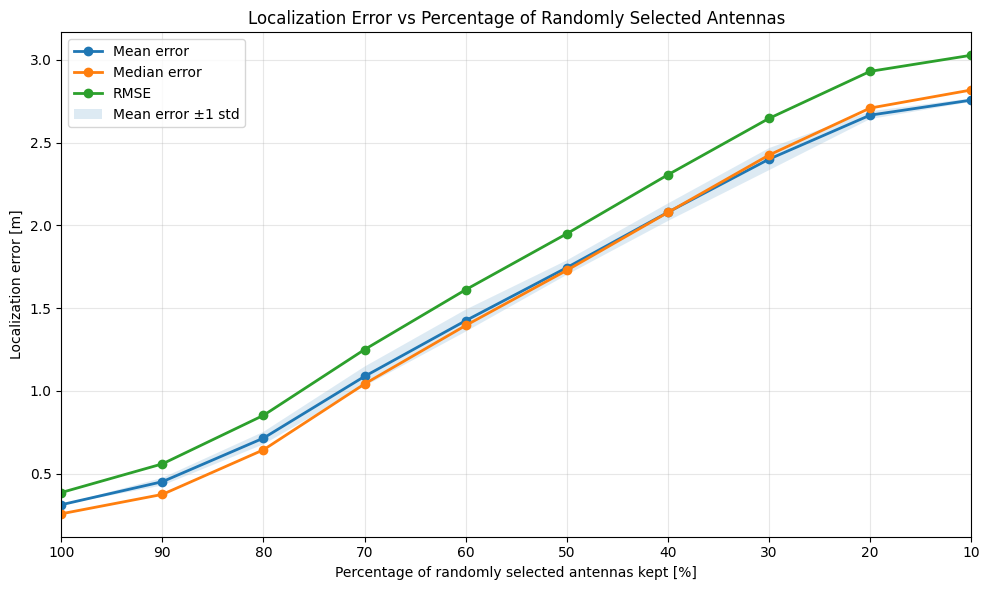

In [ ]:
# ============================================================
# Random Antenna Selection Ablation Only
# Percentage of randomly selected antennas kept vs localization error
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RESULT_DIR = "antenna_ablation_results"
os.makedirs(RESULT_DIR, exist_ok=True)

RANDOM_SELECTION_SEED = 42
rng = np.random.default_rng(RANDOM_SELECTION_SEED)

KEEP_PERCENTAGES_RANDOM = [100, 90, 80, 70, 60, 50, 40, 30, 20, 10]
RANDOM_SELECTION_REPEATS = 20


# ------------------------------------------------------------
# 1. Model for random ablation
# ------------------------------------------------------------

if "ablation_model" in globals() and hasattr(ablation_model, "predict"):
    print("Using existing ablation_model")
elif "nn" in globals() and hasattr(nn, "predict"):
    ablation_model = nn
    print("Using model: nn")
else:
    raise RuntimeError(
        "No ablation_model found. Train or load nn first."
    )


# ------------------------------------------------------------
# 2. Test data
# ------------------------------------------------------------

if "X_ablation" in globals() and "y_ablation" in globals():
    X_random_ablation = X_ablation.astype(np.float32)
    y_random_ablation = y_ablation.astype(np.float32)

elif "test_runs" in globals():
    X_random_ablation = np.concatenate(
        [run["X_csi"] for run in test_runs],
        axis=0
    ).astype(np.float32)

    y_random_ablation = np.concatenate(
        [run["pos"] for run in test_runs],
        axis=0
    ).astype(np.float32)

else:
    raise RuntimeError(
        "X_ablation/y_ablation not found and test_runs is not available."
    )

print("X_random_ablation:", X_random_ablation.shape)
print("y_random_ablation:", y_random_ablation.shape)

if X_random_ablation.shape[1] != 32:
    raise ValueError(
        f"Expected 32 antennas at axis=1, got shape {X_random_ablation.shape}"
    )


# ------------------------------------------------------------
# 3. Metrics
# ------------------------------------------------------------

def compute_localization_metrics_random(y_true, y_pred):
    errors = np.linalg.norm(
        y_true - y_pred,
        axis=1
    )

    metrics = {
        "mean_error": float(np.mean(errors)),
        "median_error": float(np.median(errors)),
        "rmse_error": float(np.sqrt(np.mean(errors ** 2))),
    }

    return metrics, errors


# ------------------------------------------------------------
# 4. Train mean masking
# ------------------------------------------------------------
# Removed antennas are replaced by TRAIN mean, not test mean.

if "X_train_ig" in globals():
    train_antenna_mean_random = np.mean(
        X_train_ig,
        axis=0,
        keepdims=True
    ).astype(np.float32)

elif "train_runs" in globals():
    X_train_for_mean_random = np.concatenate(
        [run["X_csi"] for run in train_runs],
        axis=0
    ).astype(np.float32)

    train_antenna_mean_random = np.mean(
        X_train_for_mean_random,
        axis=0,
        keepdims=True
    ).astype(np.float32)

else:
    raise RuntimeError(
        "Training CSI not found. Need X_train_ig or train_runs for train-mean masking."
    )


def mask_antennas_with_train_mean_random(X, keep_indices):
    X_masked = X.copy()

    all_indices = np.arange(32)
    keep_indices = np.asarray(
        keep_indices,
        dtype=int
    )

    remove_indices = np.array(
        [i for i in all_indices if i not in set(keep_indices)],
        dtype=int
    )

    X_masked[:, remove_indices, ...] = train_antenna_mean_random[:, remove_indices, ...]

    return X_masked, remove_indices


# ------------------------------------------------------------
# 5. Run random antenna ablation
# ------------------------------------------------------------

random_ablation_results = []

for keep_percentage in KEEP_PERCENTAGES_RANDOM:

    keep_count = int(round(32 * keep_percentage / 100))
    keep_count = max(1, min(32, keep_count))

    mean_errors = []
    median_errors = []
    rmse_errors = []

    print("\n" + "=" * 80)
    print(f"Random antenna ablation: keeping {keep_percentage}% antennas")
    print(f"Keeping {keep_count}/32 random antennas")
    print(f"Repeats: {RANDOM_SELECTION_REPEATS}")

    for repeat in range(RANDOM_SELECTION_REPEATS):

        random_indices = rng.choice(
            32,
            size=keep_count,
            replace=False
        )

        X_masked, _ = mask_antennas_with_train_mean_random(
            X_random_ablation,
            random_indices
        )

        y_pred = ablation_model.predict(
            X_masked,
            batch_size=256,
            verbose=0
        )

        metrics, _ = compute_localization_metrics_random(
            y_random_ablation,
            y_pred
        )

        mean_errors.append(metrics["mean_error"])
        median_errors.append(metrics["median_error"])
        rmse_errors.append(metrics["rmse_error"])

    row = {
        "keep_percentage": keep_percentage,
        "keep_count": keep_count,

        "mean_error": float(np.mean(mean_errors)),
        "median_error": float(np.mean(median_errors)),
        "rmse_error": float(np.mean(rmse_errors)),

        "mean_error_std": float(np.std(mean_errors)),
        "median_error_std": float(np.std(median_errors)),
        "rmse_error_std": float(np.std(rmse_errors)),
    }

    random_ablation_results.append(row)

    print(f"Mean error:   {row['mean_error']:.4f} ± {row['mean_error_std']:.4f} m")
    print(f"Median error: {row['median_error']:.4f} ± {row['median_error_std']:.4f} m")
    print(f"RMSE error:   {row['rmse_error']:.4f} ± {row['rmse_error_std']:.4f} m")


random_ablation_df = pd.DataFrame(random_ablation_results)

random_ablation_df.to_csv(
    os.path.join(
        RESULT_DIR,
        "random_only_antenna_ablation_results.csv"
    ),
    index=False
)

display(random_ablation_df)


# ------------------------------------------------------------
# 6. Plot ONLY random antenna selection
# ------------------------------------------------------------

random_plot_df = random_ablation_df.sort_values(
    "keep_percentage",
    ascending=False
).copy()

plt.figure(figsize=(10, 6))

plt.plot(
    random_plot_df["keep_percentage"],
    random_plot_df["mean_error"],
    marker="o",
    linewidth=2,
    label="Mean error"
)

plt.plot(
    random_plot_df["keep_percentage"],
    random_plot_df["median_error"],
    marker="o",
    linewidth=2,
    label="Median error"
)

plt.plot(
    random_plot_df["keep_percentage"],
    random_plot_df["rmse_error"],
    marker="o",
    linewidth=2,
    label="RMSE"
)

plt.fill_between(
    random_plot_df["keep_percentage"],
    random_plot_df["mean_error"] - random_plot_df["mean_error_std"],
    random_plot_df["mean_error"] + random_plot_df["mean_error_std"],
    alpha=0.15,
    label="Mean error ±1 std"
)

plt.xlabel("Percentage of randomly selected antennas kept [%]")
plt.ylabel("Localization error [m]")
plt.title("Localization Error vs Percentage of Randomly Selected Antennas")

plt.xlim(100, 10)
plt.xticks(KEEP_PERCENTAGES_RANDOM)

plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig(
    os.path.join(
        RESULT_DIR,
        "random_only_ablation_error_vs_percentage.png"
    ),
    dpi=250
)

plt.show()

***build_ig_source_model***

In [ ]:
# ============================================================
# IG SOURCE MODEL
# Used ONLY for Integrated Gradients ranking
# ============================================================

import os
import random
import numpy as np
import tensorflow as tf

SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)

np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)


def build_ig_source_model(seed=42):

    tf.keras.backend.clear_session()

    np.random.seed(seed)
    tf.random.set_seed(seed)

    csi_input = tf.keras.Input(
        shape=(32, 32, 2),
        name="ig_csi_input"
    )

    x = tf.keras.layers.Conv2D(
        32,
        (3, 3),
        padding="same",
        activation="relu"
    )(csi_input)

    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.MaxPooling2D((2, 2))(x)

    x = tf.keras.layers.Conv2D(
        64,
        (3, 3),
        padding="same",
        activation="relu"
    )(x)

    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.MaxPooling2D((2, 2))(x)

    x = tf.keras.layers.Conv2D(
        128,
        (3, 3),
        padding="same",
        activation="relu"
    )(x)

    x = tf.keras.layers.BatchNormalization()(x)

    x = tf.keras.layers.GlobalAveragePooling2D()(x)

    x = tf.keras.layers.Dense(
        128,
        activation="relu"
    )(x)

    x = tf.keras.layers.Dropout(0.10)(x)

    x = tf.keras.layers.Dense(
        48,
        activation="relu"
    )(x)

    x = tf.keras.layers.Dropout(0.05)(x)

    output = tf.keras.layers.Dense(
        2,
        activation="linear",
        name="position_output"
    )(x)

    model = tf.keras.Model(
        inputs=csi_input,
        outputs=output,
        name="ig_source_csi_only_model"
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=2e-4
        ),
        loss="mse",
        metrics=["mae"]
    )

    return model

In [ ]:
def concatenate_current_position_data(runs):

    X_csi = np.concatenate(
        [r["X_csi"] for r in runs],
        axis=0
    ).astype(np.float32)

    y_pos = np.concatenate(
        [r["pos"] for r in runs],
        axis=0
    ).astype(np.float32)

    return X_csi, y_pos

In [ ]:
X_ig_train_csi, y_ig_train_pos = concatenate_current_position_data(train_runs)
X_ig_val_csi, y_ig_val_pos = concatenate_current_position_data(val_runs)

ig_pos_mean = y_ig_train_pos.mean(axis=0, keepdims=True)
ig_pos_std = y_ig_train_pos.std(axis=0, keepdims=True) + 1e-8

y_ig_train_pos_norm = (
    y_ig_train_pos - ig_pos_mean
) / ig_pos_std

y_ig_val_pos_norm = (
    y_ig_val_pos - ig_pos_mean
) / ig_pos_std

print("X_ig_train_csi:", X_ig_train_csi.shape)
print("y_ig_train_pos_norm:", y_ig_train_pos_norm.shape)

print("X_ig_val_csi:", X_ig_val_csi.shape)
print("y_ig_val_pos_norm:", y_ig_val_pos_norm.shape)

X_ig_train_csi: (43930, 32, 32, 2)
y_ig_train_pos_norm: (43930, 2)
X_ig_val_csi: (14511, 32, 32, 2)
y_ig_val_pos_norm: (14511, 2)


In [ ]:
SEED = 42

BATCH_SIZE = 64

np.random.seed(SEED)
tf.random.set_seed(SEED)

print("SEED:", SEED)
print("BATCH_SIZE:", BATCH_SIZE)

SEED: 42
BATCH_SIZE: 64


In [ ]:
ig_train_dataset = tf.data.Dataset.from_tensor_slices(
    (
        X_ig_train_csi,
        y_ig_train_pos_norm.astype(np.float32)
    )
)

ig_val_dataset = tf.data.Dataset.from_tensor_slices(
    (
        X_ig_val_csi,
        y_ig_val_pos_norm.astype(np.float32)
    )
)

ig_train_dataset = (
    ig_train_dataset
    .shuffle(
        20000,
        seed=tf.constant(SEED, dtype=tf.int64),
        reshuffle_each_iteration=False
    )
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

ig_val_dataset = (
    ig_val_dataset
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

In [ ]:
# ============================================================
# Load IG Source Model if exists
# Otherwise train and save (FAST VERSION)
# ============================================================

import os
import tensorflow as tf

IG_MODEL_PATH = (
    "/content/drive/MyDrive/dichasus_cache/"
    "ig_source_csi_only_model.keras"
)

os.makedirs(
    os.path.dirname(IG_MODEL_PATH),
    exist_ok=True
)

if os.path.exists(IG_MODEL_PATH):

    print("Loading cached IG source model...")

    ig_source_model = tf.keras.models.load_model(
        IG_MODEL_PATH
    )

    print("IG source model loaded successfully.")
    print("Path:", IG_MODEL_PATH)

else:

    print("No cached model found.")
    print("Training IG source model...")

    ig_source_model = build_ig_source_model(
        seed=SEED
    )

    callbacks = [

        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=5,
            restore_best_weights=True,
            verbose=1
        ),

        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=2,
            min_lr=1e-6,
            verbose=1
        ),

        tf.keras.callbacks.ModelCheckpoint(
            filepath=IG_MODEL_PATH,
            monitor="val_loss",
            mode="min",
            save_best_only=True,
            verbose=1
        )
    ]

    history = ig_source_model.fit(
        ig_train_dataset,
        validation_data=ig_val_dataset,
        epochs=25,
        callbacks=callbacks,
        verbose=1
    )

    print("Training finished.")
    print("Best model saved to:")
    print(IG_MODEL_PATH)

    print("Reloading best saved IG source model...")

    ig_source_model = tf.keras.models.load_model(
        IG_MODEL_PATH
    )

    print("Best IG source model loaded successfully.")

print("\nIG source model is ready.")

Loading cached IG source model...
IG source model loaded successfully.
Path: /content/drive/MyDrive/dichasus_cache/ig_source_csi_only_model.keras

IG source model is ready.


In [ ]:
# ============================================================
# Use ig_source_model as IG attribution model
# ============================================================

if "ig_source_model" not in globals():
    raise RuntimeError(
        "ig_source_model not found. Train or load it first."
    )

localization_model = ig_source_model

print("Using ig_source_model for Integrated Gradients")
print(localization_model.name)

Using ig_source_model for Integrated Gradients
ig_source_csi_only_model


In [ ]:
print("ig_source_model exists:", "ig_source_model" in globals())

print(
    "model name:",
    ig_source_model.name
)

ig_source_model exists: True
model name: ig_source_csi_only_model


In [ ]:
# ============================================================
# IG Source Model -> Integrated Gradients -> Antenna Ranking
# Ranking computed from Train + Validation only
# ============================================================

import os
import numpy as np
import tensorflow as tf

# ------------------------------------------------------------
# 1. Use IG source model
# ------------------------------------------------------------

if "ig_source_model" not in globals():
    raise RuntimeError("ig_source_model not found. Train or load it first.")

localization_model = ig_source_model

print("Using model for IG:", localization_model.name)


# ------------------------------------------------------------
# 2. Mean baseline from TRAIN CSI only
# ------------------------------------------------------------

def compute_mean_baseline_from_runs(runs):
    all_csi = np.concatenate(
        [r["X_csi"] for r in runs],
        axis=0
    ).astype(np.float32)

    return np.mean(
        all_csi,
        axis=0,
        keepdims=True
    ).astype(np.float32)


mean_baseline_ig_source = compute_mean_baseline_from_runs(train_runs)

print("Mean baseline shape:", mean_baseline_ig_source.shape)


# ------------------------------------------------------------
# 3. IG helper functions
# ------------------------------------------------------------

def antenna_importance_from_attribution(attr):
    attr = np.asarray(attr)

    attr_magnitude = np.sqrt(
        attr[..., 0] ** 2 +
        attr[..., 1] ** 2
    )

    antenna_importance = np.mean(
        attr_magnitude,
        axis=2
    )

    return antenna_importance.astype(np.float32)


def integrated_gradients_importance(
    model,
    X,
    baseline,
    steps=50,
    batch_size=64,
    normalize_importance=False
):
    X = X.astype(np.float32)
    baseline = baseline.astype(np.float32)

    all_importances = []
    n = X.shape[0]

    alphas = tf.linspace(0.0, 1.0, steps)

    for start in range(0, n, batch_size):
        end = min(start + batch_size, n)

        X_batch = X[start:end]
        B = X_batch.shape[0]

        X_batch_tf = tf.convert_to_tensor(X_batch, dtype=tf.float32)

        baseline_tf = tf.convert_to_tensor(
            np.repeat(baseline, B, axis=0),
            dtype=tf.float32
        )

        total_grad_x = tf.zeros_like(X_batch_tf)
        total_grad_y = tf.zeros_like(X_batch_tf)

        for i, alpha in enumerate(alphas):
            interpolated = baseline_tf + alpha * (X_batch_tf - baseline_tf)

            with tf.GradientTape(persistent=True) as tape:
                tape.watch(interpolated)

                pred = model(interpolated, training=False)

                output_x = pred[:, 0]
                output_y = pred[:, 1]

            grad_x = tape.gradient(output_x, interpolated)
            grad_y = tape.gradient(output_y, interpolated)

            if grad_x is None or grad_y is None:
                raise RuntimeError("Gradient is None.")

            weight = 0.5 if (i == 0 or i == steps - 1) else 1.0

            total_grad_x += weight * grad_x
            total_grad_y += weight * grad_y

            del tape

        avg_grad_x = total_grad_x / tf.cast(steps - 1, tf.float32)
        avg_grad_y = total_grad_y / tf.cast(steps - 1, tf.float32)

        attr_x = (X_batch_tf - baseline_tf) * avg_grad_x
        attr_y = (X_batch_tf - baseline_tf) * avg_grad_y

        attr_combined = tf.sqrt(
            tf.square(attr_x) +
            tf.square(attr_y)
        )

        batch_importance = antenna_importance_from_attribution(
            attr_combined.numpy()
        )

        if normalize_importance:
            batch_importance = batch_importance / (
                np.sum(batch_importance, axis=1, keepdims=True) + 1e-8
            )

        all_importances.append(batch_importance)

        print(f"Computed IG importance: {end}/{n}")

    return np.vstack(all_importances).astype(np.float32)


def add_importance_to_runs_ig_source(
    runs,
    model,
    baseline,
    steps=50,
    batch_size=64,
    normalize_importance=False
):
    for r in runs:
        print("\nComputing IG source importance for:", r["file"])

        r["importance_ig_source"] = integrated_gradients_importance(
            model=model,
            X=r["X_csi"],
            baseline=baseline,
            steps=steps,
            batch_size=batch_size,
            normalize_importance=normalize_importance
        )

        print("Importance shape:", r["importance_ig_source"].shape)

    return runs


# ------------------------------------------------------------
# 4. Cache IG source importance
# ------------------------------------------------------------

IG_SOURCE_CACHE_DIR = "/content/drive/MyDrive/dichasus_cache/ig_source_importance"
os.makedirs(IG_SOURCE_CACHE_DIR, exist_ok=True)

IG_SOURCE_STEPS = 50
IG_SOURCE_BATCH_SIZE = 64
NORMALIZE_IG_SOURCE_IMPORTANCE = False

TRAIN_IG_SOURCE_CACHE = os.path.join(
    IG_SOURCE_CACHE_DIR,
    f"train_ig_source_importance_steps{IG_SOURCE_STEPS}_norm{NORMALIZE_IG_SOURCE_IMPORTANCE}.npz"
)

VAL_IG_SOURCE_CACHE = os.path.join(
    IG_SOURCE_CACHE_DIR,
    f"val_ig_source_importance_steps{IG_SOURCE_STEPS}_norm{NORMALIZE_IG_SOURCE_IMPORTANCE}.npz"
)


def save_ig_source_importance_runs(runs, output_path):
    data = {}

    for i, r in enumerate(runs):
        data[f"file_{i}"] = r["file"]
        data[f"importance_{i}"] = r["importance_ig_source"]

    data["num_runs"] = len(runs)

    np.savez_compressed(output_path, **data)

    print("Saved:", output_path)


def load_ig_source_importance_runs(runs, input_path):
    loaded = np.load(input_path, allow_pickle=True)

    num_runs = int(loaded["num_runs"])

    if num_runs != len(runs):
        raise ValueError(
            f"Cache has {num_runs} runs but current runs has {len(runs)} runs."
        )

    for i, r in enumerate(runs):
        cached_file = str(loaded[f"file_{i}"])

        if os.path.basename(cached_file) != os.path.basename(r["file"]):
            raise ValueError(
                f"File mismatch: cache={cached_file}, current={r['file']}"
            )

        r["importance_ig_source"] = loaded[f"importance_{i}"].astype(np.float32)

        print(
            "Loaded:",
            os.path.basename(r["file"]),
            r["importance_ig_source"].shape
        )

    return runs


if os.path.exists(TRAIN_IG_SOURCE_CACHE):
    print("Loading cached train IG source importance...")
    train_runs = load_ig_source_importance_runs(
        train_runs,
        TRAIN_IG_SOURCE_CACHE
    )
else:
    print("Computing train IG source importance...")
    train_runs = add_importance_to_runs_ig_source(
        train_runs,
        model=localization_model,
        baseline=mean_baseline_ig_source,
        steps=IG_SOURCE_STEPS,
        batch_size=IG_SOURCE_BATCH_SIZE,
        normalize_importance=NORMALIZE_IG_SOURCE_IMPORTANCE
    )

    save_ig_source_importance_runs(
        train_runs,
        TRAIN_IG_SOURCE_CACHE
    )


if os.path.exists(VAL_IG_SOURCE_CACHE):
    print("Loading cached validation IG source importance...")
    val_runs = load_ig_source_importance_runs(
        val_runs,
        VAL_IG_SOURCE_CACHE
    )
else:
    print("Computing validation IG source importance...")
    val_runs = add_importance_to_runs_ig_source(
        val_runs,
        model=localization_model,
        baseline=mean_baseline_ig_source,
        steps=IG_SOURCE_STEPS,
        batch_size=IG_SOURCE_BATCH_SIZE,
        normalize_importance=NORMALIZE_IG_SOURCE_IMPORTANCE
    )

    save_ig_source_importance_runs(
        val_runs,
        VAL_IG_SOURCE_CACHE
    )


# ------------------------------------------------------------
# 5. Global ranking from Train + Validation only
# ------------------------------------------------------------

train_importance_ig_source_all = np.concatenate(
    [r["importance_ig_source"] for r in train_runs],
    axis=0
)

val_importance_ig_source_all = np.concatenate(
    [r["importance_ig_source"] for r in val_runs],
    axis=0
)

global_importance_ig_source = np.concatenate(
    [
        train_importance_ig_source_all,
        val_importance_ig_source_all
    ],
    axis=0
).mean(axis=0)

antenna_ranking_global_ig_source = np.argsort(
    global_importance_ig_source
)[::-1]

antenna_ranking_names_ig_source = [
    f"A{i + 1}" for i in antenna_ranking_global_ig_source
]

print("\nIG Source Global Antenna Ranking:")
print(antenna_ranking_names_ig_source)

print("\nIG Source Global Importance Values:")
for rank, ant_idx in enumerate(antenna_ranking_global_ig_source, start=1):
    print(
        f"{rank:02d}) A{ant_idx + 1:02d} | "
        f"importance = {global_importance_ig_source[ant_idx]:.8f}"
    )

Using model for IG: ig_source_csi_only_model
Mean baseline shape: (1, 32, 32, 2)
Loading cached train IG source importance...
Loaded: dichasus-0152.tfrecords (13496, 32)
Loaded: dichasus-0153.tfrecords (14297, 32)
Loaded: dichasus-0155.tfrecords (16137, 32)
Loading cached validation IG source importance...
Loaded: dichasus-0157.tfrecords (14511, 32)

IG Source Global Antenna Ranking:
['A27', 'A22', 'A16', 'A9', 'A29', 'A26', 'A31', 'A2', 'A7', 'A12', 'A4', 'A14', 'A6', 'A5', 'A11', 'A24', 'A18', 'A13', 'A25', 'A30', 'A3', 'A21', 'A8', 'A28', 'A15', 'A19', 'A10', 'A23', 'A20', 'A17', 'A1', 'A32']

IG Source Global Importance Values:
01) A27 | importance = 0.01292850
02) A22 | importance = 0.01240900
03) A16 | importance = 0.01221187
04) A09 | importance = 0.01208412
05) A29 | importance = 0.01187053
06) A26 | importance = 0.01179017
07) A31 | importance = 0.01178331
08) A02 | importance = 0.01175346
09) A07 | importance = 0.01173090
10) A12 | importance = 0.01154617
11) A04 | importance

Using model for ablation: nn
X_ablation_ig_source: (15233, 32, 32, 2)
y_ablation_ig_source: (15233, 2)
train_antenna_mean: (1, 32, 32, 2)

IG SOURCE RANKING ABLATION
100% | Mean: 2.9872 m | Median: 2.9603 m | RMSE: 3.2560 m
90% | Mean: 2.9053 m | Median: 2.8892 m | RMSE: 3.1675 m
80% | Mean: 2.7924 m | Median: 2.7686 m | RMSE: 3.0444 m
70% | Mean: 2.7420 m | Median: 2.7292 m | RMSE: 2.9869 m
60% | Mean: 2.6776 m | Median: 2.6834 m | RMSE: 2.9097 m
50% | Mean: 2.6142 m | Median: 2.6413 m | RMSE: 2.8413 m
40% | Mean: 2.6623 m | Median: 2.6749 m | RMSE: 2.8882 m
30% | Mean: 2.6604 m | Median: 2.6665 m | RMSE: 2.8818 m
20% | Mean: 2.5824 m | Median: 2.6367 m | RMSE: 2.7983 m
10% | Mean: 2.4940 m | Median: 2.5352 m | RMSE: 2.7060 m


,keep_percentage,keep_count,mean_error,median_error,rmse_error
0,100,32,2.987196,2.960308,3.256045
1,90,29,2.905282,2.889247,3.167495
2,80,26,2.792437,2.768643,3.044433
3,70,22,2.741963,2.729207,2.986897
4,60,19,2.677639,2.683352,2.909667
5,50,16,2.614150,2.641291,2.841280
6,40,13,2.662346,2.674908,2.888218
7,30,10,2.660386,2.666544,2.881793
8,20,6,2.582374,2.636734,2.798267
9,10,3,2.493990,2.535223,2.705988


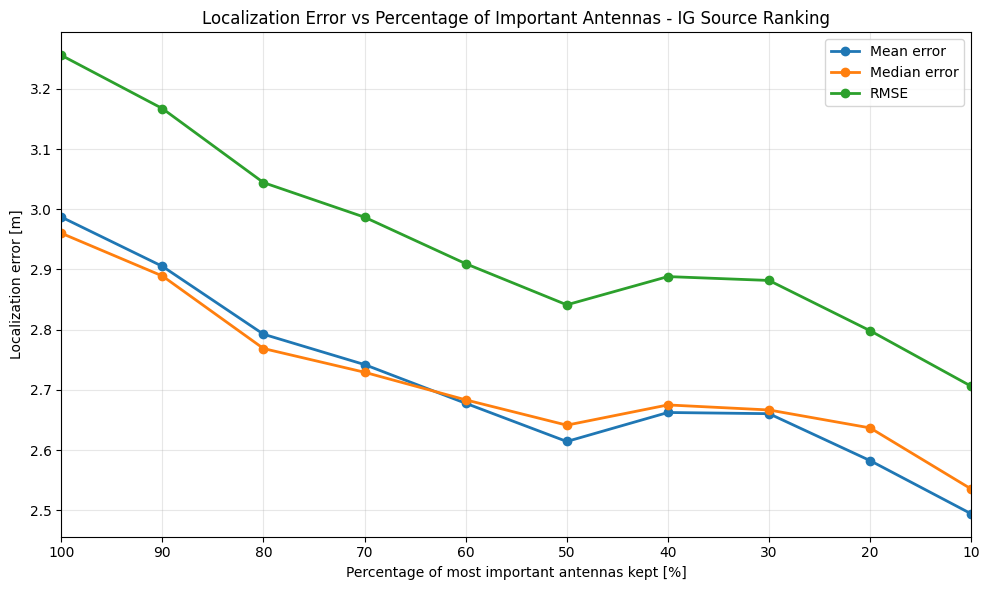


RANDOM ANTENNA SELECTION ABLATION

--------------------------------------------------------------------------------
Random antenna ablation: keeping 100%
Keeping 32/32 antennas
Repeats: 20
Mean error:   2.9872 ± 0.0000 m
Median error: 2.9603 ± 0.0000 m
RMSE error:   3.2560 ± 0.0000 m

--------------------------------------------------------------------------------
Random antenna ablation: keeping 90%
Keeping 29/32 antennas
Repeats: 20
Mean error:   2.9384 ± 0.0340 m
Median error: 2.9121 ± 0.0467 m
RMSE error:   3.2019 ± 0.0359 m

--------------------------------------------------------------------------------
Random antenna ablation: keeping 80%
Keeping 26/32 antennas
Repeats: 20
Mean error:   2.9036 ± 0.0488 m
Median error: 2.8853 ± 0.0496 m
RMSE error:   3.1587 ± 0.0551 m

--------------------------------------------------------------------------------
Random antenna ablation: keeping 70%
Keeping 22/32 antennas
Repeats: 20
Mean error:   2.8287 ± 0.0625 m
Median error: 2.8169 ± 0.061

,keep_percentage,keep_count,mean_error,median_error,rmse_error,mean_error_std,median_error_std,rmse_error_std
0,100,32,2.987196,2.960308,3.256045,0.000000,0.000000,0.000000
1,90,29,2.938388,2.912127,3.201872,0.033990,0.046662,0.035886
2,80,26,2.903642,2.885331,3.158662,0.048778,0.049557,0.055068
3,70,22,2.828685,2.816905,3.077329,0.062525,0.061364,0.069297
4,60,19,2.759399,2.761175,2.995644,0.064289,0.069506,0.069199
5,50,16,2.732660,2.737867,2.964773,0.073974,0.077483,0.081599
6,40,13,2.640798,2.644579,2.868171,0.064533,0.065580,0.066266
7,30,10,2.554030,2.568153,2.770634,0.048248,0.054330,0.052112
8,20,6,2.510436,2.557076,2.713960,0.050272,0.053204,0.055653
9,10,3,2.428467,2.496072,2.624568,0.036564,0.045391,0.038541


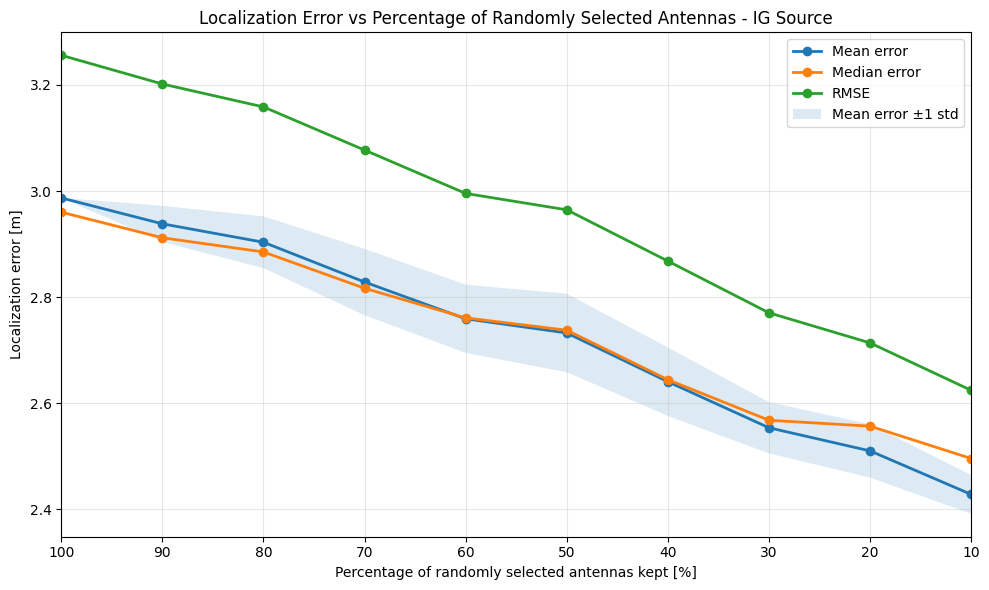

In [ ]:
# ============================================================
# IG Source Ranking Ablation + Random Antenna Ablation
# Two plots:
# 1) Most important antennas from ig_source_model ranking
# 2) Randomly selected antennas
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RESULT_DIR = "antenna_ablation_results_ig_source"
os.makedirs(RESULT_DIR, exist_ok=True)

RANDOM_SELECTION_SEED = 42
rng = np.random.default_rng(RANDOM_SELECTION_SEED)

KEEP_PERCENTAGES = [100, 90, 80, 70, 60, 50, 40, 30, 20, 10]
RANDOM_SELECTION_REPEATS = 20


# ------------------------------------------------------------
# 1. Required objects check
# ------------------------------------------------------------

if "antenna_ranking_global_ig_source" not in globals():
    raise RuntimeError(
        "antenna_ranking_global_ig_source not found. "
        "Run IG source ranking cell first."
    )

antenna_ranking_global_ig_source = np.asarray(
    antenna_ranking_global_ig_source,
    dtype=int
)

if antenna_ranking_global_ig_source.shape[0] != 32:
    raise ValueError(
        f"Expected 32 antennas in ranking, got {antenna_ranking_global_ig_source.shape}"
    )

if "nn" in globals() and hasattr(nn, "predict"):
    ablation_model = nn
    print("Using model for ablation: nn")
elif "ablation_model" in globals() and hasattr(ablation_model, "predict"):
    print("Using existing ablation_model")
else:
    raise RuntimeError(
        "No trained ablation model found. Train/load nn or set ablation_model first."
    )

if "test_runs" not in globals():
    raise RuntimeError("test_runs not found. Load cached runs first.")

if "train_runs" not in globals():
    raise RuntimeError("train_runs not found. Need train mean for masking.")


# ------------------------------------------------------------
# 2. Test data for evaluation only
# ------------------------------------------------------------

X_ablation_ig_source = np.concatenate(
    [run["X_csi"] for run in test_runs],
    axis=0
).astype(np.float32)

y_ablation_ig_source = np.concatenate(
    [run["pos"] for run in test_runs],
    axis=0
).astype(np.float32)

print("X_ablation_ig_source:", X_ablation_ig_source.shape)
print("y_ablation_ig_source:", y_ablation_ig_source.shape)


# ------------------------------------------------------------
# 3. Train mean masking only
# ------------------------------------------------------------

X_train_for_mean = np.concatenate(
    [run["X_csi"] for run in train_runs],
    axis=0
).astype(np.float32)

train_antenna_mean = np.mean(
    X_train_for_mean,
    axis=0,
    keepdims=True
).astype(np.float32)

print("train_antenna_mean:", train_antenna_mean.shape)


def mask_antennas_with_train_mean(X, keep_indices):
    X_masked = X.copy()

    all_indices = np.arange(32)
    keep_indices = np.asarray(keep_indices, dtype=int)

    remove_indices = np.array(
        [i for i in all_indices if i not in set(keep_indices)],
        dtype=int
    )

    X_masked[:, remove_indices, ...] = train_antenna_mean[:, remove_indices, ...]

    return X_masked, remove_indices


# ------------------------------------------------------------
# 4. Metrics
# ------------------------------------------------------------

def compute_localization_metrics(y_true, y_pred):
    errors = np.linalg.norm(
        y_true - y_pred,
        axis=1
    )

    return {
        "mean_error": float(np.mean(errors)),
        "median_error": float(np.median(errors)),
        "rmse_error": float(np.sqrt(np.mean(errors ** 2))),
    }, errors


# ============================================================
# PART A: Most important antenna ablation using IG source ranking
# ============================================================

important_ablation_results_ig_source = []

print("\n" + "=" * 80)
print("IG SOURCE RANKING ABLATION")
print("=" * 80)

for keep_percentage in KEEP_PERCENTAGES:

    keep_count = int(round(32 * keep_percentage / 100))
    keep_count = max(1, min(32, keep_count))

    selected_indices = antenna_ranking_global_ig_source[:keep_count]

    X_masked, removed_indices = mask_antennas_with_train_mean(
        X_ablation_ig_source,
        selected_indices
    )

    y_pred = ablation_model.predict(
        X_masked,
        batch_size=256,
        verbose=0
    )

    metrics, _ = compute_localization_metrics(
        y_ablation_ig_source,
        y_pred
    )

    row = {
        "keep_percentage": keep_percentage,
        "keep_count": keep_count,
        "mean_error": metrics["mean_error"],
        "median_error": metrics["median_error"],
        "rmse_error": metrics["rmse_error"],
    }

    important_ablation_results_ig_source.append(row)

    print(
        f"{keep_percentage}% | "
        f"Mean: {metrics['mean_error']:.4f} m | "
        f"Median: {metrics['median_error']:.4f} m | "
        f"RMSE: {metrics['rmse_error']:.4f} m"
    )


important_ablation_df_ig_source = pd.DataFrame(
    important_ablation_results_ig_source
)

important_ablation_df_ig_source.to_csv(
    os.path.join(
        RESULT_DIR,
        "ig_source_important_antenna_ablation_results.csv"
    ),
    index=False
)

display(important_ablation_df_ig_source)


# ------------------------------------------------------------
# Plot 1: Most important antennas from IG source ranking
# ------------------------------------------------------------

plot_df = important_ablation_df_ig_source.sort_values(
    "keep_percentage",
    ascending=False
).copy()

plt.figure(figsize=(10, 6))

plt.plot(
    plot_df["keep_percentage"],
    plot_df["mean_error"],
    marker="o",
    linewidth=2,
    label="Mean error"
)

plt.plot(
    plot_df["keep_percentage"],
    plot_df["median_error"],
    marker="o",
    linewidth=2,
    label="Median error"
)

plt.plot(
    plot_df["keep_percentage"],
    plot_df["rmse_error"],
    marker="o",
    linewidth=2,
    label="RMSE"
)

plt.xlabel("Percentage of most important antennas kept [%]")
plt.ylabel("Localization error [m]")
plt.title("Localization Error vs Percentage of Important Antennas - IG Source Ranking")

plt.xlim(100, 10)
plt.xticks(KEEP_PERCENTAGES)

plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig(
    os.path.join(
        RESULT_DIR,
        "ig_source_important_antennas_error_vs_percentage.png"
    ),
    dpi=250
)

plt.show()


# ============================================================
# PART B: Random antenna selection ablation
# ============================================================

random_ablation_results_ig_source = []

print("\n" + "=" * 80)
print("RANDOM ANTENNA SELECTION ABLATION")
print("=" * 80)

for keep_percentage in KEEP_PERCENTAGES:

    keep_count = int(round(32 * keep_percentage / 100))
    keep_count = max(1, min(32, keep_count))

    mean_errors = []
    median_errors = []
    rmse_errors = []

    print("\n" + "-" * 80)
    print(f"Random antenna ablation: keeping {keep_percentage}%")
    print(f"Keeping {keep_count}/32 antennas")
    print(f"Repeats: {RANDOM_SELECTION_REPEATS}")

    for repeat in range(RANDOM_SELECTION_REPEATS):

        random_indices = rng.choice(
            32,
            size=keep_count,
            replace=False
        )

        X_masked, _ = mask_antennas_with_train_mean(
            X_ablation_ig_source,
            random_indices
        )

        y_pred = ablation_model.predict(
            X_masked,
            batch_size=256,
            verbose=0
        )

        metrics, _ = compute_localization_metrics(
            y_ablation_ig_source,
            y_pred
        )

        mean_errors.append(metrics["mean_error"])
        median_errors.append(metrics["median_error"])
        rmse_errors.append(metrics["rmse_error"])

    row = {
        "keep_percentage": keep_percentage,
        "keep_count": keep_count,
        "mean_error": float(np.mean(mean_errors)),
        "median_error": float(np.mean(median_errors)),
        "rmse_error": float(np.mean(rmse_errors)),
        "mean_error_std": float(np.std(mean_errors)),
        "median_error_std": float(np.std(median_errors)),
        "rmse_error_std": float(np.std(rmse_errors)),
    }

    random_ablation_results_ig_source.append(row)

    print(f"Mean error:   {row['mean_error']:.4f} ± {row['mean_error_std']:.4f} m")
    print(f"Median error: {row['median_error']:.4f} ± {row['median_error_std']:.4f} m")
    print(f"RMSE error:   {row['rmse_error']:.4f} ± {row['rmse_error_std']:.4f} m")


random_ablation_df_ig_source = pd.DataFrame(
    random_ablation_results_ig_source
)

random_ablation_df_ig_source.to_csv(
    os.path.join(
        RESULT_DIR,
        "ig_source_random_antenna_ablation_results.csv"
    ),
    index=False
)

display(random_ablation_df_ig_source)


# ------------------------------------------------------------
# Plot 2: Randomly selected antennas
# ------------------------------------------------------------

random_plot_df = random_ablation_df_ig_source.sort_values(
    "keep_percentage",
    ascending=False
).copy()

plt.figure(figsize=(10, 6))

plt.plot(
    random_plot_df["keep_percentage"],
    random_plot_df["mean_error"],
    marker="o",
    linewidth=2,
    label="Mean error"
)

plt.plot(
    random_plot_df["keep_percentage"],
    random_plot_df["median_error"],
    marker="o",
    linewidth=2,
    label="Median error"
)

plt.plot(
    random_plot_df["keep_percentage"],
    random_plot_df["rmse_error"],
    marker="o",
    linewidth=2,
    label="RMSE"
)

plt.fill_between(
    random_plot_df["keep_percentage"],
    random_plot_df["mean_error"] - random_plot_df["mean_error_std"],
    random_plot_df["mean_error"] + random_plot_df["mean_error_std"],
    alpha=0.15,
    label="Mean error ±1 std"
)

plt.xlabel("Percentage of randomly selected antennas kept [%]")
plt.ylabel("Localization error [m]")
plt.title("Localization Error vs Percentage of Randomly Selected Antennas - IG Source")

plt.xlim(100, 10)
plt.xticks(KEEP_PERCENTAGES)

plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig(
    os.path.join(
        RESULT_DIR,
        "ig_source_random_antennas_error_vs_percentage.png"
    ),
    dpi=250
)

plt.show()

**XGBOOST**

In [ ]:
# # ============================================================
# # XGBoost Antenna Ranking
# # Ranking computed from Train + Validation only
# # ============================================================

# import os
# import numpy as np
# import pandas as pd

# try:
#     import xgboost as xgb
# except ImportError:
#     !pip install xgboost -q
#     import xgboost as xgb

# from sklearn.multioutput import MultiOutputRegressor

# RESULT_DIR = "antenna_ranking_results"
# os.makedirs(RESULT_DIR, exist_ok=True)

# # ------------------------------------------------------------
# # 1. Prepare Train + Validation data
# # ------------------------------------------------------------

# X_train_xgb = np.concatenate(
#     [run["X_csi"] for run in train_runs],
#     axis=0
# ).astype(np.float32)

# y_train_xgb = np.concatenate(
#     [run["pos"] for run in train_runs],
#     axis=0
# ).astype(np.float32)

# X_val_xgb = np.concatenate(
#     [run["X_csi"] for run in val_runs],
#     axis=0
# ).astype(np.float32)

# y_val_xgb = np.concatenate(
#     [run["pos"] for run in val_runs],
#     axis=0
# ).astype(np.float32)

# X_xgb = np.concatenate(
#     [X_train_xgb, X_val_xgb],
#     axis=0
# )

# y_xgb = np.concatenate(
#     [y_train_xgb, y_val_xgb],
#     axis=0
# )

# print("X_xgb original:", X_xgb.shape)
# print("y_xgb:", y_xgb.shape)

# # Flatten CSI: (samples, 32, 32, 2) -> (samples, 2048)
# X_xgb_flat = X_xgb.reshape(X_xgb.shape[0], -1)

# print("X_xgb flat:", X_xgb_flat.shape)


# # ------------------------------------------------------------
# # 2. Train XGBoost model
# # ------------------------------------------------------------

# base_xgb = xgb.XGBRegressor(
#     n_estimators=300,
#     max_depth=4,
#     learning_rate=0.05,
#     subsample=0.85,
#     colsample_bytree=0.85,
#     objective="reg:squarederror",
#     tree_method="hist",
#     random_state=42,
#     n_jobs=-1,
#     importance_type="gain"
# )

# xgb_model = MultiOutputRegressor(base_xgb)

# xgb_model.fit(
#     X_xgb_flat,
#     y_xgb
# )

# print("XGBoost model trained.")


# # ------------------------------------------------------------
# # 3. Extract feature importance for x and y outputs
# # ------------------------------------------------------------

# importance_x = xgb_model.estimators_[0].feature_importances_
# importance_y = xgb_model.estimators_[1].feature_importances_

# feature_importance_xgb = (
#     importance_x + importance_y
# ) / 2.0

# print("Feature importance shape:", feature_importance_xgb.shape)


# # ------------------------------------------------------------
# # 4. Convert feature importance to antenna importance
# # ------------------------------------------------------------

# importance_map_xgb = feature_importance_xgb.reshape(
#     32, 32, 2
# )

# # Combine Mag + Phase
# importance_mag_phase_xgb = np.sqrt(
#     importance_map_xgb[:, :, 0] ** 2 +
#     importance_map_xgb[:, :, 1] ** 2
# )

# # Average over subcarrier groups
# global_importance_xgb = np.mean(
#     importance_mag_phase_xgb,
#     axis=1
# )

# antenna_ranking_global_xgb = np.argsort(
#     global_importance_xgb
# )[::-1]

# antenna_ranking_names_xgb = [
#     f"A{i + 1}" for i in antenna_ranking_global_xgb
# ]


# # ------------------------------------------------------------
# # 5. Save ranking
# # ------------------------------------------------------------

# xgb_ranking_df = pd.DataFrame({
#     "rank": np.arange(1, 33),
#     "antenna_index": antenna_ranking_global_xgb,
#     "antenna_name": antenna_ranking_names_xgb,
#     "importance": global_importance_xgb[antenna_ranking_global_xgb]
# })

# xgb_ranking_df.to_csv(
#     os.path.join(
#         RESULT_DIR,
#         "xgboost_antenna_ranking_train_val.csv"
#     ),
#     index=False
# )

# print("\nXGBoost antenna ranking from Train + Validation:")
# print(antenna_ranking_names_xgb)

# display(xgb_ranking_df)

**Ensemble Model**

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive mounted.
Models will be saved in:
/content/drive/MyDrive/DICHASUS_tracking_experiments/current_cnn_ig_source/saved_tracking_ablation_models

Results will be saved in:
/content/drive/MyDrive/DICHASUS_tracking_experiments/current_cnn_ig_source/saved_tracking_ablation_results

All required objects exist.

Using antenna ranking from IG Source Model.
IG Source Model antenna ranking indices:
[26 21 15  8 28 25 30  1  6 11  3 13  5  4 10 23 17 12 24 29  2 20  7 27
 14 18  9 22 19 16  0 31]

IG Source Model antenna ranking names:
['A27', 'A22', 'A16', 'A9', 'A29', 'A26', 'A31', 'A2', 'A7', 'A12', 'A4', 'A14', 'A6', 'A5', 'A11', 'A24', 'A18', 'A13', 'A25', 'A30', 'A3', 'A21', 'A8', 'A28', 'A15', 'A19', 'A10', 'A23', 'A20', 'A17', 'A1', 'A32']

Top 10 antennas from IG Source Model:
Rank 1: index 26, name A27, importance = 0.01292850
Rank 2: index 21, name 

,model_type,requested_percentage,actual_percentage,kept_antennas,removed_antennas,selected_antennas_indices,selected_antennas_names,best_model_path,final_model_path,normalization_path,...,test_p90_error_m,test_p95_error_m,test_acc_5cm_percent,test_acc_10cm_percent,test_acc_20cm_percent,test_acc_30cm_percent,test_acc_50cm_percent,epochs_trained,best_val_loss,final_val_loss
0,CurrentCNN_CSI_Position,100,100.000,32,0,"[26, 21, 15, 8, 28, 25, 30, 1, 6, 11, 3, 13, 5...","['A27', 'A22', 'A16', 'A9', 'A29', 'A26', 'A31...",/content/drive/MyDrive/DICHASUS_tracking_exper...,/content/drive/MyDrive/DICHASUS_tracking_exper...,/content/drive/MyDrive/DICHASUS_tracking_exper...,...,0.071974,0.089666,65.145746,96.494223,99.881828,99.986870,100.0,22,0.000379,0.000568
1,CurrentCNN_CSI_Position,90,90.625,29,3,"[26, 21, 15, 8, 28, 25, 30, 1, 6, 11, 3, 13, 5...","['A27', 'A22', 'A16', 'A9', 'A29', 'A26', 'A31...",/content/drive/MyDrive/DICHASUS_tracking_exper...,/content/drive/MyDrive/DICHASUS_tracking_exper...,/content/drive/MyDrive/DICHASUS_tracking_exper...,...,0.058751,0.063511,84.145221,98.988971,99.862132,99.973739,100.0,24,0.000203,0.000392
2,CurrentCNN_CSI_Position,80,81.250,26,6,"[26, 21, 15, 8, 28, 25, 30, 1, 6, 11, 3, 13, 5...","['A27', 'A22', 'A16', 'A9', 'A29', 'A26', 'A31...",/content/drive/MyDrive/DICHASUS_tracking_exper...,/content/drive/MyDrive/DICHASUS_tracking_exper...,/content/drive/MyDrive/DICHASUS_tracking_exper...,...,0.084866,0.090769,68.080357,96.448267,99.881828,99.973739,100.0,21,0.000371,0.000723
3,CurrentCNN_CSI_Position,70,71.875,23,9,"[26, 21, 15, 8, 28, 25, 30, 1, 6, 11, 3, 13, 5...","['A27', 'A22', 'A16', 'A9', 'A29', 'A26', 'A31...",/content/drive/MyDrive/DICHASUS_tracking_exper...,/content/drive/MyDrive/DICHASUS_tracking_exper...,/content/drive/MyDrive/DICHASUS_tracking_exper...,...,0.084674,0.096328,54.418330,96.152836,99.927784,99.973739,100.0,20,0.000518,0.000828
4,CurrentCNN_CSI_Position,60,62.500,20,12,"[26, 21, 15, 8, 28, 25, 30, 1, 6, 11, 3, 13, 5...","['A27', 'A22', 'A16', 'A9', 'A29', 'A26', 'A31...",/content/drive/MyDrive/DICHASUS_tracking_exper...,/content/drive/MyDrive/DICHASUS_tracking_exper...,/content/drive/MyDrive/DICHASUS_tracking_exper...,...,0.107194,0.119041,51.903887,86.968225,99.908088,99.973739,100.0,20,0.000739,0.001277
5,CurrentCNN_CSI_Position,50,50.000,16,16,"[26, 21, 15, 8, 28, 25, 30, 1, 6, 11, 3, 13, 5...","['A27', 'A22', 'A16', 'A9', 'A29', 'A26', 'A31...",/content/drive/MyDrive/DICHASUS_tracking_exper...,/content/drive/MyDrive/DICHASUS_tracking_exper...,/content/drive/MyDrive/DICHASUS_tracking_exper...,...,0.059588,0.074732,83.613445,99.153099,99.901523,99.973739,100.0,19,0.000252,0.000689
6,CurrentCNN_CSI_Position,40,40.625,13,19,"[26, 21, 15, 8, 28, 25, 30, 1, 6, 11, 3, 13, 5]","['A27', 'A22', 'A16', 'A9', 'A29', 'A26', 'A31...",/content/drive/MyDrive/DICHASUS_tracking_exper...,/content/drive/MyDrive/DICHASUS_tracking_exper...,/content/drive/MyDrive/DICHASUS_tracking_exper...,...,0.071017,0.080326,66.386555,98.890494,99.875263,99.980305,100.0,23,0.000358,0.000804
7,CurrentCNN_CSI_Position,30,31.250,10,22,"[26, 21, 15, 8, 28, 25, 30, 1, 6, 11]","['A27', 'A22', 'A16', 'A9', 'A29', 'A26', 'A31...",/content/drive/MyDrive/DICHASUS_tracking_exper...,/content/drive/MyDrive/DICHASUS_tracking_exper...,/content/drive/MyDrive/DICHASUS_tracking_exper...,...,0.056033,0.061846,79.234506,99.573267,99.934349,99.986870,100.0,23,0.000237,0.000666
8,CurrentCNN_CSI_Position,20,21.875,7,25,"[26, 21, 15, 8, 28, 25, 30]","['A27', 'A22', 'A16', 'A9', 'A29', 'A26', 'A31']",/content/drive/MyDrive/DICHASUS_tracking_exper...,/content/drive/MyDrive/DICHASUS_tracking_exper...,/content/drive/MyDrive/DICHASUS_tracking_exper...,...,0.051077,0.059604,89.128151,99.599527,99.934349,99.980305,100.0,23,0.000205,0.000335
9,CurrentCNN_CSI_Position,10,12.500,4,28,"[26, 21, 15, 8]","['A27', 'A22', 'A16', 'A9']",/content/drive/MyDrive/DICHASUS_tracking_exper...,/content/drive/MyDrive/DICHASUS_tracking_exper...,/content/dr

Final summary saved to: /content/drive/MyDrive/DICHASUS_tracking_experiments/current_cnn_ig_source/saved_tracking_ablation_results/ig_source_tracking_percentage_ablation_csi_summary_final.csv

Validation-Based Antenna Reduction Analysis
Best absolute model by validation mean error:
model_type                                             CurrentCNN_CSI_Position
requested_percentage                                                        90
actual_percentage                                                       90.625
kept_antennas                                                               29
removed_antennas                                                             3
selected_antennas_indices    [26, 21, 15, 8, 28, 25, 30, 1, 6, 11, 3, 13, 5...
selected_antennas_names      ['A27', 'A22', 'A16', 'A9', 'A29', 'A26', 'A31...
best_model_path              /content/drive/MyDrive/DICHASUS_tracking_exper...
final_model_path             /content/drive/MyDrive/DICHASUS_tracking_exper...
normal

,selection_protocol,test_usage,best_absolute_requested_percentage,best_absolute_actual_percentage,best_absolute_kept_antennas,best_absolute_val_mean_error_m,best_absolute_val_p90_error_m,best_p90_requested_percentage,best_p90_actual_percentage,best_p90_kept_antennas,best_p90_val_mean_error_m,best_p90_val_p90_error_m,best_tradeoff_requested_percentage,best_tradeoff_actual_percentage,best_tradeoff_kept_antennas,best_tradeoff_removed_antennas,best_tradeoff_val_mean_error_m,best_tradeoff_val_p90_error_m,acceptable_mean_increase_percent,acceptable_p90_increase_percent
0,validation_only,report_only_not_used_for_decisions,90,90.625,29,0.030193,0.050931,20,21.875,7,0.030801,0.050705,10,12.5,4,28,0.032539,0.056333,10.0,15.0



Selected Models Test Report Only


,requested_percentage,actual_percentage,kept_antennas,removed_antennas,val_mean_error_cm,val_p90_error_cm,test_mean_error_cm_report_only,test_median_error_cm_report_only,test_rmse_error_cm_report_only,test_p90_error_cm_report_only,test_p95_error_cm_report_only,test_acc_5cm_percent_report_only,test_acc_10cm_percent_report_only
0,10,12.500,4,28,3.253864,5.633334,3.370459,3.073365,3.891729,5.733461,6.620023,84.263393,99.566702
1,20,21.875,7,25,3.080126,5.070513,3.082609,2.781555,3.544817,5.107664,5.960364,89.128151,99.599527
2,90,90.625,29,3,3.019265,5.093092,3.298517,2.991169,3.912220,5.875068,6.351097,84.145221,98.988971


Selected models test report saved to: /content/drive/MyDrive/DICHASUS_tracking_experiments/current_cnn_ig_source/saved_tracking_ablation_results/selected_models_test_report_only.csv
Reminder: These test metrics are report-only and were not used for selection.


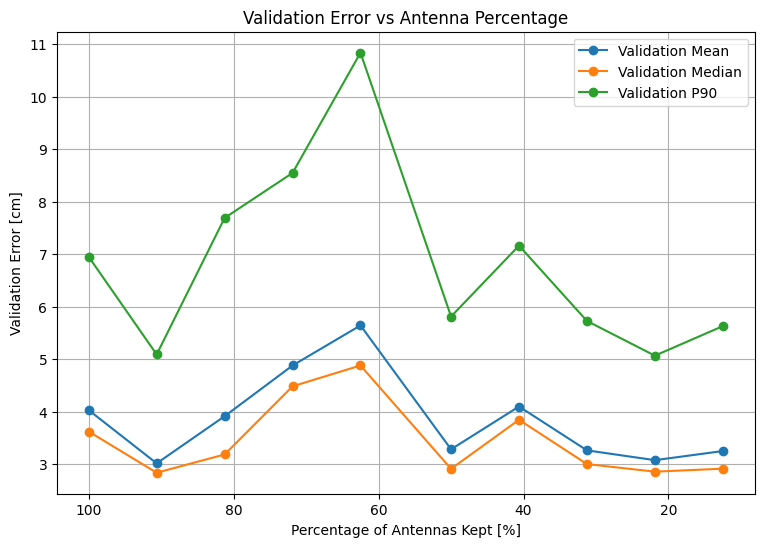

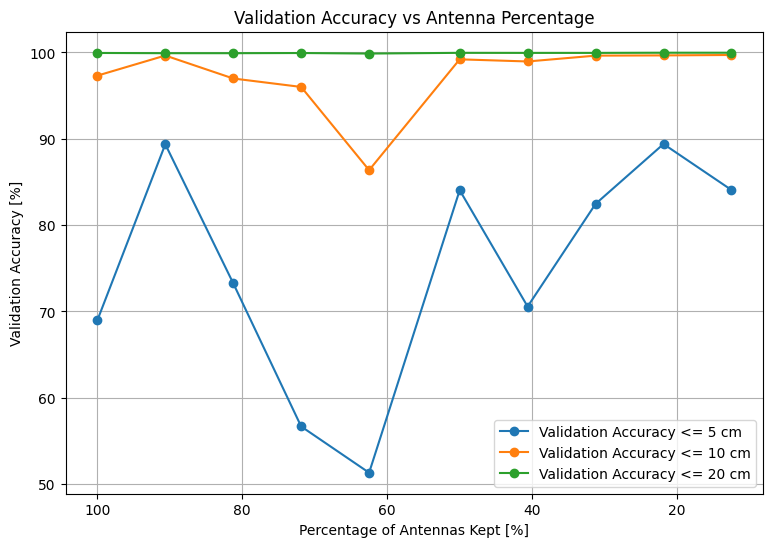

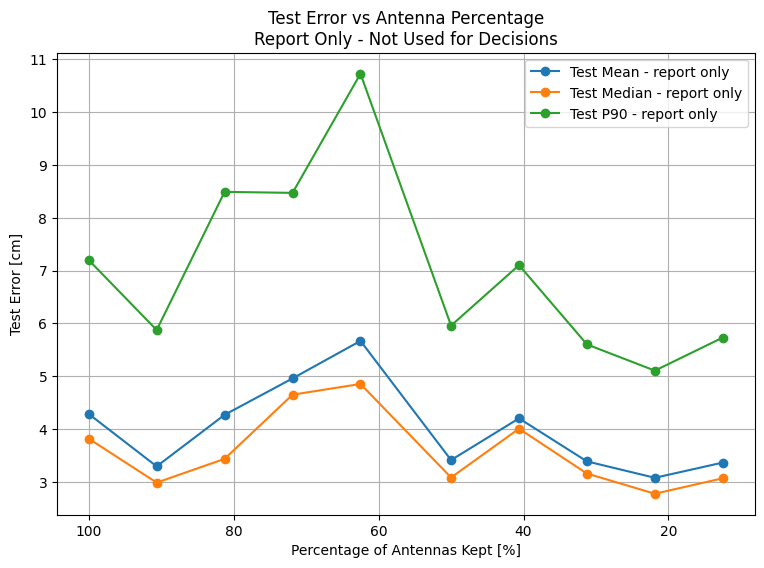


Done.
Models saved in:  /content/drive/MyDrive/DICHASUS_tracking_experiments/current_cnn_ig_source/saved_tracking_ablation_models
Results saved in: /content/drive/MyDrive/DICHASUS_tracking_experiments/current_cnn_ig_source/saved_tracking_ablation_results

Important:
Validation metrics are used for selection and trade-off decisions.
Test metrics are report-only and must not influence decisions.


In [ ]:
# ============================================================
# CSI-Aided Next-Step Tracking with IG Source Antenna Ablation
# Current CNN Model
#
# Train separate model for each antenna percentage
# Save all models, histories, normalization files, and summaries
# Resume-safe version for Google Colab / Google Drive
#
# IMPORTANT PROTOCOL:
#   - Validation metrics are used for model/percentage selection.
#   - Test metrics are reported only and must NOT be used for decisions.
# ============================================================

import os
import gc
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras import layers, Model


# ============================================================
# Optional: Mount Google Drive
# ============================================================
# In Colab, this ensures models/results are not lost after runtime reset.

USE_GOOGLE_DRIVE = True

if USE_GOOGLE_DRIVE:
    try:
        from google.colab import drive
        drive.mount("/content/drive")
        print("Google Drive mounted.")
    except Exception as e:
        print("Could not mount Google Drive.")
        print("If you are not in Colab, this is fine.")
        print(e)


# ============================================================
# Global settings
# ============================================================

SEED = 42
BATCH_SIZE = 64
EPOCHS = 150
HORIZON = 1

np.random.seed(SEED)
tf.random.set_seed(SEED)


# ============================================================
# Output folders
# ============================================================
# If you are using Colab, keep this path on Google Drive.
# You can change the folder name if needed.

if USE_GOOGLE_DRIVE:
    BASE_SAVE_DIR = "/content/drive/MyDrive/DICHASUS_tracking_experiments/current_cnn_ig_source"
else:
    BASE_SAVE_DIR = "DICHASUS_tracking_experiments/current_cnn_ig_source"

MODEL_SAVE_DIR = os.path.join(
    BASE_SAVE_DIR,
    "saved_tracking_ablation_models"
)

RESULT_SAVE_DIR = os.path.join(
    BASE_SAVE_DIR,
    "saved_tracking_ablation_results"
)

os.makedirs(MODEL_SAVE_DIR, exist_ok=True)
os.makedirs(RESULT_SAVE_DIR, exist_ok=True)

print("Models will be saved in:")
print(MODEL_SAVE_DIR)

print("\nResults will be saved in:")
print(RESULT_SAVE_DIR)


# ============================================================
# Safety checks
# ============================================================

required_objects = [
    "train_runs",
    "val_runs",
    "test_runs",
    "global_importance_ig_source",
    "antenna_ranking_global_ig_source",
]

for obj in required_objects:
    if obj not in globals():
        raise RuntimeError(
            f"{obj} is not defined. "
            f"Run the preprocessing and IG Source Model ranking cells first."
        )

print("\nAll required objects exist.")


# ============================================================
# Use antenna ranking from IG Source Model
# ============================================================

antenna_ranking = np.asarray(
    antenna_ranking_global_ig_source,
    dtype=np.int32
)

global_importance_vector = np.asarray(
    global_importance_ig_source,
    dtype=np.float32
)

if antenna_ranking.shape[0] != 32:
    raise ValueError(
        f"Expected antenna_ranking shape (32,), got {antenna_ranking.shape}"
    )

if global_importance_vector.shape[0] != 32:
    raise ValueError(
        f"Expected global_importance_vector shape (32,), got {global_importance_vector.shape}"
    )

antenna_ranking_names = [f"A{i + 1}" for i in antenna_ranking]

print("\nUsing antenna ranking from IG Source Model.")
print("IG Source Model antenna ranking indices:")
print(antenna_ranking)

print("\nIG Source Model antenna ranking names:")
print(antenna_ranking_names)

print("\nTop 10 antennas from IG Source Model:")
for rank, ant_idx in enumerate(antenna_ranking[:10], start=1):
    print(
        f"Rank {rank}: index {ant_idx}, "
        f"name A{ant_idx + 1}, "
        f"importance = {global_importance_vector[ant_idx]:.8f}"
    )


# ============================================================
# Antenna mask builder by percentage
# ============================================================

def create_topk_antenna_mask_by_percentage(
    antenna_ranking,
    percentage=100,
    num_antennas=32
):
    k = int(np.ceil(num_antennas * percentage / 100.0))
    k = max(1, min(k, num_antennas))

    mask = np.zeros(num_antennas, dtype=np.float32)

    selected_antennas = antenna_ranking[:k]
    selected_antenna_names = [f"A{i + 1}" for i in selected_antennas]

    mask[selected_antennas] = 1.0

    actual_percentage = 100.0 * k / num_antennas

    return mask, selected_antennas, selected_antenna_names, k, actual_percentage


# ============================================================
# Build sequential tracking arrays
# ============================================================

def build_tracking_arrays_from_runs(
    runs,
    antenna_mask,
    horizon=1
):
    X_pos_t_list = []
    X_csi_tplus1_list = []
    X_mask_list = []
    y_pos_tplus1_list = []

    for run_idx, run in enumerate(runs):
        if "X_csi" not in run:
            raise KeyError(f"Run {run_idx} does not contain key 'X_csi'.")

        if "pos" not in run:
            raise KeyError(f"Run {run_idx} does not contain key 'pos'.")

        X_csi = run["X_csi"].astype(np.float32)
        pos = run["pos"].astype(np.float32)

        if len(X_csi) != len(pos):
            raise ValueError(
                f"Run {run_idx}: X_csi and pos have different lengths. "
                f"X_csi length = {len(X_csi)}, pos length = {len(pos)}"
            )

        if len(X_csi) <= horizon:
            print(f"Skipping run {run_idx}: too short.")
            continue

        # position(t)
        pos_t = pos[:-horizon]

        # CSI(t+1)
        csi_tplus1 = X_csi[horizon:]

        # position(t+1)
        pos_tplus1 = pos[horizon:]

        mask_repeated = np.repeat(
            antenna_mask[None, :],
            repeats=pos_t.shape[0],
            axis=0
        ).astype(np.float32)

        X_pos_t_list.append(pos_t)
        X_csi_tplus1_list.append(csi_tplus1)
        X_mask_list.append(mask_repeated)
        y_pos_tplus1_list.append(pos_tplus1)

    if len(X_pos_t_list) == 0:
        raise RuntimeError("No valid runs found for tracking array construction.")

    X_pos_t_all = np.concatenate(X_pos_t_list, axis=0).astype(np.float32)
    X_csi_tplus1_all = np.concatenate(X_csi_tplus1_list, axis=0).astype(np.float32)
    X_mask_all = np.concatenate(X_mask_list, axis=0).astype(np.float32)
    y_pos_tplus1_all = np.concatenate(y_pos_tplus1_list, axis=0).astype(np.float32)

    return X_pos_t_all, X_csi_tplus1_all, X_mask_all, y_pos_tplus1_all


# ============================================================
# Normalization
# ============================================================

def compute_csi_normalization_stats(X_train_csi):
    csi_mean = X_train_csi.mean(
        axis=(0, 1, 2),
        keepdims=True
    ).astype(np.float32)

    csi_std = X_train_csi.std(
        axis=(0, 1, 2),
        keepdims=True
    ).astype(np.float32) + 1e-8

    return csi_mean, csi_std


def normalize_csi(X_csi, csi_mean, csi_std):
    return ((X_csi - csi_mean) / csi_std).astype(np.float32)


def compute_position_normalization_stats(y_train):
    pos_mean = y_train.mean(
        axis=0,
        keepdims=True
    ).astype(np.float32)

    pos_std = y_train.std(
        axis=0,
        keepdims=True
    ).astype(np.float32) + 1e-8

    return pos_mean, pos_std


def normalize_position(pos, pos_mean, pos_std):
    return ((pos - pos_mean) / pos_std).astype(np.float32)


def denormalize_position(pos_norm, pos_mean, pos_std):
    return (pos_norm * pos_std + pos_mean).astype(np.float32)


# ============================================================
# TensorFlow dataset builder
# ============================================================

def make_tracking_dataset(
    X_pos_t_norm,
    X_csi_tplus1_norm,
    X_mask,
    y_pos_tplus1_norm,
    batch_size=64,
    shuffle=False,
    seed=42
):
    inputs = {
        "position_t_input": X_pos_t_norm.astype(np.float32),
        "csi_tplus1_input": X_csi_tplus1_norm.astype(np.float32),
        "antenna_mask_input": X_mask.astype(np.float32),
    }

    targets = y_pos_tplus1_norm.astype(np.float32)

    dataset = tf.data.Dataset.from_tensor_slices((inputs, targets))

    if shuffle:
        dataset = dataset.shuffle(
            buffer_size=min(len(targets), 20000),
            seed=seed,
            reshuffle_each_iteration=True
        )

    dataset = dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)

    return dataset


# ============================================================
# Model architecture: Current CNN
# ============================================================

def build_tracking_csi_ablation_model(seed=42):
    tf.keras.backend.clear_session()
    np.random.seed(seed)
    tf.random.set_seed(seed)

    # ------------------------------
    # Inputs
    # ------------------------------

    position_t_input = tf.keras.Input(
        shape=(2,),
        name="position_t_input"
    )

    csi_tplus1_input = tf.keras.Input(
        shape=(32, 32, 2),
        name="csi_tplus1_input"
    )

    antenna_mask_input = tf.keras.Input(
        shape=(32,),
        name="antenna_mask_input"
    )

    # ------------------------------
    # Apply antenna mask
    # ------------------------------

    antenna_mask_reshaped = layers.Reshape(
        (32, 1, 1),
        name="antenna_mask_reshape"
    )(antenna_mask_input)

    masked_csi = layers.Multiply(
        name="masked_csi_tplus1"
    )([csi_tplus1_input, antenna_mask_reshaped])

    # ------------------------------
    # CSI branch
    # ------------------------------

    x = layers.Conv2D(
        32,
        kernel_size=(3, 3),
        padding="same",
        activation="relu",
        name="csi_conv_1"
    )(masked_csi)

    x = layers.BatchNormalization(
        name="csi_bn_1"
    )(x)

    x = layers.MaxPooling2D(
        pool_size=(2, 2),
        name="csi_pool_1"
    )(x)

    x = layers.Conv2D(
        64,
        kernel_size=(3, 3),
        padding="same",
        activation="relu",
        name="csi_conv_2"
    )(x)

    x = layers.BatchNormalization(
        name="csi_bn_2"
    )(x)

    x = layers.MaxPooling2D(
        pool_size=(2, 2),
        name="csi_pool_2"
    )(x)

    x = layers.Conv2D(
        128,
        kernel_size=(3, 3),
        padding="same",
        activation="relu",
        name="csi_conv_3"
    )(x)

    x = layers.BatchNormalization(
        name="csi_bn_3"
    )(x)

    avg_pool = layers.GlobalAveragePooling2D(
        name="csi_global_avg_pool"
    )(x)

    max_pool = layers.GlobalMaxPooling2D(
        name="csi_global_max_pool"
    )(x)

    csi_features = layers.Concatenate(
        name="csi_avg_max_features"
    )([avg_pool, max_pool])

    csi_features = layers.Dense(
        128,
        activation="relu",
        name="csi_dense_1"
    )(csi_features)

    csi_features = layers.Dropout(
        0.10,
        name="csi_dropout_1"
    )(csi_features)

    # ------------------------------
    # Position branch
    # ------------------------------

    p = layers.Dense(
        64,
        activation="relu",
        name="position_dense_1"
    )(position_t_input)

    p = layers.Dense(
        32,
        activation="relu",
        name="position_dense_2"
    )(p)

    # ------------------------------
    # Fusion
    # ------------------------------

    combined = layers.Concatenate(
        name="fusion_position_t_and_csi_tplus1"
    )([csi_features, p])

    z = layers.Dense(
        128,
        activation="relu",
        name="fusion_dense_1"
    )(combined)

    z = layers.Dropout(
        0.10,
        name="fusion_dropout_1"
    )(z)

    z = layers.Dense(
        64,
        activation="relu",
        name="fusion_dense_2"
    )(z)

    z = layers.Dropout(
        0.05,
        name="fusion_dropout_2"
    )(z)

    output = layers.Dense(
        2,
        activation="linear",
        name="position_tplus1_output"
    )(z)

    model = Model(
        inputs={
            "position_t_input": position_t_input,
            "csi_tplus1_input": csi_tplus1_input,
            "antenna_mask_input": antenna_mask_input,
        },
        outputs=output,
        name=f"tracking_csi_ablation_model_seed_{seed}"
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=2e-4),
        loss="mse",
        metrics=["mae"]
    )

    return model


# ============================================================
# Evaluation
# ============================================================

def evaluate_tracking_predictions(
    model,
    dataset,
    y_true_meter,
    pos_mean,
    pos_std,
    dataset_name="Dataset"
):
    y_pred_norm = model.predict(dataset, verbose=0)

    y_pred_meter = denormalize_position(
        y_pred_norm,
        pos_mean,
        pos_std
    )

    error_vectors = y_pred_meter - y_true_meter

    errors = np.sqrt(
        error_vectors[:, 0] ** 2 +
        error_vectors[:, 1] ** 2
    )

    results = {
        "mean_error_m": float(np.mean(errors)),
        "median_error_m": float(np.median(errors)),
        "rmse_error_m": float(np.sqrt(np.mean(errors ** 2))),
        "std_error_m": float(np.std(errors)),
        "min_error_m": float(np.min(errors)),
        "max_error_m": float(np.max(errors)),
        "p75_error_m": float(np.percentile(errors, 75)),
        "p90_error_m": float(np.percentile(errors, 90)),
        "p95_error_m": float(np.percentile(errors, 95)),
        "acc_5cm_percent": float(np.mean(errors <= 0.05) * 100),
        "acc_10cm_percent": float(np.mean(errors <= 0.10) * 100),
        "acc_20cm_percent": float(np.mean(errors <= 0.20) * 100),
        "acc_30cm_percent": float(np.mean(errors <= 0.30) * 100),
        "acc_50cm_percent": float(np.mean(errors <= 0.50) * 100),
        "errors": errors,
        "predictions_meter": y_pred_meter,
    }

    print()
    print(dataset_name)
    print("-" * 70)
    print(f"Mean Error:              {results['mean_error_m']:.4f} m")
    print(f"Median Error:            {results['median_error_m']:.4f} m")
    print(f"RMSE Error:              {results['rmse_error_m']:.4f} m")
    print(f"75th Percentile Error:   {results['p75_error_m']:.4f} m")
    print(f"90th Percentile Error:   {results['p90_error_m']:.4f} m")
    print(f"95th Percentile Error:   {results['p95_error_m']:.4f} m")
    print()
    print(f"Accuracy <= 5 cm:        {results['acc_5cm_percent']:.2f}%")
    print(f"Accuracy <= 10 cm:       {results['acc_10cm_percent']:.2f}%")
    print(f"Accuracy <= 20 cm:       {results['acc_20cm_percent']:.2f}%")
    print(f"Accuracy <= 30 cm:       {results['acc_30cm_percent']:.2f}%")
    print(f"Accuracy <= 50 cm:       {results['acc_50cm_percent']:.2f}%")
    print()

    return results


# ============================================================
# Plot helpers
# ============================================================

def plot_validation_error_vs_percentage(summary_df):
    plot_df = summary_df.sort_values(
        "actual_percentage",
        ascending=False
    )

    plt.figure(figsize=(9, 6))

    plt.plot(
        plot_df["actual_percentage"],
        plot_df["val_mean_error_m"] * 100,
        marker="o",
        label="Validation Mean"
    )

    plt.plot(
        plot_df["actual_percentage"],
        plot_df["val_median_error_m"] * 100,
        marker="o",
        label="Validation Median"
    )

    plt.plot(
        plot_df["actual_percentage"],
        plot_df["val_p90_error_m"] * 100,
        marker="o",
        label="Validation P90"
    )

    plt.gca().invert_xaxis()
    plt.xlabel("Percentage of Antennas Kept [%]")
    plt.ylabel("Validation Error [cm]")
    plt.title("Validation Error vs Antenna Percentage")
    plt.grid(True)
    plt.legend()
    plt.show()


def plot_test_error_report_only_vs_percentage(summary_df):
    plot_df = summary_df.sort_values(
        "actual_percentage",
        ascending=False
    )

    plt.figure(figsize=(9, 6))

    plt.plot(
        plot_df["actual_percentage"],
        plot_df["test_mean_error_m"] * 100,
        marker="o",
        label="Test Mean - report only"
    )

    plt.plot(
        plot_df["actual_percentage"],
        plot_df["test_median_error_m"] * 100,
        marker="o",
        label="Test Median - report only"
    )

    plt.plot(
        plot_df["actual_percentage"],
        plot_df["test_p90_error_m"] * 100,
        marker="o",
        label="Test P90 - report only"
    )

    plt.gca().invert_xaxis()
    plt.xlabel("Percentage of Antennas Kept [%]")
    plt.ylabel("Test Error [cm]")
    plt.title("Test Error vs Antenna Percentage\nReport Only - Not Used for Decisions")
    plt.grid(True)
    plt.legend()
    plt.show()


def plot_validation_accuracy_vs_percentage(summary_df):
    plot_df = summary_df.sort_values(
        "actual_percentage",
        ascending=False
    )

    plt.figure(figsize=(9, 6))

    plt.plot(
        plot_df["actual_percentage"],
        plot_df["val_acc_5cm_percent"],
        marker="o",
        label="Validation Accuracy <= 5 cm"
    )

    plt.plot(
        plot_df["actual_percentage"],
        plot_df["val_acc_10cm_percent"],
        marker="o",
        label="Validation Accuracy <= 10 cm"
    )

    plt.plot(
        plot_df["actual_percentage"],
        plot_df["val_acc_20cm_percent"],
        marker="o",
        label="Validation Accuracy <= 20 cm"
    )

    plt.gca().invert_xaxis()
    plt.xlabel("Percentage of Antennas Kept [%]")
    plt.ylabel("Validation Accuracy [%]")
    plt.title("Validation Accuracy vs Antenna Percentage")
    plt.grid(True)
    plt.legend()
    plt.show()


# ============================================================
# Ablation percentages
# ============================================================

ablation_percentages = [
    100, 90, 80, 70, 60, 50, 40, 30, 20, 10
]

# If later you want a finer version:
# ablation_percentages = [
#     100, 95, 90, 85, 80, 75, 70, 65, 60, 55,
#     50, 45, 40, 35, 30, 25, 20, 15, 10, 5
# ]


# ============================================================
# Resume support
# ============================================================

checkpoint_path = os.path.join(
    RESULT_SAVE_DIR,
    "ig_source_tracking_ablation_checkpoint_summary.csv"
)

FORCE_RETRAIN = False

if os.path.exists(checkpoint_path) and not FORCE_RETRAIN:
    checkpoint_df = pd.read_csv(checkpoint_path)

    done_percentages = set(
        checkpoint_df["requested_percentage"].astype(int).tolist()
    )

    ablation_summary = checkpoint_df.to_dict("records")

    print("\nExisting checkpoint found.")
    print("Already completed percentages:")
    print(sorted(done_percentages, reverse=True))

else:
    done_percentages = set()
    ablation_summary = []

    if FORCE_RETRAIN:
        print("\nFORCE_RETRAIN=True. Starting from scratch.")
    else:
        print("\nNo checkpoint found. Starting from scratch.")

ablation_error_curves = {}
ablation_predictions = {}
ablation_histories = {}

remaining_percentages = [
    p for p in ablation_percentages
    if int(p) not in done_percentages
]

print("\nRemaining percentages to train:")
print(remaining_percentages)


# ============================================================
# Main ablation experiment
# Train separate model for each percentage
# ============================================================

for percentage in ablation_percentages:

    if int(percentage) in done_percentages and not FORCE_RETRAIN:
        print()
        print("=" * 90)
        print(f"Skipping {percentage}% because it already exists in checkpoint.")
        print("=" * 90)
        continue

    print()
    print("=" * 90)
    print(f"Running IG Source ablation with requested top {percentage}% antennas")
    print("=" * 90)

    # --------------------------------------------------------
    # Create antenna mask
    # --------------------------------------------------------

    antenna_mask, selected_antennas, selected_antenna_names, num_selected_antennas, actual_percentage = (
        create_topk_antenna_mask_by_percentage(
            antenna_ranking=antenna_ranking,
            percentage=percentage,
            num_antennas=32
        )
    )

    num_removed_antennas = 32 - num_selected_antennas

    print(f"Requested percentage: {percentage}%")
    print(f"Actual percentage:    {actual_percentage:.2f}%")

    print(f"Selected antenna indices ({num_selected_antennas}/32):")
    print(selected_antennas)

    print(f"Selected antenna names ({num_selected_antennas}/32):")
    print(selected_antenna_names)

    print(f"Removed antennas: {num_removed_antennas}")

    # --------------------------------------------------------
    # Build arrays
    # --------------------------------------------------------

    X_train_pos_t, X_train_csi_tplus1, X_train_mask, y_train_pos_tplus1 = (
        build_tracking_arrays_from_runs(
            train_runs,
            antenna_mask=antenna_mask,
            horizon=HORIZON
        )
    )

    X_val_pos_t, X_val_csi_tplus1, X_val_mask, y_val_pos_tplus1 = (
        build_tracking_arrays_from_runs(
            val_runs,
            antenna_mask=antenna_mask,
            horizon=HORIZON
        )
    )

    X_test_pos_t, X_test_csi_tplus1, X_test_mask, y_test_pos_tplus1 = (
        build_tracking_arrays_from_runs(
            test_runs,
            antenna_mask=antenna_mask,
            horizon=HORIZON
        )
    )

    print("\nTrain shapes:")
    print("X_train_pos_t:", X_train_pos_t.shape)
    print("X_train_csi_tplus1:", X_train_csi_tplus1.shape)
    print("X_train_mask:", X_train_mask.shape)
    print("y_train_pos_tplus1:", y_train_pos_tplus1.shape)

    print("\nValidation shapes:")
    print("X_val_pos_t:", X_val_pos_t.shape)
    print("X_val_csi_tplus1:", X_val_csi_tplus1.shape)
    print("X_val_mask:", X_val_mask.shape)
    print("y_val_pos_tplus1:", y_val_pos_tplus1.shape)

    print("\nTest shapes:")
    print("X_test_pos_t:", X_test_pos_t.shape)
    print("X_test_csi_tplus1:", X_test_csi_tplus1.shape)
    print("X_test_mask:", X_test_mask.shape)
    print("y_test_pos_tplus1:", y_test_pos_tplus1.shape)

    # --------------------------------------------------------
    # Normalize using train only
    # --------------------------------------------------------

    csi_mean, csi_std = compute_csi_normalization_stats(
        X_train_csi_tplus1
    )

    pos_mean, pos_std = compute_position_normalization_stats(
        y_train_pos_tplus1
    )

    X_train_csi_tplus1_norm = normalize_csi(
        X_train_csi_tplus1,
        csi_mean,
        csi_std
    )

    X_val_csi_tplus1_norm = normalize_csi(
        X_val_csi_tplus1,
        csi_mean,
        csi_std
    )

    X_test_csi_tplus1_norm = normalize_csi(
        X_test_csi_tplus1,
        csi_mean,
        csi_std
    )

    X_train_pos_t_norm = normalize_position(
        X_train_pos_t,
        pos_mean,
        pos_std
    )

    X_val_pos_t_norm = normalize_position(
        X_val_pos_t,
        pos_mean,
        pos_std
    )

    X_test_pos_t_norm = normalize_position(
        X_test_pos_t,
        pos_mean,
        pos_std
    )

    y_train_pos_tplus1_norm = normalize_position(
        y_train_pos_tplus1,
        pos_mean,
        pos_std
    )

    y_val_pos_tplus1_norm = normalize_position(
        y_val_pos_tplus1,
        pos_mean,
        pos_std
    )

    y_test_pos_tplus1_norm = normalize_position(
        y_test_pos_tplus1,
        pos_mean,
        pos_std
    )

    print("\npos_mean:", pos_mean)
    print("pos_std:", pos_std)

    # --------------------------------------------------------
    # Create datasets
    # --------------------------------------------------------

    train_dataset = make_tracking_dataset(
        X_pos_t_norm=X_train_pos_t_norm,
        X_csi_tplus1_norm=X_train_csi_tplus1_norm,
        X_mask=X_train_mask,
        y_pos_tplus1_norm=y_train_pos_tplus1_norm,
        batch_size=BATCH_SIZE,
        shuffle=True,
        seed=SEED
    )

    val_dataset = make_tracking_dataset(
        X_pos_t_norm=X_val_pos_t_norm,
        X_csi_tplus1_norm=X_val_csi_tplus1_norm,
        X_mask=X_val_mask,
        y_pos_tplus1_norm=y_val_pos_tplus1_norm,
        batch_size=BATCH_SIZE,
        shuffle=False,
        seed=SEED
    )

    test_dataset = make_tracking_dataset(
        X_pos_t_norm=X_test_pos_t_norm,
        X_csi_tplus1_norm=X_test_csi_tplus1_norm,
        X_mask=X_test_mask,
        y_pos_tplus1_norm=y_test_pos_tplus1_norm,
        batch_size=BATCH_SIZE,
        shuffle=False,
        seed=SEED
    )

    # --------------------------------------------------------
    # Build model
    # --------------------------------------------------------

    model = build_tracking_csi_ablation_model(seed=SEED)

    # --------------------------------------------------------
    # Save paths
    # --------------------------------------------------------

    percentage_name = str(percentage).replace(".", "_")

    best_model_path = os.path.join(
        MODEL_SAVE_DIR,
        f"best_tracking_model_top_{percentage_name}_percent.keras"
    )

    final_model_path = os.path.join(
        MODEL_SAVE_DIR,
        f"final_tracking_model_top_{percentage_name}_percent.keras"
    )

    history_path = os.path.join(
        RESULT_SAVE_DIR,
        f"history_top_{percentage_name}_percent.csv"
    )

    norm_path = os.path.join(
        RESULT_SAVE_DIR,
        f"normalization_top_{percentage_name}_percent.npz"
    )

    # --------------------------------------------------------
    # Callbacks
    # --------------------------------------------------------

    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=15,
            restore_best_weights=True,
            verbose=1
        ),

        tf.keras.callbacks.ModelCheckpoint(
            filepath=best_model_path,
            monitor="val_loss",
            save_best_only=True,
            save_weights_only=False,
            verbose=1
        ),

        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=7,
            min_lr=1e-6,
            verbose=1
        )
    ]

    # --------------------------------------------------------
    # Train
    # --------------------------------------------------------

    history = model.fit(
        train_dataset,
        validation_data=val_dataset,
        epochs=EPOCHS,
        callbacks=callbacks,
        verbose=1
    )

    # Save final restored model
    model.save(final_model_path)

    print(f"Best model saved to:  {best_model_path}")
    print(f"Final model saved to: {final_model_path}")

    # --------------------------------------------------------
    # Save normalization stats and mask info
    # --------------------------------------------------------

    np.savez(
        norm_path,
        csi_mean=csi_mean,
        csi_std=csi_std,
        pos_mean=pos_mean,
        pos_std=pos_std,
        antenna_mask=antenna_mask,
        selected_antennas=selected_antennas,
        selected_antenna_names=np.array(selected_antenna_names),
        requested_percentage=percentage,
        actual_percentage=actual_percentage,
        num_selected_antennas=num_selected_antennas,
        num_removed_antennas=num_removed_antennas
    )

    print(f"Normalization/mask info saved to: {norm_path}")

    # --------------------------------------------------------
    # Save training history
    # --------------------------------------------------------

    history_df = pd.DataFrame(history.history)

    history_df.to_csv(
        history_path,
        index=False
    )

    print(f"Training history saved to: {history_path}")

    # --------------------------------------------------------
    # Evaluation
    # Validation = decision
    # Test = report only
    # --------------------------------------------------------

    val_results = evaluate_tracking_predictions(
        model=model,
        dataset=val_dataset,
        y_true_meter=y_val_pos_tplus1,
        pos_mean=pos_mean,
        pos_std=pos_std,
        dataset_name=f"Validation - Top {percentage}% requested antennas"
    )

    test_results = evaluate_tracking_predictions(
        model=model,
        dataset=test_dataset,
        y_true_meter=y_test_pos_tplus1,
        pos_mean=pos_mean,
        pos_std=pos_std,
        dataset_name=f"Test Report Only - Top {percentage}% requested antennas"
    )

    label = (
        f"Top {percentage}% requested "
        f"({num_selected_antennas}/32 ant., actual {actual_percentage:.1f}%)"
    )

    ablation_error_curves[label] = test_results["errors"]

    ablation_predictions[label] = {
        "y_true": y_test_pos_tplus1,
        "y_pred": test_results["predictions_meter"],
        "selected_antennas": selected_antennas,
        "selected_antenna_names": selected_antenna_names,
        "antenna_mask": antenna_mask,
        "pos_mean": pos_mean,
        "pos_std": pos_std,
        "requested_percentage": percentage,
        "actual_percentage": actual_percentage,
        "best_model_path": best_model_path,
        "final_model_path": final_model_path,
        "normalization_path": norm_path,
    }

    ablation_histories[label] = history.history

    ablation_summary.append({
        "model_type": "CurrentCNN_CSI_Position",
        "requested_percentage": percentage,
        "actual_percentage": actual_percentage,
        "kept_antennas": num_selected_antennas,
        "removed_antennas": num_removed_antennas,
        "selected_antennas_indices": selected_antennas.tolist(),
        "selected_antennas_names": selected_antenna_names,

        "best_model_path": best_model_path,
        "final_model_path": final_model_path,
        "normalization_path": norm_path,
        "history_path": history_path,

        # Validation metrics - used for decisions
        "val_mean_error_m": val_results["mean_error_m"],
        "val_median_error_m": val_results["median_error_m"],
        "val_rmse_error_m": val_results["rmse_error_m"],
        "val_std_error_m": val_results["std_error_m"],
        "val_p75_error_m": val_results["p75_error_m"],
        "val_p90_error_m": val_results["p90_error_m"],
        "val_p95_error_m": val_results["p95_error_m"],
        "val_acc_5cm_percent": val_results["acc_5cm_percent"],
        "val_acc_10cm_percent": val_results["acc_10cm_percent"],
        "val_acc_20cm_percent": val_results["acc_20cm_percent"],
        "val_acc_30cm_percent": val_results["acc_30cm_percent"],
        "val_acc_50cm_percent": val_results["acc_50cm_percent"],

        # Test metrics - report only
        "test_mean_error_m": test_results["mean_error_m"],
        "test_median_error_m": test_results["median_error_m"],
        "test_rmse_error_m": test_results["rmse_error_m"],
        "test_std_error_m": test_results["std_error_m"],
        "test_p75_error_m": test_results["p75_error_m"],
        "test_p90_error_m": test_results["p90_error_m"],
        "test_p95_error_m": test_results["p95_error_m"],
        "test_acc_5cm_percent": test_results["acc_5cm_percent"],
        "test_acc_10cm_percent": test_results["acc_10cm_percent"],
        "test_acc_20cm_percent": test_results["acc_20cm_percent"],
        "test_acc_30cm_percent": test_results["acc_30cm_percent"],
        "test_acc_50cm_percent": test_results["acc_50cm_percent"],

        "epochs_trained": len(history.history["loss"]),
        "best_val_loss": min(history.history["val_loss"]),
        "final_val_loss": history.history["val_loss"][-1],
    })

    # --------------------------------------------------------
    # Save checkpoint summary after every percentage
    # --------------------------------------------------------

    checkpoint_df = pd.DataFrame(ablation_summary)

    checkpoint_df.to_csv(
        checkpoint_path,
        index=False
    )

    print(f"Checkpoint summary saved to: {checkpoint_path}")

    # --------------------------------------------------------
    # Memory cleanup
    # --------------------------------------------------------

    del model
    del train_dataset
    del val_dataset
    del test_dataset

    del X_train_pos_t
    del X_train_csi_tplus1
    del X_train_mask
    del y_train_pos_tplus1

    del X_val_pos_t
    del X_val_csi_tplus1
    del X_val_mask
    del y_val_pos_tplus1

    del X_test_pos_t
    del X_test_csi_tplus1
    del X_test_mask
    del y_test_pos_tplus1

    gc.collect()
    tf.keras.backend.clear_session()

    print(f"Finished percentage {percentage}%")


# ============================================================
# Final summary table
# ============================================================

ablation_summary_df = pd.DataFrame(ablation_summary)

csi_ablation_summary_df = ablation_summary_df[
    ablation_summary_df["model_type"] == "CurrentCNN_CSI_Position"
].copy()

csi_ablation_summary_df = csi_ablation_summary_df.sort_values(
    "requested_percentage",
    ascending=False
).reset_index(drop=True)

print()
print("=" * 90)
print("Final Current CNN + CSI + Position Ablation Summary")
print("=" * 90)

display(csi_ablation_summary_df)

final_summary_path = os.path.join(
    RESULT_SAVE_DIR,
    "ig_source_tracking_percentage_ablation_csi_summary_final.csv"
)

csi_ablation_summary_df.to_csv(
    final_summary_path,
    index=False
)

print(f"Final summary saved to: {final_summary_path}")


# ============================================================
# Validation-based antenna reduction analysis
# ============================================================
# Goal:
#   Since the project goal is good accuracy with fewer important antennas,
#   we select a low-antenna trade-off using validation only.
#
# Test metrics are NOT used here.
# ============================================================

best_absolute_val_row = csi_ablation_summary_df.sort_values(
    "val_mean_error_m",
    ascending=True
).iloc[0]

best_val_mean_error = best_absolute_val_row["val_mean_error_m"]
best_val_p90_error = best_absolute_val_row["val_p90_error_m"]

acceptable_mean_increase_percent = 10.0
acceptable_p90_increase_percent = 15.0

max_allowed_val_mean_error = best_val_mean_error * (
    1.0 + acceptable_mean_increase_percent / 100.0
)

max_allowed_val_p90_error = best_val_p90_error * (
    1.0 + acceptable_p90_increase_percent / 100.0
)

acceptable_validation_models = csi_ablation_summary_df[
    (csi_ablation_summary_df["val_mean_error_m"] <= max_allowed_val_mean_error) &
    (csi_ablation_summary_df["val_p90_error_m"] <= max_allowed_val_p90_error)
].copy()

if len(acceptable_validation_models) == 0:
    best_low_antenna_tradeoff_row = best_absolute_val_row
else:
    best_low_antenna_tradeoff_row = acceptable_validation_models.sort_values(
        "kept_antennas",
        ascending=True
    ).iloc[0]

best_val_p90_row = csi_ablation_summary_df.sort_values(
    "val_p90_error_m",
    ascending=True
).iloc[0]

print()
print("=" * 90)
print("Validation-Based Antenna Reduction Analysis")
print("=" * 90)

print("Best absolute model by validation mean error:")
print(best_absolute_val_row)

print()
print("Best model by validation P90 error:")
print(best_val_p90_row)

print()
print("Best low-antenna trade-off model by validation:")
print(best_low_antenna_tradeoff_row)

print()
print("Trade-off rule:")
print(f"Allowed validation mean increase: {acceptable_mean_increase_percent:.1f}%")
print(f"Allowed validation P90 increase:  {acceptable_p90_increase_percent:.1f}%")
print()
print(f"Best validation mean:        {best_val_mean_error * 100:.2f} cm")
print(f"Max allowed validation mean: {max_allowed_val_mean_error * 100:.2f} cm")
print(f"Best model validation P90:   {best_val_p90_error * 100:.2f} cm")
print(f"Max allowed validation P90:  {max_allowed_val_p90_error * 100:.2f} cm")


# ============================================================
# Save validation-based selection summary
# ============================================================

selection_summary = {
    "selection_protocol": "validation_only",
    "test_usage": "report_only_not_used_for_decisions",

    "best_absolute_requested_percentage": best_absolute_val_row["requested_percentage"],
    "best_absolute_actual_percentage": best_absolute_val_row["actual_percentage"],
    "best_absolute_kept_antennas": best_absolute_val_row["kept_antennas"],
    "best_absolute_val_mean_error_m": best_absolute_val_row["val_mean_error_m"],
    "best_absolute_val_p90_error_m": best_absolute_val_row["val_p90_error_m"],

    "best_p90_requested_percentage": best_val_p90_row["requested_percentage"],
    "best_p90_actual_percentage": best_val_p90_row["actual_percentage"],
    "best_p90_kept_antennas": best_val_p90_row["kept_antennas"],
    "best_p90_val_mean_error_m": best_val_p90_row["val_mean_error_m"],
    "best_p90_val_p90_error_m": best_val_p90_row["val_p90_error_m"],

    "best_tradeoff_requested_percentage": best_low_antenna_tradeoff_row["requested_percentage"],
    "best_tradeoff_actual_percentage": best_low_antenna_tradeoff_row["actual_percentage"],
    "best_tradeoff_kept_antennas": best_low_antenna_tradeoff_row["kept_antennas"],
    "best_tradeoff_removed_antennas": best_low_antenna_tradeoff_row["removed_antennas"],
    "best_tradeoff_val_mean_error_m": best_low_antenna_tradeoff_row["val_mean_error_m"],
    "best_tradeoff_val_p90_error_m": best_low_antenna_tradeoff_row["val_p90_error_m"],

    "acceptable_mean_increase_percent": acceptable_mean_increase_percent,
    "acceptable_p90_increase_percent": acceptable_p90_increase_percent,
}

selection_summary_df = pd.DataFrame([selection_summary])

selection_summary_path = os.path.join(
    RESULT_SAVE_DIR,
    "validation_based_selection_summary.csv"
)

selection_summary_df.to_csv(
    selection_summary_path,
    index=False
)

print(f"\nValidation-based selection summary saved to: {selection_summary_path}")
display(selection_summary_df)


# ============================================================
# Test report for selected validation-based models
# ============================================================
# This is report only.
# It must not affect any model/percentage decision.
# ============================================================

selected_percentages_for_report = sorted(set([
    int(best_absolute_val_row["requested_percentage"]),
    int(best_val_p90_row["requested_percentage"]),
    int(best_low_antenna_tradeoff_row["requested_percentage"]),
]))

test_report_rows = []

for p in selected_percentages_for_report:
    row = csi_ablation_summary_df[
        csi_ablation_summary_df["requested_percentage"] == p
    ].iloc[0]

    test_report_rows.append({
        "requested_percentage": row["requested_percentage"],
        "actual_percentage": row["actual_percentage"],
        "kept_antennas": row["kept_antennas"],
        "removed_antennas": row["removed_antennas"],

        "val_mean_error_cm": row["val_mean_error_m"] * 100,
        "val_p90_error_cm": row["val_p90_error_m"] * 100,

        "test_mean_error_cm_report_only": row["test_mean_error_m"] * 100,
        "test_median_error_cm_report_only": row["test_median_error_m"] * 100,
        "test_rmse_error_cm_report_only": row["test_rmse_error_m"] * 100,
        "test_p90_error_cm_report_only": row["test_p90_error_m"] * 100,
        "test_p95_error_cm_report_only": row["test_p95_error_m"] * 100,
        "test_acc_5cm_percent_report_only": row["test_acc_5cm_percent"],
        "test_acc_10cm_percent_report_only": row["test_acc_10cm_percent"],
    })

test_report_df = pd.DataFrame(test_report_rows)

test_report_path = os.path.join(
    RESULT_SAVE_DIR,
    "selected_models_test_report_only.csv"
)

test_report_df.to_csv(
    test_report_path,
    index=False
)

print()
print("=" * 90)
print("Selected Models Test Report Only")
print("=" * 90)

display(test_report_df)

print(f"Selected models test report saved to: {test_report_path}")
print("Reminder: These test metrics are report-only and were not used for selection.")


# ============================================================
# Plots
# ============================================================

plot_validation_error_vs_percentage(csi_ablation_summary_df)

plot_validation_accuracy_vs_percentage(csi_ablation_summary_df)

plot_test_error_report_only_vs_percentage(csi_ablation_summary_df)


print()
print("=" * 90)
print("Done.")
print("=" * 90)
print(f"Models saved in:  {MODEL_SAVE_DIR}")
print(f"Results saved in: {RESULT_SAVE_DIR}")
print()
print("Important:")
print("Validation metrics are used for selection and trade-off decisions.")
print("Test metrics are report-only and must not influence decisions.")

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

import os
import numpy as np
import tensorflow as tf

# ============================================================
# Paths
# ============================================================

BASE_SAVE_DIR = "/content/drive/MyDrive/DICHASUS_tracking_experiments/current_cnn_ig_source"

MODEL_SAVE_DIR = os.path.join(
    BASE_SAVE_DIR,
    "saved_tracking_ablation_models"
)

RESULT_SAVE_DIR = os.path.join(
    BASE_SAVE_DIR,
    "saved_tracking_ablation_results"
)

# ============================================================
# Choose percentage
# ============================================================

percentage = 30

model_path = os.path.join(
    MODEL_SAVE_DIR,
    f"best_tracking_model_top_{percentage}_percent.keras"
)

norm_path = os.path.join(
    RESULT_SAVE_DIR,
    f"normalization_top_{percentage}_percent.npz"
)

# ============================================================
# Load model and normalization
# ============================================================

model = tf.keras.models.load_model(model_path)

norm_data = np.load(
    norm_path,
    allow_pickle=True
)

csi_mean = norm_data["csi_mean"]
csi_std = norm_data["csi_std"]

pos_mean = norm_data["pos_mean"]
pos_std = norm_data["pos_std"]

antenna_mask = norm_data["antenna_mask"]
selected_antennas = norm_data["selected_antennas"]
selected_antenna_names = norm_data["selected_antenna_names"]

print("Model loaded successfully.")
print("Model path:")
print(model_path)

print("\nNormalization path:")
print(norm_path)

print("\nSelected antenna indices:")
print(selected_antennas)

print("\nSelected antenna names:")
print(selected_antenna_names)

# ============================================================
# Example prediction function
# ============================================================

def predict_next_position(
    model,
    position_t,
    csi_tplus1,
    antenna_mask,
    csi_mean,
    csi_std,
    pos_mean,
    pos_std
):
    position_t = np.asarray(position_t, dtype=np.float32)
    csi_tplus1 = np.asarray(csi_tplus1, dtype=np.float32)

    if position_t.shape != (2,):
        raise ValueError(
            f"Expected position_t shape (2,), got {position_t.shape}"
        )

    if csi_tplus1.shape != (32, 32, 2):
        raise ValueError(
            f"Expected csi_tplus1 shape (32, 32, 2), got {csi_tplus1.shape}"
        )

    position_t_batch = position_t[None, :]
    csi_tplus1_batch = csi_tplus1[None, :, :, :]
    mask_batch = antenna_mask[None, :].astype(np.float32)

    position_t_norm = (
        (position_t_batch - pos_mean) / pos_std
    ).astype(np.float32)

    csi_tplus1_norm = (
        (csi_tplus1_batch - csi_mean) / csi_std
    ).astype(np.float32)

    y_pred_norm = model.predict(
        {
            "position_t_input": position_t_norm,
            "csi_tplus1_input": csi_tplus1_norm,
            "antenna_mask_input": mask_batch,
        },
        verbose=0
    )

    y_pred_meter = (
        y_pred_norm * pos_std + pos_mean
    ).astype(np.float32)

    return y_pred_meter[0]


# ============================================================
# Example usage
# ============================================================
# You need to provide:
#   position_t: shape (2,)
#   csi_tplus1: shape (32, 32, 2)
#
# Example:
#
# position_t = np.array([x_t, y_t], dtype=np.float32)
# csi_tplus1 = some_csi_sample.astype(np.float32)
#
# pred_pos_tplus1 = predict_next_position(
#     model=model,
#     position_t=position_t,
#     csi_tplus1=csi_tplus1,
#     antenna_mask=antenna_mask,
#     csi_mean=csi_mean,
#     csi_std=csi_std,
#     pos_mean=pos_mean,
#     pos_std=pos_std
# )
#
# print(pred_pos_tplus1)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Model loaded successfully.
Model path:
/content/drive/MyDrive/DICHASUS_tracking_experiments/current_cnn_ig_source/saved_tracking_ablation_models/best_tracking_model_top_30_percent.keras

Normalization path:
/content/drive/MyDrive/DICHASUS_tracking_experiments/current_cnn_ig_source/saved_tracking_ablation_results/normalization_top_30_percent.npz

Selected antenna indices:
[26 21 15  8 28 25 30  1  6 11]

Selected antenna names:
['A27' 'A22' 'A16' 'A9' 'A29' 'A26' 'A31' 'A2' 'A7' 'A12']


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive mounted.
Residual Attention models will be saved in:
/content/drive/MyDrive/DICHASUS_tracking_experiments/residual_attention_ig_source/saved_tracking_residual_attention_models

Residual Attention results will be saved in:
/content/drive/MyDrive/DICHASUS_tracking_experiments/residual_attention_ig_source/saved_tracking_residual_attention_results

All required objects exist.

Using antenna ranking from IG Source Model.
Antenna ranking indices:
[26 21 15  8 28 25 30  1  6 11  3 13  5  4 10 23 17 12 24 29  2 20  7 27
 14 18  9 22 19 16  0 31]

Antenna ranking names:
['A27', 'A22', 'A16', 'A9', 'A29', 'A26', 'A31', 'A2', 'A7', 'A12', 'A4', 'A14', 'A6', 'A5', 'A11', 'A24', 'A18', 'A13', 'A25', 'A30', 'A3', 'A21', 'A8', 'A28', 'A15', 'A19', 'A10', 'A23', 'A20', 'A17', 'A1', 'A32']

Top 10 antennas:
Rank 1: index=26, name=A27, importance=0.01292850
Rank 2

,architecture,requested_percentage,actual_percentage,kept_antennas,removed_antennas,selected_antennas_indices,selected_antennas_names,best_model_path,final_model_path,normalization_path,...,val_p90_error_m,val_p95_error_m,val_acc_5cm_percent,val_acc_10cm_percent,val_acc_20cm_percent,val_acc_30cm_percent,val_acc_50cm_percent,epochs_trained,best_val_loss,final_val_loss
0,ResidualAttentionCNN,100,100.000,32,0,"[26, 21, 15, 8, 28, 25, 30, 1, 6, 11, 3, 13, 5...","['A27', 'A22', 'A16', 'A9', 'A29', 'A26', 'A31...",/content/drive/MyDrive/DICHASUS_tracking_exper...,/content/drive/MyDrive/DICHASUS_tracking_exper...,/content/drive/MyDrive/DICHASUS_tracking_exper...,...,0.023604,0.030677,99.055824,99.745003,99.979325,100.0,100.0,61,0.000022,0.000022
1,ResidualAttentionCNN,90,90.625,29,3,"[26, 21, 15, 8, 28, 25, 30, 1, 6, 11, 3, 13, 5...","['A27', 'A22', 'A16', 'A9', 'A29', 'A26', 'A31...",/content/drive/MyDrive/DICHASUS_tracking_exper...,/content/drive/MyDrive/DICHASUS_tracking_exper...,/content/drive/MyDrive/DICHASUS_tracking_exper...,...,0.024538,0.031738,99.076499,99.745003,99.979325,100.0,100.0,62,0.000023,0.000023
2,ResidualAttentionCNN,80,81.250,26,6,"[26, 21, 15, 8, 28, 25, 30, 1, 6, 11, 3, 13, 5...","['A27', 'A22', 'A16', 'A9', 'A29', 'A26', 'A31...",/content/drive/MyDrive/DICHASUS_tracking_exper...,/content/drive/MyDrive/DICHASUS_tracking_exper...,/content/drive/MyDrive/DICHASUS_tracking_exper...,...,0.023448,0.030405,99.214335,99.745003,99.972433,100.0,100.0,50,0.000022,0.000022
3,ResidualAttentionCNN,70,71.875,23,9,"[26, 21, 15, 8, 28, 25, 30, 1, 6, 11, 3, 13, 5...","['A27', 'A22', 'A16', 'A9', 'A29', 'A26', 'A31...",/content/drive/MyDrive/DICHASUS_tracking_exper...,/content/drive/MyDrive/DICHASUS_tracking_exper...,/content/drive/MyDrive/DICHASUS_tracking_exper...,...,0.023144,0.031176,99.145417,99.745003,99.972433,100.0,100.0,39,0.000022,0.000023
4,ResidualAttentionCNN,60,62.500,20,12,"[26, 21, 15, 8, 28, 25, 30, 1, 6, 11, 3, 13, 5...","['A27', 'A22', 'A16', 'A9', 'A29', 'A26', 'A31...",/content/drive/MyDrive/DICHASUS_tracking_exper...,/content/drive/MyDrive/DICHASUS_tracking_exper...,/content/drive/MyDrive/DICHASUS_tracking_exper...,...,0.023605,0.031024,99.186768,99.738112,99.979325,100.0,100.0,51,0.000022,0.000023
5,ResidualAttentionCNN,50,50.000,16,16,"[26, 21, 15, 8, 28, 25, 30, 1, 6, 11, 3, 13, 5...","['A27', 'A22', 'A16', 'A9', 'A29', 'A26', 'A31...",/content/drive/MyDrive/DICHASUS_tracking_exper...,/content/drive/MyDrive/DICHASUS_tracking_exper...,/content/drive/MyDrive/DICHASUS_tracking_exper...,...,0.023569,0.030967,99.193660,99.758787,99.965541,100.0,100.0,37,0.000022,0.000023
6,ResidualAttentionCNN,40,40.625,13,19,"[26, 21, 15, 8, 28, 25, 30, 1, 6, 11, 3, 13, 5]","['A27', 'A22', 'A16', 'A9', 'A29', 'A26', 'A31...",/content/drive/MyDrive/DICHASUS_tracking_exper...,/content/drive/MyDrive/DICHASUS_tracking_exper...,/content/drive/MyDrive/DICHASUS_tracking_exper...,...,0.024040,0.031475,99.097174,99.751895,99.979325,100.0,100.0,51,0.000023,0.000023
7,ResidualAttentionCNN,30,31.250,10,22,"[26, 21, 15, 8, 28, 25, 30, 1, 6, 11]","['A27', 'A22', 'A16', 'A9', 'A29', 'A26', 'A31...",/content/drive/MyDrive/DICHASUS_tracking_exper...,/content/drive/MyDrive/DICHASUS_tracking_exper...,/content/drive/MyDrive/DICHASUS_tracking_exper...,...,0.024179,0.031520,98.966230,99.738112,99.972433,100.0,100.0,57,0.000023,0.000023
8,ResidualAttentionCNN,20,21.875,7,25,"[26, 21, 15, 8, 28, 25, 30]","['A27', 'A22', 'A16', 'A9', 'A29', 'A26', 'A31']",/content/drive/MyDrive/DICHASUS_tracking_exper...,/content/drive/MyDrive/DICHASUS_tracking_exper...,/content/drive/MyDrive/DICHASUS_tracking_exper...,...,0.024824,0.032237,98.917988,99.745003,99.972433,100.0,100.0,35,0.000025,0.000025
9,ResidualAttentionCNN,10,12.500,4,28,"[26, 21, 15, 8]","['A27', 'A22', 'A16', 'A9']",/content/drive/MyDrive/DICHASUS_tracking_exper...,/content/drive/MyDrive/DICHASUS_tracking_exper...,/content/drive/MyDrive/DICHASUS_tracking_exper...,...,0.025323,0.034430,98.986906,

Final validation summary saved to: /content/drive/MyDrive/DICHASUS_tracking_experiments/residual_attention_ig_source/saved_tracking_residual_attention_results/residual_attention_validation_search_summary_final.csv

Best Residual Attention CNN by Validation Mean Error
architecture                                              ResidualAttentionCNN
requested_percentage                                                        80
actual_percentage                                                        81.25
kept_antennas                                                               26
removed_antennas                                                             6
selected_antennas_indices    [26, 21, 15, 8, 28, 25, 30, 1, 6, 11, 3, 13, 5...
selected_antennas_names      ['A27', 'A22', 'A16', 'A9', 'A29', 'A26', 'A31...
best_model_path              /content/drive/MyDrive/DICHASUS_tracking_exper...
final_model_path             /content/drive/MyDrive/DICHASUS_tracking_exper...
normalization_path   

,selection_name,requested_percentage,actual_percentage,kept_antennas,removed_antennas,val_mean_error_m,val_median_error_m,val_rmse_error_m,val_p90_error_m,best_val_loss,best_model_path,normalization_path
0,best_by_validation_mean,80,81.250,26,6,0.009854,0.006236,0.015880,0.023448,0.000022,/content/drive/MyDrive/DICHASUS_tracking_exper...,/content/drive/MyDrive/DICHASUS_tracking_exper...
1,best_by_validation_p90,70,71.875,23,9,0.010187,0.006605,0.016134,0.023144,0.000022,/content/drive/MyDrive/DICHASUS_tracking_exper...,/content/drive/MyDrive/DICHASUS_tracking_exper...
2,best_low_antenna_tradeoff_validation,30,31.250,10,22,0.010535,0.006929,0.016457,0.024179,0.000023,/content/drive/MyDrive/DICHASUS_tracking_exper...,/content/drive/MyDrive/DICHASUS_tracking_exper...


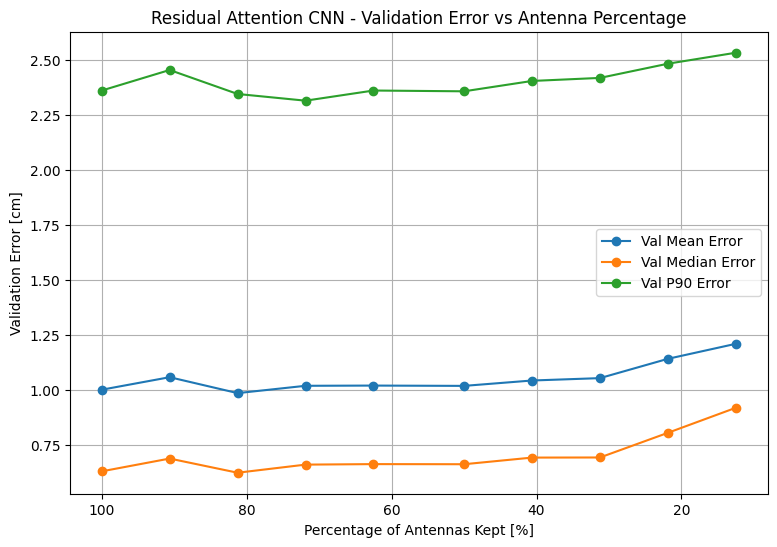

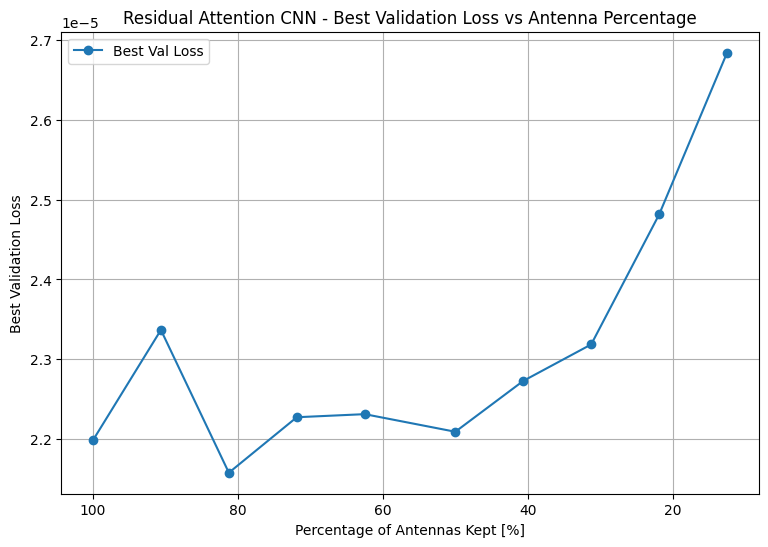


Final selected Residual Attention CNN based on validation mean error
Selected requested percentage: 80%
Selected actual percentage:    81.25%
Selected kept antennas:        26/32
Selected model path:           /content/drive/MyDrive/DICHASUS_tracking_experiments/residual_attention_ig_source/saved_tracking_residual_attention_models/best_residual_attention_model_top_80_percent.keras
Selected normalization path:   /content/drive/MyDrive/DICHASUS_tracking_experiments/residual_attention_ig_source/saved_tracking_residual_attention_results/normalization_residual_attention_top_80_percent.npz

Final Test Evaluation of Selected Residual Attention CNN

FINAL TEST REPORT ONLY - Residual Attention CNN - Selected 80% requested antennas
----------------------------------------------------------------------
Mean Error:              0.0091 m
Median Error:            0.0056 m
RMSE Error:              0.0162 m
75th Percentile Error:   0.0108 m
90th Percentile Error:   0.0212 m
95th Percentile Error:   0

,architecture,selection_metric,test_usage,selected_requested_percentage,selected_actual_percentage,selected_kept_antennas,selected_model_path,selected_normalization_path,selected_val_mean_error_m,selected_val_median_error_m,...,final_test_median_error_m,final_test_rmse_error_m,final_test_p75_error_m,final_test_p90_error_m,final_test_p95_error_m,final_test_acc_5cm_percent,final_test_acc_10cm_percent,final_test_acc_20cm_percent,final_test_acc_30cm_percent,final_test_acc_50cm_percent
0,ResidualAttentionCNN,validation_mean_error,report_only_not_used_for_decision,80,81.25,26,/content/drive/MyDrive/DICHASUS_tracking_exper...,/content/drive/MyDrive/DICHASUS_tracking_exper...,0.009854,0.006236,...,0.005587,0.016196,0.010842,0.0212,0.030094,99.350053,99.704569,99.967174,99.98687,100.0



Final selected model saved for future use
Final selected model copy:
/content/drive/MyDrive/DICHASUS_tracking_experiments/residual_attention_ig_source/saved_tracking_residual_attention_models/FINAL_SELECTED_residual_attention_model.keras

Final selected normalization copy:
/content/drive/MyDrive/DICHASUS_tracking_experiments/residual_attention_ig_source/saved_tracking_residual_attention_results/FINAL_SELECTED_residual_attention_normalization.npz

Final selected info:
/content/drive/MyDrive/DICHASUS_tracking_experiments/residual_attention_ig_source/saved_tracking_residual_attention_results/FINAL_SELECTED_residual_attention_info.csv


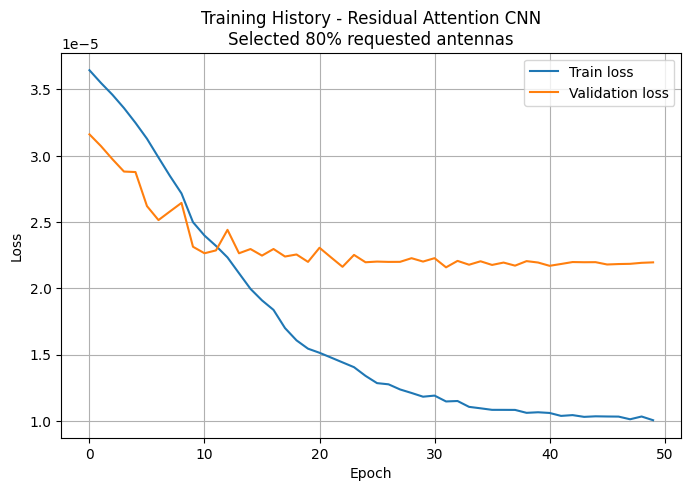

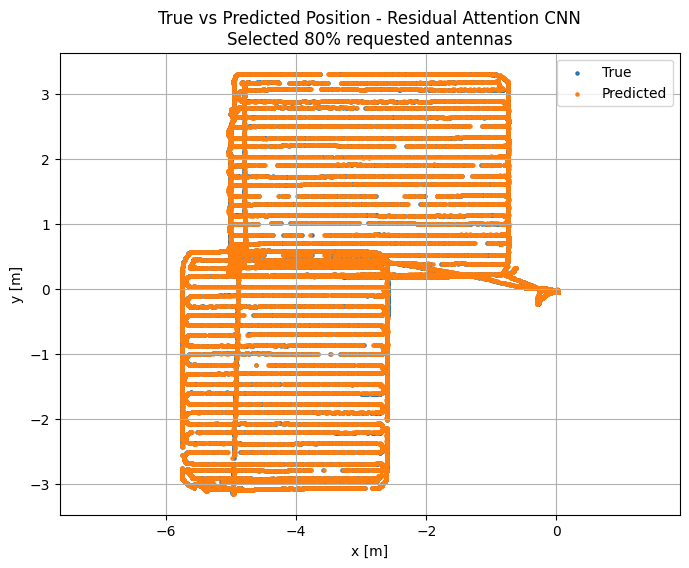

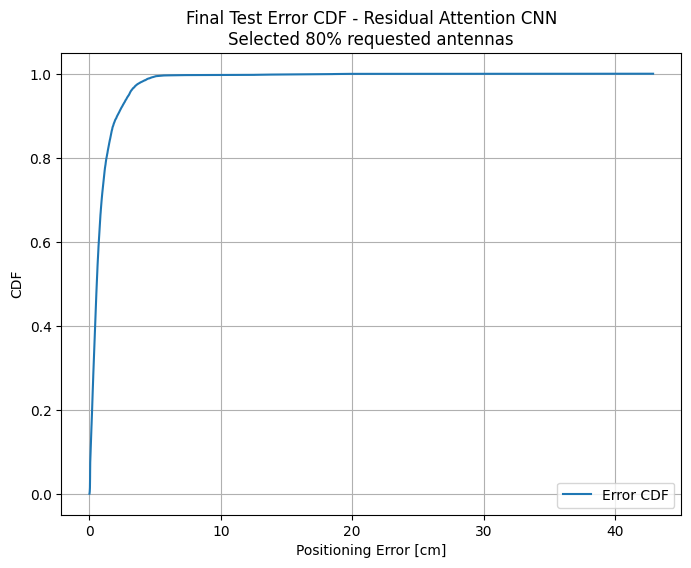

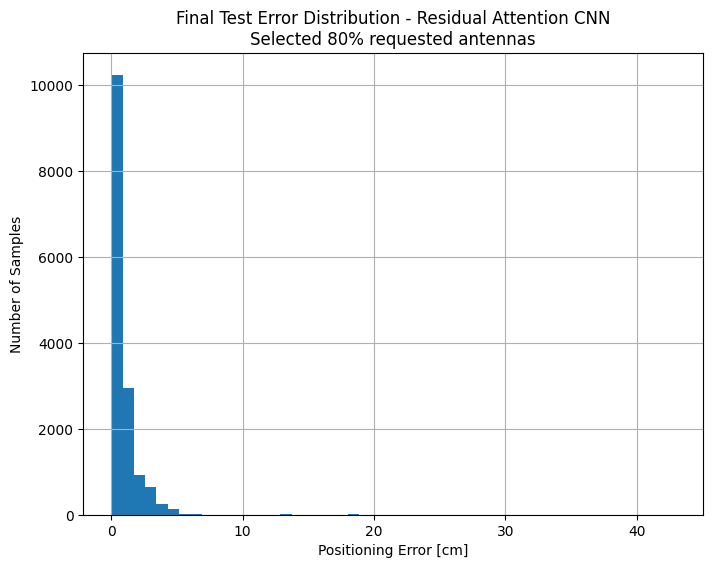


Done.
Residual Attention models saved in:  /content/drive/MyDrive/DICHASUS_tracking_experiments/residual_attention_ig_source/saved_tracking_residual_attention_models
Residual Attention results saved in: /content/drive/MyDrive/DICHASUS_tracking_experiments/residual_attention_ig_source/saved_tracking_residual_attention_results

Final selected model based on validation:
Architecture:           ResidualAttentionCNN
Requested percentage:   80%
Actual percentage:      81.25%
Kept antennas:          26/32

Validation performance of selected model:
Val mean error:         0.99 cm
Val median error:       0.62 cm
Val RMSE error:         1.59 cm
Val P90 error:          2.34 cm
Best val loss:          0.000022

Final test performance report only:
Test mean error:        0.91 cm
Test median error:      0.56 cm
Test RMSE error:        1.62 cm
Test P90 error:         2.12 cm
Test P95 error:         3.01 cm
Test accuracy <= 10 cm: 99.70%

Files for future loading:
Model:         /content/drive/MyDriv

In [ ]:
# ============================================================
# RESIDUAL ATTENTION CNN:
# CSI-Aided Next-Step Tracking with IG Source Antenna Ablation
#
# Architecture:
#   Residual CNN + Antenna Attention + Delta Prediction
#
# Input 1: position(t)      -> shape (2,)
# Input 2: CSI(t+1)         -> shape (32, 32, 2)
# Input 3: antenna mask     -> shape (32,)
# Output : position(t+1)    -> shape (2,)
#
# Antenna percentages:
#   100%, 90%, 80%, ..., 20%, 10%
#
# IMPORTANT:
#   Model/percentage selection is based ONLY on validation results.
#   Test set is used only for final report after validation selection.
#
# SAVE:
#   All models, normalization files, histories, checkpoints, and final selected model
#   are saved to Google Drive so you do not need to retrain later.
# ============================================================

import os
import gc
import shutil
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras import layers, Model


# ============================================================
# Optional: Mount Google Drive
# ============================================================
# In Colab, this keeps saved models/results after runtime reset.

USE_GOOGLE_DRIVE = True

if USE_GOOGLE_DRIVE:
    try:
        from google.colab import drive
        drive.mount("/content/drive")
        print("Google Drive mounted.")
    except Exception as e:
        print("Could not mount Google Drive. Falling back to local storage.")
        print(e)


# ============================================================
# Global settings
# ============================================================

SEED = 42
BATCH_SIZE = 64
EPOCHS = 150
HORIZON = 1

np.random.seed(SEED)
tf.random.set_seed(SEED)


# ============================================================
# Output folders for Residual Attention model
# ============================================================

if USE_GOOGLE_DRIVE:
    BASE_SAVE_DIR = "/content/drive/MyDrive/DICHASUS_tracking_experiments/residual_attention_ig_source"
else:
    BASE_SAVE_DIR = "DICHASUS_tracking_experiments/residual_attention_ig_source"


NEW_MODEL_SAVE_DIR = os.path.join(
    BASE_SAVE_DIR,
    "saved_tracking_residual_attention_models"
)

NEW_RESULT_SAVE_DIR = os.path.join(
    BASE_SAVE_DIR,
    "saved_tracking_residual_attention_results"
)

os.makedirs(NEW_MODEL_SAVE_DIR, exist_ok=True)
os.makedirs(NEW_RESULT_SAVE_DIR, exist_ok=True)

print("Residual Attention models will be saved in:")
print(NEW_MODEL_SAVE_DIR)

print("\nResidual Attention results will be saved in:")
print(NEW_RESULT_SAVE_DIR)


# ============================================================
# Safety checks
# ============================================================

required_objects = [
    "train_runs",
    "val_runs",
    "test_runs",
    "global_importance_ig_source",
    "antenna_ranking_global_ig_source",
]

for obj in required_objects:
    if obj not in globals():
        raise RuntimeError(
            f"{obj} is not defined. "
            f"Run the preprocessing and IG Source Model ranking cells first."
        )

print("\nAll required objects exist.")


# ============================================================
# Use IG Source antenna ranking
# ============================================================

antenna_ranking = np.asarray(
    antenna_ranking_global_ig_source,
    dtype=np.int32
)

global_importance_vector = np.asarray(
    global_importance_ig_source,
    dtype=np.float32
)

if antenna_ranking.shape[0] != 32:
    raise ValueError(
        f"Expected antenna_ranking shape (32,), got {antenna_ranking.shape}"
    )

if global_importance_vector.shape[0] != 32:
    raise ValueError(
        f"Expected global_importance_vector shape (32,), got {global_importance_vector.shape}"
    )

print("\nUsing antenna ranking from IG Source Model.")
print("Antenna ranking indices:")
print(antenna_ranking)

print("\nAntenna ranking names:")
print([f"A{i + 1}" for i in antenna_ranking])

print("\nTop 10 antennas:")
for rank, ant_idx in enumerate(antenna_ranking[:10], start=1):
    print(
        f"Rank {rank}: index={ant_idx}, "
        f"name=A{ant_idx + 1}, "
        f"importance={global_importance_vector[ant_idx]:.8f}"
    )


# ============================================================
# Antenna mask builder
# ============================================================

def create_topk_antenna_mask_by_percentage(
    antenna_ranking,
    percentage=100,
    num_antennas=32
):
    k = int(np.ceil(num_antennas * percentage / 100.0))
    k = max(1, min(k, num_antennas))

    mask = np.zeros(num_antennas, dtype=np.float32)

    selected_antennas = antenna_ranking[:k]
    selected_antenna_names = [f"A{i + 1}" for i in selected_antennas]

    mask[selected_antennas] = 1.0

    actual_percentage = 100.0 * k / num_antennas

    return mask, selected_antennas, selected_antenna_names, k, actual_percentage


# ============================================================
# Build sequential tracking arrays
# ============================================================

def build_tracking_arrays_from_runs(
    runs,
    antenna_mask,
    horizon=1
):
    X_pos_t_list = []
    X_csi_tplus1_list = []
    X_mask_list = []
    y_pos_tplus1_list = []

    for run_idx, run in enumerate(runs):
        if "X_csi" not in run:
            raise KeyError(f"Run {run_idx} does not contain key 'X_csi'.")

        if "pos" not in run:
            raise KeyError(f"Run {run_idx} does not contain key 'pos'.")

        X_csi = run["X_csi"].astype(np.float32)
        pos = run["pos"].astype(np.float32)

        if len(X_csi) != len(pos):
            raise ValueError(
                f"Run {run_idx}: X_csi and pos have different lengths. "
                f"X_csi length = {len(X_csi)}, pos length = {len(pos)}"
            )

        if len(X_csi) <= horizon:
            print(f"Skipping run {run_idx}: too short.")
            continue

        # position(t)
        pos_t = pos[:-horizon]

        # CSI(t+1)
        csi_tplus1 = X_csi[horizon:]

        # position(t+1)
        pos_tplus1 = pos[horizon:]

        mask_repeated = np.repeat(
            antenna_mask[None, :],
            repeats=pos_t.shape[0],
            axis=0
        ).astype(np.float32)

        X_pos_t_list.append(pos_t)
        X_csi_tplus1_list.append(csi_tplus1)
        X_mask_list.append(mask_repeated)
        y_pos_tplus1_list.append(pos_tplus1)

    if len(X_pos_t_list) == 0:
        raise RuntimeError("No valid runs found for tracking array construction.")

    X_pos_t_all = np.concatenate(X_pos_t_list, axis=0).astype(np.float32)
    X_csi_tplus1_all = np.concatenate(X_csi_tplus1_list, axis=0).astype(np.float32)
    X_mask_all = np.concatenate(X_mask_list, axis=0).astype(np.float32)
    y_pos_tplus1_all = np.concatenate(y_pos_tplus1_list, axis=0).astype(np.float32)

    return X_pos_t_all, X_csi_tplus1_all, X_mask_all, y_pos_tplus1_all


# ============================================================
# Normalization
# ============================================================

def compute_csi_normalization_stats(X_train_csi):
    csi_mean = X_train_csi.mean(
        axis=(0, 1, 2),
        keepdims=True
    ).astype(np.float32)

    csi_std = X_train_csi.std(
        axis=(0, 1, 2),
        keepdims=True
    ).astype(np.float32) + 1e-8

    return csi_mean, csi_std


def normalize_csi(X_csi, csi_mean, csi_std):
    return ((X_csi - csi_mean) / csi_std).astype(np.float32)


def compute_position_normalization_stats(y_train):
    pos_mean = y_train.mean(
        axis=0,
        keepdims=True
    ).astype(np.float32)

    pos_std = y_train.std(
        axis=0,
        keepdims=True
    ).astype(np.float32) + 1e-8

    return pos_mean, pos_std


def normalize_position(pos, pos_mean, pos_std):
    return ((pos - pos_mean) / pos_std).astype(np.float32)


def denormalize_position(pos_norm, pos_mean, pos_std):
    return (pos_norm * pos_std + pos_mean).astype(np.float32)


# ============================================================
# Dataset builder
# ============================================================

def make_tracking_dataset(
    X_pos_t_norm,
    X_csi_tplus1_norm,
    X_mask,
    y_pos_tplus1_norm,
    batch_size=64,
    shuffle=False,
    seed=42
):
    inputs = {
        "position_t_input": X_pos_t_norm.astype(np.float32),
        "csi_tplus1_input": X_csi_tplus1_norm.astype(np.float32),
        "antenna_mask_input": X_mask.astype(np.float32),
    }

    targets = y_pos_tplus1_norm.astype(np.float32)

    dataset = tf.data.Dataset.from_tensor_slices((inputs, targets))

    if shuffle:
        dataset = dataset.shuffle(
            buffer_size=min(len(targets), 20000),
            seed=seed,
            reshuffle_each_iteration=True
        )

    dataset = dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)

    return dataset


# ============================================================
# Evaluation function
# ============================================================

def evaluate_tracking_predictions(
    model,
    dataset,
    y_true_meter,
    pos_mean,
    pos_std,
    dataset_name="Dataset"
):
    y_pred_norm = model.predict(dataset, verbose=0)

    y_pred_meter = denormalize_position(
        y_pred_norm,
        pos_mean,
        pos_std
    )

    error_vectors = y_pred_meter - y_true_meter

    errors = np.sqrt(
        error_vectors[:, 0] ** 2 +
        error_vectors[:, 1] ** 2
    )

    results = {
        "mean_error_m": float(np.mean(errors)),
        "median_error_m": float(np.median(errors)),
        "rmse_error_m": float(np.sqrt(np.mean(errors ** 2))),
        "std_error_m": float(np.std(errors)),
        "min_error_m": float(np.min(errors)),
        "max_error_m": float(np.max(errors)),
        "p75_error_m": float(np.percentile(errors, 75)),
        "p90_error_m": float(np.percentile(errors, 90)),
        "p95_error_m": float(np.percentile(errors, 95)),
        "acc_5cm_percent": float(np.mean(errors <= 0.05) * 100),
        "acc_10cm_percent": float(np.mean(errors <= 0.10) * 100),
        "acc_20cm_percent": float(np.mean(errors <= 0.20) * 100),
        "acc_30cm_percent": float(np.mean(errors <= 0.30) * 100),
        "acc_50cm_percent": float(np.mean(errors <= 0.50) * 100),
        "errors": errors,
        "predictions_meter": y_pred_meter,
    }

    print()
    print(dataset_name)
    print("-" * 70)
    print(f"Mean Error:              {results['mean_error_m']:.4f} m")
    print(f"Median Error:            {results['median_error_m']:.4f} m")
    print(f"RMSE Error:              {results['rmse_error_m']:.4f} m")
    print(f"75th Percentile Error:   {results['p75_error_m']:.4f} m")
    print(f"90th Percentile Error:   {results['p90_error_m']:.4f} m")
    print(f"95th Percentile Error:   {results['p95_error_m']:.4f} m")
    print()
    print(f"Accuracy <= 5 cm:        {results['acc_5cm_percent']:.2f}%")
    print(f"Accuracy <= 10 cm:       {results['acc_10cm_percent']:.2f}%")
    print(f"Accuracy <= 20 cm:       {results['acc_20cm_percent']:.2f}%")
    print(f"Accuracy <= 30 cm:       {results['acc_30cm_percent']:.2f}%")
    print(f"Accuracy <= 50 cm:       {results['acc_50cm_percent']:.2f}%")
    print()

    return results


# ============================================================
# Custom serializable layer for antenna energy
# Avoids Lambda loading problems when saving/loading .keras models
# ============================================================

@tf.keras.utils.register_keras_serializable()
class AntennaEnergyLayer(layers.Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def call(self, inputs):
        # inputs shape: (batch, 32, 32, 2)
        # output shape: (batch, 32)
        return tf.reduce_mean(tf.abs(inputs), axis=[2, 3])

    def get_config(self):
        config = super().get_config()
        return config


# ============================================================
# Residual SE block
# ============================================================

def residual_se_block(
    x,
    filters,
    stride=1,
    se_ratio=8,
    dropout_rate=0.0,
    name="res_block"
):
    shortcut = x

    x = layers.Conv2D(
        filters,
        kernel_size=(3, 3),
        strides=stride,
        padding="same",
        use_bias=False,
        name=f"{name}_conv_1"
    )(x)

    x = layers.BatchNormalization(
        name=f"{name}_bn_1"
    )(x)

    x = layers.Activation(
        "relu",
        name=f"{name}_relu_1"
    )(x)

    x = layers.Conv2D(
        filters,
        kernel_size=(3, 3),
        strides=1,
        padding="same",
        use_bias=False,
        name=f"{name}_conv_2"
    )(x)

    x = layers.BatchNormalization(
        name=f"{name}_bn_2"
    )(x)

    # ------------------------------
    # Squeeze-and-Excitation
    # ------------------------------

    se = layers.GlobalAveragePooling2D(
        name=f"{name}_se_gap"
    )(x)

    se_units = max(filters // se_ratio, 8)

    se = layers.Dense(
        se_units,
        activation="relu",
        name=f"{name}_se_dense_1"
    )(se)

    se = layers.Dense(
        filters,
        activation="sigmoid",
        name=f"{name}_se_dense_2"
    )(se)

    se = layers.Reshape(
        (1, 1, filters),
        name=f"{name}_se_reshape"
    )(se)

    x = layers.Multiply(
        name=f"{name}_se_multiply"
    )([x, se])

    if dropout_rate > 0:
        x = layers.Dropout(
            dropout_rate,
            name=f"{name}_dropout"
        )(x)

    # ------------------------------
    # Shortcut projection if needed
    # ------------------------------

    if stride != 1 or int(shortcut.shape[-1]) != filters:
        shortcut = layers.Conv2D(
            filters,
            kernel_size=(1, 1),
            strides=stride,
            padding="same",
            use_bias=False,
            name=f"{name}_shortcut_conv"
        )(shortcut)

        shortcut = layers.BatchNormalization(
            name=f"{name}_shortcut_bn"
        )(shortcut)

    x = layers.Add(
        name=f"{name}_add"
    )([x, shortcut])

    x = layers.Activation(
        "relu",
        name=f"{name}_out_relu"
    )(x)

    return x


# ============================================================
# Residual Attention CNN Architecture
# Residual CNN + Antenna Attention + Delta Prediction
# ============================================================

def build_residual_attention_tracking_model(seed=42):
    tf.keras.backend.clear_session()
    np.random.seed(seed)
    tf.random.set_seed(seed)

    # ------------------------------
    # Inputs
    # ------------------------------

    position_t_input = tf.keras.Input(
        shape=(2,),
        name="position_t_input"
    )

    csi_tplus1_input = tf.keras.Input(
        shape=(32, 32, 2),
        name="csi_tplus1_input"
    )

    antenna_mask_input = tf.keras.Input(
        shape=(32,),
        name="antenna_mask_input"
    )

    # ------------------------------
    # Apply binary antenna mask
    # ------------------------------

    antenna_mask_reshaped = layers.Reshape(
        (32, 1, 1),
        name="antenna_mask_reshape"
    )(antenna_mask_input)

    masked_csi = layers.Multiply(
        name="initial_masked_csi"
    )([csi_tplus1_input, antenna_mask_reshaped])

    # ------------------------------
    # Antenna attention
    # ------------------------------

    antenna_energy = AntennaEnergyLayer(
        name="antenna_energy"
    )(masked_csi)

    antenna_attention = layers.Dense(
        64,
        activation="relu",
        name="antenna_attention_dense_1"
    )(antenna_energy)

    antenna_attention = layers.Dense(
        32,
        activation="sigmoid",
        name="antenna_attention_dense_2"
    )(antenna_attention)

    antenna_attention = layers.Multiply(
        name="antenna_attention_apply_mask"
    )([antenna_attention, antenna_mask_input])

    antenna_attention_reshaped = layers.Reshape(
        (32, 1, 1),
        name="antenna_attention_reshape"
    )(antenna_attention)

    attended_csi = layers.Multiply(
        name="attention_weighted_csi"
    )([masked_csi, antenna_attention_reshaped])

    # ------------------------------
    # CSI Residual CNN branch
    # ------------------------------

    x = layers.Conv2D(
        32,
        kernel_size=(3, 3),
        padding="same",
        use_bias=False,
        name="stem_conv"
    )(attended_csi)

    x = layers.BatchNormalization(
        name="stem_bn"
    )(x)

    x = layers.Activation(
        "relu",
        name="stem_relu"
    )(x)

    x = residual_se_block(
        x,
        filters=32,
        stride=1,
        dropout_rate=0.05,
        name="res32_block1"
    )

    x = residual_se_block(
        x,
        filters=32,
        stride=1,
        dropout_rate=0.05,
        name="res32_block2"
    )

    x = residual_se_block(
        x,
        filters=64,
        stride=2,
        dropout_rate=0.08,
        name="res64_block1"
    )

    x = residual_se_block(
        x,
        filters=64,
        stride=1,
        dropout_rate=0.08,
        name="res64_block2"
    )

    x = residual_se_block(
        x,
        filters=128,
        stride=2,
        dropout_rate=0.10,
        name="res128_block1"
    )

    x = residual_se_block(
        x,
        filters=128,
        stride=1,
        dropout_rate=0.10,
        name="res128_block2"
    )

    avg_pool = layers.GlobalAveragePooling2D(
        name="csi_global_avg_pool"
    )(x)

    max_pool = layers.GlobalMaxPooling2D(
        name="csi_global_max_pool"
    )(x)

    csi_features = layers.Concatenate(
        name="csi_avg_max_features"
    )([avg_pool, max_pool])

    csi_features = layers.Dense(
        256,
        activation="relu",
        name="csi_dense_1"
    )(csi_features)

    csi_features = layers.BatchNormalization(
        name="csi_dense_bn_1"
    )(csi_features)

    csi_features = layers.Dropout(
        0.15,
        name="csi_dense_dropout_1"
    )(csi_features)

    csi_features = layers.Dense(
        128,
        activation="relu",
        name="csi_dense_2"
    )(csi_features)

    # ------------------------------
    # Position(t) branch
    # ------------------------------

    p = layers.Dense(
        64,
        activation="relu",
        name="position_dense_1"
    )(position_t_input)

    p = layers.Dense(
        64,
        activation="relu",
        name="position_dense_2"
    )(p)

    p = layers.Dense(
        32,
        activation="relu",
        name="position_dense_3"
    )(p)

    # ------------------------------
    # Fusion branch
    # ------------------------------

    combined = layers.Concatenate(
        name="fusion_csi_position"
    )([csi_features, p])

    z = layers.Dense(
        256,
        activation="relu",
        name="fusion_dense_1"
    )(combined)

    z = layers.BatchNormalization(
        name="fusion_bn_1"
    )(z)

    z = layers.Dropout(
        0.20,
        name="fusion_dropout_1"
    )(z)

    z = layers.Dense(
        128,
        activation="relu",
        name="fusion_dense_2"
    )(z)

    z = layers.Dropout(
        0.10,
        name="fusion_dropout_2"
    )(z)

    z = layers.Dense(
        64,
        activation="relu",
        name="fusion_dense_3"
    )(z)

    # ------------------------------
    # Delta prediction
    # ------------------------------

    delta_position_norm = layers.Dense(
        2,
        activation="linear",
        kernel_initializer=tf.keras.initializers.RandomNormal(
            mean=0.0,
            stddev=1e-3,
            seed=seed
        ),
        bias_initializer="zeros",
        name="delta_position_norm"
    )(z)

    output_position_norm = layers.Add(
        name="position_tplus1_output"
    )([position_t_input, delta_position_norm])

    model = Model(
        inputs={
            "position_t_input": position_t_input,
            "csi_tplus1_input": csi_tplus1_input,
            "antenna_mask_input": antenna_mask_input,
        },
        outputs=output_position_norm,
        name=f"residual_attention_tracking_model_seed_{seed}"
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=2e-4),
        loss=tf.keras.losses.Huber(delta=1.0),
        metrics=["mae"]
    )

    return model


# ============================================================
# Plot helpers
# ============================================================

def plot_validation_error_vs_percentage(results_df):
    plot_df = results_df.sort_values(
        "actual_percentage",
        ascending=False
    )

    plt.figure(figsize=(9, 6))

    plt.plot(
        plot_df["actual_percentage"],
        plot_df["val_mean_error_m"] * 100,
        marker="o",
        label="Val Mean Error"
    )

    plt.plot(
        plot_df["actual_percentage"],
        plot_df["val_median_error_m"] * 100,
        marker="o",
        label="Val Median Error"
    )

    plt.plot(
        plot_df["actual_percentage"],
        plot_df["val_p90_error_m"] * 100,
        marker="o",
        label="Val P90 Error"
    )

    plt.gca().invert_xaxis()
    plt.xlabel("Percentage of Antennas Kept [%]")
    plt.ylabel("Validation Error [cm]")
    plt.title("Residual Attention CNN - Validation Error vs Antenna Percentage")
    plt.grid(True)
    plt.legend()
    plt.show()


def plot_validation_loss_vs_percentage(results_df):
    plot_df = results_df.sort_values(
        "actual_percentage",
        ascending=False
    )

    plt.figure(figsize=(9, 6))

    plt.plot(
        plot_df["actual_percentage"],
        plot_df["best_val_loss"],
        marker="o",
        label="Best Val Loss"
    )

    plt.gca().invert_xaxis()
    plt.xlabel("Percentage of Antennas Kept [%]")
    plt.ylabel("Best Validation Loss")
    plt.title("Residual Attention CNN - Best Validation Loss vs Antenna Percentage")
    plt.grid(True)
    plt.legend()
    plt.show()


def plot_training_history_from_csv(history_path, title="Training History"):
    history_df = pd.read_csv(history_path)

    plt.figure(figsize=(8, 5))

    plt.plot(
        history_df["loss"],
        label="Train loss"
    )

    plt.plot(
        history_df["val_loss"],
        label="Validation loss"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.show()


def plot_true_vs_pred(y_true, y_pred, title="True vs Predicted Position"):
    plt.figure(figsize=(8, 6))

    plt.scatter(
        y_true[:, 0],
        y_true[:, 1],
        s=5,
        label="True"
    )

    plt.scatter(
        y_pred[:, 0],
        y_pred[:, 1],
        s=5,
        label="Predicted"
    )

    plt.xlabel("x [m]")
    plt.ylabel("y [m]")
    plt.title(title)
    plt.axis("equal")
    plt.grid(True)
    plt.legend()
    plt.show()


def plot_error_cdf(errors, title="CDF of Positioning Error"):
    sorted_errors = np.sort(errors)
    cdf = np.arange(1, len(sorted_errors) + 1) / len(sorted_errors)

    plt.figure(figsize=(8, 6))

    plt.plot(
        sorted_errors * 100,
        cdf,
        label="Error CDF"
    )

    plt.xlabel("Positioning Error [cm]")
    plt.ylabel("CDF")
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.show()


def plot_error_histogram(errors, title="Error Distribution"):
    plt.figure(figsize=(8, 6))

    plt.hist(
        errors * 100,
        bins=50
    )

    plt.xlabel("Positioning Error [cm]")
    plt.ylabel("Number of Samples")
    plt.title(title)
    plt.grid(True)
    plt.show()


# ============================================================
# Antenna percentages like before
# ============================================================

ablation_percentages = [
    100, 90, 80, 70, 60, 50, 40, 30, 20, 10
]


# ============================================================
# Resume support
# ============================================================

new_checkpoint_path = os.path.join(
    NEW_RESULT_SAVE_DIR,
    "residual_attention_validation_search_checkpoint.csv"
)

FORCE_RETRAIN = False

if os.path.exists(new_checkpoint_path) and not FORCE_RETRAIN:
    previous_df = pd.read_csv(new_checkpoint_path)

    done_percentages = set(
        previous_df["requested_percentage"].astype(int).tolist()
    )

    new_ablation_summary = previous_df.to_dict("records")

    print("\nExisting checkpoint found.")
    print("Already completed percentages:")
    print(sorted(done_percentages, reverse=True))

else:
    done_percentages = set()
    new_ablation_summary = []

    if FORCE_RETRAIN:
        print("\nFORCE_RETRAIN=True. Starting from scratch.")
    else:
        print("\nNo previous checkpoint found. Starting from scratch.")

remaining_percentages = [
    p for p in ablation_percentages
    if int(p) not in done_percentages
]

print("\nRemaining percentages to train:")
print(remaining_percentages)


# ============================================================
# Main validation-based search loop
# Train separate Residual Attention model for each percentage
# ============================================================

PRINT_MODEL_SUMMARY_ONCE = True

for percentage in remaining_percentages:
    print()
    print("=" * 90)
    print(f"Residual Attention CNN - Requested top {percentage}% antennas")
    print("=" * 90)

    # --------------------------------------------------------
    # Create antenna mask
    # --------------------------------------------------------

    antenna_mask, selected_antennas, selected_antenna_names, num_selected_antennas, actual_percentage = (
        create_topk_antenna_mask_by_percentage(
            antenna_ranking=antenna_ranking,
            percentage=percentage,
            num_antennas=32
        )
    )

    num_removed_antennas = 32 - num_selected_antennas

    print(f"Requested percentage: {percentage}%")
    print(f"Actual percentage:    {actual_percentage:.2f}%")

    print(f"Selected antennas indices ({num_selected_antennas}/32):")
    print(selected_antennas)

    print(f"Selected antennas names ({num_selected_antennas}/32):")
    print(selected_antenna_names)

    print(f"Removed antennas: {num_removed_antennas}")

    # --------------------------------------------------------
    # Build train and validation arrays
    # --------------------------------------------------------

    X_train_pos_t, X_train_csi_tplus1, X_train_mask, y_train_pos_tplus1 = (
        build_tracking_arrays_from_runs(
            train_runs,
            antenna_mask=antenna_mask,
            horizon=HORIZON
        )
    )

    X_val_pos_t, X_val_csi_tplus1, X_val_mask, y_val_pos_tplus1 = (
        build_tracking_arrays_from_runs(
            val_runs,
            antenna_mask=antenna_mask,
            horizon=HORIZON
        )
    )

    print("\nTrain shapes:")
    print("X_train_pos_t:", X_train_pos_t.shape)
    print("X_train_csi_tplus1:", X_train_csi_tplus1.shape)
    print("X_train_mask:", X_train_mask.shape)
    print("y_train_pos_tplus1:", y_train_pos_tplus1.shape)

    print("\nValidation shapes:")
    print("X_val_pos_t:", X_val_pos_t.shape)
    print("X_val_csi_tplus1:", X_val_csi_tplus1.shape)
    print("X_val_mask:", X_val_mask.shape)
    print("y_val_pos_tplus1:", y_val_pos_tplus1.shape)

    # --------------------------------------------------------
    # Normalize using train only
    # --------------------------------------------------------

    csi_mean, csi_std = compute_csi_normalization_stats(
        X_train_csi_tplus1
    )

    pos_mean, pos_std = compute_position_normalization_stats(
        y_train_pos_tplus1
    )

    X_train_csi_tplus1_norm = normalize_csi(
        X_train_csi_tplus1,
        csi_mean,
        csi_std
    )

    X_val_csi_tplus1_norm = normalize_csi(
        X_val_csi_tplus1,
        csi_mean,
        csi_std
    )

    X_train_pos_t_norm = normalize_position(
        X_train_pos_t,
        pos_mean,
        pos_std
    )

    X_val_pos_t_norm = normalize_position(
        X_val_pos_t,
        pos_mean,
        pos_std
    )

    y_train_pos_tplus1_norm = normalize_position(
        y_train_pos_tplus1,
        pos_mean,
        pos_std
    )

    y_val_pos_tplus1_norm = normalize_position(
        y_val_pos_tplus1,
        pos_mean,
        pos_std
    )

    print("\npos_mean:", pos_mean)
    print("pos_std:", pos_std)

    # --------------------------------------------------------
    # Create TensorFlow datasets
    # --------------------------------------------------------

    train_dataset = make_tracking_dataset(
        X_pos_t_norm=X_train_pos_t_norm,
        X_csi_tplus1_norm=X_train_csi_tplus1_norm,
        X_mask=X_train_mask,
        y_pos_tplus1_norm=y_train_pos_tplus1_norm,
        batch_size=BATCH_SIZE,
        shuffle=True,
        seed=SEED
    )

    val_dataset = make_tracking_dataset(
        X_pos_t_norm=X_val_pos_t_norm,
        X_csi_tplus1_norm=X_val_csi_tplus1_norm,
        X_mask=X_val_mask,
        y_pos_tplus1_norm=y_val_pos_tplus1_norm,
        batch_size=BATCH_SIZE,
        shuffle=False,
        seed=SEED
    )

    # --------------------------------------------------------
    # Build Residual Attention model
    # --------------------------------------------------------

    model = build_residual_attention_tracking_model(seed=SEED)

    if PRINT_MODEL_SUMMARY_ONCE:
        model.summary()
        PRINT_MODEL_SUMMARY_ONCE = False

    # --------------------------------------------------------
    # Save paths
    # --------------------------------------------------------

    percentage_name = str(percentage).replace(".", "_")

    best_model_path = os.path.join(
        NEW_MODEL_SAVE_DIR,
        f"best_residual_attention_model_top_{percentage_name}_percent.keras"
    )

    final_model_path = os.path.join(
        NEW_MODEL_SAVE_DIR,
        f"final_residual_attention_model_top_{percentage_name}_percent.keras"
    )

    history_path = os.path.join(
        NEW_RESULT_SAVE_DIR,
        f"history_residual_attention_top_{percentage_name}_percent.csv"
    )

    norm_path = os.path.join(
        NEW_RESULT_SAVE_DIR,
        f"normalization_residual_attention_top_{percentage_name}_percent.npz"
    )

    # --------------------------------------------------------
    # Callbacks
    # --------------------------------------------------------

    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=18,
            restore_best_weights=True,
            verbose=1
        ),

        tf.keras.callbacks.ModelCheckpoint(
            filepath=best_model_path,
            monitor="val_loss",
            save_best_only=True,
            save_weights_only=False,
            verbose=1
        ),

        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=8,
            min_lr=1e-6,
            verbose=1
        )
    ]

    # --------------------------------------------------------
    # Train
    # --------------------------------------------------------

    history = model.fit(
        train_dataset,
        validation_data=val_dataset,
        epochs=EPOCHS,
        callbacks=callbacks,
        verbose=1
    )

    # Save final restored model
    model.save(final_model_path)

    print(f"Best model saved to:  {best_model_path}")
    print(f"Final model saved to: {final_model_path}")

    # --------------------------------------------------------
    # Save normalization and mask info
    # --------------------------------------------------------

    np.savez(
        norm_path,
        csi_mean=csi_mean,
        csi_std=csi_std,
        pos_mean=pos_mean,
        pos_std=pos_std,
        antenna_mask=antenna_mask,
        selected_antennas=selected_antennas,
        selected_antenna_names=np.array(selected_antenna_names),
        requested_percentage=percentage,
        actual_percentage=actual_percentage,
        num_selected_antennas=num_selected_antennas,
        num_removed_antennas=num_removed_antennas
    )

    print(f"Normalization/mask info saved to: {norm_path}")

    # --------------------------------------------------------
    # Save training history
    # --------------------------------------------------------

    history_df = pd.DataFrame(history.history)

    history_df.to_csv(
        history_path,
        index=False
    )

    print(f"Training history saved to: {history_path}")

    # --------------------------------------------------------
    # Validation evaluation only
    # --------------------------------------------------------

    val_results = evaluate_tracking_predictions(
        model=model,
        dataset=val_dataset,
        y_true_meter=y_val_pos_tplus1,
        pos_mean=pos_mean,
        pos_std=pos_std,
        dataset_name=f"Validation - Residual Attention CNN - Top {percentage}% requested antennas"
    )

    # --------------------------------------------------------
    # Save summary row
    # --------------------------------------------------------

    new_ablation_summary.append({
        "architecture": "ResidualAttentionCNN",
        "requested_percentage": percentage,
        "actual_percentage": actual_percentage,
        "kept_antennas": num_selected_antennas,
        "removed_antennas": num_removed_antennas,
        "selected_antennas_indices": selected_antennas.tolist(),
        "selected_antennas_names": selected_antenna_names,

        "best_model_path": best_model_path,
        "final_model_path": final_model_path,
        "normalization_path": norm_path,
        "history_path": history_path,

        # Validation metrics - used for decisions
        "val_mean_error_m": val_results["mean_error_m"],
        "val_median_error_m": val_results["median_error_m"],
        "val_rmse_error_m": val_results["rmse_error_m"],
        "val_std_error_m": val_results["std_error_m"],
        "val_min_error_m": val_results["min_error_m"],
        "val_max_error_m": val_results["max_error_m"],
        "val_p75_error_m": val_results["p75_error_m"],
        "val_p90_error_m": val_results["p90_error_m"],
        "val_p95_error_m": val_results["p95_error_m"],

        "val_acc_5cm_percent": val_results["acc_5cm_percent"],
        "val_acc_10cm_percent": val_results["acc_10cm_percent"],
        "val_acc_20cm_percent": val_results["acc_20cm_percent"],
        "val_acc_30cm_percent": val_results["acc_30cm_percent"],
        "val_acc_50cm_percent": val_results["acc_50cm_percent"],

        "epochs_trained": len(history.history["loss"]),
        "best_val_loss": min(history.history["val_loss"]),
        "final_val_loss": history.history["val_loss"][-1],
    })

    # --------------------------------------------------------
    # Save checkpoint after every percentage
    # --------------------------------------------------------

    checkpoint_df = pd.DataFrame(new_ablation_summary)

    checkpoint_df.to_csv(
        new_checkpoint_path,
        index=False
    )

    print(f"Checkpoint saved to: {new_checkpoint_path}")

    # --------------------------------------------------------
    # Memory cleanup
    # --------------------------------------------------------

    del model
    del train_dataset
    del val_dataset

    del X_train_pos_t
    del X_train_csi_tplus1
    del X_train_mask
    del y_train_pos_tplus1

    del X_val_pos_t
    del X_val_csi_tplus1
    del X_val_mask
    del y_val_pos_tplus1

    gc.collect()
    tf.keras.backend.clear_session()

    print(f"Finished percentage {percentage}%")


# ============================================================
# Final validation summary for Residual Attention model
# ============================================================

new_results_df = pd.DataFrame(new_ablation_summary)

new_results_df = new_results_df.sort_values(
    "requested_percentage",
    ascending=False
).reset_index(drop=True)

print()
print("=" * 90)
print("Residual Attention CNN - Validation Search Summary")
print("=" * 90)

display(new_results_df)

final_new_summary_path = os.path.join(
    NEW_RESULT_SAVE_DIR,
    "residual_attention_validation_search_summary_final.csv"
)

new_results_df.to_csv(
    final_new_summary_path,
    index=False
)

print(f"Final validation summary saved to: {final_new_summary_path}")


# ============================================================
# Select best model based only on validation
# ============================================================

best_new_by_val_mean = new_results_df.sort_values(
    "val_mean_error_m",
    ascending=True
).iloc[0]

best_new_by_val_p90 = new_results_df.sort_values(
    "val_p90_error_m",
    ascending=True
).iloc[0]

best_new_by_val_loss = new_results_df.sort_values(
    "best_val_loss",
    ascending=True
).iloc[0]

print()
print("=" * 90)
print("Best Residual Attention CNN by Validation Mean Error")
print("=" * 90)
print(best_new_by_val_mean)

print()
print("=" * 90)
print("Best Residual Attention CNN by Validation P90 Error")
print("=" * 90)
print(best_new_by_val_p90)

print()
print("=" * 90)
print("Best Residual Attention CNN by Best Validation Loss")
print("=" * 90)
print(best_new_by_val_loss)


# ============================================================
# Low-antenna trade-off selection based on validation only
# ============================================================
# This is useful because the project goal is:
#   strong accuracy with fewer important antennas.
#
# Rule:
#   Choose the smallest antenna count whose validation mean and P90
#   remain close to the best absolute validation model.
# ============================================================

acceptable_mean_increase_percent = 10.0
acceptable_p90_increase_percent = 15.0

best_val_mean = float(best_new_by_val_mean["val_mean_error_m"])
best_val_p90_for_best_mean_model = float(best_new_by_val_mean["val_p90_error_m"])

max_allowed_val_mean = best_val_mean * (
    1.0 + acceptable_mean_increase_percent / 100.0
)

max_allowed_val_p90 = best_val_p90_for_best_mean_model * (
    1.0 + acceptable_p90_increase_percent / 100.0
)

acceptable_tradeoff_models = new_results_df[
    (new_results_df["val_mean_error_m"] <= max_allowed_val_mean) &
    (new_results_df["val_p90_error_m"] <= max_allowed_val_p90)
].copy()

if len(acceptable_tradeoff_models) > 0:
    best_low_antenna_tradeoff = acceptable_tradeoff_models.sort_values(
        "kept_antennas",
        ascending=True
    ).iloc[0]
else:
    best_low_antenna_tradeoff = best_new_by_val_mean

print()
print("=" * 90)
print("Best Low-Antenna Trade-off Based on Validation Only")
print("=" * 90)
print(best_low_antenna_tradeoff)

print()
print("Trade-off rule:")
print(f"Allowed validation mean increase: {acceptable_mean_increase_percent:.1f}%")
print(f"Allowed validation P90 increase:  {acceptable_p90_increase_percent:.1f}%")
print()
print(f"Best validation mean:        {best_val_mean * 100:.2f} cm")
print(f"Max allowed validation mean: {max_allowed_val_mean * 100:.2f} cm")
print(f"Reference validation P90:    {best_val_p90_for_best_mean_model * 100:.2f} cm")
print(f"Max allowed validation P90:  {max_allowed_val_p90 * 100:.2f} cm")


# ============================================================
# Save validation-based selection summaries
# ============================================================

selection_summary_df = pd.DataFrame([
    {
        "selection_name": "best_by_validation_mean",
        "requested_percentage": best_new_by_val_mean["requested_percentage"],
        "actual_percentage": best_new_by_val_mean["actual_percentage"],
        "kept_antennas": best_new_by_val_mean["kept_antennas"],
        "removed_antennas": best_new_by_val_mean["removed_antennas"],
        "val_mean_error_m": best_new_by_val_mean["val_mean_error_m"],
        "val_median_error_m": best_new_by_val_mean["val_median_error_m"],
        "val_rmse_error_m": best_new_by_val_mean["val_rmse_error_m"],
        "val_p90_error_m": best_new_by_val_mean["val_p90_error_m"],
        "best_val_loss": best_new_by_val_mean["best_val_loss"],
        "best_model_path": best_new_by_val_mean["best_model_path"],
        "normalization_path": best_new_by_val_mean["normalization_path"],
    },
    {
        "selection_name": "best_by_validation_p90",
        "requested_percentage": best_new_by_val_p90["requested_percentage"],
        "actual_percentage": best_new_by_val_p90["actual_percentage"],
        "kept_antennas": best_new_by_val_p90["kept_antennas"],
        "removed_antennas": best_new_by_val_p90["removed_antennas"],
        "val_mean_error_m": best_new_by_val_p90["val_mean_error_m"],
        "val_median_error_m": best_new_by_val_p90["val_median_error_m"],
        "val_rmse_error_m": best_new_by_val_p90["val_rmse_error_m"],
        "val_p90_error_m": best_new_by_val_p90["val_p90_error_m"],
        "best_val_loss": best_new_by_val_p90["best_val_loss"],
        "best_model_path": best_new_by_val_p90["best_model_path"],
        "normalization_path": best_new_by_val_p90["normalization_path"],
    },
    {
        "selection_name": "best_low_antenna_tradeoff_validation",
        "requested_percentage": best_low_antenna_tradeoff["requested_percentage"],
        "actual_percentage": best_low_antenna_tradeoff["actual_percentage"],
        "kept_antennas": best_low_antenna_tradeoff["kept_antennas"],
        "removed_antennas": best_low_antenna_tradeoff["removed_antennas"],
        "val_mean_error_m": best_low_antenna_tradeoff["val_mean_error_m"],
        "val_median_error_m": best_low_antenna_tradeoff["val_median_error_m"],
        "val_rmse_error_m": best_low_antenna_tradeoff["val_rmse_error_m"],
        "val_p90_error_m": best_low_antenna_tradeoff["val_p90_error_m"],
        "best_val_loss": best_low_antenna_tradeoff["best_val_loss"],
        "best_model_path": best_low_antenna_tradeoff["best_model_path"],
        "normalization_path": best_low_antenna_tradeoff["normalization_path"],
    },
])

selection_summary_path = os.path.join(
    NEW_RESULT_SAVE_DIR,
    "residual_attention_validation_based_selection_summary.csv"
)

selection_summary_df.to_csv(
    selection_summary_path,
    index=False
)

print(f"Validation-based selection summary saved to: {selection_summary_path}")

display(selection_summary_df)


# ============================================================
# Plot validation results
# ============================================================

plot_validation_error_vs_percentage(new_results_df)

plot_validation_loss_vs_percentage(new_results_df)


# ============================================================
# Final model selection for final test report
# ============================================================
# Default:
#   selected_row = best_new_by_val_mean
#
# If your priority is fewer antennas, you can change it to:
#   selected_row = best_low_antenna_tradeoff
#
# If your priority is robustness:
#   selected_row = best_new_by_val_p90
# ============================================================

selected_row = best_new_by_val_mean

selected_percentage = int(selected_row["requested_percentage"])
selected_actual_percentage = float(selected_row["actual_percentage"])
selected_kept_antennas = int(selected_row["kept_antennas"])

selected_best_model_path = selected_row["best_model_path"]
selected_norm_path = selected_row["normalization_path"]
selected_history_path = selected_row["history_path"]

print()
print("=" * 90)
print("Final selected Residual Attention CNN based on validation mean error")
print("=" * 90)

print(f"Selected requested percentage: {selected_percentage}%")
print(f"Selected actual percentage:    {selected_actual_percentage:.2f}%")
print(f"Selected kept antennas:        {selected_kept_antennas}/32")
print(f"Selected model path:           {selected_best_model_path}")
print(f"Selected normalization path:   {selected_norm_path}")


# ============================================================
# Final test evaluation
# Test is used only now for the selected model.
# It is report-only and must not influence model decisions.
# ============================================================

print()
print("=" * 90)
print("Final Test Evaluation of Selected Residual Attention CNN")
print("=" * 90)

selected_model = tf.keras.models.load_model(
    selected_best_model_path,
    custom_objects={
        "AntennaEnergyLayer": AntennaEnergyLayer
    }
)

selected_norm = np.load(
    selected_norm_path,
    allow_pickle=True
)

selected_csi_mean = selected_norm["csi_mean"]
selected_csi_std = selected_norm["csi_std"]
selected_pos_mean = selected_norm["pos_mean"]
selected_pos_std = selected_norm["pos_std"]
selected_antenna_mask = selected_norm["antenna_mask"]

X_test_pos_t, X_test_csi_tplus1, X_test_mask, y_test_pos_tplus1 = (
    build_tracking_arrays_from_runs(
        test_runs,
        antenna_mask=selected_antenna_mask,
        horizon=HORIZON
    )
)

X_test_csi_tplus1_norm = normalize_csi(
    X_test_csi_tplus1,
    selected_csi_mean,
    selected_csi_std
)

X_test_pos_t_norm = normalize_position(
    X_test_pos_t,
    selected_pos_mean,
    selected_pos_std
)

y_test_pos_tplus1_norm = normalize_position(
    y_test_pos_tplus1,
    selected_pos_mean,
    selected_pos_std
)

test_dataset = make_tracking_dataset(
    X_pos_t_norm=X_test_pos_t_norm,
    X_csi_tplus1_norm=X_test_csi_tplus1_norm,
    X_mask=X_test_mask,
    y_pos_tplus1_norm=y_test_pos_tplus1_norm,
    batch_size=BATCH_SIZE,
    shuffle=False,
    seed=SEED
)

final_test_results = evaluate_tracking_predictions(
    model=selected_model,
    dataset=test_dataset,
    y_true_meter=y_test_pos_tplus1,
    pos_mean=selected_pos_mean,
    pos_std=selected_pos_std,
    dataset_name=(
        f"FINAL TEST REPORT ONLY - Residual Attention CNN - "
        f"Selected {selected_percentage}% requested antennas"
    )
)


# ============================================================
# Save final selected test report
# ============================================================

final_selected_result = {
    "architecture": "ResidualAttentionCNN",
    "selection_metric": "validation_mean_error",
    "test_usage": "report_only_not_used_for_decision",

    "selected_requested_percentage": selected_percentage,
    "selected_actual_percentage": selected_actual_percentage,
    "selected_kept_antennas": selected_kept_antennas,
    "selected_model_path": selected_best_model_path,
    "selected_normalization_path": selected_norm_path,

    "selected_val_mean_error_m": float(selected_row["val_mean_error_m"]),
    "selected_val_median_error_m": float(selected_row["val_median_error_m"]),
    "selected_val_rmse_error_m": float(selected_row["val_rmse_error_m"]),
    "selected_val_p90_error_m": float(selected_row["val_p90_error_m"]),
    "selected_best_val_loss": float(selected_row["best_val_loss"]),

    "final_test_mean_error_m": final_test_results["mean_error_m"],
    "final_test_median_error_m": final_test_results["median_error_m"],
    "final_test_rmse_error_m": final_test_results["rmse_error_m"],
    "final_test_p75_error_m": final_test_results["p75_error_m"],
    "final_test_p90_error_m": final_test_results["p90_error_m"],
    "final_test_p95_error_m": final_test_results["p95_error_m"],

    "final_test_acc_5cm_percent": final_test_results["acc_5cm_percent"],
    "final_test_acc_10cm_percent": final_test_results["acc_10cm_percent"],
    "final_test_acc_20cm_percent": final_test_results["acc_20cm_percent"],
    "final_test_acc_30cm_percent": final_test_results["acc_30cm_percent"],
    "final_test_acc_50cm_percent": final_test_results["acc_50cm_percent"],
}

final_selected_result_df = pd.DataFrame([final_selected_result])

final_selected_result_path = os.path.join(
    NEW_RESULT_SAVE_DIR,
    "residual_attention_final_selected_test_result.csv"
)

final_selected_result_df.to_csv(
    final_selected_result_path,
    index=False
)

print(f"Final selected test result saved to: {final_selected_result_path}")

display(final_selected_result_df)


# ============================================================
# Save explicit final selected model copy
# ============================================================
# This creates fixed filenames for later loading.
# So you do not need to search which percentage was selected.
# ============================================================

final_selected_model_copy_path = os.path.join(
    NEW_MODEL_SAVE_DIR,
    "FINAL_SELECTED_residual_attention_model.keras"
)

final_selected_norm_copy_path = os.path.join(
    NEW_RESULT_SAVE_DIR,
    "FINAL_SELECTED_residual_attention_normalization.npz"
)

final_selected_info_path = os.path.join(
    NEW_RESULT_SAVE_DIR,
    "FINAL_SELECTED_residual_attention_info.csv"
)

shutil.copy2(
    selected_best_model_path,
    final_selected_model_copy_path
)

shutil.copy2(
    selected_norm_path,
    final_selected_norm_copy_path
)

final_selected_info_df = pd.DataFrame([{
    "architecture": "ResidualAttentionCNN",
    "selection_metric": "validation_mean_error",
    "test_usage": "report_only_not_used_for_decision",

    "selected_requested_percentage": selected_percentage,
    "selected_actual_percentage": selected_actual_percentage,
    "selected_kept_antennas": selected_kept_antennas,

    "final_selected_model_copy_path": final_selected_model_copy_path,
    "final_selected_normalization_copy_path": final_selected_norm_copy_path,

    "original_selected_best_model_path": selected_best_model_path,
    "original_selected_normalization_path": selected_norm_path,
}])

final_selected_info_df.to_csv(
    final_selected_info_path,
    index=False
)

print()
print("=" * 90)
print("Final selected model saved for future use")
print("=" * 90)

print("Final selected model copy:")
print(final_selected_model_copy_path)

print("\nFinal selected normalization copy:")
print(final_selected_norm_copy_path)

print("\nFinal selected info:")
print(final_selected_info_path)


# ============================================================
# Plots for final selected model
# ============================================================

plot_training_history_from_csv(
    selected_history_path,
    title=(
        f"Training History - Residual Attention CNN\n"
        f"Selected {selected_percentage}% requested antennas"
    )
)

plot_true_vs_pred(
    y_true=y_test_pos_tplus1,
    y_pred=final_test_results["predictions_meter"],
    title=(
        f"True vs Predicted Position - Residual Attention CNN\n"
        f"Selected {selected_percentage}% requested antennas"
    )
)

plot_error_cdf(
    final_test_results["errors"],
    title=(
        f"Final Test Error CDF - Residual Attention CNN\n"
        f"Selected {selected_percentage}% requested antennas"
    )
)

plot_error_histogram(
    final_test_results["errors"],
    title=(
        f"Final Test Error Distribution - Residual Attention CNN\n"
        f"Selected {selected_percentage}% requested antennas"
    )
)


# ============================================================
# Final print summary
# ============================================================

print()
print("=" * 90)
print("Done.")
print("=" * 90)

print(f"Residual Attention models saved in:  {NEW_MODEL_SAVE_DIR}")
print(f"Residual Attention results saved in: {NEW_RESULT_SAVE_DIR}")

print()
print("Final selected model based on validation:")
print(f"Architecture:           ResidualAttentionCNN")
print(f"Requested percentage:   {selected_percentage}%")
print(f"Actual percentage:      {selected_actual_percentage:.2f}%")
print(f"Kept antennas:          {selected_kept_antennas}/32")

print()
print("Validation performance of selected model:")
print(f"Val mean error:         {float(selected_row['val_mean_error_m']) * 100:.2f} cm")
print(f"Val median error:       {float(selected_row['val_median_error_m']) * 100:.2f} cm")
print(f"Val RMSE error:         {float(selected_row['val_rmse_error_m']) * 100:.2f} cm")
print(f"Val P90 error:          {float(selected_row['val_p90_error_m']) * 100:.2f} cm")
print(f"Best val loss:          {float(selected_row['best_val_loss']):.6f}")

print()
print("Final test performance report only:")
print(f"Test mean error:        {final_test_results['mean_error_m'] * 100:.2f} cm")
print(f"Test median error:      {final_test_results['median_error_m'] * 100:.2f} cm")
print(f"Test RMSE error:        {final_test_results['rmse_error_m'] * 100:.2f} cm")
print(f"Test P90 error:         {final_test_results['p90_error_m'] * 100:.2f} cm")
print(f"Test P95 error:         {final_test_results['p95_error_m'] * 100:.2f} cm")
print(f"Test accuracy <= 10 cm: {final_test_results['acc_10cm_percent']:.2f}%")

print()
print("Files for future loading:")
print(f"Model:         {final_selected_model_copy_path}")
print(f"Normalization: {final_selected_norm_copy_path}")
print(f"Info:          {final_selected_info_path}")

print()
print("Important:")
print("Validation metrics were used for selection.")
print("Test metrics are report-only and were not used for model decisions.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Validation and test runs found.
Model path:
/content/drive/MyDrive/DICHASUS_tracking_experiments/residual_attention_ig_source/saved_tracking_residual_attention_models/FINAL_SELECTED_residual_attention_model.keras

Normalization path:
/content/drive/MyDrive/DICHASUS_tracking_experiments/residual_attention_ig_source/saved_tracking_residual_attention_results/FINAL_SELECTED_residual_attention_normalization.npz

Model and normalization files exist.

Model loaded successfully.

Selected model info:
Requested percentage: 80%
Actual percentage:    81.25%
Selected antennas:    26/32
Removed antennas:     6/32

Selected antenna indices:
[26 21 15  8 28 25 30  1  6 11  3 13  5  4 10 23 17 12 24 29  2 20  7 27
 14 18]

Selected antenna names:
['A27' 'A22' 'A16' 'A9' 'A29' 'A26' 'A31' 'A2' 'A7' 'A12' 'A4' 'A14' 'A6'
 'A5' 'A11' 'A24' 'A18' 'A13' 'A25' 'A30' 'A3' 'A21' 'A8

,architecture,model_path,normalization_path,requested_percentage,actual_percentage,kept_antennas,removed_antennas,selected_antennas_indices,selected_antennas_names,val_mean_error_m,...,test_max_error_m_report_only,test_p75_error_m_report_only,test_p90_error_m_report_only,test_p95_error_m_report_only,test_acc_5cm_percent_report_only,test_acc_10cm_percent_report_only,test_acc_20cm_percent_report_only,test_acc_30cm_percent_report_only,test_acc_50cm_percent_report_only,test_usage
0,ResidualAttentionCNN,/content/drive/MyDrive/DICHASUS_tracking_exper...,/content/drive/MyDrive/DICHASUS_tracking_exper...,80,81.25,26,6,"[26, 21, 15, 8, 28, 25, 30, 1, 6, 11, 3, 13, 5...","[A27, A22, A16, A9, A29, A26, A31, A2, A7, A12...",0.009854,...,0.428993,0.010842,0.0212,0.030094,99.350053,99.704569,99.967174,99.98687,100.0,report_only_not_used_for_decision



Validation predictions saved to:
/content/drive/MyDrive/DICHASUS_tracking_experiments/residual_attention_ig_source/saved_tracking_residual_attention_results/LOADED_MODEL_validation_predictions.npz

Test predictions saved to:
/content/drive/MyDrive/DICHASUS_tracking_experiments/residual_attention_ig_source/saved_tracking_residual_attention_results/LOADED_MODEL_test_predictions_report_only.npz


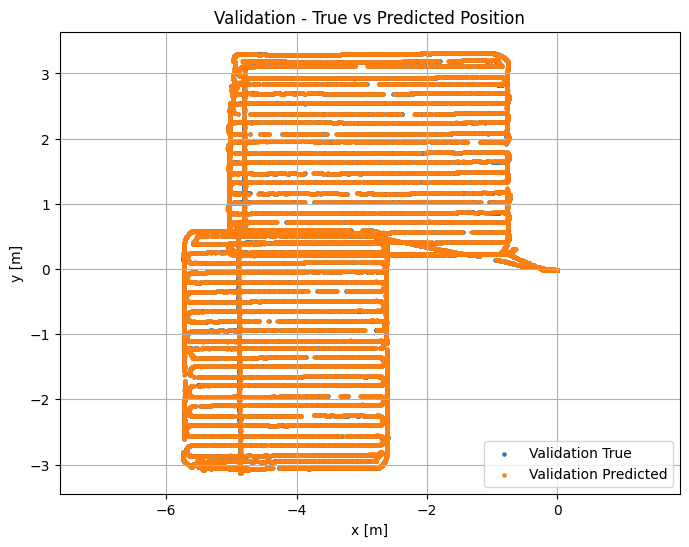

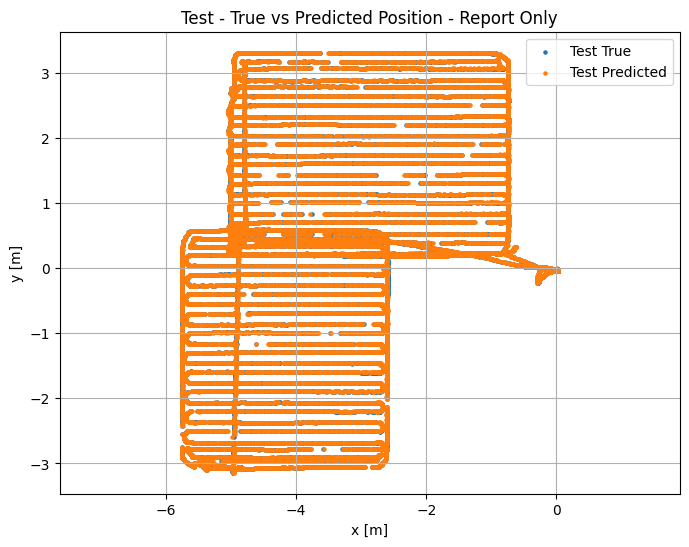

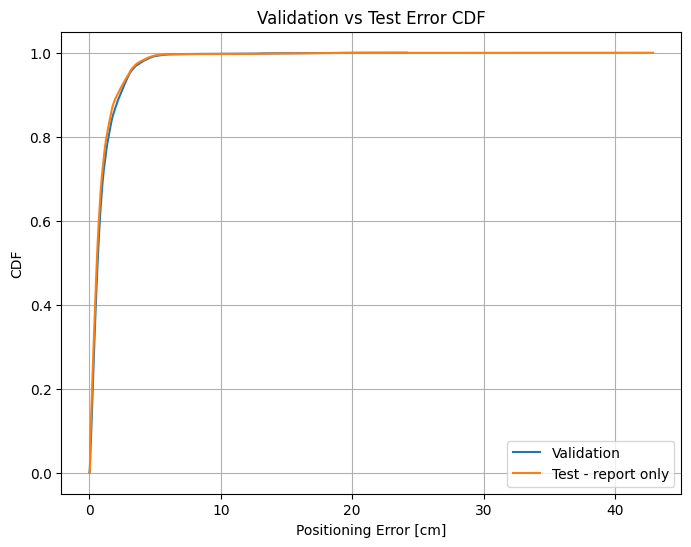

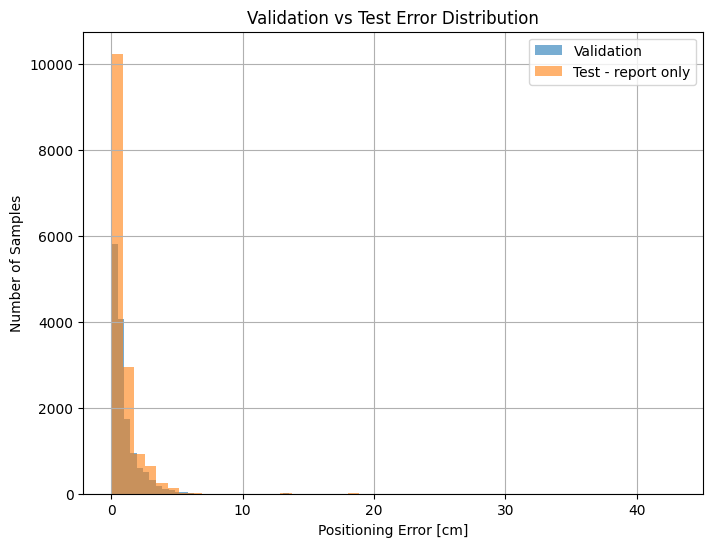


Done. Validation + test report completed.
Validation can be used for analysis.
Test is report-only and must not be used for model decisions.


In [ ]:
# ============================================================
# LOAD SAVED RESIDUAL ATTENTION MODEL
# VALIDATION + TEST EVALUATION
#
# This code:
#   1) Mounts Google Drive
#   2) Loads FINAL_SELECTED Residual Attention model
#   3) Loads normalization + selected antenna mask
#   4) Builds validation arrays
#   5) Builds test arrays
#   6) Evaluates validation
#   7) Evaluates test as report-only
#   8) Saves validation + test report
#
# IMPORTANT:
#   Validation can be used for analysis.
#   Test is report-only and must not be used for decisions.
# ============================================================

import os
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras import layers


# ============================================================
# Mount Google Drive
# ============================================================

from google.colab import drive
drive.mount("/content/drive")


# ============================================================
# Safety check
# ============================================================

required_objects = [
    "val_runs",
    "test_runs",
]

for obj in required_objects:
    if obj not in globals():
        raise RuntimeError(
            f"{obj} is not defined. "
            f"Run the preprocessing cells first so that val_runs and test_runs exist."
        )

print("Validation and test runs found.")


# ============================================================
# Custom layer required for loading Residual Attention model
# ============================================================

@tf.keras.utils.register_keras_serializable()
class AntennaEnergyLayer(layers.Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def call(self, inputs):
        # inputs shape: (batch, 32, 32, 2)
        # output shape: (batch, 32)
        return tf.reduce_mean(tf.abs(inputs), axis=[2, 3])

    def get_config(self):
        return super().get_config()


# ============================================================
# Paths
# ============================================================

BASE_SAVE_DIR = "/content/drive/MyDrive/DICHASUS_tracking_experiments/residual_attention_ig_source"

MODEL_SAVE_DIR = os.path.join(
    BASE_SAVE_DIR,
    "saved_tracking_residual_attention_models"
)

RESULT_SAVE_DIR = os.path.join(
    BASE_SAVE_DIR,
    "saved_tracking_residual_attention_results"
)

model_path = os.path.join(
    MODEL_SAVE_DIR,
    "FINAL_SELECTED_residual_attention_model.keras"
)

norm_path = os.path.join(
    RESULT_SAVE_DIR,
    "FINAL_SELECTED_residual_attention_normalization.npz"
)

combined_report_path = os.path.join(
    RESULT_SAVE_DIR,
    "LOADED_MODEL_validation_and_test_report.csv"
)

validation_predictions_path = os.path.join(
    RESULT_SAVE_DIR,
    "LOADED_MODEL_validation_predictions.npz"
)

test_predictions_path = os.path.join(
    RESULT_SAVE_DIR,
    "LOADED_MODEL_test_predictions_report_only.npz"
)

print("Model path:")
print(model_path)

print("\nNormalization path:")
print(norm_path)


# ============================================================
# Check files exist
# ============================================================

if not os.path.exists(model_path):
    raise FileNotFoundError(
        f"Model file not found:\n{model_path}\n"
        f"Make sure you already trained and saved the model."
    )

if not os.path.exists(norm_path):
    raise FileNotFoundError(
        f"Normalization file not found:\n{norm_path}\n"
        f"Make sure you already saved FINAL_SELECTED normalization."
    )

print("\nModel and normalization files exist.")


# ============================================================
# Helper functions
# ============================================================

def build_tracking_arrays_from_runs(
    runs,
    antenna_mask,
    horizon=1
):
    X_pos_t_list = []
    X_csi_tplus1_list = []
    X_mask_list = []
    y_pos_tplus1_list = []

    for run_idx, run in enumerate(runs):
        if "X_csi" not in run:
            raise KeyError(f"Run {run_idx} does not contain key 'X_csi'.")

        if "pos" not in run:
            raise KeyError(f"Run {run_idx} does not contain key 'pos'.")

        X_csi = run["X_csi"].astype(np.float32)
        pos = run["pos"].astype(np.float32)

        if len(X_csi) != len(pos):
            raise ValueError(
                f"Run {run_idx}: X_csi and pos have different lengths. "
                f"X_csi length = {len(X_csi)}, pos length = {len(pos)}"
            )

        if len(X_csi) <= horizon:
            print(f"Skipping run {run_idx}: too short.")
            continue

        pos_t = pos[:-horizon]
        csi_tplus1 = X_csi[horizon:]
        pos_tplus1 = pos[horizon:]

        mask_repeated = np.repeat(
            antenna_mask[None, :],
            repeats=pos_t.shape[0],
            axis=0
        ).astype(np.float32)

        X_pos_t_list.append(pos_t)
        X_csi_tplus1_list.append(csi_tplus1)
        X_mask_list.append(mask_repeated)
        y_pos_tplus1_list.append(pos_tplus1)

    if len(X_pos_t_list) == 0:
        raise RuntimeError("No valid runs found for tracking array construction.")

    X_pos_t_all = np.concatenate(X_pos_t_list, axis=0).astype(np.float32)
    X_csi_tplus1_all = np.concatenate(X_csi_tplus1_list, axis=0).astype(np.float32)
    X_mask_all = np.concatenate(X_mask_list, axis=0).astype(np.float32)
    y_pos_tplus1_all = np.concatenate(y_pos_tplus1_list, axis=0).astype(np.float32)

    return X_pos_t_all, X_csi_tplus1_all, X_mask_all, y_pos_tplus1_all


def normalize_csi(X_csi, csi_mean, csi_std):
    return ((X_csi - csi_mean) / csi_std).astype(np.float32)


def normalize_position(pos, pos_mean, pos_std):
    return ((pos - pos_mean) / pos_std).astype(np.float32)


def denormalize_position(pos_norm, pos_mean, pos_std):
    return (pos_norm * pos_std + pos_mean).astype(np.float32)


def make_tracking_dataset(
    X_pos_t_norm,
    X_csi_tplus1_norm,
    X_mask,
    y_pos_tplus1_norm,
    batch_size=64,
    shuffle=False,
    seed=42
):
    inputs = {
        "position_t_input": X_pos_t_norm.astype(np.float32),
        "csi_tplus1_input": X_csi_tplus1_norm.astype(np.float32),
        "antenna_mask_input": X_mask.astype(np.float32),
    }

    targets = y_pos_tplus1_norm.astype(np.float32)

    dataset = tf.data.Dataset.from_tensor_slices((inputs, targets))

    if shuffle:
        dataset = dataset.shuffle(
            buffer_size=min(len(targets), 20000),
            seed=seed,
            reshuffle_each_iteration=True
        )

    dataset = dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)

    return dataset


def compute_position_errors(
    y_true_meter,
    y_pred_meter
):
    error_vectors = y_pred_meter - y_true_meter

    errors = np.sqrt(
        error_vectors[:, 0] ** 2 +
        error_vectors[:, 1] ** 2
    )

    results = {
        "mean_error_m": float(np.mean(errors)),
        "median_error_m": float(np.median(errors)),
        "rmse_error_m": float(np.sqrt(np.mean(errors ** 2))),
        "std_error_m": float(np.std(errors)),
        "min_error_m": float(np.min(errors)),
        "max_error_m": float(np.max(errors)),
        "p75_error_m": float(np.percentile(errors, 75)),
        "p90_error_m": float(np.percentile(errors, 90)),
        "p95_error_m": float(np.percentile(errors, 95)),
        "acc_5cm_percent": float(np.mean(errors <= 0.05) * 100),
        "acc_10cm_percent": float(np.mean(errors <= 0.10) * 100),
        "acc_20cm_percent": float(np.mean(errors <= 0.20) * 100),
        "acc_30cm_percent": float(np.mean(errors <= 0.30) * 100),
        "acc_50cm_percent": float(np.mean(errors <= 0.50) * 100),
        "errors": errors,
    }

    return results


def evaluate_split(
    model,
    runs,
    split_name,
    antenna_mask,
    csi_mean,
    csi_std,
    pos_mean,
    pos_std,
    batch_size=64,
    horizon=1,
    seed=42
):
    X_pos_t, X_csi_tplus1, X_mask, y_pos_tplus1 = (
        build_tracking_arrays_from_runs(
            runs,
            antenna_mask=antenna_mask,
            horizon=horizon
        )
    )

    print()
    print("=" * 90)
    print(f"{split_name.upper()} SHAPES")
    print("=" * 90)
    print("X_pos_t:", X_pos_t.shape)
    print("X_csi_tplus1:", X_csi_tplus1.shape)
    print("X_mask:", X_mask.shape)
    print("y_pos_tplus1:", y_pos_tplus1.shape)

    X_csi_tplus1_norm = normalize_csi(
        X_csi_tplus1,
        csi_mean,
        csi_std
    )

    X_pos_t_norm = normalize_position(
        X_pos_t,
        pos_mean,
        pos_std
    )

    y_pos_tplus1_norm = normalize_position(
        y_pos_tplus1,
        pos_mean,
        pos_std
    )

    dataset = make_tracking_dataset(
        X_pos_t_norm=X_pos_t_norm,
        X_csi_tplus1_norm=X_csi_tplus1_norm,
        X_mask=X_mask,
        y_pos_tplus1_norm=y_pos_tplus1_norm,
        batch_size=batch_size,
        shuffle=False,
        seed=seed
    )

    y_pred_norm = model.predict(
        dataset,
        verbose=0
    )

    y_pred_meter = denormalize_position(
        y_pred_norm,
        pos_mean,
        pos_std
    )

    results = compute_position_errors(
        y_true_meter=y_pos_tplus1,
        y_pred_meter=y_pred_meter
    )

    return {
        "split_name": split_name,
        "X_pos_t": X_pos_t,
        "X_csi_tplus1": X_csi_tplus1,
        "X_mask": X_mask,
        "y_true_meter": y_pos_tplus1,
        "y_pred_norm": y_pred_norm,
        "y_pred_meter": y_pred_meter,
        "results": results,
    }


def print_results(results, title):
    print()
    print("=" * 90)
    print(title)
    print("=" * 90)

    print(f"Mean Error:        {results['mean_error_m'] * 100:.2f} cm")
    print(f"Median Error:      {results['median_error_m'] * 100:.2f} cm")
    print(f"RMSE Error:        {results['rmse_error_m'] * 100:.2f} cm")
    print(f"Std Error:         {results['std_error_m'] * 100:.2f} cm")
    print(f"P75 Error:         {results['p75_error_m'] * 100:.2f} cm")
    print(f"P90 Error:         {results['p90_error_m'] * 100:.2f} cm")
    print(f"P95 Error:         {results['p95_error_m'] * 100:.2f} cm")
    print()
    print(f"Accuracy <= 5 cm:  {results['acc_5cm_percent']:.2f}%")
    print(f"Accuracy <= 10 cm: {results['acc_10cm_percent']:.2f}%")
    print(f"Accuracy <= 20 cm: {results['acc_20cm_percent']:.2f}%")
    print(f"Accuracy <= 30 cm: {results['acc_30cm_percent']:.2f}%")
    print(f"Accuracy <= 50 cm: {results['acc_50cm_percent']:.2f}%")


# ============================================================
# Load model and normalization
# ============================================================

model = tf.keras.models.load_model(
    model_path,
    custom_objects={
        "AntennaEnergyLayer": AntennaEnergyLayer
    }
)

norm_data = np.load(
    norm_path,
    allow_pickle=True
)

csi_mean = norm_data["csi_mean"]
csi_std = norm_data["csi_std"]

pos_mean = norm_data["pos_mean"]
pos_std = norm_data["pos_std"]

antenna_mask = norm_data["antenna_mask"]
selected_antennas = norm_data["selected_antennas"]
selected_antenna_names = norm_data["selected_antenna_names"]

requested_percentage = norm_data["requested_percentage"].item()
actual_percentage = norm_data["actual_percentage"].item()
num_selected_antennas = norm_data["num_selected_antennas"].item()
num_removed_antennas = norm_data["num_removed_antennas"].item()

print("\nModel loaded successfully.")

print("\nSelected model info:")
print(f"Requested percentage: {requested_percentage}%")
print(f"Actual percentage:    {actual_percentage:.2f}%")
print(f"Selected antennas:    {num_selected_antennas}/32")
print(f"Removed antennas:     {num_removed_antennas}/32")

print("\nSelected antenna indices:")
print(selected_antennas)

print("\nSelected antenna names:")
print(selected_antenna_names)


# ============================================================
# Evaluate validation and test
# ============================================================

HORIZON = 1
BATCH_SIZE = 64
SEED = 42

validation_output = evaluate_split(
    model=model,
    runs=val_runs,
    split_name="validation",
    antenna_mask=antenna_mask,
    csi_mean=csi_mean,
    csi_std=csi_std,
    pos_mean=pos_mean,
    pos_std=pos_std,
    batch_size=BATCH_SIZE,
    horizon=HORIZON,
    seed=SEED
)

test_output = evaluate_split(
    model=model,
    runs=test_runs,
    split_name="test_report_only",
    antenna_mask=antenna_mask,
    csi_mean=csi_mean,
    csi_std=csi_std,
    pos_mean=pos_mean,
    pos_std=pos_std,
    batch_size=BATCH_SIZE,
    horizon=HORIZON,
    seed=SEED
)


# ============================================================
# Print results
# ============================================================

val_results = validation_output["results"]
test_results = test_output["results"]

print_results(
    val_results,
    "VALIDATION RESULTS - Loaded Residual Attention Model"
)

print_results(
    test_results,
    "TEST RESULTS REPORT ONLY - Loaded Residual Attention Model"
)


# ============================================================
# Save combined validation + test report
# ============================================================

combined_report = {
    "architecture": "ResidualAttentionCNN",
    "model_path": model_path,
    "normalization_path": norm_path,

    "requested_percentage": requested_percentage,
    "actual_percentage": actual_percentage,
    "kept_antennas": num_selected_antennas,
    "removed_antennas": num_removed_antennas,
    "selected_antennas_indices": selected_antennas.tolist(),
    "selected_antennas_names": selected_antenna_names.tolist(),

    # Validation metrics
    "val_mean_error_m": val_results["mean_error_m"],
    "val_median_error_m": val_results["median_error_m"],
    "val_rmse_error_m": val_results["rmse_error_m"],
    "val_std_error_m": val_results["std_error_m"],
    "val_min_error_m": val_results["min_error_m"],
    "val_max_error_m": val_results["max_error_m"],
    "val_p75_error_m": val_results["p75_error_m"],
    "val_p90_error_m": val_results["p90_error_m"],
    "val_p95_error_m": val_results["p95_error_m"],
    "val_acc_5cm_percent": val_results["acc_5cm_percent"],
    "val_acc_10cm_percent": val_results["acc_10cm_percent"],
    "val_acc_20cm_percent": val_results["acc_20cm_percent"],
    "val_acc_30cm_percent": val_results["acc_30cm_percent"],
    "val_acc_50cm_percent": val_results["acc_50cm_percent"],

    # Test metrics - report only
    "test_mean_error_m_report_only": test_results["mean_error_m"],
    "test_median_error_m_report_only": test_results["median_error_m"],
    "test_rmse_error_m_report_only": test_results["rmse_error_m"],
    "test_std_error_m_report_only": test_results["std_error_m"],
    "test_min_error_m_report_only": test_results["min_error_m"],
    "test_max_error_m_report_only": test_results["max_error_m"],
    "test_p75_error_m_report_only": test_results["p75_error_m"],
    "test_p90_error_m_report_only": test_results["p90_error_m"],
    "test_p95_error_m_report_only": test_results["p95_error_m"],
    "test_acc_5cm_percent_report_only": test_results["acc_5cm_percent"],
    "test_acc_10cm_percent_report_only": test_results["acc_10cm_percent"],
    "test_acc_20cm_percent_report_only": test_results["acc_20cm_percent"],
    "test_acc_30cm_percent_report_only": test_results["acc_30cm_percent"],
    "test_acc_50cm_percent_report_only": test_results["acc_50cm_percent"],

    "test_usage": "report_only_not_used_for_decision",
}

combined_report_df = pd.DataFrame([combined_report])

combined_report_df.to_csv(
    combined_report_path,
    index=False
)

print()
print("Combined validation + test report saved to:")
print(combined_report_path)

display(combined_report_df)


# ============================================================
# Save validation predictions
# ============================================================

np.savez(
    validation_predictions_path,
    y_true_val_meter=validation_output["y_true_meter"],
    y_pred_val_meter=validation_output["y_pred_meter"],
    y_pred_val_norm=validation_output["y_pred_norm"],
    errors_val_meter=val_results["errors"],
    antenna_mask=antenna_mask,
    selected_antennas=selected_antennas,
    selected_antenna_names=selected_antenna_names,
    requested_percentage=requested_percentage,
    actual_percentage=actual_percentage,
    num_selected_antennas=num_selected_antennas,
    num_removed_antennas=num_removed_antennas,
)

print("\nValidation predictions saved to:")
print(validation_predictions_path)


# ============================================================
# Save test predictions - report only
# ============================================================

np.savez(
    test_predictions_path,
    y_true_test_meter=test_output["y_true_meter"],
    y_pred_test_meter=test_output["y_pred_meter"],
    y_pred_test_norm=test_output["y_pred_norm"],
    errors_test_meter=test_results["errors"],
    antenna_mask=antenna_mask,
    selected_antennas=selected_antennas,
    selected_antenna_names=selected_antenna_names,
    requested_percentage=requested_percentage,
    actual_percentage=actual_percentage,
    num_selected_antennas=num_selected_antennas,
    num_removed_antennas=num_removed_antennas,
)

print("\nTest predictions saved to:")
print(test_predictions_path)


# ============================================================
# Plot validation true vs predicted
# ============================================================

plt.figure(figsize=(8, 6))

plt.scatter(
    validation_output["y_true_meter"][:, 0],
    validation_output["y_true_meter"][:, 1],
    s=5,
    label="Validation True"
)

plt.scatter(
    validation_output["y_pred_meter"][:, 0],
    validation_output["y_pred_meter"][:, 1],
    s=5,
    label="Validation Predicted"
)

plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.title("Validation - True vs Predicted Position")
plt.axis("equal")
plt.grid(True)
plt.legend()
plt.show()


# ============================================================
# Plot test true vs predicted - report only
# ============================================================

plt.figure(figsize=(8, 6))

plt.scatter(
    test_output["y_true_meter"][:, 0],
    test_output["y_true_meter"][:, 1],
    s=5,
    label="Test True"
)

plt.scatter(
    test_output["y_pred_meter"][:, 0],
    test_output["y_pred_meter"][:, 1],
    s=5,
    label="Test Predicted"
)

plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.title("Test - True vs Predicted Position - Report Only")
plt.axis("equal")
plt.grid(True)
plt.legend()
plt.show()


# ============================================================
# Plot validation and test CDF
# ============================================================

val_sorted_errors = np.sort(val_results["errors"])
val_cdf = np.arange(1, len(val_sorted_errors) + 1) / len(val_sorted_errors)

test_sorted_errors = np.sort(test_results["errors"])
test_cdf = np.arange(1, len(test_sorted_errors) + 1) / len(test_sorted_errors)

plt.figure(figsize=(8, 6))

plt.plot(
    val_sorted_errors * 100,
    val_cdf,
    label="Validation"
)

plt.plot(
    test_sorted_errors * 100,
    test_cdf,
    label="Test - report only"
)

plt.xlabel("Positioning Error [cm]")
plt.ylabel("CDF")
plt.title("Validation vs Test Error CDF")
plt.grid(True)
plt.legend()
plt.show()


# ============================================================
# Plot validation and test error histogram
# ============================================================

plt.figure(figsize=(8, 6))

plt.hist(
    val_results["errors"] * 100,
    bins=50,
    alpha=0.6,
    label="Validation"
)

plt.hist(
    test_results["errors"] * 100,
    bins=50,
    alpha=0.6,
    label="Test - report only"
)

plt.xlabel("Positioning Error [cm]")
plt.ylabel("Number of Samples")
plt.title("Validation vs Test Error Distribution")
plt.grid(True)
plt.legend()
plt.show()


print()
print("=" * 90)
print("Done. Validation + test report completed.")
print("=" * 90)
print("Validation can be used for analysis.")
print("Test is report-only and must not be used for model decisions.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive mounted.
Baseline models will be saved in:
/content/drive/MyDrive/DICHASUS_tracking_experiments/position_only_baseline/saved_tracking_position_baseline_models

Baseline results will be saved in:
/content/drive/MyDrive/DICHASUS_tracking_experiments/position_only_baseline/saved_tracking_position_baseline_results

Baseline plots will be saved in:
/content/drive/MyDrive/DICHASUS_tracking_experiments/position_only_baseline/saved_tracking_position_baseline_results/plots

Residual Attention result path:
/content/drive/MyDrive/DICHASUS_tracking_experiments/residual_attention_ig_source/saved_tracking_residual_attention_results/residual_attention_final_selected_test_result.csv

All required objects exist.
Train shapes:
X_train_pos_t: (43927, 2)
y_train_pos_tplus1: (43927, 2)

Validation shapes:
X_val_pos_t: (14510, 2)
y_val_pos_tplus1: (14510, 2)

Test sha

,model,uses_position_t,uses_csi,uses_antenna_mask,val_mean_error_m,val_median_error_m,val_rmse_error_m,val_std_error_m,val_p75_error_m,val_p90_error_m,...,test_acc_20cm_percent_report_only,test_acc_30cm_percent_report_only,test_acc_50cm_percent_report_only,best_model_path,final_model_path,normalization_path,history_path,best_val_loss,epochs_trained,test_usage
0,ZeroMotion,True,False,False,0.014442,0.014352,0.019121,0.012532,0.015349,0.019973,...,99.960609,99.993435,100.0,None,None,None,None,NaN,NaN,report_only_not_used_for_decision
1,PositionOnlyDeltaMLP,True,False,False,0.013887,0.014022,0.018844,0.012739,0.015446,0.021439,...,99.960609,99.993435,100.0,/content/drive/MyDrive/DICHASUS_tracking_exper...,/content/drive/MyDrive/DICHASUS_tracking_exper...,/content/drive/MyDrive/DICHASUS_tracking_exper...,/content/drive/MyDrive/DICHASUS_tracking_exper...,0.00003,50.0,report_only_not_used_for_decision


Baseline summary saved to: /content/drive/MyDrive/DICHASUS_tracking_experiments/position_only_baseline/saved_tracking_position_baseline_results/position_only_baseline_summary.csv

Validation-only baseline comparison


,model,mean_error_cm,median_error_cm,rmse_error_cm,p90_error_cm,acc_5cm_percent,acc_10cm_percent,split
0,ZeroMotion,1.444170,1.435203,1.912075,1.997340,99.538249,99.745003,validation
1,PositionOnlyDeltaMLP,1.388659,1.402191,1.884437,2.143885,99.400414,99.758787,validation


Validation comparison saved to: /content/drive/MyDrive/DICHASUS_tracking_experiments/position_only_baseline/saved_tracking_position_baseline_results/position_only_baseline_validation_comparison.csv

Baseline vs Residual Attention CNN comparison


,model,mean_error_cm,median_error_cm,rmse_error_cm,p90_error_cm,acc_5cm_percent,acc_10cm_percent,test_usage
0,ZeroMotion,1.382613,1.430347,1.963372,1.747336,99.533876,99.704569,report_only
1,PositionOnlyDeltaMLP,1.328711,1.384130,1.937044,2.009197,99.415704,99.717700,report_only
2,ResidualAttentionCNN,0.909386,0.558732,1.619595,2.120029,99.350053,99.704569,report_only


Comparison saved to: /content/drive/MyDrive/DICHASUS_tracking_experiments/position_only_baseline/saved_tracking_position_baseline_results/baseline_vs_residual_attention_comparison.csv
Saved plot to: /content/drive/MyDrive/DICHASUS_tracking_experiments/position_only_baseline/saved_tracking_position_baseline_results/plots/training_history_position_only_delta_baseline.png


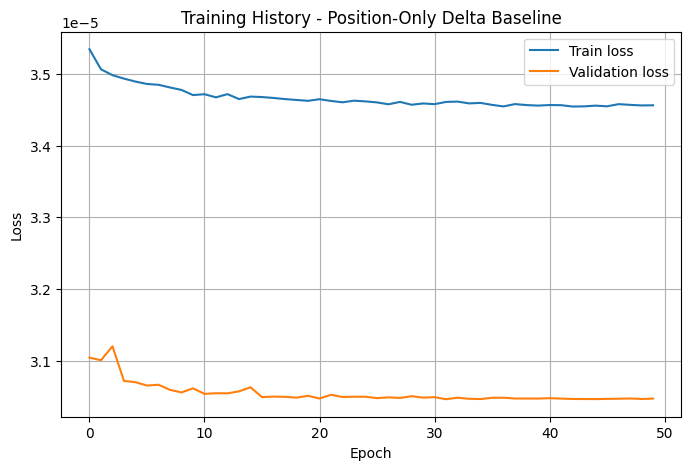

Saved plot to: /content/drive/MyDrive/DICHASUS_tracking_experiments/position_only_baseline/saved_tracking_position_baseline_results/plots/validation_error_comparison_position_only_baselines.png


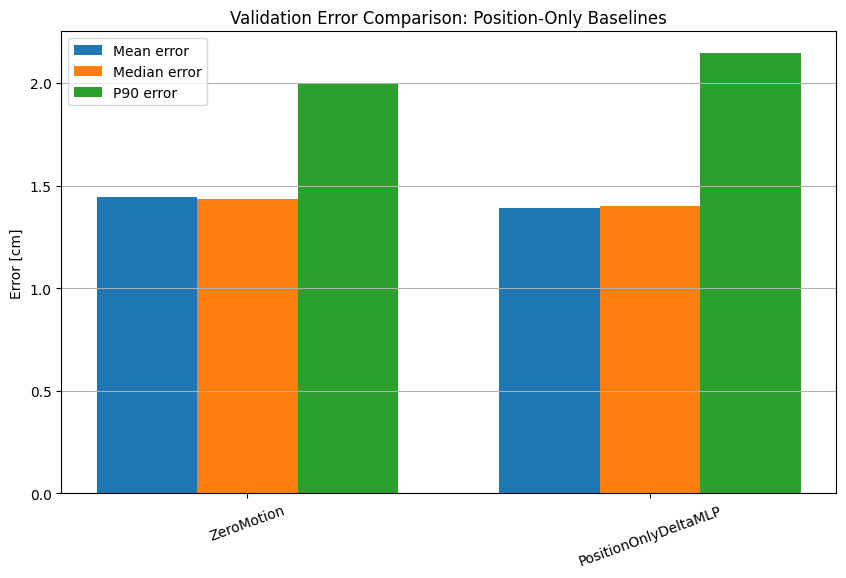

Saved plot to: /content/drive/MyDrive/DICHASUS_tracking_experiments/position_only_baseline/saved_tracking_position_baseline_results/plots/test_error_comparison_baselines_vs_residual_attention.png


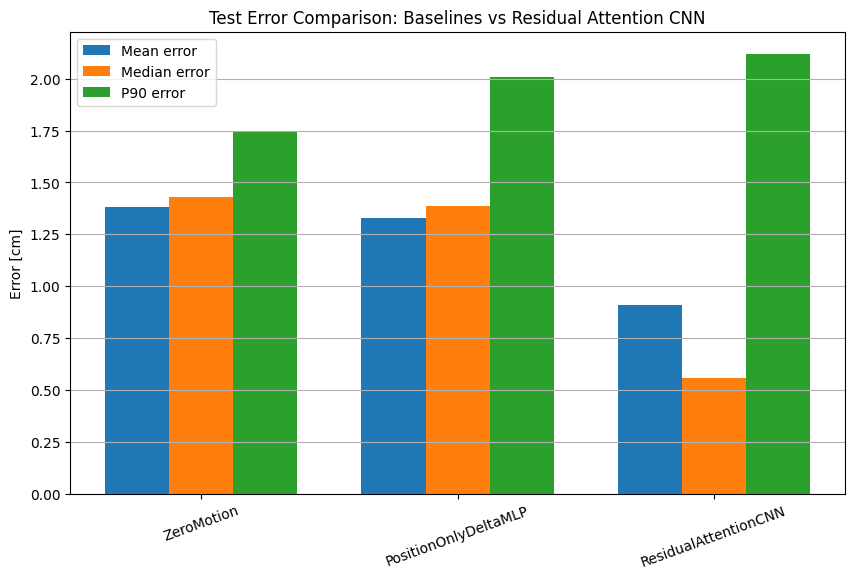

Saved plot to: /content/drive/MyDrive/DICHASUS_tracking_experiments/position_only_baseline/saved_tracking_position_baseline_results/plots/validation_error_cdf_position_only_baselines.png


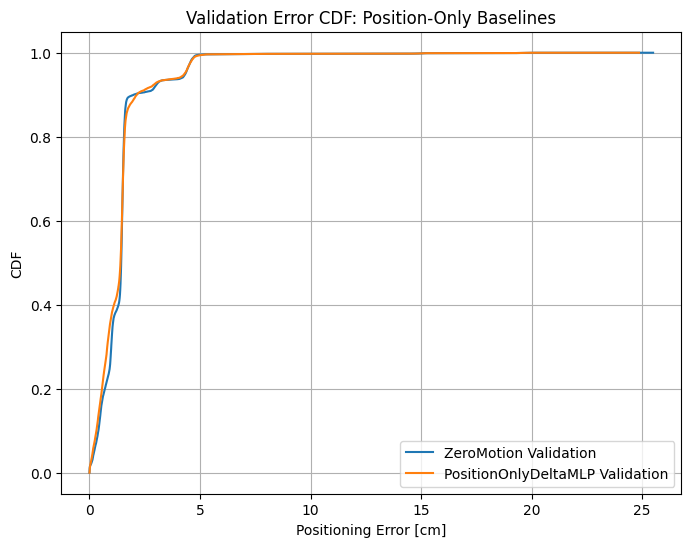

Saved plot to: /content/drive/MyDrive/DICHASUS_tracking_experiments/position_only_baseline/saved_tracking_position_baseline_results/plots/test_error_cdf_position_only_baselines.png


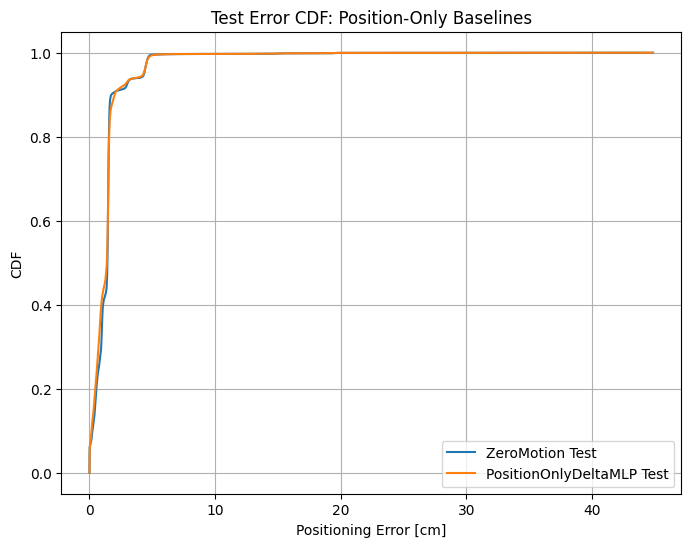


Saved files index


,baseline_summary_path,validation_comparison_path,comparison_path,predictions_path,best_model_path,final_model_path,normalization_path,history_path,plot_dir
0,/content/drive/MyDrive/DICHASUS_tracking_exper...,/content/drive/MyDrive/DICHASUS_tracking_exper...,/content/drive/MyDrive/DICHASUS_tracking_exper...,/content/drive/MyDrive/DICHASUS_tracking_exper...,/content/drive/MyDrive/DICHASUS_tracking_exper...,/content/drive/MyDrive/DICHASUS_tracking_exper...,/content/drive/MyDrive/DICHASUS_tracking_exper...,/content/drive/MyDrive/DICHASUS_tracking_exper...,/content/drive/MyDrive/DICHASUS_tracking_exper...


Saved files index saved to: /content/drive/MyDrive/DICHASUS_tracking_experiments/position_only_baseline/saved_tracking_position_baseline_results/position_only_baseline_saved_files_index.csv

Interpretation Guide
If ResidualAttentionCNN is much better than PositionOnlyDeltaMLP:
  -> CSI provides additional useful information beyond motion continuity.

If PositionOnlyDeltaMLP is very close to ResidualAttentionCNN:
  -> Most of the performance comes from position(t), not CSI.

If ZeroMotion is already very strong:
  -> The dataset has very small step-to-step motion, so tracking is naturally easy.

Done.
All baseline results were saved in:
/content/drive/MyDrive/DICHASUS_tracking_experiments/position_only_baseline/saved_tracking_position_baseline_results

All baseline models were saved in:
/content/drive/MyDrive/DICHASUS_tracking_experiments/position_only_baseline/saved_tracking_position_baseline_models

All baseline plots were saved in:
/content/drive/MyDrive/DICHASUS_tracking_experiments

In [ ]:
# ============================================================
# POSITION-ONLY BASELINE FOR CSI-AIDED TRACKING PROJECT
# SAVE-SAFE VERSION
# ============================================================
#
# Goal:
#   Check how much of the performance comes from position(t) alone.
#
# Baseline 1:
#   Zero-motion baseline:
#       position(t+1) = position(t)
#
# Baseline 2:
#   Learned position-only delta model:
#       input : position(t)
#       output: position(t+1)
#
# This baseline does NOT use CSI.
# This baseline does NOT use antenna mask.
#
# Saves:
#   - best/final PositionOnlyDeltaMLP model
#   - normalization
#   - training history
#   - validation/test baseline summary
#   - baseline vs Residual Attention comparison
#   - predictions and errors
#   - plots
#
# Important:
#   Validation metrics are for analysis.
#   Test metrics are report-only.
# ============================================================

import os
import gc
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras import layers, Model


# ============================================================
# Mount Google Drive
# ============================================================

USE_GOOGLE_DRIVE = True

if USE_GOOGLE_DRIVE:
    try:
        from google.colab import drive
        drive.mount("/content/drive")
        print("Google Drive mounted.")
    except Exception as e:
        print("Could not mount Google Drive. Falling back to local storage.")
        print(e)


# ============================================================
# Global settings
# ============================================================

SEED = 42
BATCH_SIZE = 64
EPOCHS = 150
HORIZON = 1

np.random.seed(SEED)
tf.random.set_seed(SEED)


# ============================================================
# Output folders
# ============================================================

if USE_GOOGLE_DRIVE:
    BASE_SAVE_DIR = "/content/drive/MyDrive/DICHASUS_tracking_experiments/position_only_baseline"
else:
    BASE_SAVE_DIR = "DICHASUS_tracking_experiments/position_only_baseline"


BASELINE_MODEL_SAVE_DIR = os.path.join(
    BASE_SAVE_DIR,
    "saved_tracking_position_baseline_models"
)

BASELINE_RESULT_SAVE_DIR = os.path.join(
    BASE_SAVE_DIR,
    "saved_tracking_position_baseline_results"
)

BASELINE_PLOT_SAVE_DIR = os.path.join(
    BASELINE_RESULT_SAVE_DIR,
    "plots"
)

os.makedirs(BASELINE_MODEL_SAVE_DIR, exist_ok=True)
os.makedirs(BASELINE_RESULT_SAVE_DIR, exist_ok=True)
os.makedirs(BASELINE_PLOT_SAVE_DIR, exist_ok=True)

print("Baseline models will be saved in:")
print(BASELINE_MODEL_SAVE_DIR)

print("\nBaseline results will be saved in:")
print(BASELINE_RESULT_SAVE_DIR)

print("\nBaseline plots will be saved in:")
print(BASELINE_PLOT_SAVE_DIR)


# ============================================================
# Optional Residual Attention comparison path
# ============================================================

if USE_GOOGLE_DRIVE:
    RESIDUAL_ATTENTION_RESULT_DIR = (
        "/content/drive/MyDrive/DICHASUS_tracking_experiments/"
        "residual_attention_ig_source/"
        "saved_tracking_residual_attention_results"
    )
else:
    RESIDUAL_ATTENTION_RESULT_DIR = (
        "DICHASUS_tracking_experiments/"
        "residual_attention_ig_source/"
        "saved_tracking_residual_attention_results"
    )

residual_attention_result_path = os.path.join(
    RESIDUAL_ATTENTION_RESULT_DIR,
    "residual_attention_final_selected_test_result.csv"
)

print("\nResidual Attention result path:")
print(residual_attention_result_path)


# ============================================================
# Safety checks
# ============================================================

required_objects = [
    "train_runs",
    "val_runs",
    "test_runs",
]

for obj in required_objects:
    if obj not in globals():
        raise RuntimeError(
            f"{obj} is not defined. "
            f"Run the preprocessing and train/val/test split cells first."
        )

print("\nAll required objects exist.")


# ============================================================
# Build position-only tracking arrays
# ============================================================

def build_position_tracking_arrays_from_runs(
    runs,
    horizon=1
):
    X_pos_t_list = []
    y_pos_tplus1_list = []

    for run_idx, run in enumerate(runs):
        if "pos" not in run:
            raise KeyError(f"Run {run_idx} does not contain key 'pos'.")

        pos = run["pos"].astype(np.float32)

        if len(pos) <= horizon:
            print(f"Skipping run {run_idx}: too short.")
            continue

        pos_t = pos[:-horizon]
        pos_tplus1 = pos[horizon:]

        X_pos_t_list.append(pos_t)
        y_pos_tplus1_list.append(pos_tplus1)

    if len(X_pos_t_list) == 0:
        raise RuntimeError("No valid runs found for position baseline construction.")

    X_pos_t_all = np.concatenate(X_pos_t_list, axis=0).astype(np.float32)
    y_pos_tplus1_all = np.concatenate(y_pos_tplus1_list, axis=0).astype(np.float32)

    return X_pos_t_all, y_pos_tplus1_all


# ============================================================
# Position normalization
# ============================================================

def compute_position_normalization_stats(y_train):
    pos_mean = y_train.mean(
        axis=0,
        keepdims=True
    ).astype(np.float32)

    pos_std = y_train.std(
        axis=0,
        keepdims=True
    ).astype(np.float32) + 1e-8

    return pos_mean, pos_std


def normalize_position(pos, pos_mean, pos_std):
    return ((pos - pos_mean) / pos_std).astype(np.float32)


def denormalize_position(pos_norm, pos_mean, pos_std):
    return (pos_norm * pos_std + pos_mean).astype(np.float32)


# ============================================================
# Dataset builder
# ============================================================

def make_position_dataset(
    X_pos_t_norm,
    y_pos_tplus1_norm,
    batch_size=64,
    shuffle=False,
    seed=42
):
    inputs = {
        "position_t_input": X_pos_t_norm.astype(np.float32)
    }

    targets = y_pos_tplus1_norm.astype(np.float32)

    dataset = tf.data.Dataset.from_tensor_slices((inputs, targets))

    if shuffle:
        dataset = dataset.shuffle(
            buffer_size=min(len(targets), 20000),
            seed=seed,
            reshuffle_each_iteration=True
        )

    dataset = dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)

    return dataset


# ============================================================
# Error metrics
# ============================================================

def compute_position_error_metrics(
    y_true_meter,
    y_pred_meter,
    label="Dataset"
):
    error_vectors = y_pred_meter - y_true_meter

    errors = np.sqrt(
        error_vectors[:, 0] ** 2 +
        error_vectors[:, 1] ** 2
    )

    results = {
        "mean_error_m": float(np.mean(errors)),
        "median_error_m": float(np.median(errors)),
        "rmse_error_m": float(np.sqrt(np.mean(errors ** 2))),
        "std_error_m": float(np.std(errors)),
        "min_error_m": float(np.min(errors)),
        "max_error_m": float(np.max(errors)),
        "p75_error_m": float(np.percentile(errors, 75)),
        "p90_error_m": float(np.percentile(errors, 90)),
        "p95_error_m": float(np.percentile(errors, 95)),
        "acc_5cm_percent": float(np.mean(errors <= 0.05) * 100),
        "acc_10cm_percent": float(np.mean(errors <= 0.10) * 100),
        "acc_20cm_percent": float(np.mean(errors <= 0.20) * 100),
        "acc_30cm_percent": float(np.mean(errors <= 0.30) * 100),
        "acc_50cm_percent": float(np.mean(errors <= 0.50) * 100),
        "errors": errors,
        "predictions_meter": y_pred_meter,
    }

    print()
    print(label)
    print("-" * 70)
    print(f"Mean Error:              {results['mean_error_m']:.4f} m")
    print(f"Median Error:            {results['median_error_m']:.4f} m")
    print(f"RMSE Error:              {results['rmse_error_m']:.4f} m")
    print(f"75th Percentile Error:   {results['p75_error_m']:.4f} m")
    print(f"90th Percentile Error:   {results['p90_error_m']:.4f} m")
    print(f"95th Percentile Error:   {results['p95_error_m']:.4f} m")
    print()
    print(f"Accuracy <= 5 cm:        {results['acc_5cm_percent']:.2f}%")
    print(f"Accuracy <= 10 cm:       {results['acc_10cm_percent']:.2f}%")
    print(f"Accuracy <= 20 cm:       {results['acc_20cm_percent']:.2f}%")
    print(f"Accuracy <= 30 cm:       {results['acc_30cm_percent']:.2f}%")
    print(f"Accuracy <= 50 cm:       {results['acc_50cm_percent']:.2f}%")
    print()

    return results


def evaluate_position_only_model(
    model,
    dataset,
    y_true_meter,
    pos_mean,
    pos_std,
    label="Dataset"
):
    y_pred_norm = model.predict(
        dataset,
        verbose=0
    )

    y_pred_meter = denormalize_position(
        y_pred_norm,
        pos_mean,
        pos_std
    )

    results = compute_position_error_metrics(
        y_true_meter=y_true_meter,
        y_pred_meter=y_pred_meter,
        label=label
    )

    return results


# ============================================================
# Position-only delta model
# ============================================================

def build_position_only_delta_model(seed=42):
    tf.keras.backend.clear_session()
    np.random.seed(seed)
    tf.random.set_seed(seed)

    position_t_input = tf.keras.Input(
        shape=(2,),
        name="position_t_input"
    )

    x = layers.Dense(
        64,
        activation="relu",
        name="position_dense_1"
    )(position_t_input)

    x = layers.BatchNormalization(
        name="position_bn_1"
    )(x)

    x = layers.Dropout(
        0.05,
        name="position_dropout_1"
    )(x)

    x = layers.Dense(
        64,
        activation="relu",
        name="position_dense_2"
    )(x)

    x = layers.Dense(
        32,
        activation="relu",
        name="position_dense_3"
    )(x)

    delta_position_norm = layers.Dense(
        2,
        activation="linear",
        kernel_initializer=tf.keras.initializers.RandomNormal(
            mean=0.0,
            stddev=1e-3,
            seed=seed
        ),
        bias_initializer="zeros",
        name="delta_position_norm"
    )(x)

    output_position_norm = layers.Add(
        name="position_tplus1_output"
    )([position_t_input, delta_position_norm])

    model = Model(
        inputs={
            "position_t_input": position_t_input
        },
        outputs=output_position_norm,
        name=f"position_only_delta_baseline_seed_{seed}"
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=2e-4),
        loss=tf.keras.losses.Huber(delta=1.0),
        metrics=["mae"]
    )

    return model


# ============================================================
# Plot helpers with save option
# ============================================================

def plot_training_history(history_df, title="Training History", save_path=None):
    plt.figure(figsize=(8, 5))

    plt.plot(
        history_df["loss"],
        label="Train loss"
    )

    plt.plot(
        history_df["val_loss"],
        label="Validation loss"
    )

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title)
    plt.grid(True)
    plt.legend()

    if save_path is not None:
        plt.savefig(
            save_path,
            dpi=300,
            bbox_inches="tight"
        )
        print(f"Saved plot to: {save_path}")

    plt.show()


def plot_error_cdf(errors_dict, title="Error CDF Comparison", save_path=None):
    plt.figure(figsize=(8, 6))

    for label, errors in errors_dict.items():
        sorted_errors = np.sort(errors)
        cdf = np.arange(1, len(sorted_errors) + 1) / len(sorted_errors)

        plt.plot(
            sorted_errors * 100,
            cdf,
            label=label
        )

    plt.xlabel("Positioning Error [cm]")
    plt.ylabel("CDF")
    plt.title(title)
    plt.grid(True)
    plt.legend()

    if save_path is not None:
        plt.savefig(
            save_path,
            dpi=300,
            bbox_inches="tight"
        )
        print(f"Saved plot to: {save_path}")

    plt.show()


def plot_bar_comparison(comparison_df, title="Model Comparison", save_path=None):
    labels = comparison_df["model"].tolist()

    x = np.arange(len(labels))
    width = 0.25

    plt.figure(figsize=(10, 6))

    plt.bar(
        x - width,
        comparison_df["mean_error_cm"],
        width,
        label="Mean error"
    )

    plt.bar(
        x,
        comparison_df["median_error_cm"],
        width,
        label="Median error"
    )

    plt.bar(
        x + width,
        comparison_df["p90_error_cm"],
        width,
        label="P90 error"
    )

    plt.xticks(x, labels, rotation=20)
    plt.ylabel("Error [cm]")
    plt.title(title)
    plt.grid(True, axis="y")
    plt.legend()

    if save_path is not None:
        plt.savefig(
            save_path,
            dpi=300,
            bbox_inches="tight"
        )
        print(f"Saved plot to: {save_path}")

    plt.show()


# ============================================================
# Build train / validation / test arrays
# ============================================================

X_train_pos_t, y_train_pos_tplus1 = build_position_tracking_arrays_from_runs(
    train_runs,
    horizon=HORIZON
)

X_val_pos_t, y_val_pos_tplus1 = build_position_tracking_arrays_from_runs(
    val_runs,
    horizon=HORIZON
)

X_test_pos_t, y_test_pos_tplus1 = build_position_tracking_arrays_from_runs(
    test_runs,
    horizon=HORIZON
)

print("Train shapes:")
print("X_train_pos_t:", X_train_pos_t.shape)
print("y_train_pos_tplus1:", y_train_pos_tplus1.shape)

print("\nValidation shapes:")
print("X_val_pos_t:", X_val_pos_t.shape)
print("y_val_pos_tplus1:", y_val_pos_tplus1.shape)

print("\nTest shapes:")
print("X_test_pos_t:", X_test_pos_t.shape)
print("y_test_pos_tplus1:", y_test_pos_tplus1.shape)


# ============================================================
# Baseline 1: Zero-motion baseline
# position(t+1) = position(t)
# ============================================================

print()
print("=" * 90)
print("Baseline 1: Zero-Motion Baseline")
print("=" * 90)

zero_motion_val_results = compute_position_error_metrics(
    y_true_meter=y_val_pos_tplus1,
    y_pred_meter=X_val_pos_t,
    label="Validation - Zero-Motion Baseline"
)

zero_motion_test_results = compute_position_error_metrics(
    y_true_meter=y_test_pos_tplus1,
    y_pred_meter=X_test_pos_t,
    label="Test Report Only - Zero-Motion Baseline"
)


# ============================================================
# Normalize positions using train targets only
# ============================================================

pos_mean, pos_std = compute_position_normalization_stats(
    y_train_pos_tplus1
)

X_train_pos_t_norm = normalize_position(
    X_train_pos_t,
    pos_mean,
    pos_std
)

X_val_pos_t_norm = normalize_position(
    X_val_pos_t,
    pos_mean,
    pos_std
)

X_test_pos_t_norm = normalize_position(
    X_test_pos_t,
    pos_mean,
    pos_std
)

y_train_pos_tplus1_norm = normalize_position(
    y_train_pos_tplus1,
    pos_mean,
    pos_std
)

y_val_pos_tplus1_norm = normalize_position(
    y_val_pos_tplus1,
    pos_mean,
    pos_std
)

y_test_pos_tplus1_norm = normalize_position(
    y_test_pos_tplus1,
    pos_mean,
    pos_std
)

print()
print("pos_mean:", pos_mean)
print("pos_std:", pos_std)


# ============================================================
# Create datasets
# ============================================================

train_dataset = make_position_dataset(
    X_pos_t_norm=X_train_pos_t_norm,
    y_pos_tplus1_norm=y_train_pos_tplus1_norm,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

val_dataset = make_position_dataset(
    X_pos_t_norm=X_val_pos_t_norm,
    y_pos_tplus1_norm=y_val_pos_tplus1_norm,
    batch_size=BATCH_SIZE,
    shuffle=False,
    seed=SEED
)

test_dataset = make_position_dataset(
    X_pos_t_norm=X_test_pos_t_norm,
    y_pos_tplus1_norm=y_test_pos_tplus1_norm,
    batch_size=BATCH_SIZE,
    shuffle=False,
    seed=SEED
)


# ============================================================
# Baseline 2: Learned position-only delta model
# ============================================================

print()
print("=" * 90)
print("Baseline 2: Learned Position-Only Delta Model")
print("=" * 90)

best_model_path = os.path.join(
    BASELINE_MODEL_SAVE_DIR,
    "best_position_only_delta_baseline.keras"
)

final_model_path = os.path.join(
    BASELINE_MODEL_SAVE_DIR,
    "final_position_only_delta_baseline.keras"
)

history_path = os.path.join(
    BASELINE_RESULT_SAVE_DIR,
    "history_position_only_delta_baseline.csv"
)

norm_path = os.path.join(
    BASELINE_RESULT_SAVE_DIR,
    "normalization_position_only_delta_baseline.npz"
)

FORCE_RETRAIN_BASELINE = False

history_df = None

if os.path.exists(best_model_path) and os.path.exists(norm_path) and not FORCE_RETRAIN_BASELINE:
    print("Existing saved position-only model found.")
    print("Loading model instead of retraining.")

    position_only_model = tf.keras.models.load_model(
        best_model_path
    )

    if os.path.exists(history_path):
        history_df = pd.read_csv(history_path)

else:
    print("Training position-only model from scratch.")

    position_only_model = build_position_only_delta_model(
        seed=SEED
    )

    position_only_model.summary()

    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=18,
            restore_best_weights=True,
            verbose=1
        ),

        tf.keras.callbacks.ModelCheckpoint(
            filepath=best_model_path,
            monitor="val_loss",
            save_best_only=True,
            save_weights_only=False,
            verbose=1
        ),

        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=8,
            min_lr=1e-6,
            verbose=1
        )
    ]

    history = position_only_model.fit(
        train_dataset,
        validation_data=val_dataset,
        epochs=EPOCHS,
        callbacks=callbacks,
        verbose=1
    )

    position_only_model.save(
        final_model_path
    )

    print(f"Best position-only model saved to:  {best_model_path}")
    print(f"Final position-only model saved to: {final_model_path}")

    history_df = pd.DataFrame(history.history)

    history_df.to_csv(
        history_path,
        index=False
    )

    print(f"Training history saved to: {history_path}")


# ============================================================
# Save normalization stats
# ============================================================

np.savez(
    norm_path,
    pos_mean=pos_mean,
    pos_std=pos_std
)

print(f"Normalization saved to: {norm_path}")


# ============================================================
# Evaluate learned position-only model
# ============================================================

position_only_val_results = evaluate_position_only_model(
    model=position_only_model,
    dataset=val_dataset,
    y_true_meter=y_val_pos_tplus1,
    pos_mean=pos_mean,
    pos_std=pos_std,
    label="Validation - Learned Position-Only Delta Baseline"
)

position_only_test_results = evaluate_position_only_model(
    model=position_only_model,
    dataset=test_dataset,
    y_true_meter=y_test_pos_tplus1,
    pos_mean=pos_mean,
    pos_std=pos_std,
    label="Test Report Only - Learned Position-Only Delta Baseline"
)


# ============================================================
# Save predictions and errors
# ============================================================

predictions_path = os.path.join(
    BASELINE_RESULT_SAVE_DIR,
    "position_only_baseline_predictions_and_errors.npz"
)

np.savez(
    predictions_path,

    X_val_pos_t=X_val_pos_t,
    y_val_pos_tplus1=y_val_pos_tplus1,
    zero_motion_val_pred=X_val_pos_t,
    zero_motion_val_errors=zero_motion_val_results["errors"],
    position_only_val_pred=position_only_val_results["predictions_meter"],
    position_only_val_errors=position_only_val_results["errors"],

    X_test_pos_t=X_test_pos_t,
    y_test_pos_tplus1=y_test_pos_tplus1,
    zero_motion_test_pred=X_test_pos_t,
    zero_motion_test_errors=zero_motion_test_results["errors"],
    position_only_test_pred=position_only_test_results["predictions_meter"],
    position_only_test_errors=position_only_test_results["errors"],

    pos_mean=pos_mean,
    pos_std=pos_std,
)

print()
print(f"Predictions and errors saved to: {predictions_path}")


# ============================================================
# Save baseline summary
# ============================================================

best_val_loss_value = None
epochs_trained_value = None

if history_df is not None and "val_loss" in history_df.columns:
    best_val_loss_value = float(history_df["val_loss"].min())
    epochs_trained_value = int(len(history_df))

baseline_summary = [
    {
        "model": "ZeroMotion",
        "uses_position_t": True,
        "uses_csi": False,
        "uses_antenna_mask": False,

        "val_mean_error_m": zero_motion_val_results["mean_error_m"],
        "val_median_error_m": zero_motion_val_results["median_error_m"],
        "val_rmse_error_m": zero_motion_val_results["rmse_error_m"],
        "val_std_error_m": zero_motion_val_results["std_error_m"],
        "val_p75_error_m": zero_motion_val_results["p75_error_m"],
        "val_p90_error_m": zero_motion_val_results["p90_error_m"],
        "val_p95_error_m": zero_motion_val_results["p95_error_m"],
        "val_acc_5cm_percent": zero_motion_val_results["acc_5cm_percent"],
        "val_acc_10cm_percent": zero_motion_val_results["acc_10cm_percent"],
        "val_acc_20cm_percent": zero_motion_val_results["acc_20cm_percent"],
        "val_acc_30cm_percent": zero_motion_val_results["acc_30cm_percent"],
        "val_acc_50cm_percent": zero_motion_val_results["acc_50cm_percent"],

        "test_mean_error_m_report_only": zero_motion_test_results["mean_error_m"],
        "test_median_error_m_report_only": zero_motion_test_results["median_error_m"],
        "test_rmse_error_m_report_only": zero_motion_test_results["rmse_error_m"],
        "test_std_error_m_report_only": zero_motion_test_results["std_error_m"],
        "test_p75_error_m_report_only": zero_motion_test_results["p75_error_m"],
        "test_p90_error_m_report_only": zero_motion_test_results["p90_error_m"],
        "test_p95_error_m_report_only": zero_motion_test_results["p95_error_m"],
        "test_acc_5cm_percent_report_only": zero_motion_test_results["acc_5cm_percent"],
        "test_acc_10cm_percent_report_only": zero_motion_test_results["acc_10cm_percent"],
        "test_acc_20cm_percent_report_only": zero_motion_test_results["acc_20cm_percent"],
        "test_acc_30cm_percent_report_only": zero_motion_test_results["acc_30cm_percent"],
        "test_acc_50cm_percent_report_only": zero_motion_test_results["acc_50cm_percent"],

        "best_model_path": None,
        "final_model_path": None,
        "normalization_path": None,
        "history_path": None,
        "best_val_loss": None,
        "epochs_trained": None,
        "test_usage": "report_only_not_used_for_decision",
    },

    {
        "model": "PositionOnlyDeltaMLP",
        "uses_position_t": True,
        "uses_csi": False,
        "uses_antenna_mask": False,

        "val_mean_error_m": position_only_val_results["mean_error_m"],
        "val_median_error_m": position_only_val_results["median_error_m"],
        "val_rmse_error_m": position_only_val_results["rmse_error_m"],
        "val_std_error_m": position_only_val_results["std_error_m"],
        "val_p75_error_m": position_only_val_results["p75_error_m"],
        "val_p90_error_m": position_only_val_results["p90_error_m"],
        "val_p95_error_m": position_only_val_results["p95_error_m"],
        "val_acc_5cm_percent": position_only_val_results["acc_5cm_percent"],
        "val_acc_10cm_percent": position_only_val_results["acc_10cm_percent"],
        "val_acc_20cm_percent": position_only_val_results["acc_20cm_percent"],
        "val_acc_30cm_percent": position_only_val_results["acc_30cm_percent"],
        "val_acc_50cm_percent": position_only_val_results["acc_50cm_percent"],

        "test_mean_error_m_report_only": position_only_test_results["mean_error_m"],
        "test_median_error_m_report_only": position_only_test_results["median_error_m"],
        "test_rmse_error_m_report_only": position_only_test_results["rmse_error_m"],
        "test_std_error_m_report_only": position_only_test_results["std_error_m"],
        "test_p75_error_m_report_only": position_only_test_results["p75_error_m"],
        "test_p90_error_m_report_only": position_only_test_results["p90_error_m"],
        "test_p95_error_m_report_only": position_only_test_results["p95_error_m"],
        "test_acc_5cm_percent_report_only": position_only_test_results["acc_5cm_percent"],
        "test_acc_10cm_percent_report_only": position_only_test_results["acc_10cm_percent"],
        "test_acc_20cm_percent_report_only": position_only_test_results["acc_20cm_percent"],
        "test_acc_30cm_percent_report_only": position_only_test_results["acc_30cm_percent"],
        "test_acc_50cm_percent_report_only": position_only_test_results["acc_50cm_percent"],

        "best_model_path": best_model_path,
        "final_model_path": final_model_path,
        "normalization_path": norm_path,
        "history_path": history_path,
        "best_val_loss": best_val_loss_value,
        "epochs_trained": epochs_trained_value,
        "test_usage": "report_only_not_used_for_decision",
    }
]

baseline_summary_df = pd.DataFrame(
    baseline_summary
)

baseline_summary_path = os.path.join(
    BASELINE_RESULT_SAVE_DIR,
    "position_only_baseline_summary.csv"
)

baseline_summary_df.to_csv(
    baseline_summary_path,
    index=False
)

print()
print("=" * 90)
print("Position-only baseline summary")
print("=" * 90)

display(baseline_summary_df)

print(f"Baseline summary saved to: {baseline_summary_path}")


# ============================================================
# Validation-only comparison
# ============================================================

validation_comparison_df = pd.DataFrame([
    {
        "model": "ZeroMotion",
        "mean_error_cm": zero_motion_val_results["mean_error_m"] * 100,
        "median_error_cm": zero_motion_val_results["median_error_m"] * 100,
        "rmse_error_cm": zero_motion_val_results["rmse_error_m"] * 100,
        "p90_error_cm": zero_motion_val_results["p90_error_m"] * 100,
        "acc_5cm_percent": zero_motion_val_results["acc_5cm_percent"],
        "acc_10cm_percent": zero_motion_val_results["acc_10cm_percent"],
        "split": "validation",
    },
    {
        "model": "PositionOnlyDeltaMLP",
        "mean_error_cm": position_only_val_results["mean_error_m"] * 100,
        "median_error_cm": position_only_val_results["median_error_m"] * 100,
        "rmse_error_cm": position_only_val_results["rmse_error_m"] * 100,
        "p90_error_cm": position_only_val_results["p90_error_m"] * 100,
        "acc_5cm_percent": position_only_val_results["acc_5cm_percent"],
        "acc_10cm_percent": position_only_val_results["acc_10cm_percent"],
        "split": "validation",
    }
])

validation_comparison_path = os.path.join(
    BASELINE_RESULT_SAVE_DIR,
    "position_only_baseline_validation_comparison.csv"
)

validation_comparison_df.to_csv(
    validation_comparison_path,
    index=False
)

print()
print("=" * 90)
print("Validation-only baseline comparison")
print("=" * 90)

display(validation_comparison_df)

print(f"Validation comparison saved to: {validation_comparison_path}")


# ============================================================
# Test comparison with Residual Attention if available
# ============================================================

comparison_rows = []

comparison_rows.append({
    "model": "ZeroMotion",
    "mean_error_cm": zero_motion_test_results["mean_error_m"] * 100,
    "median_error_cm": zero_motion_test_results["median_error_m"] * 100,
    "rmse_error_cm": zero_motion_test_results["rmse_error_m"] * 100,
    "p90_error_cm": zero_motion_test_results["p90_error_m"] * 100,
    "acc_5cm_percent": zero_motion_test_results["acc_5cm_percent"],
    "acc_10cm_percent": zero_motion_test_results["acc_10cm_percent"],
    "test_usage": "report_only",
})

comparison_rows.append({
    "model": "PositionOnlyDeltaMLP",
    "mean_error_cm": position_only_test_results["mean_error_m"] * 100,
    "median_error_cm": position_only_test_results["median_error_m"] * 100,
    "rmse_error_cm": position_only_test_results["rmse_error_m"] * 100,
    "p90_error_cm": position_only_test_results["p90_error_m"] * 100,
    "acc_5cm_percent": position_only_test_results["acc_5cm_percent"],
    "acc_10cm_percent": position_only_test_results["acc_10cm_percent"],
    "test_usage": "report_only",
})

if os.path.exists(residual_attention_result_path):
    residual_df = pd.read_csv(
        residual_attention_result_path
    )

    residual_row = residual_df.iloc[0]

    comparison_rows.append({
        "model": "ResidualAttentionCNN",
        "mean_error_cm": residual_row["final_test_mean_error_m"] * 100,
        "median_error_cm": residual_row["final_test_median_error_m"] * 100,
        "rmse_error_cm": residual_row["final_test_rmse_error_m"] * 100,
        "p90_error_cm": residual_row["final_test_p90_error_m"] * 100,
        "acc_5cm_percent": residual_row["final_test_acc_5cm_percent"],
        "acc_10cm_percent": residual_row["final_test_acc_10cm_percent"],
        "test_usage": "report_only",
    })

else:
    print()
    print("Residual Attention final selected test result was not found.")
    print("Skipping Residual Attention comparison row.")
    print("Expected path:")
    print(residual_attention_result_path)

comparison_df = pd.DataFrame(
    comparison_rows
)

comparison_path = os.path.join(
    BASELINE_RESULT_SAVE_DIR,
    "baseline_vs_residual_attention_comparison.csv"
)

comparison_df.to_csv(
    comparison_path,
    index=False
)

print()
print("=" * 90)
print("Baseline vs Residual Attention CNN comparison")
print("=" * 90)

display(comparison_df)

print(f"Comparison saved to: {comparison_path}")


# ============================================================
# Plots
# ============================================================

if history_df is not None:
    plot_training_history(
        history_df,
        title="Training History - Position-Only Delta Baseline",
        save_path=os.path.join(
            BASELINE_PLOT_SAVE_DIR,
            "training_history_position_only_delta_baseline.png"
        )
    )
else:
    print("No history_df available. Skipping training history plot.")

plot_bar_comparison(
    validation_comparison_df,
    title="Validation Error Comparison: Position-Only Baselines",
    save_path=os.path.join(
        BASELINE_PLOT_SAVE_DIR,
        "validation_error_comparison_position_only_baselines.png"
    )
)

plot_bar_comparison(
    comparison_df,
    title="Test Error Comparison: Baselines vs Residual Attention CNN",
    save_path=os.path.join(
        BASELINE_PLOT_SAVE_DIR,
        "test_error_comparison_baselines_vs_residual_attention.png"
    )
)

errors_dict_val = {
    "ZeroMotion Validation": zero_motion_val_results["errors"],
    "PositionOnlyDeltaMLP Validation": position_only_val_results["errors"],
}

plot_error_cdf(
    errors_dict_val,
    title="Validation Error CDF: Position-Only Baselines",
    save_path=os.path.join(
        BASELINE_PLOT_SAVE_DIR,
        "validation_error_cdf_position_only_baselines.png"
    )
)

errors_dict_test = {
    "ZeroMotion Test": zero_motion_test_results["errors"],
    "PositionOnlyDeltaMLP Test": position_only_test_results["errors"],
}

plot_error_cdf(
    errors_dict_test,
    title="Test Error CDF: Position-Only Baselines",
    save_path=os.path.join(
        BASELINE_PLOT_SAVE_DIR,
        "test_error_cdf_position_only_baselines.png"
    )
)


# ============================================================
# Save final file index
# ============================================================

file_index = {
    "baseline_summary_path": baseline_summary_path,
    "validation_comparison_path": validation_comparison_path,
    "comparison_path": comparison_path,
    "predictions_path": predictions_path,
    "best_model_path": best_model_path,
    "final_model_path": final_model_path,
    "normalization_path": norm_path,
    "history_path": history_path,
    "plot_dir": BASELINE_PLOT_SAVE_DIR,
}

file_index_df = pd.DataFrame([file_index])

file_index_path = os.path.join(
    BASELINE_RESULT_SAVE_DIR,
    "position_only_baseline_saved_files_index.csv"
)

file_index_df.to_csv(
    file_index_path,
    index=False
)

print()
print("=" * 90)
print("Saved files index")
print("=" * 90)

display(file_index_df)

print(f"Saved files index saved to: {file_index_path}")


# ============================================================
# Final interpretation helper
# ============================================================

print()
print("=" * 90)
print("Interpretation Guide")
print("=" * 90)

print("If ResidualAttentionCNN is much better than PositionOnlyDeltaMLP:")
print("  -> CSI provides additional useful information beyond motion continuity.")
print()
print("If PositionOnlyDeltaMLP is very close to ResidualAttentionCNN:")
print("  -> Most of the performance comes from position(t), not CSI.")
print()
print("If ZeroMotion is already very strong:")
print("  -> The dataset has very small step-to-step motion, so tracking is naturally easy.")

print()
print("=" * 90)
print("Done.")
print("=" * 90)

print("All baseline results were saved in:")
print(BASELINE_RESULT_SAVE_DIR)

print("\nAll baseline models were saved in:")
print(BASELINE_MODEL_SAVE_DIR)

print("\nAll baseline plots were saved in:")
print(BASELINE_PLOT_SAVE_DIR)

print()
print("Important:")
print("Validation metrics are for analysis.")
print("Test metrics are report-only and must not be used for model decisions.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive mounted.
Current CNN models will be saved in:
/content/drive/MyDrive/DICHASUS_tracking_experiments/current_cnn_ig_source/saved_tracking_ablation_models

Current CNN results will be saved in:
/content/drive/MyDrive/DICHASUS_tracking_experiments/current_cnn_ig_source/saved_tracking_ablation_results

Current CNN plots will be saved in:
/content/drive/MyDrive/DICHASUS_tracking_experiments/current_cnn_ig_source/saved_tracking_ablation_results/plots

All required objects exist.

Using antenna ranking from IG Source Model.
IG Source Model antenna ranking:
[26 21 15  8 28 25 30  1  6 11  3 13  5  4 10 23 17 12 24 29  2 20  7 27
 14 18  9 22 19 16  0 31]

Top 10 antennas from IG Source Model:
Rank 1: Antenna index 26 (A27), importance = 0.01292850
Rank 2: Antenna index 21 (A22), importance = 0.01240900
Rank 3: Antenna index 15 (A16), importance = 0.012211

,model_type,requested_percentage,actual_percentage,kept_antennas,removed_antennas,selected_antennas_indices,selected_antennas_names,best_model_path,final_model_path,normalization_path,...,test_p90_error_m,test_p95_error_m,test_acc_5cm_percent,test_acc_10cm_percent,test_acc_20cm_percent,test_acc_30cm_percent,test_acc_50cm_percent,epochs_trained,best_val_loss,final_val_loss
0,CurrentCNN_CSI_Position,100,100.000,32,0,"[26, 21, 15, 8, 28, 25, 30, 1, 6, 11, 3, 13, 5...","['A27', 'A22', 'A16', 'A9', 'A29', 'A26', 'A31...",/content/drive/MyDrive/DICHASUS_tracking_exper...,/content/drive/MyDrive/DICHASUS_tracking_exper...,/content/drive/MyDrive/DICHASUS_tracking_exper...,...,0.071974,0.089666,65.145746,96.494223,99.881828,99.986870,100.0,22,0.000379,0.000568
1,CurrentCNN_CSI_Position,90,90.625,29,3,"[26, 21, 15, 8, 28, 25, 30, 1, 6, 11, 3, 13, 5...","['A27', 'A22', 'A16', 'A9', 'A29', 'A26', 'A31...",/content/drive/MyDrive/DICHASUS_tracking_exper...,/content/drive/MyDrive/DICHASUS_tracking_exper...,/content/drive/MyDrive/DICHASUS_tracking_exper...,...,0.058751,0.063511,84.145221,98.988971,99.862132,99.973739,100.0,24,0.000203,0.000392
2,CurrentCNN_CSI_Position,80,81.250,26,6,"[26, 21, 15, 8, 28, 25, 30, 1, 6, 11, 3, 13, 5...","['A27', 'A22', 'A16', 'A9', 'A29', 'A26', 'A31...",/content/drive/MyDrive/DICHASUS_tracking_exper...,/content/drive/MyDrive/DICHASUS_tracking_exper...,/content/drive/MyDrive/DICHASUS_tracking_exper...,...,0.084866,0.090769,68.080357,96.448267,99.881828,99.973739,100.0,21,0.000371,0.000723
3,CurrentCNN_CSI_Position,70,71.875,23,9,"[26, 21, 15, 8, 28, 25, 30, 1, 6, 11, 3, 13, 5...","['A27', 'A22', 'A16', 'A9', 'A29', 'A26', 'A31...",/content/drive/MyDrive/DICHASUS_tracking_exper...,/content/drive/MyDrive/DICHASUS_tracking_exper...,/content/drive/MyDrive/DICHASUS_tracking_exper...,...,0.084674,0.096328,54.418330,96.152836,99.927784,99.973739,100.0,20,0.000518,0.000828
4,CurrentCNN_CSI_Position,60,62.500,20,12,"[26, 21, 15, 8, 28, 25, 30, 1, 6, 11, 3, 13, 5...","['A27', 'A22', 'A16', 'A9', 'A29', 'A26', 'A31...",/content/drive/MyDrive/DICHASUS_tracking_exper...,/content/drive/MyDrive/DICHASUS_tracking_exper...,/content/drive/MyDrive/DICHASUS_tracking_exper...,...,0.107194,0.119041,51.903887,86.968225,99.908088,99.973739,100.0,20,0.000739,0.001277
5,CurrentCNN_CSI_Position,50,50.000,16,16,"[26, 21, 15, 8, 28, 25, 30, 1, 6, 11, 3, 13, 5...","['A27', 'A22', 'A16', 'A9', 'A29', 'A26', 'A31...",/content/drive/MyDrive/DICHASUS_tracking_exper...,/content/drive/MyDrive/DICHASUS_tracking_exper...,/content/drive/MyDrive/DICHASUS_tracking_exper...,...,0.059588,0.074732,83.613445,99.153099,99.901523,99.973739,100.0,19,0.000252,0.000689
6,CurrentCNN_CSI_Position,40,40.625,13,19,"[26, 21, 15, 8, 28, 25, 30, 1, 6, 11, 3, 13, 5]","['A27', 'A22', 'A16', 'A9', 'A29', 'A26', 'A31...",/content/drive/MyDrive/DICHASUS_tracking_exper...,/content/drive/MyDrive/DICHASUS_tracking_exper...,/content/drive/MyDrive/DICHASUS_tracking_exper...,...,0.071017,0.080326,66.386555,98.890494,99.875263,99.980305,100.0,23,0.000358,0.000804
7,CurrentCNN_CSI_Position,30,31.250,10,22,"[26, 21, 15, 8, 28, 25, 30, 1, 6, 11]","['A27', 'A22', 'A16', 'A9', 'A29', 'A26', 'A31...",/content/drive/MyDrive/DICHASUS_tracking_exper...,/content/drive/MyDrive/DICHASUS_tracking_exper...,/content/drive/MyDrive/DICHASUS_tracking_exper...,...,0.056033,0.061846,79.234506,99.573267,99.934349,99.986870,100.0,23,0.000237,0.000666
8,CurrentCNN_CSI_Position,20,21.875,7,25,"[26, 21, 15, 8, 28, 25, 30]","['A27', 'A22', 'A16', 'A9', 'A29', 'A26', 'A31']",/content/drive/MyDrive/DICHASUS_tracking_exper...,/content/drive/MyDrive/DICHASUS_tracking_exper...,/content/drive/MyDrive/DICHASUS_tracking_exper...,...,0.051077,0.059604,89.128151,99.599527,99.934349,99.980305,100.0,23,0.000205,0.000335
9,CurrentCNN_CSI_Position,10,12.500,4,28,"[26, 21, 15, 8]","['A27', 'A22', 'A16', 'A9']",/content/drive/MyDrive/DICHASUS_tracking_exper...,/content/drive/MyDrive/DICHASUS_tracking_exper...,/content/dr

Final summary saved to: /content/drive/MyDrive/DICHASUS_tracking_experiments/current_cnn_ig_source/saved_tracking_ablation_results/ig_source_tracking_percentage_ablation_csi_summary_final.csv

Best Current CNN by Validation Mean Error
model_type                                             CurrentCNN_CSI_Position
requested_percentage                                                        90
actual_percentage                                                       90.625
kept_antennas                                                               29
removed_antennas                                                             3
selected_antennas_indices    [26, 21, 15, 8, 28, 25, 30, 1, 6, 11, 3, 13, 5...
selected_antennas_names      ['A27', 'A22', 'A16', 'A9', 'A29', 'A26', 'A31...
best_model_path              /content/drive/MyDrive/DICHASUS_tracking_exper...
final_model_path             /content/drive/MyDrive/DICHASUS_tracking_exper...
normalization_path           /content/drive/MyDrive/DI

,selection_name,architecture,requested_percentage,actual_percentage,kept_antennas,removed_antennas,val_mean_error_m,val_median_error_m,val_rmse_error_m,val_p90_error_m,best_val_loss,test_mean_error_m_report_only,test_median_error_m_report_only,test_rmse_error_m_report_only,test_p90_error_m_report_only,original_best_model_path,original_normalization_path,selected_model_copy_path,selected_normalization_copy_path,test_usage
0,best_by_validation_mean,CurrentCNN_IGSourceAblation,90,90.625,29,3,0.030193,0.028410,0.034660,0.050931,0.000203,0.032985,0.029912,0.039122,0.058751,/content/drive/MyDrive/DICHASUS_tracking_exper...,/content/drive/MyDrive/DICHASUS_tracking_exper...,/content/drive/MyDrive/DICHASUS_tracking_exper...,/content/drive/MyDrive/DICHASUS_tracking_exper...,report_only_not_used_for_decision
1,best_by_validation_p90,CurrentCNN_IGSourceAblation,20,21.875,7,25,0.030801,0.028611,0.035032,0.050705,0.000205,0.030826,0.027816,0.035448,0.051077,/content/drive/MyDrive/DICHASUS_tracking_exper...,/content/drive/MyDrive/DICHASUS_tracking_exper...,/content/drive/MyDrive/DICHASUS_tracking_exper...,/content/drive/MyDrive/DICHASUS_tracking_exper...,report_only_not_used_for_decision
2,best_by_validation_rmse,CurrentCNN_IGSourceAblation,90,90.625,29,3,0.030193,0.028410,0.034660,0.050931,0.000203,0.032985,0.029912,0.039122,0.058751,/content/drive/MyDrive/DICHASUS_tracking_exper...,/content/drive/MyDrive/DICHASUS_tracking_exper...,/content/drive/MyDrive/DICHASUS_tracking_exper...,/content/drive/MyDrive/DICHASUS_tracking_exper...,report_only_not_used_for_decision
3,best_by_validation_loss,CurrentCNN_IGSourceAblation,90,90.625,29,3,0.030193,0.028410,0.034660,0.050931,0.000203,0.032985,0.029912,0.039122,0.058751,/content/drive/MyDrive/DICHASUS_tracking_exper...,/content/drive/MyDrive/DICHASUS_tracking_exper...,/content/drive/MyDrive/DICHASUS_tracking_exper...,/content/drive/MyDrive/DICHASUS_tracking_exper...,report_only_not_used_for_decision
4,best_low_antenna_tradeoff_validation,CurrentCNN_IGSourceAblation,10,12.500,4,28,0.032539,0.029180,0.037280,0.056333,0.000230,0.033705,0.030734,0.038917,0.057335,/content/drive/MyDrive/DICHASUS_tracking_exper...,/content/drive/MyDrive/DICHASUS_tracking_exper...,/content/drive/MyDrive/DICHASUS_tracking_exper...,/content/drive/MyDrive/DICHASUS_tracking_exper...,report_only_not_used_for_decision


Selection summary saved to: /content/drive/MyDrive/DICHASUS_tracking_experiments/current_cnn_ig_source/saved_tracking_ablation_results/current_cnn_validation_selection_summary.csv
Saved plot to: /content/drive/MyDrive/DICHASUS_tracking_experiments/current_cnn_ig_source/saved_tracking_ablation_results/plots/current_cnn_validation_error_vs_antenna_percentage.png


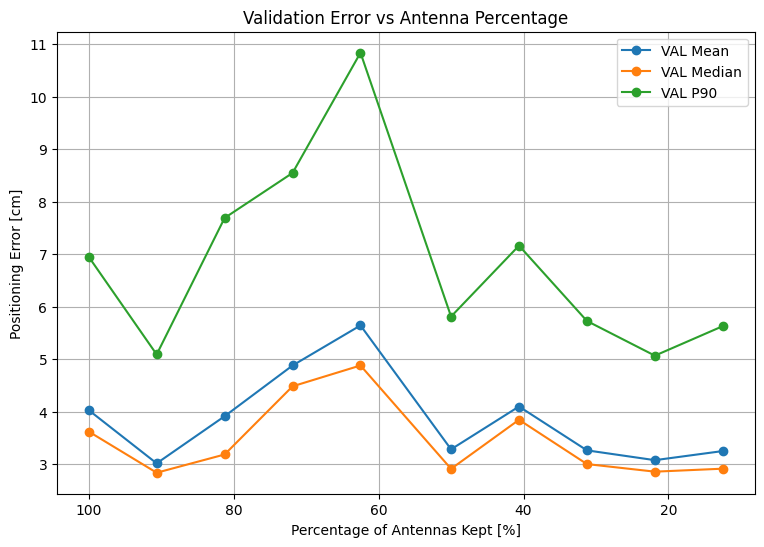

Saved plot to: /content/drive/MyDrive/DICHASUS_tracking_experiments/current_cnn_ig_source/saved_tracking_ablation_results/plots/current_cnn_validation_accuracy_vs_antenna_percentage.png


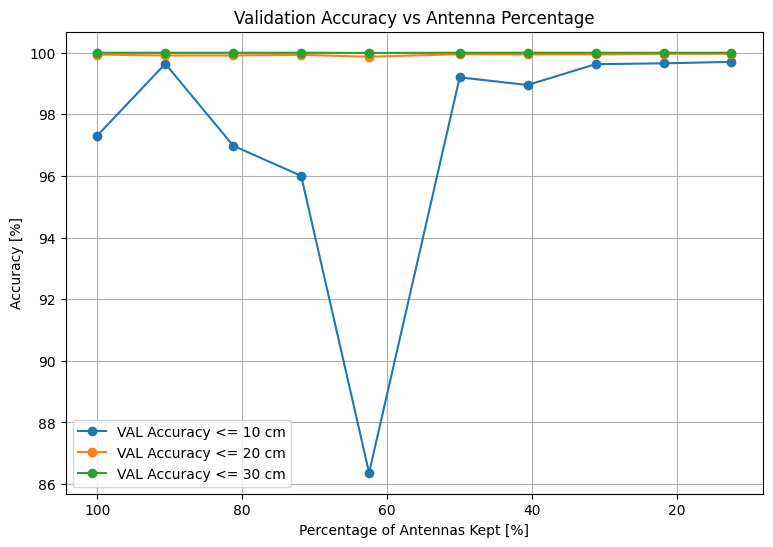

Saved plot to: /content/drive/MyDrive/DICHASUS_tracking_experiments/current_cnn_ig_source/saved_tracking_ablation_results/plots/current_cnn_test_report_only_error_vs_antenna_percentage.png


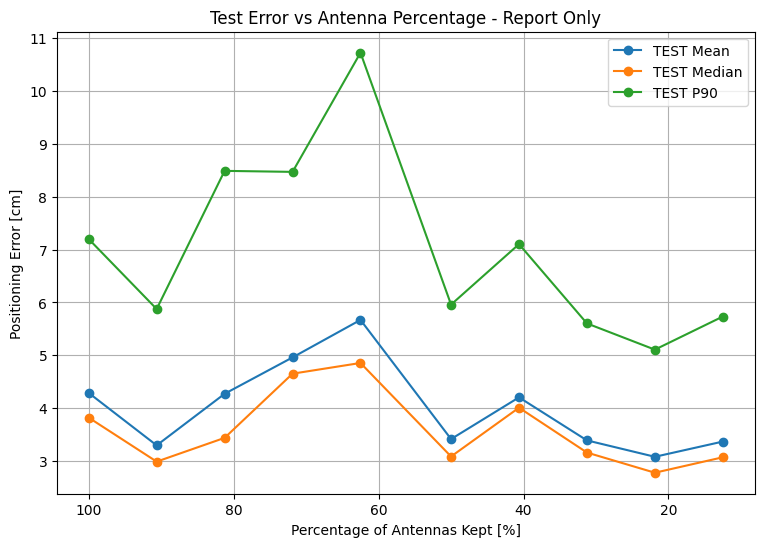

Saved plot to: /content/drive/MyDrive/DICHASUS_tracking_experiments/current_cnn_ig_source/saved_tracking_ablation_results/plots/current_cnn_test_report_only_accuracy_vs_antenna_percentage.png


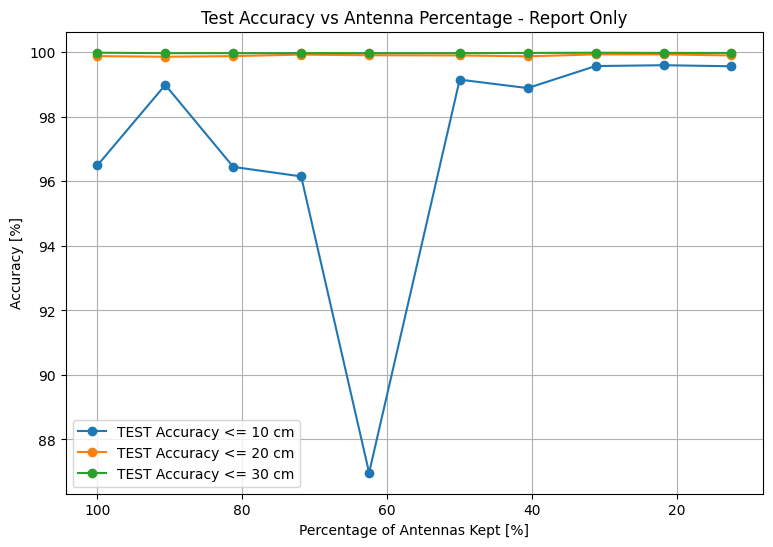


No in-memory error curves available for CDF plot.
This is normal if all percentages were loaded from checkpoint.

Best validation model trajectory/history plot skipped.
This is normal if the best model was loaded from checkpoint and not trained in this run.

Saved files index


,checkpoint_path,final_summary_path,selection_summary_path,model_save_dir,result_save_dir,plot_save_dir,validation_error_plot_path,validation_accuracy_plot_path,test_error_plot_path,test_accuracy_plot_path,final_selected_val_mean_model,final_selected_val_mean_normalization,final_selected_low_antenna_tradeoff_model,final_selected_low_antenna_tradeoff_normalization
0,/content/drive/MyDrive/DICHASUS_tracking_exper...,/content/drive/MyDrive/DICHASUS_tracking_exper...,/content/drive/MyDrive/DICHASUS_tracking_exper...,/content/drive/MyDrive/DICHASUS_tracking_exper...,/content/drive/MyDrive/DICHASUS_tracking_exper...,/content/drive/MyDrive/DICHASUS_tracking_exper...,/content/drive/MyDrive/DICHASUS_tracking_exper...,/content/drive/MyDrive/DICHASUS_tracking_exper...,/content/drive/MyDrive/DICHASUS_tracking_exper...,/content/drive/MyDrive/DICHASUS_tracking_exper...,/content/drive/MyDrive/DICHASUS_tracking_exper...,/content/drive/MyDrive/DICHASUS_tracking_exper...,/content/drive/MyDrive/DICHASUS_tracking_exper...,/content/drive/MyDrive/DICHASUS_tracking_exper...


Saved files index saved to: /content/drive/MyDrive/DICHASUS_tracking_experiments/current_cnn_ig_source/saved_tracking_ablation_results/current_cnn_saved_files_index.csv

Done.
Models saved in:  /content/drive/MyDrive/DICHASUS_tracking_experiments/current_cnn_ig_source/saved_tracking_ablation_models
Results saved in: /content/drive/MyDrive/DICHASUS_tracking_experiments/current_cnn_ig_source/saved_tracking_ablation_results
Plots saved in:   /content/drive/MyDrive/DICHASUS_tracking_experiments/current_cnn_ig_source/saved_tracking_ablation_results/plots

Most important saved files:
Final summary:       /content/drive/MyDrive/DICHASUS_tracking_experiments/current_cnn_ig_source/saved_tracking_ablation_results/ig_source_tracking_percentage_ablation_csi_summary_final.csv
Checkpoint summary:  /content/drive/MyDrive/DICHASUS_tracking_experiments/current_cnn_ig_source/saved_tracking_ablation_results/ig_source_tracking_ablation_checkpoint_summary.csv
Selection summary:   /content/drive/MyDrive/DIC

In [ ]:
# ============================================================
# CSI-Aided Next-Step Tracking with IG Source Antenna Ablation
# CURRENT CNN / ORIGINAL ABLATION MODEL
# SAVE-SAFE + RESUME + VALIDATION-BASED SELECTION VERSION
# ============================================================
#
# Task:
#   Input 1: position(t)      -> shape (2,)
#   Input 2: CSI(t+1)         -> shape (32, 32, 2)
#   Input 3: antenna mask     -> shape (32,)
#   Output : position(t+1)    -> shape (2,)
#
# Important protocol:
#   Validation is used for model/percentage selection.
#   Test metrics are report-only and must not be used for decisions.
#
# Resume behavior:
#   If checkpoint exists and FORCE_RETRAIN_CURRENT_CNN=False,
#   completed percentages are skipped and are NOT retrained.
# ============================================================

import os
import gc
import shutil
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras import layers, Model


# ============================================================
# Mount Google Drive
# ============================================================

USE_GOOGLE_DRIVE = True

if USE_GOOGLE_DRIVE:
    try:
        from google.colab import drive
        drive.mount("/content/drive")
        print("Google Drive mounted.")
    except Exception as e:
        print("Could not mount Google Drive. Falling back to local storage.")
        print(e)


# ============================================================
# Global settings
# ============================================================

SEED = 42
BATCH_SIZE = 64
EPOCHS = 150
HORIZON = 1

np.random.seed(SEED)
tf.random.set_seed(SEED)


# ============================================================
# Output folders
# ============================================================

if USE_GOOGLE_DRIVE:
    BASE_SAVE_DIR = "/content/drive/MyDrive/DICHASUS_tracking_experiments/current_cnn_ig_source"
else:
    BASE_SAVE_DIR = "DICHASUS_tracking_experiments/current_cnn_ig_source"

MODEL_SAVE_DIR = os.path.join(BASE_SAVE_DIR, "saved_tracking_ablation_models")
RESULT_SAVE_DIR = os.path.join(BASE_SAVE_DIR, "saved_tracking_ablation_results")
PLOT_SAVE_DIR = os.path.join(RESULT_SAVE_DIR, "plots")

os.makedirs(MODEL_SAVE_DIR, exist_ok=True)
os.makedirs(RESULT_SAVE_DIR, exist_ok=True)
os.makedirs(PLOT_SAVE_DIR, exist_ok=True)

print("Current CNN models will be saved in:")
print(MODEL_SAVE_DIR)
print("\nCurrent CNN results will be saved in:")
print(RESULT_SAVE_DIR)
print("\nCurrent CNN plots will be saved in:")
print(PLOT_SAVE_DIR)


# ============================================================
# Safety checks
# ============================================================

required_objects = [
    "train_runs",
    "val_runs",
    "test_runs",
    "global_importance_ig_source",
    "antenna_ranking_global_ig_source",
]

for obj in required_objects:
    if obj not in globals():
        raise RuntimeError(
            f"{obj} is not defined. "
            f"Run the preprocessing and IG Source Model ranking cells first."
        )

print("\nAll required objects exist.")


# ============================================================
# Use antenna ranking from IG Source Model
# ============================================================

antenna_ranking = np.asarray(antenna_ranking_global_ig_source, dtype=np.int32)
global_importance_vector = np.asarray(global_importance_ig_source, dtype=np.float32)

if antenna_ranking.shape[0] != 32:
    raise ValueError(f"Expected antenna_ranking shape (32,), got {antenna_ranking.shape}")

if global_importance_vector.shape[0] != 32:
    raise ValueError(f"Expected global_importance_vector shape (32,), got {global_importance_vector.shape}")

print("\nUsing antenna ranking from IG Source Model.")
print("IG Source Model antenna ranking:")
print(antenna_ranking)

print("\nTop 10 antennas from IG Source Model:")
for rank, ant_idx in enumerate(antenna_ranking[:10], start=1):
    print(
        f"Rank {rank}: Antenna index {ant_idx} "
        f"(A{ant_idx + 1}), importance = {global_importance_vector[ant_idx]:.8f}"
    )


# ============================================================
# Antenna mask builder by percentage
# ============================================================

def create_topk_antenna_mask_by_percentage(
    antenna_ranking,
    percentage=100,
    num_antennas=32,
):
    k = int(np.ceil(num_antennas * percentage / 100.0))
    k = max(1, min(k, num_antennas))

    mask = np.zeros(num_antennas, dtype=np.float32)
    selected_antennas = antenna_ranking[:k]
    selected_antenna_names = [f"A{i + 1}" for i in selected_antennas]

    mask[selected_antennas] = 1.0
    actual_percentage = 100.0 * k / num_antennas

    return mask, selected_antennas, selected_antenna_names, k, actual_percentage


# ============================================================
# Build sequential tracking arrays
# ============================================================

def build_tracking_arrays_from_runs(runs, antenna_mask, horizon=1):
    X_pos_t_list = []
    X_csi_tplus1_list = []
    X_mask_list = []
    y_pos_tplus1_list = []

    for run_idx, run in enumerate(runs):
        if "X_csi" not in run:
            raise KeyError(f"Run {run_idx} does not contain key 'X_csi'.")
        if "pos" not in run:
            raise KeyError(f"Run {run_idx} does not contain key 'pos'.")

        X_csi = run["X_csi"].astype(np.float32)
        pos = run["pos"].astype(np.float32)

        if len(X_csi) != len(pos):
            raise ValueError(
                f"Run {run_idx}: X_csi and pos have different lengths. "
                f"X_csi length = {len(X_csi)}, pos length = {len(pos)}"
            )

        if len(X_csi) <= horizon:
            print(f"Skipping run {run_idx}: too short.")
            continue

        pos_t = pos[:-horizon]
        csi_tplus1 = X_csi[horizon:]
        pos_tplus1 = pos[horizon:]

        mask_repeated = np.repeat(
            antenna_mask[None, :],
            repeats=pos_t.shape[0],
            axis=0,
        ).astype(np.float32)

        X_pos_t_list.append(pos_t)
        X_csi_tplus1_list.append(csi_tplus1)
        X_mask_list.append(mask_repeated)
        y_pos_tplus1_list.append(pos_tplus1)

    if len(X_pos_t_list) == 0:
        raise RuntimeError("No valid runs found for tracking array construction.")

    return (
        np.concatenate(X_pos_t_list, axis=0).astype(np.float32),
        np.concatenate(X_csi_tplus1_list, axis=0).astype(np.float32),
        np.concatenate(X_mask_list, axis=0).astype(np.float32),
        np.concatenate(y_pos_tplus1_list, axis=0).astype(np.float32),
    )


# ============================================================
# Normalization helpers
# ============================================================

def compute_csi_normalization_stats(X_train_csi):
    csi_mean = X_train_csi.mean(axis=(0, 1, 2), keepdims=True).astype(np.float32)
    csi_std = X_train_csi.std(axis=(0, 1, 2), keepdims=True).astype(np.float32) + 1e-8
    return csi_mean, csi_std


def normalize_csi(X_csi, csi_mean, csi_std):
    return ((X_csi - csi_mean) / csi_std).astype(np.float32)


def compute_position_normalization_stats(y_train):
    pos_mean = y_train.mean(axis=0, keepdims=True).astype(np.float32)
    pos_std = y_train.std(axis=0, keepdims=True).astype(np.float32) + 1e-8
    return pos_mean, pos_std


def normalize_position(pos, pos_mean, pos_std):
    return ((pos - pos_mean) / pos_std).astype(np.float32)


def denormalize_position(pos_norm, pos_mean, pos_std):
    return (pos_norm * pos_std + pos_mean).astype(np.float32)


# ============================================================
# TensorFlow dataset builder
# ============================================================

def make_tracking_dataset(
    X_pos_t_norm,
    X_csi_tplus1_norm,
    X_mask,
    y_pos_tplus1_norm,
    batch_size=64,
    shuffle=False,
    seed=42,
):
    inputs = {
        "position_t_input": X_pos_t_norm.astype(np.float32),
        "csi_tplus1_input": X_csi_tplus1_norm.astype(np.float32),
        "antenna_mask_input": X_mask.astype(np.float32),
    }
    targets = y_pos_tplus1_norm.astype(np.float32)

    dataset = tf.data.Dataset.from_tensor_slices((inputs, targets))

    if shuffle:
        dataset = dataset.shuffle(
            buffer_size=min(len(targets), 20000),
            seed=seed,
            reshuffle_each_iteration=True,
        )

    return dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)


# ============================================================
# Model architecture
# ============================================================

def build_tracking_csi_ablation_model(seed=42):
    tf.keras.backend.clear_session()
    np.random.seed(seed)
    tf.random.set_seed(seed)

    position_t_input = tf.keras.Input(shape=(2,), name="position_t_input")
    csi_tplus1_input = tf.keras.Input(shape=(32, 32, 2), name="csi_tplus1_input")
    antenna_mask_input = tf.keras.Input(shape=(32,), name="antenna_mask_input")

    antenna_mask_reshaped = layers.Reshape((32, 1, 1), name="antenna_mask_reshape")(
        antenna_mask_input
    )

    masked_csi = layers.Multiply(name="masked_csi_tplus1")(
        [csi_tplus1_input, antenna_mask_reshaped]
    )

    x = layers.Conv2D(32, (3, 3), padding="same", activation="relu", name="csi_conv_1")(
        masked_csi
    )
    x = layers.BatchNormalization(name="csi_bn_1")(x)
    x = layers.MaxPooling2D(pool_size=(2, 2), name="csi_pool_1")(x)

    x = layers.Conv2D(64, (3, 3), padding="same", activation="relu", name="csi_conv_2")(
        x
    )
    x = layers.BatchNormalization(name="csi_bn_2")(x)
    x = layers.MaxPooling2D(pool_size=(2, 2), name="csi_pool_2")(x)

    x = layers.Conv2D(128, (3, 3), padding="same", activation="relu", name="csi_conv_3")(
        x
    )
    x = layers.BatchNormalization(name="csi_bn_3")(x)

    avg_pool = layers.GlobalAveragePooling2D(name="csi_global_avg_pool")(x)
    max_pool = layers.GlobalMaxPooling2D(name="csi_global_max_pool")(x)

    csi_features = layers.Concatenate(name="csi_avg_max_features")([avg_pool, max_pool])
    csi_features = layers.Dense(128, activation="relu", name="csi_dense_1")(csi_features)
    csi_features = layers.Dropout(0.10, name="csi_dropout_1")(csi_features)

    p = layers.Dense(64, activation="relu", name="position_dense_1")(position_t_input)
    p = layers.Dense(32, activation="relu", name="position_dense_2")(p)

    combined = layers.Concatenate(name="fusion_position_t_and_csi_tplus1")(
        [csi_features, p]
    )

    z = layers.Dense(128, activation="relu", name="fusion_dense_1")(combined)
    z = layers.Dropout(0.10, name="fusion_dropout_1")(z)
    z = layers.Dense(64, activation="relu", name="fusion_dense_2")(z)
    z = layers.Dropout(0.05, name="fusion_dropout_2")(z)

    output = layers.Dense(2, activation="linear", name="position_tplus1_output")(z)

    model = Model(
        inputs={
            "position_t_input": position_t_input,
            "csi_tplus1_input": csi_tplus1_input,
            "antenna_mask_input": antenna_mask_input,
        },
        outputs=output,
        name=f"tracking_csi_ablation_model_seed_{seed}",
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=2e-4),
        loss="mse",
        metrics=["mae"],
    )

    return model


# ============================================================
# Evaluation function
# ============================================================

def evaluate_tracking_predictions(model, dataset, y_true_meter, pos_mean, pos_std, dataset_name="Dataset"):
    y_pred_norm = model.predict(dataset, verbose=0)
    y_pred_meter = denormalize_position(y_pred_norm, pos_mean, pos_std)

    error_vectors = y_pred_meter - y_true_meter
    errors = np.sqrt(error_vectors[:, 0] ** 2 + error_vectors[:, 1] ** 2)

    results = {
        "mean_error_m": float(np.mean(errors)),
        "median_error_m": float(np.median(errors)),
        "rmse_error_m": float(np.sqrt(np.mean(errors ** 2))),
        "std_error_m": float(np.std(errors)),
        "min_error_m": float(np.min(errors)),
        "max_error_m": float(np.max(errors)),
        "p75_error_m": float(np.percentile(errors, 75)),
        "p90_error_m": float(np.percentile(errors, 90)),
        "p95_error_m": float(np.percentile(errors, 95)),
        "acc_5cm_percent": float(np.mean(errors <= 0.05) * 100),
        "acc_10cm_percent": float(np.mean(errors <= 0.10) * 100),
        "acc_20cm_percent": float(np.mean(errors <= 0.20) * 100),
        "acc_30cm_percent": float(np.mean(errors <= 0.30) * 100),
        "acc_50cm_percent": float(np.mean(errors <= 0.50) * 100),
        "errors": errors,
        "predictions_meter": y_pred_meter,
    }

    print()
    print(dataset_name)
    print("-" * 70)
    print(f"Mean Error:              {results['mean_error_m']:.4f} m")
    print(f"Median Error:            {results['median_error_m']:.4f} m")
    print(f"RMSE Error:              {results['rmse_error_m']:.4f} m")
    print(f"Std Error:               {results['std_error_m']:.4f} m")
    print(f"75th Percentile Error:   {results['p75_error_m']:.4f} m")
    print(f"90th Percentile Error:   {results['p90_error_m']:.4f} m")
    print(f"95th Percentile Error:   {results['p95_error_m']:.4f} m")
    print()
    print(f"Accuracy <= 5 cm:        {results['acc_5cm_percent']:.2f}%")
    print(f"Accuracy <= 10 cm:       {results['acc_10cm_percent']:.2f}%")
    print(f"Accuracy <= 20 cm:       {results['acc_20cm_percent']:.2f}%")
    print(f"Accuracy <= 30 cm:       {results['acc_30cm_percent']:.2f}%")
    print(f"Accuracy <= 50 cm:       {results['acc_50cm_percent']:.2f}%")
    print()

    return results


# ============================================================
# Plot helpers
# ============================================================

def plot_error_cdf(errors_dict, title, save_path=None):
    plt.figure(figsize=(9, 6))

    for label, errors in errors_dict.items():
        sorted_errors = np.sort(errors)
        cdf = np.arange(1, len(sorted_errors) + 1) / len(sorted_errors)
        plt.plot(sorted_errors * 100, cdf, label=label)

    plt.xlabel("Positioning Error [cm]")
    plt.ylabel("CDF")
    plt.title(title)
    plt.grid(True)
    plt.legend()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Saved plot to: {save_path}")

    plt.show()


def plot_true_vs_pred(y_true, y_pred, title="True vs Predicted Position", save_path=None):
    plt.figure(figsize=(8, 6))
    plt.scatter(y_true[:, 0], y_true[:, 1], s=5, label="True")
    plt.scatter(y_pred[:, 0], y_pred[:, 1], s=5, label="Predicted")
    plt.xlabel("x [m]")
    plt.ylabel("y [m]")
    plt.title(title)
    plt.axis("equal")
    plt.grid(True)
    plt.legend()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Saved plot to: {save_path}")

    plt.show()


def plot_training_history_from_dict(history_dict, title="Training History", save_path=None):
    plt.figure(figsize=(8, 5))
    plt.plot(history_dict["loss"], label="Train loss")
    plt.plot(history_dict["val_loss"], label="Validation loss")
    plt.xlabel("Epoch")
    plt.ylabel("MSE loss")
    plt.title(title)
    plt.grid(True)
    plt.legend()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Saved plot to: {save_path}")

    plt.show()


def plot_error_vs_percentage(ablation_summary_df, split="val", save_path=None):
    plt.figure(figsize=(9, 6))

    mean_col = f"{split}_mean_error_m"
    median_col = f"{split}_median_error_m"
    p90_col = f"{split}_p90_error_m"

    plt.plot(ablation_summary_df["actual_percentage"], ablation_summary_df[mean_col] * 100, marker="o", label=f"{split.upper()} Mean")
    plt.plot(ablation_summary_df["actual_percentage"], ablation_summary_df[median_col] * 100, marker="o", label=f"{split.upper()} Median")
    plt.plot(ablation_summary_df["actual_percentage"], ablation_summary_df[p90_col] * 100, marker="o", label=f"{split.upper()} P90")

    plt.gca().invert_xaxis()
    plt.xlabel("Percentage of Antennas Kept [%]")
    plt.ylabel("Positioning Error [cm]")
    plt.title("Validation Error vs Antenna Percentage" if split == "val" else "Test Error vs Antenna Percentage - Report Only")
    plt.grid(True)
    plt.legend()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Saved plot to: {save_path}")

    plt.show()


def plot_accuracy_vs_percentage(ablation_summary_df, split="val", save_path=None):
    plt.figure(figsize=(9, 6))

    acc_10_col = f"{split}_acc_10cm_percent"
    acc_20_col = f"{split}_acc_20cm_percent"
    acc_30_col = f"{split}_acc_30cm_percent"

    plt.plot(ablation_summary_df["actual_percentage"], ablation_summary_df[acc_10_col], marker="o", label=f"{split.upper()} Accuracy <= 10 cm")
    plt.plot(ablation_summary_df["actual_percentage"], ablation_summary_df[acc_20_col], marker="o", label=f"{split.upper()} Accuracy <= 20 cm")
    plt.plot(ablation_summary_df["actual_percentage"], ablation_summary_df[acc_30_col], marker="o", label=f"{split.upper()} Accuracy <= 30 cm")

    plt.gca().invert_xaxis()
    plt.xlabel("Percentage of Antennas Kept [%]")
    plt.ylabel("Accuracy [%]")
    plt.title("Validation Accuracy vs Antenna Percentage" if split == "val" else "Test Accuracy vs Antenna Percentage - Report Only")
    plt.grid(True)
    plt.legend()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Saved plot to: {save_path}")

    plt.show()


# ============================================================
# Ablation percentages
# ============================================================

ablation_percentages = [100, 90, 80, 70, 60, 50, 40, 30, 20, 10]


# ============================================================
# Resume / auto-load support
# ============================================================

checkpoint_path = os.path.join(RESULT_SAVE_DIR, "ig_source_tracking_ablation_checkpoint_summary.csv")

FORCE_RETRAIN_CURRENT_CNN = False

if os.path.exists(checkpoint_path) and not FORCE_RETRAIN_CURRENT_CNN:
    previous_df = pd.read_csv(checkpoint_path)

    if len(previous_df) > 0 and "requested_percentage" in previous_df.columns:
        done_percentages = set(previous_df["requested_percentage"].astype(int).tolist())
        ablation_summary = previous_df.to_dict("records")

        print("\nExisting valid checkpoint found.")
        print("Already completed percentages:")
        print(sorted(done_percentages, reverse=True))

    else:
        print("\nCheckpoint file exists but it is empty or invalid.")
        print("Starting from scratch.")
        done_percentages = set()
        ablation_summary = []

else:
    done_percentages = set()
    ablation_summary = []

    if FORCE_RETRAIN_CURRENT_CNN:
        print("\nFORCE_RETRAIN_CURRENT_CNN=True. Starting from scratch.")
    else:
        print("\nNo previous checkpoint found. Starting from scratch.")

remaining_percentages = [p for p in ablation_percentages if int(p) not in done_percentages]

print("\nRemaining percentages to train:")
print(remaining_percentages)

ablation_error_curves = {}
ablation_predictions = {}
ablation_histories = {}


# ============================================================
# Main ablation experiment
# ============================================================

PRINT_MODEL_SUMMARY_ONCE = True

for percentage in remaining_percentages:
    print()
    print("=" * 90)
    print(f"Running IG Source ablation with requested top {percentage}% antennas")
    print("=" * 90)

    antenna_mask, selected_antennas, selected_antenna_names, num_selected_antennas, actual_percentage = (
        create_topk_antenna_mask_by_percentage(
            antenna_ranking=antenna_ranking,
            percentage=percentage,
            num_antennas=32,
        )
    )

    num_removed_antennas = 32 - num_selected_antennas

    print(f"Requested percentage: {percentage}%")
    print(f"Actual percentage:    {actual_percentage:.2f}%")
    print(f"Selected antenna indices ({num_selected_antennas}/32):")
    print(selected_antennas)
    print(f"Selected antenna names ({num_selected_antennas}/32):")
    print(selected_antenna_names)
    print(f"Removed antennas: {num_removed_antennas}")

    X_train_pos_t, X_train_csi_tplus1, X_train_mask, y_train_pos_tplus1 = build_tracking_arrays_from_runs(
        train_runs, antenna_mask=antenna_mask, horizon=HORIZON
    )
    X_val_pos_t, X_val_csi_tplus1, X_val_mask, y_val_pos_tplus1 = build_tracking_arrays_from_runs(
        val_runs, antenna_mask=antenna_mask, horizon=HORIZON
    )
    X_test_pos_t, X_test_csi_tplus1, X_test_mask, y_test_pos_tplus1 = build_tracking_arrays_from_runs(
        test_runs, antenna_mask=antenna_mask, horizon=HORIZON
    )

    print("\nTrain shapes:")
    print("X_train_pos_t:", X_train_pos_t.shape)
    print("X_train_csi_tplus1:", X_train_csi_tplus1.shape)
    print("X_train_mask:", X_train_mask.shape)
    print("y_train_pos_tplus1:", y_train_pos_tplus1.shape)

    print("\nValidation shapes:")
    print("X_val_pos_t:", X_val_pos_t.shape)
    print("X_val_csi_tplus1:", X_val_csi_tplus1.shape)
    print("X_val_mask:", X_val_mask.shape)
    print("y_val_pos_tplus1:", y_val_pos_tplus1.shape)

    print("\nTest shapes:")
    print("X_test_pos_t:", X_test_pos_t.shape)
    print("X_test_csi_tplus1:", X_test_csi_tplus1.shape)
    print("X_test_mask:", X_test_mask.shape)
    print("y_test_pos_tplus1:", y_test_pos_tplus1.shape)

    csi_mean, csi_std = compute_csi_normalization_stats(X_train_csi_tplus1)
    pos_mean, pos_std = compute_position_normalization_stats(y_train_pos_tplus1)

    X_train_csi_tplus1_norm = normalize_csi(X_train_csi_tplus1, csi_mean, csi_std)
    X_val_csi_tplus1_norm = normalize_csi(X_val_csi_tplus1, csi_mean, csi_std)
    X_test_csi_tplus1_norm = normalize_csi(X_test_csi_tplus1, csi_mean, csi_std)

    X_train_pos_t_norm = normalize_position(X_train_pos_t, pos_mean, pos_std)
    X_val_pos_t_norm = normalize_position(X_val_pos_t, pos_mean, pos_std)
    X_test_pos_t_norm = normalize_position(X_test_pos_t, pos_mean, pos_std)

    y_train_pos_tplus1_norm = normalize_position(y_train_pos_tplus1, pos_mean, pos_std)
    y_val_pos_tplus1_norm = normalize_position(y_val_pos_tplus1, pos_mean, pos_std)
    y_test_pos_tplus1_norm = normalize_position(y_test_pos_tplus1, pos_mean, pos_std)

    print("\npos_mean:", pos_mean)
    print("pos_std:", pos_std)

    train_dataset = make_tracking_dataset(
        X_pos_t_norm=X_train_pos_t_norm,
        X_csi_tplus1_norm=X_train_csi_tplus1_norm,
        X_mask=X_train_mask,
        y_pos_tplus1_norm=y_train_pos_tplus1_norm,
        batch_size=BATCH_SIZE,
        shuffle=True,
        seed=SEED,
    )

    val_dataset = make_tracking_dataset(
        X_pos_t_norm=X_val_pos_t_norm,
        X_csi_tplus1_norm=X_val_csi_tplus1_norm,
        X_mask=X_val_mask,
        y_pos_tplus1_norm=y_val_pos_tplus1_norm,
        batch_size=BATCH_SIZE,
        shuffle=False,
        seed=SEED,
    )

    test_dataset = make_tracking_dataset(
        X_pos_t_norm=X_test_pos_t_norm,
        X_csi_tplus1_norm=X_test_csi_tplus1_norm,
        X_mask=X_test_mask,
        y_pos_tplus1_norm=y_test_pos_tplus1_norm,
        batch_size=BATCH_SIZE,
        shuffle=False,
        seed=SEED,
    )

    model = build_tracking_csi_ablation_model(seed=SEED)

    if PRINT_MODEL_SUMMARY_ONCE:
        model.summary()
        PRINT_MODEL_SUMMARY_ONCE = False

    percentage_name = str(percentage).replace(".", "_")

    best_model_path = os.path.join(MODEL_SAVE_DIR, f"best_tracking_model_top_{percentage_name}_percent.keras")
    final_model_path = os.path.join(MODEL_SAVE_DIR, f"final_tracking_model_top_{percentage_name}_percent.keras")
    history_path = os.path.join(RESULT_SAVE_DIR, f"history_top_{percentage_name}_percent.csv")
    norm_path = os.path.join(RESULT_SAVE_DIR, f"normalization_top_{percentage_name}_percent.npz")
    predictions_path = os.path.join(RESULT_SAVE_DIR, f"predictions_errors_current_cnn_top_{percentage_name}_percent.npz")

    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=15,
            restore_best_weights=True,
            verbose=1,
        ),
        tf.keras.callbacks.ModelCheckpoint(
            filepath=best_model_path,
            monitor="val_loss",
            save_best_only=True,
            save_weights_only=False,
            verbose=1,
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=7,
            min_lr=1e-6,
            verbose=1,
        ),
    ]

    history = model.fit(
        train_dataset,
        validation_data=val_dataset,
        epochs=EPOCHS,
        callbacks=callbacks,
        verbose=1,
    )

    model.save(final_model_path)

    print(f"Best model saved to:  {best_model_path}")
    print(f"Final model saved to: {final_model_path}")

    np.savez(
        norm_path,
        csi_mean=csi_mean,
        csi_std=csi_std,
        pos_mean=pos_mean,
        pos_std=pos_std,
        antenna_mask=antenna_mask,
        selected_antennas=selected_antennas,
        selected_antenna_names=np.array(selected_antenna_names),
        requested_percentage=percentage,
        actual_percentage=actual_percentage,
        num_selected_antennas=num_selected_antennas,
        num_removed_antennas=num_removed_antennas,
    )
    print(f"Normalization/mask info saved to: {norm_path}")

    history_df = pd.DataFrame(history.history)
    history_df.to_csv(history_path, index=False)
    print(f"Training history saved to: {history_path}")

    val_results = evaluate_tracking_predictions(
        model=model,
        dataset=val_dataset,
        y_true_meter=y_val_pos_tplus1,
        pos_mean=pos_mean,
        pos_std=pos_std,
        dataset_name=f"Validation - Top {percentage}% requested antennas",
    )

    test_results = evaluate_tracking_predictions(
        model=model,
        dataset=test_dataset,
        y_true_meter=y_test_pos_tplus1,
        pos_mean=pos_mean,
        pos_std=pos_std,
        dataset_name=f"Test Report Only - Top {percentage}% requested antennas",
    )

    label = f"Top {percentage}% requested ({num_selected_antennas}/32 ant., actual {actual_percentage:.1f}%)"

    ablation_error_curves[label] = test_results["errors"]
    ablation_predictions[label] = {
        "y_true": y_test_pos_tplus1,
        "y_pred": test_results["predictions_meter"],
        "selected_antennas": selected_antennas,
        "antenna_mask": antenna_mask,
        "pos_mean": pos_mean,
        "pos_std": pos_std,
        "requested_percentage": percentage,
        "actual_percentage": actual_percentage,
        "best_model_path": best_model_path,
        "final_model_path": final_model_path,
        "normalization_path": norm_path,
    }
    ablation_histories[label] = history.history

    np.savez(
        predictions_path,
        y_val_true_meter=y_val_pos_tplus1,
        y_val_pred_meter=val_results["predictions_meter"],
        val_errors_meter=val_results["errors"],
        y_test_true_meter=y_test_pos_tplus1,
        y_test_pred_meter=test_results["predictions_meter"],
        test_errors_meter=test_results["errors"],
        antenna_mask=antenna_mask,
        selected_antennas=selected_antennas,
        selected_antenna_names=np.array(selected_antenna_names),
        requested_percentage=percentage,
        actual_percentage=actual_percentage,
        num_selected_antennas=num_selected_antennas,
        num_removed_antennas=num_removed_antennas,
    )
    print(f"Predictions/errors saved to: {predictions_path}")

    ablation_summary.append({
        "model_type": "CSI+position",
        "architecture": "CurrentCNN_IGSourceAblation",
        "requested_percentage": percentage,
        "actual_percentage": actual_percentage,
        "kept_antennas": num_selected_antennas,
        "removed_antennas": num_removed_antennas,
        "selected_antennas": selected_antennas.tolist(),
        "selected_antenna_names": selected_antenna_names,
        "best_model_path": best_model_path,
        "final_model_path": final_model_path,
        "normalization_path": norm_path,
        "history_path": history_path,
        "predictions_path": predictions_path,
        "val_mean_error_m": val_results["mean_error_m"],
        "val_median_error_m": val_results["median_error_m"],
        "val_rmse_error_m": val_results["rmse_error_m"],
        "val_std_error_m": val_results["std_error_m"],
        "val_p75_error_m": val_results["p75_error_m"],
        "val_p90_error_m": val_results["p90_error_m"],
        "val_p95_error_m": val_results["p95_error_m"],
        "val_acc_5cm_percent": val_results["acc_5cm_percent"],
        "val_acc_10cm_percent": val_results["acc_10cm_percent"],
        "val_acc_20cm_percent": val_results["acc_20cm_percent"],
        "val_acc_30cm_percent": val_results["acc_30cm_percent"],
        "val_acc_50cm_percent": val_results["acc_50cm_percent"],
        "test_mean_error_m": test_results["mean_error_m"],
        "test_median_error_m": test_results["median_error_m"],
        "test_rmse_error_m": test_results["rmse_error_m"],
        "test_std_error_m": test_results["std_error_m"],
        "test_p75_error_m": test_results["p75_error_m"],
        "test_p90_error_m": test_results["p90_error_m"],
        "test_p95_error_m": test_results["p95_error_m"],
        "test_acc_5cm_percent": test_results["acc_5cm_percent"],
        "test_acc_10cm_percent": test_results["acc_10cm_percent"],
        "test_acc_20cm_percent": test_results["acc_20cm_percent"],
        "test_acc_30cm_percent": test_results["acc_30cm_percent"],
        "test_acc_50cm_percent": test_results["acc_50cm_percent"],
        "epochs_trained": len(history.history["loss"]),
        "best_val_loss": min(history.history["val_loss"]),
        "final_val_loss": history.history["val_loss"][-1],
        "test_usage": "report_only_not_used_for_decision",
    })

    checkpoint_df = pd.DataFrame(ablation_summary)
    checkpoint_df.to_csv(checkpoint_path, index=False)
    print(f"Checkpoint summary saved to: {checkpoint_path}")

    del model
    del train_dataset, val_dataset, test_dataset
    del X_train_pos_t, X_train_csi_tplus1, X_train_mask, y_train_pos_tplus1
    del X_val_pos_t, X_val_csi_tplus1, X_val_mask, y_val_pos_tplus1
    del X_test_pos_t, X_test_csi_tplus1, X_test_mask, y_test_pos_tplus1

    gc.collect()
    tf.keras.backend.clear_session()

    print(f"Finished percentage {percentage}%")


# ============================================================
# Final summary table
# ============================================================

ablation_summary_df = pd.DataFrame(ablation_summary)

if len(ablation_summary_df) == 0:
    raise RuntimeError(
        "No ablation results found. The checkpoint may be empty or no percentage was trained. "
        "Set FORCE_RETRAIN_CURRENT_CNN = True and run again."
    )

if "model_type" in ablation_summary_df.columns:
    csi_ablation_summary_df = ablation_summary_df[
        ablation_summary_df["model_type"].astype(str).str.strip() == "CSI+position"
    ].copy()

    if len(csi_ablation_summary_df) == 0:
        print("Warning: No rows matched model_type == 'CSI+position'. Using all rows instead.")
        csi_ablation_summary_df = ablation_summary_df.copy()
else:
    print("Warning: 'model_type' column not found. Using all rows.")
    csi_ablation_summary_df = ablation_summary_df.copy()

if len(csi_ablation_summary_df) == 0:
    raise RuntimeError(
        "Final summary is still empty. Delete the old checkpoint file or set FORCE_RETRAIN_CURRENT_CNN = True."
    )

csi_ablation_summary_df = csi_ablation_summary_df.sort_values(
    "requested_percentage", ascending=False
).reset_index(drop=True)

print()
print("=" * 90)
print("Final CSI + Position Ablation Summary")
print("=" * 90)
display(csi_ablation_summary_df)

final_summary_path = os.path.join(RESULT_SAVE_DIR, "ig_source_tracking_percentage_ablation_csi_summary_final.csv")
csi_ablation_summary_df.to_csv(final_summary_path, index=False)
print(f"Final summary saved to: {final_summary_path}")


# ============================================================
# Select best models based on validation only
# ============================================================

best_by_val_mean = csi_ablation_summary_df.sort_values("val_mean_error_m", ascending=True).iloc[0]
best_by_val_p90 = csi_ablation_summary_df.sort_values("val_p90_error_m", ascending=True).iloc[0]
best_by_val_rmse = csi_ablation_summary_df.sort_values("val_rmse_error_m", ascending=True).iloc[0]
best_by_val_loss = csi_ablation_summary_df.sort_values("best_val_loss", ascending=True).iloc[0]

print()
print("=" * 90)
print("Best Current CNN by Validation Mean Error")
print("=" * 90)
print(best_by_val_mean)

print()
print("=" * 90)
print("Best Current CNN by Validation P90 Error")
print("=" * 90)
print(best_by_val_p90)

print()
print("=" * 90)
print("Best Current CNN by Validation RMSE Error")
print("=" * 90)
print(best_by_val_rmse)

print()
print("=" * 90)
print("Best Current CNN by Best Validation Loss")
print("=" * 90)
print(best_by_val_loss)


# ============================================================
# Validation-based low-antenna trade-off analysis
# ============================================================

best_val_mean_value = float(best_by_val_mean["val_mean_error_m"])
best_val_p90_reference = float(best_by_val_mean["val_p90_error_m"])

acceptable_mean_increase_percent = 10.0
acceptable_p90_increase_percent = 15.0

max_allowed_val_mean = best_val_mean_value * (1.0 + acceptable_mean_increase_percent / 100.0)
max_allowed_val_p90 = best_val_p90_reference * (1.0 + acceptable_p90_increase_percent / 100.0)

acceptable_tradeoff_models = csi_ablation_summary_df[
    (csi_ablation_summary_df["val_mean_error_m"] <= max_allowed_val_mean) &
    (csi_ablation_summary_df["val_p90_error_m"] <= max_allowed_val_p90)
].copy()

if len(acceptable_tradeoff_models) > 0:
    best_low_antenna_tradeoff = acceptable_tradeoff_models.sort_values("kept_antennas", ascending=True).iloc[0]
else:
    best_low_antenna_tradeoff = best_by_val_mean

print()
print("=" * 90)
print("Best Low-Antenna Trade-off Based on Validation Only")
print("=" * 90)
print(best_low_antenna_tradeoff)

print()
print("Trade-off rule:")
print(f"Allowed validation mean increase: {acceptable_mean_increase_percent:.1f}%")
print(f"Allowed validation P90 increase:  {acceptable_p90_increase_percent:.1f}%")
print(f"Best validation mean:        {best_val_mean_value * 100:.2f} cm")
print(f"Max allowed validation mean: {max_allowed_val_mean * 100:.2f} cm")
print(f"Reference validation P90:    {best_val_p90_reference * 100:.2f} cm")
print(f"Max allowed validation P90:  {max_allowed_val_p90 * 100:.2f} cm")


# ============================================================
# Save validation-based selected model copies
# ============================================================

selection_rows = [
    {
        "selection_name": "best_by_validation_mean",
        "row": best_by_val_mean,
        "model_filename": "FINAL_SELECTED_current_cnn_by_val_mean_model.keras",
        "normalization_filename": "FINAL_SELECTED_current_cnn_by_val_mean_normalization.npz",
    },
    {
        "selection_name": "best_by_validation_p90",
        "row": best_by_val_p90,
        "model_filename": "FINAL_SELECTED_current_cnn_by_val_p90_model.keras",
        "normalization_filename": "FINAL_SELECTED_current_cnn_by_val_p90_normalization.npz",
    },
    {
        "selection_name": "best_by_validation_rmse",
        "row": best_by_val_rmse,
        "model_filename": "FINAL_SELECTED_current_cnn_by_val_rmse_model.keras",
        "normalization_filename": "FINAL_SELECTED_current_cnn_by_val_rmse_normalization.npz",
    },
    {
        "selection_name": "best_by_validation_loss",
        "row": best_by_val_loss,
        "model_filename": "FINAL_SELECTED_current_cnn_by_val_loss_model.keras",
        "normalization_filename": "FINAL_SELECTED_current_cnn_by_val_loss_normalization.npz",
    },
    {
        "selection_name": "best_low_antenna_tradeoff_validation",
        "row": best_low_antenna_tradeoff,
        "model_filename": "FINAL_SELECTED_current_cnn_low_antenna_tradeoff_model.keras",
        "normalization_filename": "FINAL_SELECTED_current_cnn_low_antenna_tradeoff_normalization.npz",
    },
]

selection_summary_records = []

for item in selection_rows:
    selected_row = item["row"]

    selected_model_copy_path = os.path.join(MODEL_SAVE_DIR, item["model_filename"])
    selected_norm_copy_path = os.path.join(RESULT_SAVE_DIR, item["normalization_filename"])

    if not os.path.exists(selected_row["best_model_path"]):
        raise FileNotFoundError(f"Best model file not found: {selected_row['best_model_path']}")
    if not os.path.exists(selected_row["normalization_path"]):
        raise FileNotFoundError(f"Normalization file not found: {selected_row['normalization_path']}")

    shutil.copy2(selected_row["best_model_path"], selected_model_copy_path)
    shutil.copy2(selected_row["normalization_path"], selected_norm_copy_path)

    selection_summary_records.append({
        "selection_name": item["selection_name"],
        "architecture": "CurrentCNN_IGSourceAblation",
        "requested_percentage": selected_row["requested_percentage"],
        "actual_percentage": selected_row["actual_percentage"],
        "kept_antennas": selected_row["kept_antennas"],
        "removed_antennas": selected_row["removed_antennas"],
        "val_mean_error_m": selected_row["val_mean_error_m"],
        "val_median_error_m": selected_row["val_median_error_m"],
        "val_rmse_error_m": selected_row["val_rmse_error_m"],
        "val_p90_error_m": selected_row["val_p90_error_m"],
        "best_val_loss": selected_row["best_val_loss"],
        "test_mean_error_m_report_only": selected_row["test_mean_error_m"],
        "test_median_error_m_report_only": selected_row["test_median_error_m"],
        "test_rmse_error_m_report_only": selected_row["test_rmse_error_m"],
        "test_p90_error_m_report_only": selected_row["test_p90_error_m"],
        "original_best_model_path": selected_row["best_model_path"],
        "original_normalization_path": selected_row["normalization_path"],
        "selected_model_copy_path": selected_model_copy_path,
        "selected_normalization_copy_path": selected_norm_copy_path,
        "test_usage": "report_only_not_used_for_decision",
    })

selection_summary_df = pd.DataFrame(selection_summary_records)
selection_summary_path = os.path.join(RESULT_SAVE_DIR, "current_cnn_validation_selection_summary.csv")
selection_summary_df.to_csv(selection_summary_path, index=False)

print()
print("=" * 90)
print("Validation-based selected Current CNN model copies saved")
print("=" * 90)
display(selection_summary_df)
print(f"Selection summary saved to: {selection_summary_path}")


# ============================================================
# Plots
# ============================================================

validation_error_plot_path = os.path.join(PLOT_SAVE_DIR, "current_cnn_validation_error_vs_antenna_percentage.png")
plot_error_vs_percentage(csi_ablation_summary_df, split="val", save_path=validation_error_plot_path)

validation_accuracy_plot_path = os.path.join(PLOT_SAVE_DIR, "current_cnn_validation_accuracy_vs_antenna_percentage.png")
plot_accuracy_vs_percentage(csi_ablation_summary_df, split="val", save_path=validation_accuracy_plot_path)

test_error_plot_path = os.path.join(PLOT_SAVE_DIR, "current_cnn_test_report_only_error_vs_antenna_percentage.png")
plot_error_vs_percentage(csi_ablation_summary_df, split="test", save_path=test_error_plot_path)

test_accuracy_plot_path = os.path.join(PLOT_SAVE_DIR, "current_cnn_test_report_only_accuracy_vs_antenna_percentage.png")
plot_accuracy_vs_percentage(csi_ablation_summary_df, split="test", save_path=test_accuracy_plot_path)

selected_cdf_labels = {}
for label, errors in ablation_error_curves.items():
    if (
        "Top 100%" in label or
        "Top 70%" in label or
        "Top 50%" in label or
        "Top 30%" in label or
        "Top 10%" in label
    ):
        selected_cdf_labels[label] = errors

if len(selected_cdf_labels) > 0:
    cdf_plot_path = os.path.join(PLOT_SAVE_DIR, "current_cnn_test_report_only_error_cdf_selected_percentages.png")
    plot_error_cdf(selected_cdf_labels, title="Current CNN Test Error CDF - Report Only", save_path=cdf_plot_path)
else:
    print()
    print("No in-memory error curves available for CDF plot.")
    print("This is normal if all percentages were loaded from checkpoint.")

best_validation_label = (
    f"Top {best_by_val_mean['requested_percentage']}% requested "
    f"({int(best_by_val_mean['kept_antennas'])}/32 ant., "
    f"actual {best_by_val_mean['actual_percentage']:.1f}%)"
)

if best_validation_label in ablation_predictions:
    true_vs_pred_plot_path = os.path.join(PLOT_SAVE_DIR, "current_cnn_best_validation_model_true_vs_pred.png")
    plot_true_vs_pred(
        y_true=ablation_predictions[best_validation_label]["y_true"],
        y_pred=ablation_predictions[best_validation_label]["y_pred"],
        title=f"True vs Predicted Position - Best Validation Model\n{best_validation_label}",
        save_path=true_vs_pred_plot_path,
    )

    training_history_plot_path = os.path.join(PLOT_SAVE_DIR, "current_cnn_best_validation_model_training_history.png")
    plot_training_history_from_dict(
        ablation_histories[best_validation_label],
        title=f"Training History - Best Validation Model\n{best_validation_label}",
        save_path=training_history_plot_path,
    )
else:
    print()
    print("Best validation model trajectory/history plot skipped.")
    print("This is normal if the best model was loaded from checkpoint and not trained in this run.")


# ============================================================
# Save file index
# ============================================================

file_index_df = pd.DataFrame([{
    "checkpoint_path": checkpoint_path,
    "final_summary_path": final_summary_path,
    "selection_summary_path": selection_summary_path,
    "model_save_dir": MODEL_SAVE_DIR,
    "result_save_dir": RESULT_SAVE_DIR,
    "plot_save_dir": PLOT_SAVE_DIR,
    "validation_error_plot_path": validation_error_plot_path,
    "validation_accuracy_plot_path": validation_accuracy_plot_path,
    "test_error_plot_path": test_error_plot_path,
    "test_accuracy_plot_path": test_accuracy_plot_path,
    "final_selected_val_mean_model": os.path.join(MODEL_SAVE_DIR, "FINAL_SELECTED_current_cnn_by_val_mean_model.keras"),
    "final_selected_val_mean_normalization": os.path.join(RESULT_SAVE_DIR, "FINAL_SELECTED_current_cnn_by_val_mean_normalization.npz"),
    "final_selected_low_antenna_tradeoff_model": os.path.join(MODEL_SAVE_DIR, "FINAL_SELECTED_current_cnn_low_antenna_tradeoff_model.keras"),
    "final_selected_low_antenna_tradeoff_normalization": os.path.join(RESULT_SAVE_DIR, "FINAL_SELECTED_current_cnn_low_antenna_tradeoff_normalization.npz"),
}])

file_index_path = os.path.join(RESULT_SAVE_DIR, "current_cnn_saved_files_index.csv")
file_index_df.to_csv(file_index_path, index=False)

print()
print("=" * 90)
print("Saved files index")
print("=" * 90)
display(file_index_df)
print(f"Saved files index saved to: {file_index_path}")


# ============================================================
# Final print
# ============================================================

print()
print("=" * 90)
print("Done.")
print("=" * 90)
print(f"Models saved in:  {MODEL_SAVE_DIR}")
print(f"Results saved in: {RESULT_SAVE_DIR}")
print(f"Plots saved in:   {PLOT_SAVE_DIR}")

print()
print("Most important saved files:")
print(f"Final summary:       {final_summary_path}")
print(f"Checkpoint summary:  {checkpoint_path}")
print(f"Selection summary:   {selection_summary_path}")
print(f"Saved files index:   {file_index_path}")

print()
print("Easy-to-load selected models:")
print(os.path.join(MODEL_SAVE_DIR, "FINAL_SELECTED_current_cnn_by_val_mean_model.keras"))
print(os.path.join(MODEL_SAVE_DIR, "FINAL_SELECTED_current_cnn_by_val_p90_model.keras"))
print(os.path.join(MODEL_SAVE_DIR, "FINAL_SELECTED_current_cnn_low_antenna_tradeoff_model.keras"))

print()
print("Important:")
print("Validation metrics are used for model/percentage selection.")
print("Test metrics are report-only and must not be used for model decisions.")


In [ ]:
# ============================================================
# ANTENNA DROPOUT ON PREVIOUS MODELS
# SAVE-SAFE + RESUME + LOAD-READY VERSION
# ============================================================
#
# Controlled experiment:
#   1) Current CNN + Antenna Dropout
#   2) Residual Attention CNN + Antenna Dropout
#
# Goal:
#   Check whether Antenna Dropout improves low-antenna trade-off.
#
# Input 1: position(t)      -> shape (2,)
# Input 2: CSI(t+1)         -> shape (32, 32, 2)
# Input 3: antenna mask     -> shape (32,)
# Output : position(t+1)    -> shape (2,)
#
# Selection:
#   Validation only.
#
# Test:
#   Report only, not used for decisions.
#
# Saves:
#   - best/final model for every architecture/percentage
#   - normalization/mask files
#   - training histories
#   - prediction/error npz files
#   - checkpoint summary
#   - final summary
#   - validation-only tradeoff analysis
#   - FINAL_SELECTED model copies for easy loading
#   - plots and saved-files index
# ============================================================

import os
import gc
import shutil
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras import layers, Model


# ============================================================
# Mount Google Drive
# ============================================================

USE_GOOGLE_DRIVE = True

if USE_GOOGLE_DRIVE:
    try:
        from google.colab import drive
        drive.mount("/content/drive")
        print("Google Drive mounted.")
    except Exception as e:
        print("Could not mount Google Drive. Falling back to local storage.")
        print(e)


# ============================================================
# Global settings
# ============================================================

SEED = 42
BATCH_SIZE = 64
EPOCHS = 150
HORIZON = 1
ANTENNA_DROPOUT_RATE = 0.08

np.random.seed(SEED)
tf.random.set_seed(SEED)


# ============================================================
# Output folders
# ============================================================

if USE_GOOGLE_DRIVE:
    BASE_SAVE_DIR = "/content/drive/MyDrive/DICHASUS_tracking_experiments/antenna_dropout_previous_models"
else:
    BASE_SAVE_DIR = "DICHASUS_tracking_experiments/antenna_dropout_previous_models"


DROPOUT_PREV_MODEL_SAVE_DIR = os.path.join(
    BASE_SAVE_DIR,
    "saved_tracking_antenna_dropout_previous_models"
)

DROPOUT_PREV_RESULT_SAVE_DIR = os.path.join(
    BASE_SAVE_DIR,
    "saved_tracking_antenna_dropout_previous_results"
)

DROPOUT_PREV_PLOT_SAVE_DIR = os.path.join(
    DROPOUT_PREV_RESULT_SAVE_DIR,
    "plots"
)

os.makedirs(DROPOUT_PREV_MODEL_SAVE_DIR, exist_ok=True)
os.makedirs(DROPOUT_PREV_RESULT_SAVE_DIR, exist_ok=True)
os.makedirs(DROPOUT_PREV_PLOT_SAVE_DIR, exist_ok=True)

print("Models will be saved in:")
print(DROPOUT_PREV_MODEL_SAVE_DIR)

print("\nResults will be saved in:")
print(DROPOUT_PREV_RESULT_SAVE_DIR)

print("\nPlots will be saved in:")
print(DROPOUT_PREV_PLOT_SAVE_DIR)


# ============================================================
# Safety checks
# ============================================================

required_objects = [
    "train_runs",
    "val_runs",
    "test_runs",
    "global_importance_ig_source",
    "antenna_ranking_global_ig_source",
]

for obj in required_objects:
    if obj not in globals():
        raise RuntimeError(
            f"{obj} is not defined. "
            f"Run preprocessing and IG Source Model ranking cells first."
        )

print("\nAll required objects exist.")


# ============================================================
# Antenna ranking
# ============================================================

antenna_ranking = np.asarray(
    antenna_ranking_global_ig_source,
    dtype=np.int32
)

global_importance_vector = np.asarray(
    global_importance_ig_source,
    dtype=np.float32
)

if antenna_ranking.shape[0] != 32:
    raise ValueError(
        f"Expected antenna_ranking shape (32,), got {antenna_ranking.shape}"
    )

if global_importance_vector.shape[0] != 32:
    raise ValueError(
        f"Expected global_importance_vector shape (32,), got {global_importance_vector.shape}"
    )

print("\nUsing IG Source antenna ranking.")
print("Ranking indices:")
print(antenna_ranking)

print("\nRanking names:")
print([f"A{i + 1}" for i in antenna_ranking])


# ============================================================
# Helper functions
# ============================================================

def create_topk_antenna_mask_by_percentage(
    antenna_ranking,
    percentage=100,
    num_antennas=32,
):
    k = int(np.ceil(num_antennas * percentage / 100.0))
    k = max(1, min(k, num_antennas))

    mask = np.zeros(num_antennas, dtype=np.float32)

    selected_antennas = antenna_ranking[:k]
    selected_antenna_names = [f"A{i + 1}" for i in selected_antennas]

    mask[selected_antennas] = 1.0

    actual_percentage = 100.0 * k / num_antennas

    return mask, selected_antennas, selected_antenna_names, k, actual_percentage


def build_tracking_arrays_from_runs(
    runs,
    antenna_mask,
    horizon=1,
):
    X_pos_t_list = []
    X_csi_tplus1_list = []
    X_mask_list = []
    y_pos_tplus1_list = []

    for run_idx, run in enumerate(runs):
        if "X_csi" not in run:
            raise KeyError(f"Run {run_idx} does not contain key 'X_csi'.")

        if "pos" not in run:
            raise KeyError(f"Run {run_idx} does not contain key 'pos'.")

        X_csi = run["X_csi"].astype(np.float32)
        pos = run["pos"].astype(np.float32)

        if len(X_csi) != len(pos):
            raise ValueError(
                f"Run {run_idx}: X_csi and pos have different lengths. "
                f"X_csi length = {len(X_csi)}, pos length = {len(pos)}"
            )

        if len(X_csi) <= horizon:
            print(f"Skipping run {run_idx}: too short.")
            continue

        pos_t = pos[:-horizon]
        csi_tplus1 = X_csi[horizon:]
        pos_tplus1 = pos[horizon:]

        mask_repeated = np.repeat(
            antenna_mask[None, :],
            repeats=pos_t.shape[0],
            axis=0,
        ).astype(np.float32)

        X_pos_t_list.append(pos_t)
        X_csi_tplus1_list.append(csi_tplus1)
        X_mask_list.append(mask_repeated)
        y_pos_tplus1_list.append(pos_tplus1)

    if len(X_pos_t_list) == 0:
        raise RuntimeError("No valid runs found for tracking array construction.")

    X_pos_t_all = np.concatenate(X_pos_t_list, axis=0).astype(np.float32)
    X_csi_tplus1_all = np.concatenate(X_csi_tplus1_list, axis=0).astype(np.float32)
    X_mask_all = np.concatenate(X_mask_list, axis=0).astype(np.float32)
    y_pos_tplus1_all = np.concatenate(y_pos_tplus1_list, axis=0).astype(np.float32)

    return X_pos_t_all, X_csi_tplus1_all, X_mask_all, y_pos_tplus1_all


def compute_csi_normalization_stats(X_train_csi):
    csi_mean = X_train_csi.mean(
        axis=(0, 1, 2),
        keepdims=True
    ).astype(np.float32)

    csi_std = X_train_csi.std(
        axis=(0, 1, 2),
        keepdims=True
    ).astype(np.float32) + 1e-8

    return csi_mean, csi_std


def normalize_csi(X_csi, csi_mean, csi_std):
    return ((X_csi - csi_mean) / csi_std).astype(np.float32)


def compute_position_normalization_stats(y_train):
    pos_mean = y_train.mean(
        axis=0,
        keepdims=True
    ).astype(np.float32)

    pos_std = y_train.std(
        axis=0,
        keepdims=True
    ).astype(np.float32) + 1e-8

    return pos_mean, pos_std


def normalize_position(pos, pos_mean, pos_std):
    return ((pos - pos_mean) / pos_std).astype(np.float32)


def denormalize_position(pos_norm, pos_mean, pos_std):
    return (pos_norm * pos_std + pos_mean).astype(np.float32)


def make_tracking_dataset(
    X_pos_t_norm,
    X_csi_tplus1_norm,
    X_mask,
    y_pos_tplus1_norm,
    batch_size=64,
    shuffle=False,
    seed=42,
):
    inputs = {
        "position_t_input": X_pos_t_norm.astype(np.float32),
        "csi_tplus1_input": X_csi_tplus1_norm.astype(np.float32),
        "antenna_mask_input": X_mask.astype(np.float32),
    }

    targets = y_pos_tplus1_norm.astype(np.float32)

    dataset = tf.data.Dataset.from_tensor_slices((inputs, targets))

    if shuffle:
        dataset = dataset.shuffle(
            buffer_size=min(len(targets), 20000),
            seed=seed,
            reshuffle_each_iteration=True,
        )

    dataset = dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)

    return dataset


def evaluate_tracking_predictions(
    model,
    dataset,
    y_true_meter,
    pos_mean,
    pos_std,
    dataset_name="Dataset",
):
    y_pred_norm = model.predict(
        dataset,
        verbose=0
    )

    y_pred_meter = denormalize_position(
        y_pred_norm,
        pos_mean,
        pos_std
    )

    error_vectors = y_pred_meter - y_true_meter

    errors = np.sqrt(
        error_vectors[:, 0] ** 2 +
        error_vectors[:, 1] ** 2
    )

    results = {
        "mean_error_m": float(np.mean(errors)),
        "median_error_m": float(np.median(errors)),
        "rmse_error_m": float(np.sqrt(np.mean(errors ** 2))),
        "std_error_m": float(np.std(errors)),
        "min_error_m": float(np.min(errors)),
        "max_error_m": float(np.max(errors)),
        "p75_error_m": float(np.percentile(errors, 75)),
        "p90_error_m": float(np.percentile(errors, 90)),
        "p95_error_m": float(np.percentile(errors, 95)),
        "acc_5cm_percent": float(np.mean(errors <= 0.05) * 100),
        "acc_10cm_percent": float(np.mean(errors <= 0.10) * 100),
        "acc_20cm_percent": float(np.mean(errors <= 0.20) * 100),
        "acc_30cm_percent": float(np.mean(errors <= 0.30) * 100),
        "acc_50cm_percent": float(np.mean(errors <= 0.50) * 100),
        "errors": errors,
        "predictions_meter": y_pred_meter,
    }

    print()
    print(dataset_name)
    print("-" * 70)
    print(f"Mean Error:              {results['mean_error_m']:.4f} m")
    print(f"Median Error:            {results['median_error_m']:.4f} m")
    print(f"RMSE Error:              {results['rmse_error_m']:.4f} m")
    print(f"75th Percentile Error:   {results['p75_error_m']:.4f} m")
    print(f"90th Percentile Error:   {results['p90_error_m']:.4f} m")
    print(f"95th Percentile Error:   {results['p95_error_m']:.4f} m")
    print()
    print(f"Accuracy <= 5 cm:        {results['acc_5cm_percent']:.2f}%")
    print(f"Accuracy <= 10 cm:       {results['acc_10cm_percent']:.2f}%")
    print(f"Accuracy <= 20 cm:       {results['acc_20cm_percent']:.2f}%")
    print(f"Accuracy <= 30 cm:       {results['acc_30cm_percent']:.2f}%")
    print(f"Accuracy <= 50 cm:       {results['acc_50cm_percent']:.2f}%")
    print()

    return results


# ============================================================
# Custom layers
# ============================================================

@tf.keras.utils.register_keras_serializable()
class AntennaEnergyLayer(layers.Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def call(self, inputs):
        return tf.reduce_mean(tf.abs(inputs), axis=[2, 3])

    def get_config(self):
        return super().get_config()


@tf.keras.utils.register_keras_serializable()
class AntennaDropoutLayer(layers.Layer):
    """
    Randomly drops entire antenna rows during training only.
    It is inactive during validation/test/prediction.
    """
    def __init__(self, rate=0.08, **kwargs):
        super().__init__(**kwargs)
        self.rate = rate

    def call(self, inputs, training=None):
        if training is None:
            training = False

        if not training or self.rate <= 0.0:
            return inputs

        keep_prob = 1.0 - self.rate

        batch_size = tf.shape(inputs)[0]
        num_antennas = tf.shape(inputs)[1]

        random_tensor = tf.random.uniform(
            shape=(batch_size, num_antennas, 1, 1),
            minval=0.0,
            maxval=1.0,
            dtype=inputs.dtype
        )

        keep_mask = tf.cast(
            random_tensor < keep_prob,
            dtype=inputs.dtype
        )

        return inputs * keep_mask / keep_prob

    def get_config(self):
        config = super().get_config()
        config.update({
            "rate": self.rate
        })
        return config


# ============================================================
# Residual SE block for Residual Attention model
# ============================================================

def residual_se_block_for_dropout_experiment(
    x,
    filters,
    stride=1,
    se_ratio=8,
    dropout_rate=0.0,
    name="res_block"
):
    shortcut = x

    x = layers.Conv2D(
        filters,
        kernel_size=(3, 3),
        strides=stride,
        padding="same",
        use_bias=False,
        name=f"{name}_conv_1"
    )(x)

    x = layers.BatchNormalization(
        name=f"{name}_bn_1"
    )(x)

    x = layers.Activation(
        "relu",
        name=f"{name}_relu_1"
    )(x)

    x = layers.Conv2D(
        filters,
        kernel_size=(3, 3),
        strides=1,
        padding="same",
        use_bias=False,
        name=f"{name}_conv_2"
    )(x)

    x = layers.BatchNormalization(
        name=f"{name}_bn_2"
    )(x)

    se = layers.GlobalAveragePooling2D(
        name=f"{name}_se_gap"
    )(x)

    se_units = max(filters // se_ratio, 8)

    se = layers.Dense(
        se_units,
        activation="relu",
        name=f"{name}_se_dense_1"
    )(se)

    se = layers.Dense(
        filters,
        activation="sigmoid",
        name=f"{name}_se_dense_2"
    )(se)

    se = layers.Reshape(
        (1, 1, filters),
        name=f"{name}_se_reshape"
    )(se)

    x = layers.Multiply(
        name=f"{name}_se_multiply"
    )([x, se])

    if dropout_rate > 0:
        x = layers.Dropout(
            dropout_rate,
            name=f"{name}_dropout"
        )(x)

    if stride != 1 or int(shortcut.shape[-1]) != filters:
        shortcut = layers.Conv2D(
            filters,
            kernel_size=(1, 1),
            strides=stride,
            padding="same",
            use_bias=False,
            name=f"{name}_shortcut_conv"
        )(shortcut)

        shortcut = layers.BatchNormalization(
            name=f"{name}_shortcut_bn"
        )(shortcut)

    x = layers.Add(
        name=f"{name}_add"
    )([x, shortcut])

    x = layers.Activation(
        "relu",
        name=f"{name}_out_relu"
    )(x)

    return x


# ============================================================
# Model 1A:
# Current CNN + Antenna Dropout
# ============================================================

def build_current_cnn_with_antenna_dropout(
    seed=42,
    antenna_dropout_rate=0.08
):
    tf.keras.backend.clear_session()
    np.random.seed(seed)
    tf.random.set_seed(seed)

    position_t_input = tf.keras.Input(
        shape=(2,),
        name="position_t_input"
    )

    csi_tplus1_input = tf.keras.Input(
        shape=(32, 32, 2),
        name="csi_tplus1_input"
    )

    antenna_mask_input = tf.keras.Input(
        shape=(32,),
        name="antenna_mask_input"
    )

    antenna_mask_reshaped = layers.Reshape(
        (32, 1, 1),
        name="antenna_mask_reshape"
    )(antenna_mask_input)

    masked_csi = layers.Multiply(
        name="masked_csi"
    )([csi_tplus1_input, antenna_mask_reshaped])

    dropped_csi = AntennaDropoutLayer(
        rate=antenna_dropout_rate,
        name="train_time_antenna_dropout"
    )(masked_csi)

    x = layers.Conv2D(
        32,
        kernel_size=(3, 3),
        padding="same",
        activation="relu",
        name="csi_conv_1"
    )(dropped_csi)

    x = layers.BatchNormalization(
        name="csi_bn_1"
    )(x)

    x = layers.MaxPooling2D(
        pool_size=(2, 2),
        name="csi_pool_1"
    )(x)

    x = layers.Conv2D(
        64,
        kernel_size=(3, 3),
        padding="same",
        activation="relu",
        name="csi_conv_2"
    )(x)

    x = layers.BatchNormalization(
        name="csi_bn_2"
    )(x)

    x = layers.MaxPooling2D(
        pool_size=(2, 2),
        name="csi_pool_2"
    )(x)

    x = layers.Conv2D(
        128,
        kernel_size=(3, 3),
        padding="same",
        activation="relu",
        name="csi_conv_3"
    )(x)

    x = layers.BatchNormalization(
        name="csi_bn_3"
    )(x)

    avg_pool = layers.GlobalAveragePooling2D(
        name="csi_global_avg_pool"
    )(x)

    max_pool = layers.GlobalMaxPooling2D(
        name="csi_global_max_pool"
    )(x)

    csi_features = layers.Concatenate(
        name="csi_avg_max_features"
    )([avg_pool, max_pool])

    csi_features = layers.Dense(
        128,
        activation="relu",
        name="csi_dense_1"
    )(csi_features)

    csi_features = layers.Dropout(
        0.10,
        name="csi_dropout_1"
    )(csi_features)

    p = layers.Dense(
        64,
        activation="relu",
        name="position_dense_1"
    )(position_t_input)

    p = layers.Dense(
        32,
        activation="relu",
        name="position_dense_2"
    )(p)

    combined = layers.Concatenate(
        name="fusion_position_csi"
    )([csi_features, p])

    z = layers.Dense(
        128,
        activation="relu",
        name="fusion_dense_1"
    )(combined)

    z = layers.Dropout(
        0.10,
        name="fusion_dropout_1"
    )(z)

    z = layers.Dense(
        64,
        activation="relu",
        name="fusion_dense_2"
    )(z)

    z = layers.Dropout(
        0.05,
        name="fusion_dropout_2"
    )(z)

    output = layers.Dense(
        2,
        activation="linear",
        name="position_tplus1_output"
    )(z)

    model = Model(
        inputs={
            "position_t_input": position_t_input,
            "csi_tplus1_input": csi_tplus1_input,
            "antenna_mask_input": antenna_mask_input,
        },
        outputs=output,
        name=f"current_cnn_antenna_dropout_seed_{seed}"
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=2e-4),
        loss="mse",
        metrics=["mae"]
    )

    return model


# ============================================================
# Model 2A:
# Residual Attention CNN + Antenna Dropout
# ============================================================

def build_residual_attention_with_antenna_dropout(
    seed=42,
    antenna_dropout_rate=0.08
):
    tf.keras.backend.clear_session()
    np.random.seed(seed)
    tf.random.set_seed(seed)

    position_t_input = tf.keras.Input(
        shape=(2,),
        name="position_t_input"
    )

    csi_tplus1_input = tf.keras.Input(
        shape=(32, 32, 2),
        name="csi_tplus1_input"
    )

    antenna_mask_input = tf.keras.Input(
        shape=(32,),
        name="antenna_mask_input"
    )

    antenna_mask_reshaped = layers.Reshape(
        (32, 1, 1),
        name="antenna_mask_reshape"
    )(antenna_mask_input)

    masked_csi = layers.Multiply(
        name="masked_csi"
    )([csi_tplus1_input, antenna_mask_reshaped])

    dropped_csi = AntennaDropoutLayer(
        rate=antenna_dropout_rate,
        name="train_time_antenna_dropout"
    )(masked_csi)

    antenna_energy = AntennaEnergyLayer(
        name="antenna_energy"
    )(dropped_csi)

    antenna_attention = layers.Dense(
        64,
        activation="relu",
        name="antenna_attention_dense_1"
    )(antenna_energy)

    antenna_attention = layers.Dense(
        32,
        activation="sigmoid",
        name="antenna_attention_dense_2"
    )(antenna_attention)

    antenna_attention = layers.Multiply(
        name="antenna_attention_apply_mask"
    )([antenna_attention, antenna_mask_input])

    antenna_attention_reshaped = layers.Reshape(
        (32, 1, 1),
        name="antenna_attention_reshape"
    )(antenna_attention)

    attended_csi = layers.Multiply(
        name="attended_csi"
    )([dropped_csi, antenna_attention_reshaped])

    x = layers.Conv2D(
        32,
        kernel_size=(3, 3),
        padding="same",
        use_bias=False,
        name="stem_conv"
    )(attended_csi)

    x = layers.BatchNormalization(
        name="stem_bn"
    )(x)

    x = layers.Activation(
        "relu",
        name="stem_relu"
    )(x)

    x = residual_se_block_for_dropout_experiment(
        x,
        filters=32,
        stride=1,
        dropout_rate=0.05,
        name="res32_block1"
    )

    x = residual_se_block_for_dropout_experiment(
        x,
        filters=32,
        stride=1,
        dropout_rate=0.05,
        name="res32_block2"
    )

    x = residual_se_block_for_dropout_experiment(
        x,
        filters=64,
        stride=2,
        dropout_rate=0.08,
        name="res64_block1"
    )

    x = residual_se_block_for_dropout_experiment(
        x,
        filters=64,
        stride=1,
        dropout_rate=0.08,
        name="res64_block2"
    )

    x = residual_se_block_for_dropout_experiment(
        x,
        filters=128,
        stride=2,
        dropout_rate=0.10,
        name="res128_block1"
    )

    x = residual_se_block_for_dropout_experiment(
        x,
        filters=128,
        stride=1,
        dropout_rate=0.10,
        name="res128_block2"
    )

    avg_pool = layers.GlobalAveragePooling2D(
        name="csi_global_avg_pool"
    )(x)

    max_pool = layers.GlobalMaxPooling2D(
        name="csi_global_max_pool"
    )(x)

    csi_features = layers.Concatenate(
        name="csi_avg_max_features"
    )([avg_pool, max_pool])

    csi_features = layers.Dense(
        256,
        activation="relu",
        name="csi_dense_1"
    )(csi_features)

    csi_features = layers.BatchNormalization(
        name="csi_dense_bn_1"
    )(csi_features)

    csi_features = layers.Dropout(
        0.15,
        name="csi_dense_dropout_1"
    )(csi_features)

    csi_features = layers.Dense(
        128,
        activation="relu",
        name="csi_dense_2"
    )(csi_features)

    p = layers.Dense(
        64,
        activation="relu",
        name="position_dense_1"
    )(position_t_input)

    p = layers.Dense(
        64,
        activation="relu",
        name="position_dense_2"
    )(p)

    p = layers.Dense(
        32,
        activation="relu",
        name="position_dense_3"
    )(p)

    combined = layers.Concatenate(
        name="fusion_csi_position"
    )([csi_features, p])

    z = layers.Dense(
        256,
        activation="relu",
        name="fusion_dense_1"
    )(combined)

    z = layers.BatchNormalization(
        name="fusion_bn_1"
    )(z)

    z = layers.Dropout(
        0.20,
        name="fusion_dropout_1"
    )(z)

    z = layers.Dense(
        128,
        activation="relu",
        name="fusion_dense_2"
    )(z)

    z = layers.Dropout(
        0.10,
        name="fusion_dropout_2"
    )(z)

    z = layers.Dense(
        64,
        activation="relu",
        name="fusion_dense_3"
    )(z)

    delta_position_norm = layers.Dense(
        2,
        activation="linear",
        kernel_initializer=tf.keras.initializers.RandomNormal(
            mean=0.0,
            stddev=1e-3,
            seed=seed
        ),
        bias_initializer="zeros",
        name="delta_position_norm"
    )(z)

    output_position_norm = layers.Add(
        name="position_tplus1_output"
    )([position_t_input, delta_position_norm])

    model = Model(
        inputs={
            "position_t_input": position_t_input,
            "csi_tplus1_input": csi_tplus1_input,
            "antenna_mask_input": antenna_mask_input,
        },
        outputs=output_position_norm,
        name=f"residual_attention_antenna_dropout_seed_{seed}"
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=2e-4),
        loss=tf.keras.losses.Huber(delta=1.0),
        metrics=["mae"]
    )

    return model


# ============================================================
# Architecture control
# ============================================================

architectures_to_run = [
    "CurrentCNN_AntennaDropout",
    "ResidualAttentionCNN_AntennaDropout",
]

# To run only one architecture, uncomment one of these:
# architectures_to_run = ["CurrentCNN_AntennaDropout"]
# architectures_to_run = ["ResidualAttentionCNN_AntennaDropout"]


def build_model_by_architecture(
    architecture_name,
    seed=42,
    antenna_dropout_rate=0.08
):
    if architecture_name == "CurrentCNN_AntennaDropout":
        return build_current_cnn_with_antenna_dropout(
            seed=seed,
            antenna_dropout_rate=antenna_dropout_rate
        )

    if architecture_name == "ResidualAttentionCNN_AntennaDropout":
        return build_residual_attention_with_antenna_dropout(
            seed=seed,
            antenna_dropout_rate=antenna_dropout_rate
        )

    raise ValueError(f"Unknown architecture: {architecture_name}")


# ============================================================
# Percentages
# ============================================================

ablation_percentages = [
    100, 90, 80, 70, 60, 50, 40, 30, 20, 10
]


# ============================================================
# Resume support
# ============================================================

FORCE_RETRAIN_ANTENNA_DROPOUT = False

dropout_prev_checkpoint_path = os.path.join(
    DROPOUT_PREV_RESULT_SAVE_DIR,
    "antenna_dropout_previous_models_checkpoint_summary.csv"
)

if os.path.exists(dropout_prev_checkpoint_path) and not FORCE_RETRAIN_ANTENNA_DROPOUT:
    previous_df = pd.read_csv(
        dropout_prev_checkpoint_path
    )

    if len(previous_df) > 0 and {"architecture", "requested_percentage"}.issubset(previous_df.columns):
        done_pairs = set(
            zip(
                previous_df["architecture"].astype(str),
                previous_df["requested_percentage"].astype(int)
            )
        )

        dropout_prev_summary = previous_df.to_dict("records")

        print("Existing valid checkpoint found.")
        print("Already completed architecture/percentage pairs:")
        print(done_pairs)

    else:
        print("Checkpoint exists but it is empty or invalid. Starting from scratch.")

        done_pairs = set()
        dropout_prev_summary = []

else:
    done_pairs = set()
    dropout_prev_summary = []

    if FORCE_RETRAIN_ANTENNA_DROPOUT:
        print("FORCE_RETRAIN_ANTENNA_DROPOUT=True. Starting from scratch.")
    else:
        print("No previous checkpoint found. Starting from scratch.")


# ============================================================
# Main loop
# ============================================================

PRINT_MODEL_SUMMARY_ONCE = True

for architecture_name in architectures_to_run:
    for percentage in ablation_percentages:

        if (architecture_name, int(percentage)) in done_pairs:
            print(f"Skipping {architecture_name} - {percentage}% because it already exists.")
            continue

        print()
        print("=" * 100)
        print(f"Architecture: {architecture_name}")
        print(f"Requested top {percentage}% antennas")
        print("=" * 100)

        antenna_mask, selected_antennas, selected_antenna_names, num_selected_antennas, actual_percentage = (
            create_topk_antenna_mask_by_percentage(
                antenna_ranking=antenna_ranking,
                percentage=percentage,
                num_antennas=32
            )
        )

        num_removed_antennas = 32 - num_selected_antennas

        print(f"Requested percentage: {percentage}%")
        print(f"Actual percentage:    {actual_percentage:.2f}%")
        print(f"Selected antennas ({num_selected_antennas}/32):")
        print(selected_antenna_names)
        print(f"Removed antennas: {num_removed_antennas}")

        X_train_pos_t, X_train_csi_tplus1, X_train_mask, y_train_pos_tplus1 = (
            build_tracking_arrays_from_runs(
                train_runs,
                antenna_mask=antenna_mask,
                horizon=HORIZON
            )
        )

        X_val_pos_t, X_val_csi_tplus1, X_val_mask, y_val_pos_tplus1 = (
            build_tracking_arrays_from_runs(
                val_runs,
                antenna_mask=antenna_mask,
                horizon=HORIZON
            )
        )

        X_test_pos_t, X_test_csi_tplus1, X_test_mask, y_test_pos_tplus1 = (
            build_tracking_arrays_from_runs(
                test_runs,
                antenna_mask=antenna_mask,
                horizon=HORIZON
            )
        )

        csi_mean, csi_std = compute_csi_normalization_stats(
            X_train_csi_tplus1
        )

        pos_mean, pos_std = compute_position_normalization_stats(
            y_train_pos_tplus1
        )

        X_train_csi_tplus1_norm = normalize_csi(
            X_train_csi_tplus1,
            csi_mean,
            csi_std
        )

        X_val_csi_tplus1_norm = normalize_csi(
            X_val_csi_tplus1,
            csi_mean,
            csi_std
        )

        X_test_csi_tplus1_norm = normalize_csi(
            X_test_csi_tplus1,
            csi_mean,
            csi_std
        )

        X_train_pos_t_norm = normalize_position(
            X_train_pos_t,
            pos_mean,
            pos_std
        )

        X_val_pos_t_norm = normalize_position(
            X_val_pos_t,
            pos_mean,
            pos_std
        )

        X_test_pos_t_norm = normalize_position(
            X_test_pos_t,
            pos_mean,
            pos_std
        )

        y_train_pos_tplus1_norm = normalize_position(
            y_train_pos_tplus1,
            pos_mean,
            pos_std
        )

        y_val_pos_tplus1_norm = normalize_position(
            y_val_pos_tplus1,
            pos_mean,
            pos_std
        )

        y_test_pos_tplus1_norm = normalize_position(
            y_test_pos_tplus1,
            pos_mean,
            pos_std
        )

        train_dataset = make_tracking_dataset(
            X_pos_t_norm=X_train_pos_t_norm,
            X_csi_tplus1_norm=X_train_csi_tplus1_norm,
            X_mask=X_train_mask,
            y_pos_tplus1_norm=y_train_pos_tplus1_norm,
            batch_size=BATCH_SIZE,
            shuffle=True,
            seed=SEED
        )

        val_dataset = make_tracking_dataset(
            X_pos_t_norm=X_val_pos_t_norm,
            X_csi_tplus1_norm=X_val_csi_tplus1_norm,
            X_mask=X_val_mask,
            y_pos_tplus1_norm=y_val_pos_tplus1_norm,
            batch_size=BATCH_SIZE,
            shuffle=False,
            seed=SEED
        )

        test_dataset = make_tracking_dataset(
            X_pos_t_norm=X_test_pos_t_norm,
            X_csi_tplus1_norm=X_test_csi_tplus1_norm,
            X_mask=X_test_mask,
            y_pos_tplus1_norm=y_test_pos_tplus1_norm,
            batch_size=BATCH_SIZE,
            shuffle=False,
            seed=SEED
        )

        model = build_model_by_architecture(
            architecture_name=architecture_name,
            seed=SEED,
            antenna_dropout_rate=ANTENNA_DROPOUT_RATE
        )

        if PRINT_MODEL_SUMMARY_ONCE:
            model.summary()
            PRINT_MODEL_SUMMARY_ONCE = False

        percentage_name = str(percentage).replace(".", "_")
        safe_architecture_name = architecture_name.lower()

        best_model_path = os.path.join(
            DROPOUT_PREV_MODEL_SAVE_DIR,
            f"best_{safe_architecture_name}_top_{percentage_name}_percent.keras"
        )

        final_model_path = os.path.join(
            DROPOUT_PREV_MODEL_SAVE_DIR,
            f"final_{safe_architecture_name}_top_{percentage_name}_percent.keras"
        )

        history_path = os.path.join(
            DROPOUT_PREV_RESULT_SAVE_DIR,
            f"history_{safe_architecture_name}_top_{percentage_name}_percent.csv"
        )

        norm_path = os.path.join(
            DROPOUT_PREV_RESULT_SAVE_DIR,
            f"normalization_{safe_architecture_name}_top_{percentage_name}_percent.npz"
        )

        predictions_path = os.path.join(
            DROPOUT_PREV_RESULT_SAVE_DIR,
            f"predictions_errors_{safe_architecture_name}_top_{percentage_name}_percent.npz"
        )

        callbacks = [
            tf.keras.callbacks.EarlyStopping(
                monitor="val_loss",
                patience=18,
                restore_best_weights=True,
                verbose=1
            ),

            tf.keras.callbacks.ModelCheckpoint(
                filepath=best_model_path,
                monitor="val_loss",
                save_best_only=True,
                save_weights_only=False,
                verbose=1
            ),

            tf.keras.callbacks.ReduceLROnPlateau(
                monitor="val_loss",
                factor=0.5,
                patience=8,
                min_lr=1e-6,
                verbose=1
            )
        ]

        history = model.fit(
            train_dataset,
            validation_data=val_dataset,
            epochs=EPOCHS,
            callbacks=callbacks,
            verbose=1
        )

        model.save(
            final_model_path
        )

        print(f"Best model saved to:  {best_model_path}")
        print(f"Final model saved to: {final_model_path}")

        np.savez(
            norm_path,
            csi_mean=csi_mean,
            csi_std=csi_std,
            pos_mean=pos_mean,
            pos_std=pos_std,
            antenna_mask=antenna_mask,
            selected_antennas=selected_antennas,
            selected_antenna_names=np.array(selected_antenna_names),
            requested_percentage=percentage,
            actual_percentage=actual_percentage,
            num_selected_antennas=num_selected_antennas,
            num_removed_antennas=num_removed_antennas,
            architecture=architecture_name,
            antenna_dropout_rate=ANTENNA_DROPOUT_RATE
        )

        print(f"Normalization saved to: {norm_path}")

        history_df = pd.DataFrame(
            history.history
        )

        history_df.to_csv(
            history_path,
            index=False
        )

        print(f"History saved to: {history_path}")

        val_results = evaluate_tracking_predictions(
            model=model,
            dataset=val_dataset,
            y_true_meter=y_val_pos_tplus1,
            pos_mean=pos_mean,
            pos_std=pos_std,
            dataset_name=f"Validation - {architecture_name} - Top {percentage}%"
        )

        test_results = evaluate_tracking_predictions(
            model=model,
            dataset=test_dataset,
            y_true_meter=y_test_pos_tplus1,
            pos_mean=pos_mean,
            pos_std=pos_std,
            dataset_name=f"Test Report Only - {architecture_name} - Top {percentage}%"
        )

        np.savez(
            predictions_path,
            y_val_true_meter=y_val_pos_tplus1,
            y_val_pred_meter=val_results["predictions_meter"],
            val_errors_meter=val_results["errors"],
            y_test_true_meter=y_test_pos_tplus1,
            y_test_pred_meter=test_results["predictions_meter"],
            test_errors_meter=test_results["errors"],
            antenna_mask=antenna_mask,
            selected_antennas=selected_antennas,
            selected_antenna_names=np.array(selected_antenna_names),
            requested_percentage=percentage,
            actual_percentage=actual_percentage,
            num_selected_antennas=num_selected_antennas,
            num_removed_antennas=num_removed_antennas,
            architecture=architecture_name,
            antenna_dropout_rate=ANTENNA_DROPOUT_RATE
        )

        print(f"Predictions/errors saved to: {predictions_path}")

        dropout_prev_summary.append({
            "architecture": architecture_name,
            "requested_percentage": percentage,
            "actual_percentage": actual_percentage,
            "kept_antennas": num_selected_antennas,
            "removed_antennas": num_removed_antennas,
            "selected_antennas_indices": selected_antennas.tolist(),
            "selected_antennas_names": selected_antenna_names,

            "best_model_path": best_model_path,
            "final_model_path": final_model_path,
            "normalization_path": norm_path,
            "history_path": history_path,
            "predictions_path": predictions_path,

            # Validation metrics - used for decision
            "val_mean_error_m": val_results["mean_error_m"],
            "val_median_error_m": val_results["median_error_m"],
            "val_rmse_error_m": val_results["rmse_error_m"],
            "val_std_error_m": val_results["std_error_m"],
            "val_p75_error_m": val_results["p75_error_m"],
            "val_p90_error_m": val_results["p90_error_m"],
            "val_p95_error_m": val_results["p95_error_m"],
            "val_acc_5cm_percent": val_results["acc_5cm_percent"],
            "val_acc_10cm_percent": val_results["acc_10cm_percent"],
            "val_acc_20cm_percent": val_results["acc_20cm_percent"],
            "val_acc_30cm_percent": val_results["acc_30cm_percent"],
            "val_acc_50cm_percent": val_results["acc_50cm_percent"],

            # Test metrics - report only
            "test_mean_error_m": test_results["mean_error_m"],
            "test_median_error_m": test_results["median_error_m"],
            "test_rmse_error_m": test_results["rmse_error_m"],
            "test_std_error_m": test_results["std_error_m"],
            "test_p75_error_m": test_results["p75_error_m"],
            "test_p90_error_m": test_results["p90_error_m"],
            "test_p95_error_m": test_results["p95_error_m"],
            "test_acc_5cm_percent": test_results["acc_5cm_percent"],
            "test_acc_10cm_percent": test_results["acc_10cm_percent"],
            "test_acc_20cm_percent": test_results["acc_20cm_percent"],
            "test_acc_30cm_percent": test_results["acc_30cm_percent"],
            "test_acc_50cm_percent": test_results["acc_50cm_percent"],

            "epochs_trained": len(history.history["loss"]),
            "best_val_loss": min(history.history["val_loss"]),
            "final_val_loss": history.history["val_loss"][-1],
            "antenna_dropout_rate": ANTENNA_DROPOUT_RATE,
            "test_usage": "report_only_not_used_for_decision",
        })

        checkpoint_df = pd.DataFrame(
            dropout_prev_summary
        )

        checkpoint_df.to_csv(
            dropout_prev_checkpoint_path,
            index=False
        )

        print(f"Checkpoint saved to: {dropout_prev_checkpoint_path}")

        del model
        del train_dataset
        del val_dataset
        del test_dataset

        del X_train_pos_t
        del X_train_csi_tplus1
        del X_train_mask
        del y_train_pos_tplus1

        del X_val_pos_t
        del X_val_csi_tplus1
        del X_val_mask
        del y_val_pos_tplus1

        del X_test_pos_t
        del X_test_csi_tplus1
        del X_test_mask
        del y_test_pos_tplus1

        gc.collect()
        tf.keras.backend.clear_session()

        print(f"Finished {architecture_name} - {percentage}%")


# ============================================================
# Final summary
# ============================================================

dropout_prev_results_df = pd.DataFrame(
    dropout_prev_summary
)

if len(dropout_prev_results_df) == 0:
    raise RuntimeError(
        "No results found. Checkpoint may be empty or no model was trained. "
        "Set FORCE_RETRAIN_ANTENNA_DROPOUT=True and run again."
    )

dropout_prev_results_df = dropout_prev_results_df.sort_values(
    ["architecture", "requested_percentage"],
    ascending=[True, False]
).reset_index(drop=True)

print()
print("=" * 100)
print("Antenna Dropout on Previous Models - Summary")
print("=" * 100)

display(dropout_prev_results_df)

dropout_prev_final_summary_path = os.path.join(
    DROPOUT_PREV_RESULT_SAVE_DIR,
    "antenna_dropout_previous_models_summary_final.csv"
)

dropout_prev_results_df.to_csv(
    dropout_prev_final_summary_path,
    index=False
)

print(f"Final summary saved to: {dropout_prev_final_summary_path}")


# ============================================================
# Validation-only selection and trade-off analysis
# ============================================================

tradeoff_rows = []
selection_rows = []

acceptable_mean_increase_percent = 10.0
acceptable_p90_increase_percent = 15.0

for architecture_name in dropout_prev_results_df["architecture"].unique():
    arch_df = dropout_prev_results_df[
        dropout_prev_results_df["architecture"] == architecture_name
    ].copy()

    best_by_val_mean = arch_df.sort_values(
        "val_mean_error_m",
        ascending=True
    ).iloc[0]

    best_by_val_p90 = arch_df.sort_values(
        "val_p90_error_m",
        ascending=True
    ).iloc[0]

    best_by_val_rmse = arch_df.sort_values(
        "val_rmse_error_m",
        ascending=True
    ).iloc[0]

    best_val_mean = float(
        best_by_val_mean["val_mean_error_m"]
    )

    best_val_p90 = float(
        best_by_val_mean["val_p90_error_m"]
    )

    max_allowed_mean = best_val_mean * (
        1.0 + acceptable_mean_increase_percent / 100.0
    )

    max_allowed_p90 = best_val_p90 * (
        1.0 + acceptable_p90_increase_percent / 100.0
    )

    acceptable = arch_df[
        (arch_df["val_mean_error_m"] <= max_allowed_mean) &
        (arch_df["val_p90_error_m"] <= max_allowed_p90)
    ].copy()

    if len(acceptable) > 0:
        best_tradeoff = acceptable.sort_values(
            "kept_antennas",
            ascending=True
        ).iloc[0]
    else:
        best_tradeoff = best_by_val_mean

    safe_architecture_name = architecture_name.lower()

    named_selections = [
        (
            "best_by_validation_mean",
            best_by_val_mean,
            f"FINAL_SELECTED_{safe_architecture_name}_by_val_mean_model.keras",
            f"FINAL_SELECTED_{safe_architecture_name}_by_val_mean_normalization.npz"
        ),
        (
            "best_by_validation_p90",
            best_by_val_p90,
            f"FINAL_SELECTED_{safe_architecture_name}_by_val_p90_model.keras",
            f"FINAL_SELECTED_{safe_architecture_name}_by_val_p90_normalization.npz"
        ),
        (
            "best_by_validation_rmse",
            best_by_val_rmse,
            f"FINAL_SELECTED_{safe_architecture_name}_by_val_rmse_model.keras",
            f"FINAL_SELECTED_{safe_architecture_name}_by_val_rmse_normalization.npz"
        ),
        (
            "best_low_antenna_tradeoff_validation",
            best_tradeoff,
            f"FINAL_SELECTED_{safe_architecture_name}_low_antenna_tradeoff_model.keras",
            f"FINAL_SELECTED_{safe_architecture_name}_low_antenna_tradeoff_normalization.npz"
        ),
    ]

    for selection_name, selected_row, model_filename, norm_filename in named_selections:
        selected_model_copy_path = os.path.join(
            DROPOUT_PREV_MODEL_SAVE_DIR,
            model_filename
        )

        selected_norm_copy_path = os.path.join(
            DROPOUT_PREV_RESULT_SAVE_DIR,
            norm_filename
        )

        if not os.path.exists(selected_row["best_model_path"]):
            raise FileNotFoundError(
                f"Best model not found: {selected_row['best_model_path']}"
            )

        if not os.path.exists(selected_row["normalization_path"]):
            raise FileNotFoundError(
                f"Normalization not found: {selected_row['normalization_path']}"
            )

        shutil.copy2(
            selected_row["best_model_path"],
            selected_model_copy_path
        )

        shutil.copy2(
            selected_row["normalization_path"],
            selected_norm_copy_path
        )

        selection_rows.append({
            "selection_name": selection_name,
            "architecture": architecture_name,
            "requested_percentage": selected_row["requested_percentage"],
            "actual_percentage": selected_row["actual_percentage"],
            "kept_antennas": selected_row["kept_antennas"],
            "removed_antennas": selected_row["removed_antennas"],

            "val_mean_error_m": selected_row["val_mean_error_m"],
            "val_median_error_m": selected_row["val_median_error_m"],
            "val_rmse_error_m": selected_row["val_rmse_error_m"],
            "val_p90_error_m": selected_row["val_p90_error_m"],

            "test_mean_error_m_report_only": selected_row["test_mean_error_m"],
            "test_median_error_m_report_only": selected_row["test_median_error_m"],
            "test_rmse_error_m_report_only": selected_row["test_rmse_error_m"],
            "test_p90_error_m_report_only": selected_row["test_p90_error_m"],

            "original_best_model_path": selected_row["best_model_path"],
            "original_normalization_path": selected_row["normalization_path"],
            "selected_model_copy_path": selected_model_copy_path,
            "selected_normalization_copy_path": selected_norm_copy_path,
            "test_usage": "report_only_not_used_for_decision",
        })

    tradeoff_rows.append({
        "architecture": architecture_name,

        "best_absolute_requested_percentage": best_by_val_mean["requested_percentage"],
        "best_absolute_kept_antennas": best_by_val_mean["kept_antennas"],
        "best_absolute_val_mean_cm": best_by_val_mean["val_mean_error_m"] * 100,
        "best_absolute_val_p90_cm": best_by_val_mean["val_p90_error_m"] * 100,

        "best_tradeoff_requested_percentage": best_tradeoff["requested_percentage"],
        "best_tradeoff_kept_antennas": best_tradeoff["kept_antennas"],
        "best_tradeoff_val_mean_cm": best_tradeoff["val_mean_error_m"] * 100,
        "best_tradeoff_val_p90_cm": best_tradeoff["val_p90_error_m"] * 100,

        "allowed_mean_increase_percent": acceptable_mean_increase_percent,
        "allowed_p90_increase_percent": acceptable_p90_increase_percent,
    })

tradeoff_df = pd.DataFrame(
    tradeoff_rows
)

tradeoff_path = os.path.join(
    DROPOUT_PREV_RESULT_SAVE_DIR,
    "antenna_dropout_previous_models_tradeoff_analysis.csv"
)

tradeoff_df.to_csv(
    tradeoff_path,
    index=False
)

print()
print("=" * 100)
print("Validation-only Trade-off Analysis")
print("=" * 100)

display(tradeoff_df)

print(f"Trade-off analysis saved to: {tradeoff_path}")

selection_summary_df = pd.DataFrame(
    selection_rows
)

selection_summary_path = os.path.join(
    DROPOUT_PREV_RESULT_SAVE_DIR,
    "antenna_dropout_previous_models_validation_selection_summary.csv"
)

selection_summary_df.to_csv(
    selection_summary_path,
    index=False
)

print()
print("=" * 100)
print("Validation-based selected model copies")
print("=" * 100)

display(selection_summary_df)

print(f"Selection summary saved to: {selection_summary_path}")


# ============================================================
# Plots
# ============================================================

plot_paths = []

for architecture_name in dropout_prev_results_df["architecture"].unique():
    arch_df = dropout_prev_results_df[
        dropout_prev_results_df["architecture"] == architecture_name
    ].copy()

    arch_df = arch_df.sort_values(
        "actual_percentage",
        ascending=False
    )

    safe_architecture_name = architecture_name.lower()

    val_plot_path = os.path.join(
        DROPOUT_PREV_PLOT_SAVE_DIR,
        f"{safe_architecture_name}_validation_error_vs_antenna_percentage.png"
    )

    test_plot_path = os.path.join(
        DROPOUT_PREV_PLOT_SAVE_DIR,
        f"{safe_architecture_name}_test_report_only_error_vs_antenna_percentage.png"
    )

    plt.figure(figsize=(9, 6))

    plt.plot(
        arch_df["actual_percentage"],
        arch_df["val_mean_error_m"] * 100,
        marker="o",
        label="Val Mean"
    )

    plt.plot(
        arch_df["actual_percentage"],
        arch_df["val_median_error_m"] * 100,
        marker="o",
        label="Val Median"
    )

    plt.plot(
        arch_df["actual_percentage"],
        arch_df["val_p90_error_m"] * 100,
        marker="o",
        label="Val P90"
    )

    plt.gca().invert_xaxis()
    plt.xlabel("Percentage of Antennas Kept [%]")
    plt.ylabel("Validation Error [cm]")
    plt.title(f"{architecture_name} - Validation Error vs Antenna Percentage")
    plt.grid(True)
    plt.legend()

    plt.savefig(
        val_plot_path,
        dpi=300,
        bbox_inches="tight"
    )

    print(f"Saved plot to: {val_plot_path}")

    plt.show()

    plt.figure(figsize=(9, 6))

    plt.plot(
        arch_df["actual_percentage"],
        arch_df["test_mean_error_m"] * 100,
        marker="o",
        label="Test Mean - report only"
    )

    plt.plot(
        arch_df["actual_percentage"],
        arch_df["test_median_error_m"] * 100,
        marker="o",
        label="Test Median - report only"
    )

    plt.plot(
        arch_df["actual_percentage"],
        arch_df["test_p90_error_m"] * 100,
        marker="o",
        label="Test P90 - report only"
    )

    plt.gca().invert_xaxis()
    plt.xlabel("Percentage of Antennas Kept [%]")
    plt.ylabel("Test Error [cm]")
    plt.title(f"{architecture_name} - Test Error Report Only")
    plt.grid(True)
    plt.legend()

    plt.savefig(
        test_plot_path,
        dpi=300,
        bbox_inches="tight"
    )

    print(f"Saved plot to: {test_plot_path}")

    plt.show()

    plot_paths.extend([
        val_plot_path,
        test_plot_path
    ])


# ============================================================
# Save file index
# ============================================================

file_index_df = pd.DataFrame([{
    "base_save_dir": BASE_SAVE_DIR,
    "model_save_dir": DROPOUT_PREV_MODEL_SAVE_DIR,
    "result_save_dir": DROPOUT_PREV_RESULT_SAVE_DIR,
    "plot_save_dir": DROPOUT_PREV_PLOT_SAVE_DIR,
    "checkpoint_path": dropout_prev_checkpoint_path,
    "final_summary_path": dropout_prev_final_summary_path,
    "tradeoff_path": tradeoff_path,
    "selection_summary_path": selection_summary_path,
    "plot_paths": plot_paths,
}])

file_index_path = os.path.join(
    DROPOUT_PREV_RESULT_SAVE_DIR,
    "antenna_dropout_previous_models_saved_files_index.csv"
)

file_index_df.to_csv(
    file_index_path,
    index=False
)

print()
print("=" * 100)
print("Saved files index")
print("=" * 100)

display(file_index_df)

print(f"Saved files index saved to: {file_index_path}")


# ============================================================
# Final print
# ============================================================

print()
print("=" * 100)
print("Done.")
print("=" * 100)

print(f"Models saved in:  {DROPOUT_PREV_MODEL_SAVE_DIR}")
print(f"Results saved in: {DROPOUT_PREV_RESULT_SAVE_DIR}")
print(f"Plots saved in:   {DROPOUT_PREV_PLOT_SAVE_DIR}")

print()
print("Most important saved files:")
print(f"Checkpoint:        {dropout_prev_checkpoint_path}")
print(f"Final summary:     {dropout_prev_final_summary_path}")
print(f"Trade-off summary: {tradeoff_path}")
print(f"Selection summary: {selection_summary_path}")
print(f"File index:        {file_index_path}")

print()
print("Important:")
print("Validation metrics are used for decisions.")
print("Test metrics are report-only and must not influence decisions.")

Mounted at /content/drive
Google Drive mounted.
Models will be saved in:
/content/drive/MyDrive/DICHASUS_tracking_experiments/antenna_dropout_previous_models/saved_tracking_antenna_dropout_previous_models

Results will be saved in:
/content/drive/MyDrive/DICHASUS_tracking_experiments/antenna_dropout_previous_models/saved_tracking_antenna_dropout_previous_results

Plots will be saved in:
/content/drive/MyDrive/DICHASUS_tracking_experiments/antenna_dropout_previous_models/saved_tracking_antenna_dropout_previous_results/plots


RuntimeError: train_runs is not defined. Run preprocessing and IG Source Model ranking cells first.

In [ ]:
# ============================================================
# FAST DISTILLED RESIDUAL ATTENTION CNN
# LOCAL SEARCH OVER ANTENNA PERCENTAGES + 30% + 100% TEACHER ROW
# ============================================================
#
# Goal:
#   Keep the model fixed:
#       Residual Attention CNN + Distillation
#
#   Search antenna percentages:
#       10%, 20%, 40%, 50%, 60%, 70%, 80%, 90%
#
#   Add previous 30% result if available.
#   Add 100% Teacher reference row.
#
#   Final table:
#       10%, 20%, 30%, 40%, 50%, 60%, 70%, 80%, 90%, 100%
#
# Selection:
#   Validation only.
#
# Test:
#   Report only, not used for decisions.
#
# Resume:
#   Completed percentages are skipped.
#   If interrupted during a percentage, the best checkpoint is loaded and continued.
#
# Required existing objects:
#   train_runs
#   val_runs
#   test_runs
#   antenna_ranking_global_ig_source
#   global_importance_ig_source
# ============================================================

import os
import gc
import shutil
import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow.keras import layers


# ============================================================
# Mount Google Drive
# ============================================================

try:
    from google.colab import drive
    drive.mount("/content/drive")
    print("Google Drive mounted.")
except Exception as e:
    print("Could not mount Google Drive.")
    print(e)


# ============================================================
# Global settings
# ============================================================

SEED = 42
HORIZON = 1

BATCH_SIZE = 128

PHASE1_EPOCHS = 5
PHASE2_EPOCHS = 15

DISTILLATION_ALPHA = 0.2

# Full local-search set, excluding 30 because we already trained it separately,
# and excluding 100 because it is the teacher reference, not retrained.
STUDENT_PERCENTAGES = [
    10,
    20,
    40,
    50,
    60,
    70,
    80,
    90
]

RUN_PHASE2_FINE_TUNE = True

FORCE_RETRAIN_LOCAL_SEARCH = False

np.random.seed(SEED)
tf.random.set_seed(SEED)


# ============================================================
# Output paths
# ============================================================

BASE_SAVE_DIR = "/content/drive/MyDrive/DICHASUS_tracking_experiments/fast_distilled_residual_local_search_alpha_0_2"

MODEL_SAVE_DIR = os.path.join(
    BASE_SAVE_DIR,
    "saved_fast_distilled_residual_local_search_models"
)

RESULT_SAVE_DIR = os.path.join(
    BASE_SAVE_DIR,
    "saved_fast_distilled_residual_local_search_results"
)

os.makedirs(MODEL_SAVE_DIR, exist_ok=True)
os.makedirs(RESULT_SAVE_DIR, exist_ok=True)

print("Models will be saved in:")
print(MODEL_SAVE_DIR)

print("\nResults will be saved in:")
print(RESULT_SAVE_DIR)


# ============================================================
# Existing pretrained Residual Attention model paths
# ============================================================

RESIDUAL_BASE_DIR = "/content/drive/MyDrive/DICHASUS_tracking_experiments/residual_attention_ig_source"

RESIDUAL_MODEL_DIR = os.path.join(
    RESIDUAL_BASE_DIR,
    "saved_tracking_residual_attention_models"
)

RESIDUAL_RESULT_DIR = os.path.join(
    RESIDUAL_BASE_DIR,
    "saved_tracking_residual_attention_results"
)

TEACHER_MODEL_PATH = os.path.join(
    RESIDUAL_MODEL_DIR,
    "best_residual_attention_model_top_100_percent.keras"
)

TEACHER_NORM_PATH = os.path.join(
    RESIDUAL_RESULT_DIR,
    "normalization_residual_attention_top_100_percent.npz"
)

if not os.path.exists(TEACHER_MODEL_PATH):
    raise FileNotFoundError(
        f"Residual 100% teacher model not found:\n{TEACHER_MODEL_PATH}\n"
        "Run the Residual Attention model first or check the file path."
    )

if not os.path.exists(TEACHER_NORM_PATH):
    raise FileNotFoundError(
        f"Residual 100% normalization file not found:\n{TEACHER_NORM_PATH}\n"
        "Run the Residual Attention model first or check the file path."
    )

print("\nResidual 100% teacher model path:")
print(TEACHER_MODEL_PATH)

print("\nResidual 100% teacher normalization path:")
print(TEACHER_NORM_PATH)


# ============================================================
# Previous separate 30% result path
# ============================================================

PREVIOUS_30_SUMMARY_PATH = "/content/drive/MyDrive/DICHASUS_tracking_experiments/fast_distilled_residual_30_alpha_0_2_phase2/saved_fast_distilled_residual_results/fast_distilled_residual_30_alpha_0_2_phase2_summary.csv"

print("\nPrevious 30% summary path:")
print(PREVIOUS_30_SUMMARY_PATH)


# ============================================================
# Safety checks
# ============================================================

required_objects = [
    "train_runs",
    "val_runs",
    "test_runs",
    "antenna_ranking_global_ig_source",
    "global_importance_ig_source",
]

for obj in required_objects:
    if obj not in globals():
        raise RuntimeError(
            f"{obj} is not defined. "
            f"Run preprocessing and IG Source ranking cells first."
        )

print("\nAll required objects exist.")


# ============================================================
# Custom layer required for loading Residual Attention model
# ============================================================

@tf.keras.utils.register_keras_serializable()
class AntennaEnergyLayer(layers.Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def call(self, inputs):
        return tf.reduce_mean(
            tf.abs(inputs),
            axis=[2, 3]
        )

    def get_config(self):
        return super().get_config()


# ============================================================
# Serializable distillation loss
# ============================================================

@tf.keras.utils.register_keras_serializable()
class DistillationLoss(tf.keras.losses.Loss):
    def __init__(self, alpha=0.2, name="distillation_loss"):
        super().__init__(name=name)
        self.alpha = alpha

    def huber_per_sample(self, y_true, y_pred):
        error = y_true - y_pred
        abs_error = tf.abs(error)

        quadratic = tf.minimum(abs_error, 1.0)
        linear = abs_error - quadratic

        loss = 0.5 * tf.square(quadratic) + linear

        return tf.reduce_mean(
            loss,
            axis=-1
        )

    def call(self, y_true_combined, y_pred):
        # y_true_combined[:, 0:2] = ground truth normalized position
        # y_true_combined[:, 2:4] = teacher normalized prediction

        y_ground_truth = y_true_combined[:, 0:2]
        y_teacher = y_true_combined[:, 2:4]

        gt_loss = self.huber_per_sample(
            y_ground_truth,
            y_pred
        )

        teacher_loss = self.huber_per_sample(
            y_teacher,
            y_pred
        )

        total_loss = gt_loss + self.alpha * teacher_loss

        return total_loss

    def get_config(self):
        config = super().get_config()
        config.update({
            "alpha": self.alpha
        })
        return config


# ============================================================
# Helper functions
# ============================================================

def create_topk_antenna_mask_by_percentage(
    antenna_ranking,
    percentage=100,
    num_antennas=32
):
    k = int(np.ceil(num_antennas * percentage / 100.0))
    k = max(1, min(k, num_antennas))

    mask = np.zeros(
        num_antennas,
        dtype=np.float32
    )

    selected_antennas = antenna_ranking[:k]
    selected_antenna_names = [f"A{i + 1}" for i in selected_antennas]

    mask[selected_antennas] = 1.0

    actual_percentage = 100.0 * k / num_antennas

    return mask, selected_antennas, selected_antenna_names, k, actual_percentage


def build_tracking_arrays_from_runs(
    runs,
    antenna_mask,
    horizon=1
):
    X_pos_t_list = []
    X_csi_tplus1_list = []
    X_mask_list = []
    y_pos_tplus1_list = []

    for run_idx, run in enumerate(runs):
        if "X_csi" not in run:
            raise KeyError(f"Run {run_idx} does not contain key 'X_csi'.")

        if "pos" not in run:
            raise KeyError(f"Run {run_idx} does not contain key 'pos'.")

        X_csi = run["X_csi"].astype(np.float32)
        pos = run["pos"].astype(np.float32)

        if len(X_csi) != len(pos):
            raise ValueError(
                f"Run {run_idx}: X_csi and pos have different lengths. "
                f"X_csi length = {len(X_csi)}, pos length = {len(pos)}"
            )

        if len(X_csi) <= horizon:
            print(f"Skipping run {run_idx}: too short.")
            continue

        pos_t = pos[:-horizon]
        csi_tplus1 = X_csi[horizon:]
        pos_tplus1 = pos[horizon:]

        mask_repeated = np.repeat(
            antenna_mask[None, :],
            repeats=pos_t.shape[0],
            axis=0
        ).astype(np.float32)

        X_pos_t_list.append(pos_t)
        X_csi_tplus1_list.append(csi_tplus1)
        X_mask_list.append(mask_repeated)
        y_pos_tplus1_list.append(pos_tplus1)

    if len(X_pos_t_list) == 0:
        raise RuntimeError("No valid runs found for tracking array construction.")

    X_pos_t_all = np.concatenate(X_pos_t_list, axis=0).astype(np.float32)
    X_csi_tplus1_all = np.concatenate(X_csi_tplus1_list, axis=0).astype(np.float32)
    X_mask_all = np.concatenate(X_mask_list, axis=0).astype(np.float32)
    y_pos_tplus1_all = np.concatenate(y_pos_tplus1_list, axis=0).astype(np.float32)

    return X_pos_t_all, X_csi_tplus1_all, X_mask_all, y_pos_tplus1_all


def normalize_csi(X_csi, csi_mean, csi_std):
    return ((X_csi - csi_mean) / csi_std).astype(np.float32)


def normalize_position(pos, pos_mean, pos_std):
    return ((pos - pos_mean) / pos_std).astype(np.float32)


def denormalize_position(pos_norm, pos_mean, pos_std):
    return (pos_norm * pos_std + pos_mean).astype(np.float32)


def make_tracking_dataset(
    X_pos_t_norm,
    X_csi_tplus1_norm,
    X_mask,
    y_target,
    batch_size=128,
    shuffle=False,
    seed=42
):
    inputs = {
        "position_t_input": X_pos_t_norm.astype(np.float32),
        "csi_tplus1_input": X_csi_tplus1_norm.astype(np.float32),
        "antenna_mask_input": X_mask.astype(np.float32),
    }

    targets = y_target.astype(np.float32)

    dataset = tf.data.Dataset.from_tensor_slices(
        (inputs, targets)
    )

    if shuffle:
        dataset = dataset.shuffle(
            buffer_size=min(len(targets), 20000),
            seed=seed,
            reshuffle_each_iteration=True
        )

    dataset = dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)

    return dataset


def evaluate_tracking_predictions(
    model,
    dataset,
    y_true_meter,
    pos_mean,
    pos_std,
    dataset_name="Dataset"
):
    y_pred_norm = model.predict(
        dataset,
        verbose=0
    )

    y_pred_meter = denormalize_position(
        y_pred_norm,
        pos_mean,
        pos_std
    )

    error_vectors = y_pred_meter - y_true_meter

    errors = np.sqrt(
        error_vectors[:, 0] ** 2 +
        error_vectors[:, 1] ** 2
    )

    results = {
        "mean_error_m": float(np.mean(errors)),
        "median_error_m": float(np.median(errors)),
        "rmse_error_m": float(np.sqrt(np.mean(errors ** 2))),
        "std_error_m": float(np.std(errors)),
        "min_error_m": float(np.min(errors)),
        "max_error_m": float(np.max(errors)),
        "p75_error_m": float(np.percentile(errors, 75)),
        "p90_error_m": float(np.percentile(errors, 90)),
        "p95_error_m": float(np.percentile(errors, 95)),
        "acc_5cm_percent": float(np.mean(errors <= 0.05) * 100),
        "acc_10cm_percent": float(np.mean(errors <= 0.10) * 100),
        "acc_20cm_percent": float(np.mean(errors <= 0.20) * 100),
        "acc_30cm_percent": float(np.mean(errors <= 0.30) * 100),
        "acc_50cm_percent": float(np.mean(errors <= 0.50) * 100),
        "errors": errors,
        "predictions_meter": y_pred_meter,
        "predictions_norm": y_pred_norm,
    }

    print()
    print(dataset_name)
    print("-" * 70)
    print(f"Mean Error:              {results['mean_error_m']:.4f} m")
    print(f"Median Error:            {results['median_error_m']:.4f} m")
    print(f"RMSE Error:              {results['rmse_error_m']:.4f} m")
    print(f"75th Percentile Error:   {results['p75_error_m']:.4f} m")
    print(f"90th Percentile Error:   {results['p90_error_m']:.4f} m")
    print(f"95th Percentile Error:   {results['p95_error_m']:.4f} m")
    print()
    print(f"Accuracy <= 5 cm:        {results['acc_5cm_percent']:.2f}%")
    print(f"Accuracy <= 10 cm:       {results['acc_10cm_percent']:.2f}%")
    print(f"Accuracy <= 20 cm:       {results['acc_20cm_percent']:.2f}%")
    print(f"Accuracy <= 30 cm:       {results['acc_30cm_percent']:.2f}%")
    print(f"Accuracy <= 50 cm:       {results['acc_50cm_percent']:.2f}%")
    print()

    return results


def set_phase1_trainable_layers(model):
    """
    Phase 1:
    Quick adaptation of attention, dense, fusion and delta layers.
    """

    trainable_keywords = [
        "antenna_attention",
        "csi_dense",
        "position_dense",
        "fusion",
        "delta_position",
        "position_tplus1_output",
    ]

    for layer in model.layers:
        layer.trainable = any(
            key in layer.name
            for key in trainable_keywords
        )

    trainable_count = np.sum([
        int(layer.trainable)
        for layer in model.layers
    ])

    print(f"Phase 1 trainable layers: {trainable_count}/{len(model.layers)}")


def set_phase2_trainable_layers(model):
    """
    Phase 2:
    Fine-tune later residual blocks and dense/fusion/delta layers.
    BatchNorm layers remain frozen.
    """

    trainable_keywords = [
        "res64",
        "res128",
        "antenna_attention",
        "csi_dense",
        "position_dense",
        "fusion",
        "delta_position",
        "position_tplus1_output",
    ]

    for layer in model.layers:
        layer_name = layer.name.lower()

        if "bn" in layer_name or "batch" in layer_name:
            layer.trainable = False
        else:
            layer.trainable = any(
                key in layer.name
                for key in trainable_keywords
            )

    trainable_count = np.sum([
        int(layer.trainable)
        for layer in model.layers
    ])

    print(f"Phase 2 trainable layers: {trainable_count}/{len(model.layers)}")


# ============================================================
# Load normalization from pretrained 100% residual teacher
# ============================================================

teacher_norm_data = np.load(
    TEACHER_NORM_PATH,
    allow_pickle=True
)

csi_mean = teacher_norm_data["csi_mean"]
csi_std = teacher_norm_data["csi_std"]
pos_mean = teacher_norm_data["pos_mean"]
pos_std = teacher_norm_data["pos_std"]

print("\nLoaded teacher normalization.")


# ============================================================
# Build full mask and common arrays
# ============================================================

antenna_ranking = np.asarray(
    antenna_ranking_global_ig_source,
    dtype=np.int32
)

full_mask, full_selected_antennas, full_selected_antenna_names, full_k, full_actual_percentage = (
    create_topk_antenna_mask_by_percentage(
        antenna_ranking=antenna_ranking,
        percentage=100,
        num_antennas=32
    )
)

X_train_pos_t, X_train_csi_tplus1, X_train_full_mask, y_train_pos_tplus1 = (
    build_tracking_arrays_from_runs(
        train_runs,
        antenna_mask=full_mask,
        horizon=HORIZON
    )
)

X_val_pos_t, X_val_csi_tplus1, X_val_full_mask, y_val_pos_tplus1 = (
    build_tracking_arrays_from_runs(
        val_runs,
        antenna_mask=full_mask,
        horizon=HORIZON
    )
)

X_test_pos_t, X_test_csi_tplus1, X_test_full_mask, y_test_pos_tplus1 = (
    build_tracking_arrays_from_runs(
        test_runs,
        antenna_mask=full_mask,
        horizon=HORIZON
    )
)

print()
print("Train samples:", X_train_pos_t.shape[0])
print("Val samples:", X_val_pos_t.shape[0])
print("Test samples:", X_test_pos_t.shape[0])


# ============================================================
# Normalize arrays
# ============================================================

X_train_csi_tplus1_norm = normalize_csi(
    X_train_csi_tplus1,
    csi_mean,
    csi_std
)

X_val_csi_tplus1_norm = normalize_csi(
    X_val_csi_tplus1,
    csi_mean,
    csi_std
)

X_test_csi_tplus1_norm = normalize_csi(
    X_test_csi_tplus1,
    csi_mean,
    csi_std
)

X_train_pos_t_norm = normalize_position(
    X_train_pos_t,
    pos_mean,
    pos_std
)

X_val_pos_t_norm = normalize_position(
    X_val_pos_t,
    pos_mean,
    pos_std
)

X_test_pos_t_norm = normalize_position(
    X_test_pos_t,
    pos_mean,
    pos_std
)

y_train_pos_tplus1_norm = normalize_position(
    y_train_pos_tplus1,
    pos_mean,
    pos_std
)

y_val_pos_tplus1_norm = normalize_position(
    y_val_pos_tplus1,
    pos_mean,
    pos_std
)

y_test_pos_tplus1_norm = normalize_position(
    y_test_pos_tplus1,
    pos_mean,
    pos_std
)


# ============================================================
# Load 100% residual teacher model
# ============================================================

print()
print("=" * 90)
print("Loading pretrained 100% Residual Attention teacher model")
print("=" * 90)

teacher_model = tf.keras.models.load_model(
    TEACHER_MODEL_PATH,
    custom_objects={
        "AntennaEnergyLayer": AntennaEnergyLayer
    },
    compile=False
)

print("Residual teacher loaded successfully.")


# ============================================================
# Teacher datasets and reference performance
# ============================================================

teacher_train_dataset = make_tracking_dataset(
    X_pos_t_norm=X_train_pos_t_norm,
    X_csi_tplus1_norm=X_train_csi_tplus1_norm,
    X_mask=X_train_full_mask,
    y_target=y_train_pos_tplus1_norm,
    batch_size=BATCH_SIZE,
    shuffle=False,
    seed=SEED
)

teacher_val_dataset = make_tracking_dataset(
    X_pos_t_norm=X_val_pos_t_norm,
    X_csi_tplus1_norm=X_val_csi_tplus1_norm,
    X_mask=X_val_full_mask,
    y_target=y_val_pos_tplus1_norm,
    batch_size=BATCH_SIZE,
    shuffle=False,
    seed=SEED
)

teacher_test_dataset = make_tracking_dataset(
    X_pos_t_norm=X_test_pos_t_norm,
    X_csi_tplus1_norm=X_test_csi_tplus1_norm,
    X_mask=X_test_full_mask,
    y_target=y_test_pos_tplus1_norm,
    batch_size=BATCH_SIZE,
    shuffle=False,
    seed=SEED
)

teacher_val_results = evaluate_tracking_predictions(
    model=teacher_model,
    dataset=teacher_val_dataset,
    y_true_meter=y_val_pos_tplus1,
    pos_mean=pos_mean,
    pos_std=pos_std,
    dataset_name="Residual Teacher Validation - 100% antennas"
)

teacher_test_results = evaluate_tracking_predictions(
    model=teacher_model,
    dataset=teacher_test_dataset,
    y_true_meter=y_test_pos_tplus1,
    pos_mean=pos_mean,
    pos_std=pos_std,
    dataset_name="Residual Teacher Test Report Only - 100% antennas"
)

teacher_val_mean_error_m = teacher_val_results["mean_error_m"]
teacher_val_p90_error_m = teacher_val_results["p90_error_m"]

print()
print("=" * 90)
print("Residual Teacher reference")
print("=" * 90)
print(f"Teacher Val Mean: {teacher_val_mean_error_m * 100:.3f} cm")
print(f"Teacher Val P90:  {teacher_val_p90_error_m * 100:.3f} cm")


# ============================================================
# Generate or load teacher predictions
# ============================================================

teacher_prediction_path = os.path.join(
    RESULT_SAVE_DIR,
    "teacher_predictions_for_residual_local_search_alpha_0_2.npz"
)

if os.path.exists(teacher_prediction_path) and not FORCE_RETRAIN_LOCAL_SEARCH:
    print()
    print("Loading existing teacher predictions.")

    teacher_pred_data = np.load(
        teacher_prediction_path,
        allow_pickle=True
    )

    y_teacher_train_norm = teacher_pred_data["y_teacher_train_norm"]
    y_teacher_val_norm = teacher_pred_data["y_teacher_val_norm"]
    y_teacher_test_norm = teacher_pred_data["y_teacher_test_norm"]

else:
    print()
    print("Generating teacher predictions...")

    y_teacher_train_norm = teacher_model.predict(
        teacher_train_dataset,
        verbose=1
    ).astype(np.float32)

    y_teacher_val_norm = teacher_model.predict(
        teacher_val_dataset,
        verbose=1
    ).astype(np.float32)

    y_teacher_test_norm = teacher_model.predict(
        teacher_test_dataset,
        verbose=1
    ).astype(np.float32)

    np.savez(
        teacher_prediction_path,
        y_teacher_train_norm=y_teacher_train_norm,
        y_teacher_val_norm=y_teacher_val_norm,
        y_teacher_test_norm=y_teacher_test_norm
    )

    print(f"Teacher predictions saved to: {teacher_prediction_path}")


# ============================================================
# Combined targets for distillation
# ============================================================

y_train_combined = np.concatenate(
    [
        y_train_pos_tplus1_norm,
        y_teacher_train_norm
    ],
    axis=1
).astype(np.float32)

y_val_combined = np.concatenate(
    [
        y_val_pos_tplus1_norm,
        y_teacher_val_norm
    ],
    axis=1
).astype(np.float32)

y_test_combined = np.concatenate(
    [
        y_test_pos_tplus1_norm,
        y_teacher_test_norm
    ],
    axis=1
).astype(np.float32)


# ============================================================
# Resume checkpoint
# ============================================================

checkpoint_summary_path = os.path.join(
    RESULT_SAVE_DIR,
    "fast_distilled_residual_local_search_checkpoint_summary.csv"
)

if os.path.exists(checkpoint_summary_path) and not FORCE_RETRAIN_LOCAL_SEARCH:
    checkpoint_df = pd.read_csv(
        checkpoint_summary_path
    )

    completed_percentages = set(
        checkpoint_df["requested_percentage"].astype(int).tolist()
    )

    local_search_records = checkpoint_df.to_dict("records")

    print()
    print("Existing local search checkpoint found.")
    print("Completed percentages:")
    print(sorted(completed_percentages))

else:
    completed_percentages = set()
    local_search_records = []

    print()
    print("No valid checkpoint found. Starting local search.")


# ============================================================
# Main local search loop
# ============================================================

for percentage in STUDENT_PERCENTAGES:

    if int(percentage) in completed_percentages:
        print()
        print("=" * 90)
        print(f"Skipping {percentage}% because it is already completed.")
        print("=" * 90)
        continue

    print()
    print("=" * 100)
    print(f"Training Residual Distilled Student - {percentage}% antennas")
    print("=" * 100)

    student_mask, selected_antennas, selected_antenna_names, num_selected_antennas, actual_percentage = (
        create_topk_antenna_mask_by_percentage(
            antenna_ranking=antenna_ranking,
            percentage=percentage,
            num_antennas=32
        )
    )

    num_removed_antennas = 32 - num_selected_antennas

    print(f"Requested percentage: {percentage}%")
    print(f"Actual percentage:    {actual_percentage:.2f}%")
    print(f"Kept antennas:        {num_selected_antennas}/32")
    print(f"Removed antennas:     {num_removed_antennas}/32")
    print("Selected antennas:")
    print(selected_antenna_names)

    X_train_student_mask = np.repeat(
        student_mask[None, :],
        repeats=X_train_pos_t.shape[0],
        axis=0
    ).astype(np.float32)

    X_val_student_mask = np.repeat(
        student_mask[None, :],
        repeats=X_val_pos_t.shape[0],
        axis=0
    ).astype(np.float32)

    X_test_student_mask = np.repeat(
        student_mask[None, :],
        repeats=X_test_pos_t.shape[0],
        axis=0
    ).astype(np.float32)

    student_train_dataset = make_tracking_dataset(
        X_pos_t_norm=X_train_pos_t_norm,
        X_csi_tplus1_norm=X_train_csi_tplus1_norm,
        X_mask=X_train_student_mask,
        y_target=y_train_combined,
        batch_size=BATCH_SIZE,
        shuffle=True,
        seed=SEED
    )

    student_val_dataset = make_tracking_dataset(
        X_pos_t_norm=X_val_pos_t_norm,
        X_csi_tplus1_norm=X_val_csi_tplus1_norm,
        X_mask=X_val_student_mask,
        y_target=y_val_combined,
        batch_size=BATCH_SIZE,
        shuffle=False,
        seed=SEED
    )

    student_val_eval_dataset = make_tracking_dataset(
        X_pos_t_norm=X_val_pos_t_norm,
        X_csi_tplus1_norm=X_val_csi_tplus1_norm,
        X_mask=X_val_student_mask,
        y_target=y_val_pos_tplus1_norm,
        batch_size=BATCH_SIZE,
        shuffle=False,
        seed=SEED
    )

    student_test_eval_dataset = make_tracking_dataset(
        X_pos_t_norm=X_test_pos_t_norm,
        X_csi_tplus1_norm=X_test_csi_tplus1_norm,
        X_mask=X_test_student_mask,
        y_target=y_test_pos_tplus1_norm,
        batch_size=BATCH_SIZE,
        shuffle=False,
        seed=SEED
    )

    percentage_name = str(percentage).replace(".", "_")
    alpha_name = str(DISTILLATION_ALPHA).replace(".", "_")

    best_student_model_path = os.path.join(
        MODEL_SAVE_DIR,
        f"best_fast_distilled_residual_top_{percentage_name}_percent_alpha_{alpha_name}_local.keras"
    )

    final_student_model_path = os.path.join(
        MODEL_SAVE_DIR,
        f"final_fast_distilled_residual_top_{percentage_name}_percent_alpha_{alpha_name}_local.keras"
    )

    student_norm_path = os.path.join(
        RESULT_SAVE_DIR,
        f"normalization_fast_distilled_residual_top_{percentage_name}_percent_alpha_{alpha_name}_local.npz"
    )

    student_history_path = os.path.join(
        RESULT_SAVE_DIR,
        f"history_fast_distilled_residual_top_{percentage_name}_percent_alpha_{alpha_name}_local.csv"
    )

    student_predictions_path = os.path.join(
        RESULT_SAVE_DIR,
        f"predictions_errors_fast_distilled_residual_top_{percentage_name}_percent_alpha_{alpha_name}_local.npz"
    )

    previous_residual_same_percentage_model_path = os.path.join(
        RESIDUAL_MODEL_DIR,
        f"best_residual_attention_model_top_{percentage_name}_percent.keras"
    )

    # ========================================================
    # Build/load/warm-start student
    # ========================================================

    if os.path.exists(best_student_model_path) and not FORCE_RETRAIN_LOCAL_SEARCH:
        print()
        print(f"Existing local checkpoint found for {percentage}%. Continuing from best checkpoint.")

        student_model = tf.keras.models.load_model(
            best_student_model_path,
            custom_objects={
                "AntennaEnergyLayer": AntennaEnergyLayer,
                "DistillationLoss": DistillationLoss
            },
            compile=False
        )

    elif os.path.exists(previous_residual_same_percentage_model_path) and not FORCE_RETRAIN_LOCAL_SEARCH:
        print()
        print(f"Warm-starting from previous Residual {percentage}% model:")
        print(previous_residual_same_percentage_model_path)

        student_model = tf.keras.models.load_model(
            previous_residual_same_percentage_model_path,
            custom_objects={
                "AntennaEnergyLayer": AntennaEnergyLayer
            },
            compile=False
        )

    else:
        print()
        print("No same-percentage warm-start model found.")
        print("Cloning teacher and copying teacher weights.")

        student_model = tf.keras.models.clone_model(
            teacher_model
        )

        student_model.set_weights(
            teacher_model.get_weights()
        )

    # ========================================================
    # Phase 1
    # ========================================================

    print()
    print(f"Phase 1 training for {percentage}%")

    set_phase1_trainable_layers(
        student_model
    )

    student_model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss=DistillationLoss(alpha=DISTILLATION_ALPHA)
    )

    callbacks_phase1 = [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=3,
            restore_best_weights=True,
            verbose=1
        ),

        tf.keras.callbacks.ModelCheckpoint(
            filepath=best_student_model_path,
            monitor="val_loss",
            save_best_only=True,
            save_weights_only=False,
            verbose=1
        ),

        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=2,
            min_lr=1e-6,
            verbose=1
        )
    ]

    history_phase1 = student_model.fit(
        student_train_dataset,
        validation_data=student_val_dataset,
        epochs=PHASE1_EPOCHS,
        callbacks=callbacks_phase1,
        verbose=1
    )

    history_all = pd.DataFrame(
        history_phase1.history
    )

    history_all["phase"] = "phase1_attention_fusion_delta"

    # ========================================================
    # Phase 2
    # ========================================================

    if RUN_PHASE2_FINE_TUNE:
        print()
        print(f"Phase 2 training for {percentage}%")

        set_phase2_trainable_layers(
            student_model
        )

        student_model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=3e-5),
            loss=DistillationLoss(alpha=DISTILLATION_ALPHA)
        )

        callbacks_phase2 = [
            tf.keras.callbacks.EarlyStopping(
                monitor="val_loss",
                patience=4,
                restore_best_weights=True,
                verbose=1
            ),

            tf.keras.callbacks.ModelCheckpoint(
                filepath=best_student_model_path,
                monitor="val_loss",
                save_best_only=True,
                save_weights_only=False,
                verbose=1
            ),

            tf.keras.callbacks.ReduceLROnPlateau(
                monitor="val_loss",
                factor=0.5,
                patience=3,
                min_lr=1e-6,
                verbose=1
            )
        ]

        history_phase2 = student_model.fit(
            student_train_dataset,
            validation_data=student_val_dataset,
            epochs=PHASE2_EPOCHS,
            callbacks=callbacks_phase2,
            verbose=1
        )

        history_phase2_df = pd.DataFrame(
            history_phase2.history
        )

        history_phase2_df["phase"] = "phase2_res64_res128_finetune"

        history_all = pd.concat(
            [
                history_all,
                history_phase2_df
            ],
            axis=0,
            ignore_index=True
        )

    # ========================================================
    # Save model/history/norm
    # ========================================================

    student_model.save(
        final_student_model_path
    )

    history_all.to_csv(
        student_history_path,
        index=False
    )

    np.savez(
        student_norm_path,
        csi_mean=csi_mean,
        csi_std=csi_std,
        pos_mean=pos_mean,
        pos_std=pos_std,
        antenna_mask=student_mask,
        selected_antennas=selected_antennas,
        selected_antenna_names=np.array(selected_antenna_names),
        requested_percentage=percentage,
        actual_percentage=actual_percentage,
        num_selected_antennas=num_selected_antennas,
        num_removed_antennas=num_removed_antennas,
        alpha=DISTILLATION_ALPHA,
        teacher_model_path=TEACHER_MODEL_PATH,
        teacher_norm_path=TEACHER_NORM_PATH,
        previous_residual_same_percentage_model_path=previous_residual_same_percentage_model_path,
        teacher_val_mean_error_m=teacher_val_mean_error_m,
        teacher_val_p90_error_m=teacher_val_p90_error_m,
        phase1_epochs=PHASE1_EPOCHS,
        phase2_epochs=PHASE2_EPOCHS,
        phase2_enabled=RUN_PHASE2_FINE_TUNE
    )

    print(f"Best model saved to:  {best_student_model_path}")
    print(f"Final model saved to: {final_student_model_path}")
    print(f"Norm saved to:        {student_norm_path}")

    # ========================================================
    # Evaluation
    # ========================================================

    val_results = evaluate_tracking_predictions(
        model=student_model,
        dataset=student_val_eval_dataset,
        y_true_meter=y_val_pos_tplus1,
        pos_mean=pos_mean,
        pos_std=pos_std,
        dataset_name=f"Validation - Residual Distilled Local Search - {percentage}%"
    )

    test_results = evaluate_tracking_predictions(
        model=student_model,
        dataset=student_test_eval_dataset,
        y_true_meter=y_test_pos_tplus1,
        pos_mean=pos_mean,
        pos_std=pos_std,
        dataset_name=f"Test Report Only - Residual Distilled Local Search - {percentage}%"
    )

    val_mean_change_vs_teacher_percent = (
        (val_results["mean_error_m"] / teacher_val_mean_error_m) - 1.0
    ) * 100.0

    val_p90_change_vs_teacher_percent = (
        (val_results["p90_error_m"] / teacher_val_p90_error_m) - 1.0
    ) * 100.0

    np.savez(
        student_predictions_path,

        y_val_true_meter=y_val_pos_tplus1,
        y_val_pred_meter=val_results["predictions_meter"],
        val_errors_meter=val_results["errors"],

        y_test_true_meter=y_test_pos_tplus1,
        y_test_pred_meter=test_results["predictions_meter"],
        test_errors_meter=test_results["errors"],

        y_teacher_val_norm=y_teacher_val_norm,
        y_teacher_test_norm=y_teacher_test_norm,

        antenna_mask=student_mask,
        selected_antennas=selected_antennas,
        selected_antenna_names=np.array(selected_antenna_names),

        requested_percentage=percentage,
        actual_percentage=actual_percentage,
        num_selected_antennas=num_selected_antennas,
        num_removed_antennas=num_removed_antennas,
        alpha=DISTILLATION_ALPHA
    )

    record = {
        "model_role": "student",
        "architecture": "FastDistilledResidualAttentionCNN_local_search_alpha_0_2",
        "requested_percentage": percentage,
        "actual_percentage": actual_percentage,
        "kept_antennas": num_selected_antennas,
        "removed_antennas": num_removed_antennas,
        "selected_antennas": selected_antennas.tolist(),
        "selected_antenna_names": selected_antenna_names,
        "alpha": DISTILLATION_ALPHA,

        "teacher_model_path": TEACHER_MODEL_PATH,
        "teacher_val_mean_error_m": teacher_val_mean_error_m,
        "teacher_val_p90_error_m": teacher_val_p90_error_m,

        "previous_residual_same_percentage_model_path": previous_residual_same_percentage_model_path,

        "best_model_path": best_student_model_path,
        "final_model_path": final_student_model_path,
        "normalization_path": student_norm_path,
        "history_path": student_history_path,
        "predictions_path": student_predictions_path,

        # Validation metrics - used for decision
        "val_mean_error_m": val_results["mean_error_m"],
        "val_median_error_m": val_results["median_error_m"],
        "val_rmse_error_m": val_results["rmse_error_m"],
        "val_std_error_m": val_results["std_error_m"],
        "val_p75_error_m": val_results["p75_error_m"],
        "val_p90_error_m": val_results["p90_error_m"],
        "val_p95_error_m": val_results["p95_error_m"],

        "val_mean_change_vs_teacher_percent": val_mean_change_vs_teacher_percent,
        "val_p90_change_vs_teacher_percent": val_p90_change_vs_teacher_percent,
        "val_beats_or_matches_teacher_mean": bool(
            val_results["mean_error_m"] <= teacher_val_mean_error_m
        ),
        "val_beats_or_matches_teacher_p90": bool(
            val_results["p90_error_m"] <= teacher_val_p90_error_m
        ),

        # Test metrics - report only
        "test_mean_error_m_report_only": test_results["mean_error_m"],
        "test_median_error_m_report_only": test_results["median_error_m"],
        "test_rmse_error_m_report_only": test_results["rmse_error_m"],
        "test_std_error_m_report_only": test_results["std_error_m"],
        "test_p75_error_m_report_only": test_results["p75_error_m"],
        "test_p90_error_m_report_only": test_results["p90_error_m"],
        "test_p95_error_m_report_only": test_results["p95_error_m"],

        "phase1_epochs_max": PHASE1_EPOCHS,
        "phase2_enabled": RUN_PHASE2_FINE_TUNE,
        "phase2_epochs_max": PHASE2_EPOCHS,

        "test_usage": "report_only_not_used_for_decision",
    }

    local_search_records.append(record)

    checkpoint_df = pd.DataFrame(
        local_search_records
    )

    checkpoint_df.to_csv(
        checkpoint_summary_path,
        index=False
    )

    print()
    print(f"Checkpoint updated: {checkpoint_summary_path}")

    del student_model
    del student_train_dataset
    del student_val_dataset
    del student_val_eval_dataset
    del student_test_eval_dataset

    gc.collect()
    tf.keras.backend.clear_session()


# ============================================================
# Build final summary from local search checkpoint
# ============================================================

final_summary_df = pd.DataFrame(
    local_search_records
)

# ============================================================
# Add previous 30% result if available
# ============================================================

if os.path.exists(PREVIOUS_30_SUMMARY_PATH):
    print()
    print("Adding previous 30% result to final comparison table.")

    previous_30_df = pd.read_csv(
        PREVIOUS_30_SUMMARY_PATH
    )

    previous_30_df["source_note"] = "previous_separate_30_percent_run"

    # Avoid duplicate 30% row if it somehow already exists
    if not (
        "requested_percentage" in final_summary_df.columns
        and 30 in final_summary_df["requested_percentage"].astype(int).tolist()
    ):
        final_summary_df = pd.concat(
            [
                final_summary_df,
                previous_30_df
            ],
            axis=0,
            ignore_index=True,
            sort=False
        )
else:
    print()
    print("Previous 30% summary file not found. Skipping 30% row.")
    print(PREVIOUS_30_SUMMARY_PATH)


# ============================================================
# Add 100% Teacher row to final comparison table
# ============================================================

print()
print("Adding 100% teacher reference row to final comparison table.")

teacher_row = {
    "model_role": "teacher_reference",
    "architecture": "ResidualAttentionCNN_100_percent_teacher",
    "requested_percentage": 100,
    "actual_percentage": 100.0,
    "kept_antennas": 32,
    "removed_antennas": 0,
    "selected_antennas": list(range(32)),
    "selected_antenna_names": [f"A{i + 1}" for i in range(32)],
    "alpha": 0.0,

    "teacher_model_path": TEACHER_MODEL_PATH,
    "teacher_val_mean_error_m": teacher_val_mean_error_m,
    "teacher_val_p90_error_m": teacher_val_p90_error_m,

    "previous_residual_same_percentage_model_path": TEACHER_MODEL_PATH,

    "best_model_path": TEACHER_MODEL_PATH,
    "final_model_path": TEACHER_MODEL_PATH,
    "normalization_path": TEACHER_NORM_PATH,
    "history_path": "",
    "predictions_path": "",

    # Validation metrics
    "val_mean_error_m": teacher_val_results["mean_error_m"],
    "val_median_error_m": teacher_val_results["median_error_m"],
    "val_rmse_error_m": teacher_val_results["rmse_error_m"],
    "val_std_error_m": teacher_val_results["std_error_m"],
    "val_p75_error_m": teacher_val_results["p75_error_m"],
    "val_p90_error_m": teacher_val_results["p90_error_m"],
    "val_p95_error_m": teacher_val_results["p95_error_m"],

    "val_mean_change_vs_teacher_percent": 0.0,
    "val_p90_change_vs_teacher_percent": 0.0,
    "val_beats_or_matches_teacher_mean": True,
    "val_beats_or_matches_teacher_p90": True,

    # Test metrics - report only
    "test_mean_error_m_report_only": teacher_test_results["mean_error_m"],
    "test_median_error_m_report_only": teacher_test_results["median_error_m"],
    "test_rmse_error_m_report_only": teacher_test_results["rmse_error_m"],
    "test_std_error_m_report_only": teacher_test_results["std_error_m"],
    "test_p75_error_m_report_only": teacher_test_results["p75_error_m"],
    "test_p90_error_m_report_only": teacher_test_results["p90_error_m"],
    "test_p95_error_m_report_only": teacher_test_results["p95_error_m"],

    "phase1_epochs_max": 0,
    "phase2_enabled": False,
    "phase2_epochs_max": 0,

    "test_usage": "report_only_not_used_for_decision",
    "source_note": "teacher_reference_100_percent",
}

# Avoid duplicate 100% teacher row
if not (
    "requested_percentage" in final_summary_df.columns
    and 100 in final_summary_df["requested_percentage"].astype(int).tolist()
):
    final_summary_df = pd.concat(
        [
            final_summary_df,
            pd.DataFrame([teacher_row])
        ],
        axis=0,
        ignore_index=True,
        sort=False
    )


# ============================================================
# Sort and save final comparison table
# ============================================================

final_summary_df["requested_percentage"] = final_summary_df["requested_percentage"].astype(int)
final_summary_df["actual_percentage"] = final_summary_df["actual_percentage"].astype(float)
final_summary_df["kept_antennas"] = final_summary_df["kept_antennas"].astype(int)
final_summary_df["removed_antennas"] = final_summary_df["removed_antennas"].astype(int)

final_summary_df = final_summary_df.sort_values(
    [
        "requested_percentage"
    ],
    ascending=[
        True
    ]
).reset_index(drop=True)

final_summary_path = os.path.join(
    RESULT_SAVE_DIR,
    "fast_distilled_residual_local_search_alpha_0_2_summary_final_with_30_and_100.csv"
)

final_summary_df.to_csv(
    final_summary_path,
    index=False
)

print()
print("=" * 100)
print("Final Comparison Table: 10%, 20%, 30%, 40%, 50%, 60%, 70%, 80%, 90%, 100%")
print("=" * 100)

display(final_summary_df)

print(f"Final summary saved to: {final_summary_path}")


# ============================================================
# Validation-only selection
# ============================================================

# Exclude 100% teacher row from candidate selection
candidate_df = final_summary_df[
    final_summary_df["requested_percentage"] < 100
].copy()

beats_teacher_df = candidate_df[
    candidate_df["val_mean_error_m"] <= teacher_val_mean_error_m
].copy()

if len(beats_teacher_df) > 0:
    selected_row = beats_teacher_df.sort_values(
        [
            "kept_antennas",
            "val_mean_error_m",
            "val_p90_error_m"
        ],
        ascending=[
            True,
            True,
            True
        ]
    ).iloc[0]

    selection_reason = "lowest_antenna_count_that_beats_or_matches_teacher_val_mean"

else:
    within_1_percent_df = candidate_df[
        candidate_df["val_mean_error_m"] <= teacher_val_mean_error_m * 1.01
    ].copy()

    if len(within_1_percent_df) > 0:
        selected_row = within_1_percent_df.sort_values(
            [
                "kept_antennas",
                "val_mean_error_m",
                "val_p90_error_m"
            ],
            ascending=[
                True,
                True,
                True
            ]
        ).iloc[0]

        selection_reason = "lowest_antenna_count_within_1_percent_of_teacher_val_mean"

    else:
        within_2_percent_df = candidate_df[
            candidate_df["val_mean_error_m"] <= teacher_val_mean_error_m * 1.02
        ].copy()

        if len(within_2_percent_df) > 0:
            selected_row = within_2_percent_df.sort_values(
                [
                    "kept_antennas",
                    "val_mean_error_m",
                    "val_p90_error_m"
                ],
                ascending=[
                    True,
                    True,
                    True
                ]
            ).iloc[0]

            selection_reason = "lowest_antenna_count_within_2_percent_of_teacher_val_mean"

        else:
            selected_row = candidate_df.sort_values(
                [
                    "val_mean_error_m",
                    "kept_antennas",
                    "val_p90_error_m"
                ],
                ascending=[
                    True,
                    True,
                    True
                ]
            ).iloc[0]

            selection_reason = "best_validation_mean_among_local_search_candidates"


selected_model_copy_path = os.path.join(
    MODEL_SAVE_DIR,
    "FINAL_SELECTED_fast_distilled_residual_local_search_model.keras"
)

selected_norm_copy_path = os.path.join(
    RESULT_SAVE_DIR,
    "FINAL_SELECTED_fast_distilled_residual_local_search_normalization.npz"
)

# Only copy if files exist and selected row is not incomplete
if os.path.exists(str(selected_row["best_model_path"])):
    shutil.copy2(
        selected_row["best_model_path"],
        selected_model_copy_path
    )

if os.path.exists(str(selected_row["normalization_path"])):
    shutil.copy2(
        selected_row["normalization_path"],
        selected_norm_copy_path
    )

selection_summary_df = pd.DataFrame([{
    "selection_reason": selection_reason,
    "architecture": selected_row["architecture"],

    "requested_percentage": selected_row["requested_percentage"],
    "actual_percentage": selected_row["actual_percentage"],
    "kept_antennas": selected_row["kept_antennas"],
    "removed_antennas": selected_row["removed_antennas"],
    "alpha": selected_row["alpha"],

    "teacher_val_mean_error_m": teacher_val_mean_error_m,
    "teacher_val_p90_error_m": teacher_val_p90_error_m,

    "val_mean_error_m": selected_row["val_mean_error_m"],
    "val_p90_error_m": selected_row["val_p90_error_m"],
    "val_mean_change_vs_teacher_percent": selected_row["val_mean_change_vs_teacher_percent"],
    "val_p90_change_vs_teacher_percent": selected_row["val_p90_change_vs_teacher_percent"],
    "val_beats_or_matches_teacher_mean": selected_row["val_beats_or_matches_teacher_mean"],
    "val_beats_or_matches_teacher_p90": selected_row["val_beats_or_matches_teacher_p90"],

    "test_mean_error_m_report_only": selected_row["test_mean_error_m_report_only"],
    "test_p90_error_m_report_only": selected_row["test_p90_error_m_report_only"],

    "original_best_model_path": selected_row["best_model_path"],
    "original_normalization_path": selected_row["normalization_path"],
    "selected_model_copy_path": selected_model_copy_path,
    "selected_normalization_copy_path": selected_norm_copy_path,

    "test_usage": "report_only_not_used_for_decision",
}])

selection_summary_path = os.path.join(
    RESULT_SAVE_DIR,
    "fast_distilled_residual_local_search_alpha_0_2_selection_summary_with_30_and_100.csv"
)

selection_summary_df.to_csv(
    selection_summary_path,
    index=False
)

print()
print("=" * 100)
print("Validation-only selected model")
print("=" * 100)

display(selection_summary_df)

print(f"Selection summary saved to: {selection_summary_path}")

print()
print("Easy-to-load selected model:")
print(selected_model_copy_path)
print(selected_norm_copy_path)

print()
print("Important:")
print("Validation metrics are used for selection.")
print("Test metrics are report-only and must not influence any decision.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive mounted.
Models will be saved in:
/content/drive/MyDrive/DICHASUS_tracking_experiments/fast_distilled_residual_local_search_alpha_0_2/saved_fast_distilled_residual_local_search_models

Results will be saved in:
/content/drive/MyDrive/DICHASUS_tracking_experiments/fast_distilled_residual_local_search_alpha_0_2/saved_fast_distilled_residual_local_search_results

Residual 100% teacher model path:
/content/drive/MyDrive/DICHASUS_tracking_experiments/residual_attention_ig_source/saved_tracking_residual_attention_models/best_residual_attention_model_top_100_percent.keras

Residual 100% teacher normalization path:
/content/drive/MyDrive/DICHASUS_tracking_experiments/residual_attention_ig_source/saved_tracking_residual_attention_results/normalization_residual_attention_top_100_percent.npz

Previous 30% summary path:
/content/drive/MyDrive/DICHASUS_tracki

,model_role,architecture,requested_percentage,actual_percentage,kept_antennas,removed_antennas,selected_antennas,selected_antenna_names,alpha,teacher_model_path,...,test_std_error_m_report_only,test_p75_error_m_report_only,test_p90_error_m_report_only,test_p95_error_m_report_only,phase1_epochs_max,phase2_enabled,phase2_epochs_max,test_usage,previous_residual_30_model_path,source_note
0,student,FastDistilledResidualAttentionCNN_local_search...,10,12.500,4,28,"[26, 21, 15, 8]","[A27, A22, A16, A9]",0.2,/content/drive/MyDrive/DICHASUS_tracking_exper...,...,0.013872,0.014354,0.023773,0.032819,5,True,15,report_only_not_used_for_decision,NaN,NaN
1,student,FastDistilledResidualAttentionCNN_local_search...,20,21.875,7,25,"[26, 21, 15, 8, 28, 25, 30]","[A27, A22, A16, A9, A29, A26, A31]",0.2,/content/drive/MyDrive/DICHASUS_tracking_exper...,...,0.013771,0.013127,0.023480,0.031435,5,True,15,report_only_not_used_for_decision,NaN,NaN
2,student,FastDistilledResidualAttentionCNN_alpha_0_2_ph...,30,31.250,10,22,"[26, 21, 15, 8, 28, 25, 30, 1, 6, 11]","['A27', 'A22', 'A16', 'A9', 'A29', 'A26', 'A31...",0.2,/content/drive/MyDrive/DICHASUS_tracking_exper...,...,0.013489,0.011252,0.021826,0.029746,6,True,18,report_only_not_used_for_decision,/content/drive/MyDrive/DICHASUS_tracking_exper...,previous_separate_30_percent_run
3,student,FastDistilledResidualAttentionCNN_local_search...,40,40.625,13,19,"[26, 21, 15, 8, 28, 25, 30, 1, 6, 11, 3, 13, 5]","['A27', 'A22', 'A16', 'A9', 'A29', 'A26', 'A31...",0.2,/content/drive/MyDrive/DICHASUS_tracking_exper...,...,0.013782,0.011522,0.021884,0.030378,5,True,15,report_only_not_used_for_decision,NaN,NaN
4,student,FastDistilledResidualAttentionCNN_local_search...,50,50.000,16,16,"[26, 21, 15, 8, 28, 25, 30, 1, 6, 11, 3, 13, 5...","['A27', 'A22', 'A16', 'A9', 'A29', 'A26', 'A31...",0.2,/content/drive/MyDrive/DICHASUS_tracking_exper...,...,0.013343,0.010922,0.021027,0.029475,5,True,15,report_only_not_used_for_decision,NaN,NaN
5,student,FastDistilledResidualAttentionCNN_local_search...,60,62.500,20,12,"[26, 21, 15, 8, 28, 25, 30, 1, 6, 11, 3, 13, 5...","['A27', 'A22', 'A16', 'A9', 'A29', 'A26', 'A31...",0.2,/content/drive/MyDrive/DICHASUS_tracking_exper...,...,0.013390,0.010881,0.021483,0.029383,5,True,15,report_only_not_used_for_decision,NaN,NaN
6,student,FastDistilledResidualAttentionCNN_local_search...,70,71.875,23,9,"[26, 21, 15, 8, 28, 25, 30, 1, 6, 11, 3, 13, 5...","['A27', 'A22', 'A16', 'A9', 'A29', 'A26', 'A31...",0.2,/content/drive/MyDrive/DICHASUS_tracking_exper...,...,0.013430,0.011176,0.022071,0.030242,5,True,15,report_only_not_used_for_decision,NaN,NaN
7,student,FastDistilledResidualAttentionCNN_local_search...,80,81.250,26,6,"[26, 21, 15, 8, 28, 25, 30, 1, 6, 11, 3, 13, 5...","[A27, A22, A16, A9, A29, A26, A31, A2, A7, A12...",0.2,/content/drive/MyDrive/DICHASUS_tracking_exper...,...,0.013355,0.010671,0.021039,0.029741,5,True,15,report_only_not_used_for_decision,NaN,NaN
8,student,FastDistilledResidualAttentionCNN_local_search...,90,90.625,29,3,"[26, 21, 15, 8, 28, 25, 30, 1, 6, 11, 3, 13, 5...","[A27, A22, A16, A9, A29, A26, A31, A2, A7, A12...",0.2,/content/drive/MyDrive/DICHASUS_tracking_exper...,...,0.013481,0.011306,0.021864,0.030141,5,True,15,report_only_not_used_for_decision,NaN,NaN
9,teacher_reference,ResidualAttentionCNN_100_percent_teacher,100,100.000,32,0,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","[A1, A2, A3, A4, A5, A6, A7, A8, A9, A10, A11,...",0.0,/content/drive/MyDrive/DICHASUS_tracking_exper...,...,0.013391,0.010429,0.020582,0.029349,0,False,0,report_only_not_used_for_decision,NaN,teacher_reference_100_percent


Final summary saved to: /content/drive/MyDrive/DICHASUS_tracking_experiments/fast_distilled_residual_local_search_alpha_0_2/saved_fast_distilled_residual_local_search_results/fast_distilled_residual_local_search_alpha_0_2_summary_final_with_30_and_100.csv

Validation-only selected model


,selection_reason,architecture,requested_percentage,actual_percentage,kept_antennas,removed_antennas,alpha,teacher_val_mean_error_m,teacher_val_p90_error_m,val_mean_error_m,...,val_p90_change_vs_teacher_percent,val_beats_or_matches_teacher_mean,val_beats_or_matches_teacher_p90,test_mean_error_m_report_only,test_p90_error_m_report_only,original_best_model_path,original_normalization_path,selected_model_copy_path,selected_normalization_copy_path,test_usage
0,lowest_antenna_count_that_beats_or_matches_tea...,FastDistilledResidualAttentionCNN_local_search...,80,81.25,26,6,0.2,0.010008,0.023604,0.009826,...,-0.476379,True,True,0.00897,0.021039,/content/drive/MyDrive/DICHASUS_tracking_exper...,/content/drive/MyDrive/DICHASUS_tracking_exper...,/content/drive/MyDrive/DICHASUS_tracking_exper...,/content/drive/MyDrive/DICHASUS_tracking_exper...,report_only_not_used_for_decision


Selection summary saved to: /content/drive/MyDrive/DICHASUS_tracking_experiments/fast_distilled_residual_local_search_alpha_0_2/saved_fast_distilled_residual_local_search_results/fast_distilled_residual_local_search_alpha_0_2_selection_summary_with_30_and_100.csv

Easy-to-load selected model:
/content/drive/MyDrive/DICHASUS_tracking_experiments/fast_distilled_residual_local_search_alpha_0_2/saved_fast_distilled_residual_local_search_models/FINAL_SELECTED_fast_distilled_residual_local_search_model.keras
/content/drive/MyDrive/DICHASUS_tracking_experiments/fast_distilled_residual_local_search_alpha_0_2/saved_fast_distilled_residual_local_search_results/FINAL_SELECTED_fast_distilled_residual_local_search_normalization.npz

Important:
Validation metrics are used for selection.
Test metrics are report-only and must not influence any decision.


In [ ]:
import pandas as pd
import ast

summary_path = "/content/drive/MyDrive/DICHASUS_tracking_experiments/fast_distilled_residual_local_search_alpha_0_2/saved_fast_distilled_residual_local_search_results/fast_distilled_residual_local_search_alpha_0_2_summary_final_with_30_and_100.csv"

save_path = "/content/drive/MyDrive/DICHASUS_tracking_experiments/fast_distilled_residual_local_search_alpha_0_2/saved_fast_distilled_residual_local_search_results/compact_summary_table_cm.csv"

df = pd.read_csv(summary_path)

def format_antenna_names(x):
    if pd.isna(x):
        return ""
    if isinstance(x, list):
        return ", ".join(map(str, x))
    if isinstance(x, str):
        try:
            parsed = ast.literal_eval(x)
            if isinstance(parsed, list):
                return ", ".join(map(str, parsed))
            return str(parsed)
        except Exception:
            return x
    return str(x)

compact_df = df[[
    "requested_percentage",
    "actual_percentage",
    "kept_antennas",
    "removed_antennas",
    "selected_antenna_names",
    "val_mean_error_m",
    "test_mean_error_m_report_only"
]].copy()

compact_df["selected_antenna_names"] = compact_df["selected_antenna_names"].apply(format_antenna_names)

compact_df["val_mean_cm"] = compact_df["val_mean_error_m"] * 100
compact_df["test_mean_cm"] = compact_df["test_mean_error_m_report_only"] * 100

compact_df = compact_df.drop(columns=[
    "val_mean_error_m",
    "test_mean_error_m_report_only"
])

compact_df = compact_df.rename(columns={
    "requested_percentage": "requested_%",
    "actual_percentage": "actual_%",
    "kept_antennas": "kept_ant",
    "removed_antennas": "removed_ant",
    "selected_antenna_names": "selected_antennas"
})

compact_df = compact_df.sort_values("requested_%").reset_index(drop=True)

compact_df["actual_%"] = compact_df["actual_%"].round(3)
compact_df["val_mean_cm"] = compact_df["val_mean_cm"].round(4)
compact_df["test_mean_cm"] = compact_df["test_mean_cm"].round(4)

display(compact_df)

compact_df.to_csv(save_path, index=False)

print("Saved to:")
print(save_path)

,requested_%,actual_%,kept_ant,removed_ant,selected_antennas,val_mean_cm,test_mean_cm
0,10,12.500,4,28,"A27, A22, A16, A9",1.2011,1.1146
1,20,21.875,7,25,"A27, A22, A16, A9, A29, A26, A31",1.1377,1.0439
2,30,31.250,10,22,"A27, A22, A16, A9, A29, A26, A31, A2, A7, A12",1.0483,0.9391
3,40,40.625,13,19,"A27, A22, A16, A9, A29, A26, A31, A2, A7, A12,...",1.0440,0.9573
4,50,50.000,16,16,"A27, A22, A16, A9, A29, A26, A31, A2, A7, A12,...",1.0375,0.9214
5,60,62.500,20,12,"A27, A22, A16, A9, A29, A26, A31, A2, A7, A12,...",1.0105,0.9155
6,70,71.875,23,9,"A27, A22, A16, A9, A29, A26, A31, A2, A7, A12,...",1.0114,0.9383
7,80,81.250,26,6,"A27, A22, A16, A9, A29, A26, A31, A2, A7, A12,...",0.9826,0.8970
8,90,90.625,29,3,"A27, A22, A16, A9, A29, A26, A31, A2, A7, A12,...",1.0502,0.9398
9,100,100.000,32,0,"A1, A2, A3, A4, A5, A6, A7, A8, A9, A10, A11, ...",1.0008,0.8929


Saved to:
/content/drive/MyDrive/DICHASUS_tracking_experiments/fast_distilled_residual_local_search_alpha_0_2/saved_fast_distilled_residual_local_search_results/compact_summary_table_cm.csv


In [ ]:
# ============================================================
# VALIDATION-ONLY FOCUSED SEARCH
# FAST DISTILLED RESIDUAL ATTENTION CNN
# Percentages: 60, 70, 80, 90
# Test is evaluated only once after validation-based selection
# ============================================================

import os
import gc
import shutil
import numpy as np
import pandas as pd
import tensorflow as tf

from tensorflow.keras import layers


# ============================================================
# Drive
# ============================================================

try:
    from google.colab import drive
    drive.mount("/content/drive")
    print("Google Drive mounted.")
except Exception as e:
    print("Could not mount Google Drive.")
    print(e)


# ============================================================
# Settings
# ============================================================

SEED_BASE = 42
HORIZON = 1
BATCH_SIZE = 128

PHASE1_EPOCHS = 3
PHASE2_EPOCHS = 8

CANDIDATE_PERCENTAGES = [
    60,
    70,
    80,
    90
]

ALPHA_GRID = [
    0.0,
    0.1,
    0.2
]

SEED_GRID = [
    42
]

RUN_PHASE2_FINE_TUNE = True
FORCE_RETRAIN = False

np.random.seed(SEED_BASE)
tf.random.set_seed(SEED_BASE)


# ============================================================
# Paths
# ============================================================

BASE_SAVE_DIR = "/content/drive/MyDrive/DICHASUS_tracking_experiments/valonly_residual_focused_search_60_90"

MODEL_SAVE_DIR = os.path.join(
    BASE_SAVE_DIR,
    "saved_valonly_residual_focused_models"
)

RESULT_SAVE_DIR = os.path.join(
    BASE_SAVE_DIR,
    "saved_valonly_residual_focused_results"
)

os.makedirs(MODEL_SAVE_DIR, exist_ok=True)
os.makedirs(RESULT_SAVE_DIR, exist_ok=True)

RESIDUAL_BASE_DIR = "/content/drive/MyDrive/DICHASUS_tracking_experiments/residual_attention_ig_source"

RESIDUAL_MODEL_DIR = os.path.join(
    RESIDUAL_BASE_DIR,
    "saved_tracking_residual_attention_models"
)

RESIDUAL_RESULT_DIR = os.path.join(
    RESIDUAL_BASE_DIR,
    "saved_tracking_residual_attention_results"
)

TEACHER_MODEL_PATH = os.path.join(
    RESIDUAL_MODEL_DIR,
    "best_residual_attention_model_top_100_percent.keras"
)

TEACHER_NORM_PATH = os.path.join(
    RESIDUAL_RESULT_DIR,
    "normalization_residual_attention_top_100_percent.npz"
)

if not os.path.exists(TEACHER_MODEL_PATH):
    raise FileNotFoundError(TEACHER_MODEL_PATH)

if not os.path.exists(TEACHER_NORM_PATH):
    raise FileNotFoundError(TEACHER_NORM_PATH)

print("Model save dir:")
print(MODEL_SAVE_DIR)

print("\nResult save dir:")
print(RESULT_SAVE_DIR)

print("\nTeacher model:")
print(TEACHER_MODEL_PATH)

print("\nTeacher norm:")
print(TEACHER_NORM_PATH)


# ============================================================
# Required objects
# ============================================================

required_objects = [
    "train_runs",
    "val_runs",
    "test_runs",
    "antenna_ranking_global_ig_source",
    "global_importance_ig_source",
]

for obj in required_objects:
    if obj not in globals():
        raise RuntimeError(f"{obj} is not defined.")

print("\nAll required objects exist.")


# ============================================================
# Custom objects
# ============================================================

@tf.keras.utils.register_keras_serializable()
class AntennaEnergyLayer(layers.Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def call(self, inputs):
        return tf.reduce_mean(
            tf.abs(inputs),
            axis=[2, 3]
        )

    def get_config(self):
        return super().get_config()


@tf.keras.utils.register_keras_serializable()
class DistillationLoss(tf.keras.losses.Loss):
    def __init__(self, alpha=0.2, name="distillation_loss"):
        super().__init__(name=name)
        self.alpha = alpha

    def huber_per_sample(self, y_true, y_pred):
        error = y_true - y_pred
        abs_error = tf.abs(error)

        quadratic = tf.minimum(abs_error, 1.0)
        linear = abs_error - quadratic

        loss = 0.5 * tf.square(quadratic) + linear

        return tf.reduce_mean(
            loss,
            axis=-1
        )

    def call(self, y_true_combined, y_pred):
        y_ground_truth = y_true_combined[:, 0:2]
        y_teacher = y_true_combined[:, 2:4]

        gt_loss = self.huber_per_sample(
            y_ground_truth,
            y_pred
        )

        teacher_loss = self.huber_per_sample(
            y_teacher,
            y_pred
        )

        total_loss = gt_loss + self.alpha * teacher_loss

        return total_loss

    def get_config(self):
        config = super().get_config()
        config.update({
            "alpha": self.alpha
        })
        return config


# ============================================================
# Helper functions
# ============================================================

def create_topk_antenna_mask_by_percentage(
    antenna_ranking,
    percentage=100,
    num_antennas=32
):
    k = int(np.ceil(num_antennas * percentage / 100.0))
    k = max(1, min(k, num_antennas))

    mask = np.zeros(
        num_antennas,
        dtype=np.float32
    )

    selected_antennas = antenna_ranking[:k]
    selected_antenna_names = [f"A{i + 1}" for i in selected_antennas]

    mask[selected_antennas] = 1.0

    actual_percentage = 100.0 * k / num_antennas

    return mask, selected_antennas, selected_antenna_names, k, actual_percentage


def build_tracking_arrays_from_runs(
    runs,
    antenna_mask,
    horizon=1
):
    X_pos_t_list = []
    X_csi_tplus1_list = []
    X_mask_list = []
    y_pos_tplus1_list = []

    for run_idx, run in enumerate(runs):
        X_csi = run["X_csi"].astype(np.float32)
        pos = run["pos"].astype(np.float32)

        if len(X_csi) <= horizon:
            continue

        pos_t = pos[:-horizon]
        csi_tplus1 = X_csi[horizon:]
        pos_tplus1 = pos[horizon:]

        mask_repeated = np.repeat(
            antenna_mask[None, :],
            repeats=pos_t.shape[0],
            axis=0
        ).astype(np.float32)

        X_pos_t_list.append(pos_t)
        X_csi_tplus1_list.append(csi_tplus1)
        X_mask_list.append(mask_repeated)
        y_pos_tplus1_list.append(pos_tplus1)

    X_pos_t_all = np.concatenate(X_pos_t_list, axis=0).astype(np.float32)
    X_csi_tplus1_all = np.concatenate(X_csi_tplus1_list, axis=0).astype(np.float32)
    X_mask_all = np.concatenate(X_mask_list, axis=0).astype(np.float32)
    y_pos_tplus1_all = np.concatenate(y_pos_tplus1_list, axis=0).astype(np.float32)

    return X_pos_t_all, X_csi_tplus1_all, X_mask_all, y_pos_tplus1_all


def normalize_csi(X_csi, csi_mean, csi_std):
    return ((X_csi - csi_mean) / csi_std).astype(np.float32)


def normalize_position(pos, pos_mean, pos_std):
    return ((pos - pos_mean) / pos_std).astype(np.float32)


def denormalize_position(pos_norm, pos_mean, pos_std):
    return (pos_norm * pos_std + pos_mean).astype(np.float32)


def make_tracking_dataset(
    X_pos_t_norm,
    X_csi_tplus1_norm,
    X_mask,
    y_target,
    batch_size=128,
    shuffle=False,
    seed=42
):
    inputs = {
        "position_t_input": X_pos_t_norm.astype(np.float32),
        "csi_tplus1_input": X_csi_tplus1_norm.astype(np.float32),
        "antenna_mask_input": X_mask.astype(np.float32),
    }

    targets = y_target.astype(np.float32)

    dataset = tf.data.Dataset.from_tensor_slices(
        (inputs, targets)
    )

    if shuffle:
        dataset = dataset.shuffle(
            buffer_size=min(len(targets), 20000),
            seed=seed,
            reshuffle_each_iteration=True
        )

    dataset = dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)

    return dataset


def evaluate_tracking_predictions(
    model,
    dataset,
    y_true_meter,
    pos_mean,
    pos_std
):
    y_pred_norm = model.predict(
        dataset,
        verbose=0
    )

    y_pred_meter = denormalize_position(
        y_pred_norm,
        pos_mean,
        pos_std
    )

    error_vectors = y_pred_meter - y_true_meter

    errors = np.sqrt(
        error_vectors[:, 0] ** 2 +
        error_vectors[:, 1] ** 2
    )

    results = {
        "mean_error_m": float(np.mean(errors)),
        "median_error_m": float(np.median(errors)),
        "rmse_error_m": float(np.sqrt(np.mean(errors ** 2))),
        "std_error_m": float(np.std(errors)),
        "min_error_m": float(np.min(errors)),
        "max_error_m": float(np.max(errors)),
        "p75_error_m": float(np.percentile(errors, 75)),
        "p90_error_m": float(np.percentile(errors, 90)),
        "p95_error_m": float(np.percentile(errors, 95)),
        "errors": errors,
        "predictions_meter": y_pred_meter,
        "predictions_norm": y_pred_norm,
    }

    return results


def set_phase1_trainable_layers(model):
    trainable_keywords = [
        "antenna_attention",
        "csi_dense",
        "position_dense",
        "fusion",
        "delta_position",
        "position_tplus1_output",
    ]

    for layer in model.layers:
        layer.trainable = any(
            key in layer.name
            for key in trainable_keywords
        )

    trainable_count = np.sum([
        int(layer.trainable)
        for layer in model.layers
    ])

    print(f"Phase 1 trainable layers: {trainable_count}/{len(model.layers)}")


def set_phase2_trainable_layers(model):
    trainable_keywords = [
        "res64",
        "res128",
        "antenna_attention",
        "csi_dense",
        "position_dense",
        "fusion",
        "delta_position",
        "position_tplus1_output",
    ]

    for layer in model.layers:
        layer_name = layer.name.lower()

        if "bn" in layer_name or "batch" in layer_name:
            layer.trainable = False
        else:
            layer.trainable = any(
                key in layer.name
                for key in trainable_keywords
            )

    trainable_count = np.sum([
        int(layer.trainable)
        for layer in model.layers
    ])

    print(f"Phase 2 trainable layers: {trainable_count}/{len(model.layers)}")


# ============================================================
# Load normalization
# ============================================================

teacher_norm_data = np.load(
    TEACHER_NORM_PATH,
    allow_pickle=True
)

csi_mean = teacher_norm_data["csi_mean"]
csi_std = teacher_norm_data["csi_std"]
pos_mean = teacher_norm_data["pos_mean"]
pos_std = teacher_norm_data["pos_std"]


# ============================================================
# Prepare train and validation data only
# ============================================================

antenna_ranking = np.asarray(
    antenna_ranking_global_ig_source,
    dtype=np.int32
)

full_mask, _, _, _, _ = create_topk_antenna_mask_by_percentage(
    antenna_ranking=antenna_ranking,
    percentage=100,
    num_antennas=32
)

X_train_pos_t, X_train_csi_tplus1, X_train_full_mask, y_train_pos_tplus1 = (
    build_tracking_arrays_from_runs(
        train_runs,
        antenna_mask=full_mask,
        horizon=HORIZON
    )
)

X_val_pos_t, X_val_csi_tplus1, X_val_full_mask, y_val_pos_tplus1 = (
    build_tracking_arrays_from_runs(
        val_runs,
        antenna_mask=full_mask,
        horizon=HORIZON
    )
)

X_train_csi_tplus1_norm = normalize_csi(
    X_train_csi_tplus1,
    csi_mean,
    csi_std
)

X_val_csi_tplus1_norm = normalize_csi(
    X_val_csi_tplus1,
    csi_mean,
    csi_std
)

X_train_pos_t_norm = normalize_position(
    X_train_pos_t,
    pos_mean,
    pos_std
)

X_val_pos_t_norm = normalize_position(
    X_val_pos_t,
    pos_mean,
    pos_std
)

y_train_pos_tplus1_norm = normalize_position(
    y_train_pos_tplus1,
    pos_mean,
    pos_std
)

y_val_pos_tplus1_norm = normalize_position(
    y_val_pos_tplus1,
    pos_mean,
    pos_std
)

print("Train samples:", X_train_pos_t.shape[0])
print("Validation samples:", X_val_pos_t.shape[0])


# ============================================================
# Load teacher and evaluate validation reference
# ============================================================

teacher_model = tf.keras.models.load_model(
    TEACHER_MODEL_PATH,
    custom_objects={
        "AntennaEnergyLayer": AntennaEnergyLayer
    },
    compile=False
)

teacher_train_dataset = make_tracking_dataset(
    X_pos_t_norm=X_train_pos_t_norm,
    X_csi_tplus1_norm=X_train_csi_tplus1_norm,
    X_mask=X_train_full_mask,
    y_target=y_train_pos_tplus1_norm,
    batch_size=BATCH_SIZE,
    shuffle=False,
    seed=SEED_BASE
)

teacher_val_dataset = make_tracking_dataset(
    X_pos_t_norm=X_val_pos_t_norm,
    X_csi_tplus1_norm=X_val_csi_tplus1_norm,
    X_mask=X_val_full_mask,
    y_target=y_val_pos_tplus1_norm,
    batch_size=BATCH_SIZE,
    shuffle=False,
    seed=SEED_BASE
)

teacher_val_results = evaluate_tracking_predictions(
    model=teacher_model,
    dataset=teacher_val_dataset,
    y_true_meter=y_val_pos_tplus1,
    pos_mean=pos_mean,
    pos_std=pos_std
)

teacher_val_mean_error_m = teacher_val_results["mean_error_m"]
teacher_val_p90_error_m = teacher_val_results["p90_error_m"]

print()
print("Teacher validation mean cm:", teacher_val_mean_error_m * 100)
print("Teacher validation P90 cm:", teacher_val_p90_error_m * 100)


# ============================================================
# Teacher predictions for distillation
# ============================================================

teacher_pred_path = os.path.join(
    RESULT_SAVE_DIR,
    "teacher_predictions_train_val.npz"
)

if os.path.exists(teacher_pred_path) and not FORCE_RETRAIN:
    teacher_pred_data = np.load(
        teacher_pred_path,
        allow_pickle=True
    )

    y_teacher_train_norm = teacher_pred_data["y_teacher_train_norm"]
    y_teacher_val_norm = teacher_pred_data["y_teacher_val_norm"]

else:
    y_teacher_train_norm = teacher_model.predict(
        teacher_train_dataset,
        verbose=1
    ).astype(np.float32)

    y_teacher_val_norm = teacher_model.predict(
        teacher_val_dataset,
        verbose=1
    ).astype(np.float32)

    np.savez(
        teacher_pred_path,
        y_teacher_train_norm=y_teacher_train_norm,
        y_teacher_val_norm=y_teacher_val_norm
    )

y_train_combined = np.concatenate(
    [
        y_train_pos_tplus1_norm,
        y_teacher_train_norm
    ],
    axis=1
).astype(np.float32)

y_val_combined = np.concatenate(
    [
        y_val_pos_tplus1_norm,
        y_teacher_val_norm
    ],
    axis=1
).astype(np.float32)


# ============================================================
# Resume checkpoint
# ============================================================

checkpoint_path = os.path.join(
    RESULT_SAVE_DIR,
    "valonly_focused_search_checkpoint.csv"
)

if os.path.exists(checkpoint_path) and not FORCE_RETRAIN:
    checkpoint_df = pd.read_csv(checkpoint_path)

    completed_keys = set(
        zip(
            checkpoint_df["requested_percentage"].astype(int),
            checkpoint_df["alpha"].astype(float),
            checkpoint_df["seed"].astype(int)
        )
    )

    records = checkpoint_df.to_dict("records")

    print("Loaded checkpoint.")
    print("Completed runs:", len(completed_keys))

else:
    completed_keys = set()
    records = []


# ============================================================
# Search loop
# ============================================================

for percentage in CANDIDATE_PERCENTAGES:
    for alpha in ALPHA_GRID:
        for seed in SEED_GRID:

            key = (
                int(percentage),
                float(alpha),
                int(seed)
            )

            if key in completed_keys:
                print(f"Skipping completed run: percentage={percentage}, alpha={alpha}, seed={seed}")
                continue

            print()
            print("=" * 100)
            print(f"Training candidate: percentage={percentage}, alpha={alpha}, seed={seed}")
            print("=" * 100)

            np.random.seed(seed)
            tf.random.set_seed(seed)

            student_mask, selected_antennas, selected_antenna_names, num_selected_antennas, actual_percentage = (
                create_topk_antenna_mask_by_percentage(
                    antenna_ranking=antenna_ranking,
                    percentage=percentage,
                    num_antennas=32
                )
            )

            num_removed_antennas = 32 - num_selected_antennas

            X_train_student_mask = np.repeat(
                student_mask[None, :],
                repeats=X_train_pos_t.shape[0],
                axis=0
            ).astype(np.float32)

            X_val_student_mask = np.repeat(
                student_mask[None, :],
                repeats=X_val_pos_t.shape[0],
                axis=0
            ).astype(np.float32)

            student_train_dataset = make_tracking_dataset(
                X_pos_t_norm=X_train_pos_t_norm,
                X_csi_tplus1_norm=X_train_csi_tplus1_norm,
                X_mask=X_train_student_mask,
                y_target=y_train_combined,
                batch_size=BATCH_SIZE,
                shuffle=True,
                seed=seed
            )

            student_val_dataset = make_tracking_dataset(
                X_pos_t_norm=X_val_pos_t_norm,
                X_csi_tplus1_norm=X_val_csi_tplus1_norm,
                X_mask=X_val_student_mask,
                y_target=y_val_combined,
                batch_size=BATCH_SIZE,
                shuffle=False,
                seed=seed
            )

            student_val_eval_dataset = make_tracking_dataset(
                X_pos_t_norm=X_val_pos_t_norm,
                X_csi_tplus1_norm=X_val_csi_tplus1_norm,
                X_mask=X_val_student_mask,
                y_target=y_val_pos_tplus1_norm,
                batch_size=BATCH_SIZE,
                shuffle=False,
                seed=seed
            )

            percentage_name = str(percentage).replace(".", "_")
            alpha_name = str(alpha).replace(".", "_")
            seed_name = str(seed)

            run_name = f"pct_{percentage_name}_alpha_{alpha_name}_seed_{seed_name}"

            best_model_path = os.path.join(
                MODEL_SAVE_DIR,
                f"best_{run_name}.keras"
            )

            final_model_path = os.path.join(
                MODEL_SAVE_DIR,
                f"final_{run_name}.keras"
            )

            norm_path = os.path.join(
                RESULT_SAVE_DIR,
                f"normalization_{run_name}.npz"
            )

            history_path = os.path.join(
                RESULT_SAVE_DIR,
                f"history_{run_name}.csv"
            )

            previous_residual_model_path = os.path.join(
                RESIDUAL_MODEL_DIR,
                f"best_residual_attention_model_top_{percentage_name}_percent.keras"
            )

            if os.path.exists(best_model_path) and not FORCE_RETRAIN:
                student_model = tf.keras.models.load_model(
                    best_model_path,
                    custom_objects={
                        "AntennaEnergyLayer": AntennaEnergyLayer,
                        "DistillationLoss": DistillationLoss
                    },
                    compile=False
                )

            elif os.path.exists(previous_residual_model_path) and not FORCE_RETRAIN:
                student_model = tf.keras.models.load_model(
                    previous_residual_model_path,
                    custom_objects={
                        "AntennaEnergyLayer": AntennaEnergyLayer
                    },
                    compile=False
                )

            else:
                student_model = tf.keras.models.clone_model(
                    teacher_model
                )

                student_model.set_weights(
                    teacher_model.get_weights()
                )

            set_phase1_trainable_layers(
                student_model
            )

            student_model.compile(
                optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
                loss=DistillationLoss(alpha=alpha)
            )

            callbacks_phase1 = [
                tf.keras.callbacks.EarlyStopping(
                    monitor="val_loss",
                    patience=2,
                    restore_best_weights=True,
                    verbose=1
                ),

                tf.keras.callbacks.ModelCheckpoint(
                    filepath=best_model_path,
                    monitor="val_loss",
                    save_best_only=True,
                    save_weights_only=False,
                    verbose=1
                ),

                tf.keras.callbacks.ReduceLROnPlateau(
                    monitor="val_loss",
                    factor=0.5,
                    patience=1,
                    min_lr=1e-6,
                    verbose=1
                )
            ]

            history_phase1 = student_model.fit(
                student_train_dataset,
                validation_data=student_val_dataset,
                epochs=PHASE1_EPOCHS,
                callbacks=callbacks_phase1,
                verbose=1
            )

            history_all = pd.DataFrame(
                history_phase1.history
            )

            history_all["phase"] = "phase1"

            if RUN_PHASE2_FINE_TUNE:
                set_phase2_trainable_layers(
                    student_model
                )

                student_model.compile(
                    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-5),
                    loss=DistillationLoss(alpha=alpha)
                )

                callbacks_phase2 = [
                    tf.keras.callbacks.EarlyStopping(
                        monitor="val_loss",
                        patience=3,
                        restore_best_weights=True,
                        verbose=1
                    ),

                    tf.keras.callbacks.ModelCheckpoint(
                        filepath=best_model_path,
                        monitor="val_loss",
                        save_best_only=True,
                        save_weights_only=False,
                        verbose=1
                    ),

                    tf.keras.callbacks.ReduceLROnPlateau(
                        monitor="val_loss",
                        factor=0.5,
                        patience=2,
                        min_lr=1e-6,
                        verbose=1
                    )
                ]

                history_phase2 = student_model.fit(
                    student_train_dataset,
                    validation_data=student_val_dataset,
                    epochs=PHASE2_EPOCHS,
                    callbacks=callbacks_phase2,
                    verbose=1
                )

                history_phase2_df = pd.DataFrame(
                    history_phase2.history
                )

                history_phase2_df["phase"] = "phase2"

                history_all = pd.concat(
                    [
                        history_all,
                        history_phase2_df
                    ],
                    axis=0,
                    ignore_index=True
                )

            student_model.save(
                final_model_path
            )

            history_all.to_csv(
                history_path,
                index=False
            )

            np.savez(
                norm_path,
                csi_mean=csi_mean,
                csi_std=csi_std,
                pos_mean=pos_mean,
                pos_std=pos_std,
                antenna_mask=student_mask,
                selected_antennas=selected_antennas,
                selected_antenna_names=np.array(selected_antenna_names),
                requested_percentage=percentage,
                actual_percentage=actual_percentage,
                num_selected_antennas=num_selected_antennas,
                num_removed_antennas=num_removed_antennas,
                alpha=alpha,
                seed=seed,
                teacher_model_path=TEACHER_MODEL_PATH,
                teacher_norm_path=TEACHER_NORM_PATH,
                teacher_val_mean_error_m=teacher_val_mean_error_m,
                teacher_val_p90_error_m=teacher_val_p90_error_m
            )

            eval_model = tf.keras.models.load_model(
                best_model_path,
                custom_objects={
                    "AntennaEnergyLayer": AntennaEnergyLayer,
                    "DistillationLoss": DistillationLoss
                },
                compile=False
            )

            val_results = evaluate_tracking_predictions(
                model=eval_model,
                dataset=student_val_eval_dataset,
                y_true_meter=y_val_pos_tplus1,
                pos_mean=pos_mean,
                pos_std=pos_std
            )

            val_mean_change_vs_teacher_percent = (
                (val_results["mean_error_m"] / teacher_val_mean_error_m) - 1.0
            ) * 100.0

            val_p90_change_vs_teacher_percent = (
                (val_results["p90_error_m"] / teacher_val_p90_error_m) - 1.0
            ) * 100.0

            record = {
                "requested_percentage": percentage,
                "actual_percentage": actual_percentage,
                "kept_antennas": num_selected_antennas,
                "removed_antennas": num_removed_antennas,
                "selected_antennas": selected_antennas.tolist(),
                "selected_antenna_names": selected_antenna_names,
                "alpha": alpha,
                "seed": seed,

                "teacher_val_mean_error_m": teacher_val_mean_error_m,
                "teacher_val_p90_error_m": teacher_val_p90_error_m,

                "val_mean_error_m": val_results["mean_error_m"],
                "val_median_error_m": val_results["median_error_m"],
                "val_rmse_error_m": val_results["rmse_error_m"],
                "val_std_error_m": val_results["std_error_m"],
                "val_min_error_m": val_results["min_error_m"],
                "val_max_error_m": val_results["max_error_m"],
                "val_p75_error_m": val_results["p75_error_m"],
                "val_p90_error_m": val_results["p90_error_m"],
                "val_p95_error_m": val_results["p95_error_m"],

                "val_mean_change_vs_teacher_percent": val_mean_change_vs_teacher_percent,
                "val_p90_change_vs_teacher_percent": val_p90_change_vs_teacher_percent,

                "val_beats_or_matches_teacher_mean": bool(
                    val_results["mean_error_m"] <= teacher_val_mean_error_m
                ),
                "val_beats_or_matches_teacher_p90": bool(
                    val_results["p90_error_m"] <= teacher_val_p90_error_m
                ),

                "best_model_path": best_model_path,
                "final_model_path": final_model_path,
                "normalization_path": norm_path,
                "history_path": history_path,

                "test_usage": "not_used_during_search"
            }

            records.append(record)

            checkpoint_df = pd.DataFrame(
                records
            )

            checkpoint_df.to_csv(
                checkpoint_path,
                index=False
            )

            print()
            print("Validation mean cm:", val_results["mean_error_m"] * 100)
            print("Validation P90 cm:", val_results["p90_error_m"] * 100)
            print("Change vs teacher mean %:", val_mean_change_vs_teacher_percent)
            print("Checkpoint saved:", checkpoint_path)

            del student_model
            del eval_model
            del student_train_dataset
            del student_val_dataset
            del student_val_eval_dataset

            gc.collect()
            tf.keras.backend.clear_session()


# ============================================================
# Final validation-only selection
# ============================================================

search_df = pd.DataFrame(
    records
)

search_df = search_df.sort_values(
    [
        "requested_percentage",
        "alpha",
        "seed"
    ]
).reset_index(drop=True)

search_summary_path = os.path.join(
    RESULT_SAVE_DIR,
    "valonly_focused_search_summary.csv"
)

search_df.to_csv(
    search_summary_path,
    index=False
)

print()
print("=" * 100)
print("Validation-only focused search summary")
print("=" * 100)

display(search_df)

print("Saved search summary:")
print(search_summary_path)


candidate_df = search_df.copy()

beats_teacher_df = candidate_df[
    candidate_df["val_mean_error_m"] <= teacher_val_mean_error_m
].copy()

if len(beats_teacher_df) > 0:
    selected_row = beats_teacher_df.sort_values(
        [
            "kept_antennas",
            "val_mean_error_m",
            "val_p90_error_m"
        ],
        ascending=[
            True,
            True,
            True
        ]
    ).iloc[0]

    selection_reason = "lowest_antenna_count_that_beats_or_matches_teacher_val_mean"

else:
    within_1_percent_df = candidate_df[
        candidate_df["val_mean_error_m"] <= teacher_val_mean_error_m * 1.01
    ].copy()

    if len(within_1_percent_df) > 0:
        selected_row = within_1_percent_df.sort_values(
            [
                "kept_antennas",
                "val_mean_error_m",
                "val_p90_error_m"
            ],
            ascending=[
                True,
                True,
                True
            ]
        ).iloc[0]

        selection_reason = "lowest_antenna_count_within_1_percent_of_teacher_val_mean"

    else:
        within_2_percent_df = candidate_df[
            candidate_df["val_mean_error_m"] <= teacher_val_mean_error_m * 1.02
        ].copy()

        if len(within_2_percent_df) > 0:
            selected_row = within_2_percent_df.sort_values(
                [
                    "kept_antennas",
                    "val_mean_error_m",
                    "val_p90_error_m"
                ],
                ascending=[
                    True,
                    True,
                    True
                ]
            ).iloc[0]

            selection_reason = "lowest_antenna_count_within_2_percent_of_teacher_val_mean"

        else:
            selected_row = candidate_df.sort_values(
                [
                    "val_mean_error_m",
                    "kept_antennas",
                    "val_p90_error_m"
                ],
                ascending=[
                    True,
                    True,
                    True
                ]
            ).iloc[0]

            selection_reason = "best_validation_mean_among_candidates"


selected_model_copy_path = os.path.join(
    MODEL_SAVE_DIR,
    "FINAL_SELECTED_valonly_focused_model.keras"
)

selected_norm_copy_path = os.path.join(
    RESULT_SAVE_DIR,
    "FINAL_SELECTED_valonly_focused_normalization.npz"
)

shutil.copy2(
    selected_row["best_model_path"],
    selected_model_copy_path
)

shutil.copy2(
    selected_row["normalization_path"],
    selected_norm_copy_path
)

selection_df = pd.DataFrame([{
    "selection_reason": selection_reason,

    "requested_percentage": selected_row["requested_percentage"],
    "actual_percentage": selected_row["actual_percentage"],
    "kept_antennas": selected_row["kept_antennas"],
    "removed_antennas": selected_row["removed_antennas"],
    "selected_antenna_names": selected_row["selected_antenna_names"],

    "alpha": selected_row["alpha"],
    "seed": selected_row["seed"],

    "teacher_val_mean_error_m": teacher_val_mean_error_m,
    "teacher_val_p90_error_m": teacher_val_p90_error_m,

    "val_mean_error_m": selected_row["val_mean_error_m"],
    "val_p90_error_m": selected_row["val_p90_error_m"],

    "val_mean_change_vs_teacher_percent": selected_row["val_mean_change_vs_teacher_percent"],
    "val_p90_change_vs_teacher_percent": selected_row["val_p90_change_vs_teacher_percent"],

    "val_beats_or_matches_teacher_mean": selected_row["val_beats_or_matches_teacher_mean"],
    "val_beats_or_matches_teacher_p90": selected_row["val_beats_or_matches_teacher_p90"],

    "original_best_model_path": selected_row["best_model_path"],
    "original_normalization_path": selected_row["normalization_path"],

    "selected_model_copy_path": selected_model_copy_path,
    "selected_normalization_copy_path": selected_norm_copy_path,

    "test_usage": "not_used_for_selection"
}])

selection_path = os.path.join(
    RESULT_SAVE_DIR,
    "valonly_focused_selection_summary.csv"
)

selection_df.to_csv(
    selection_path,
    index=False
)

print()
print("=" * 100)
print("Validation-only selected model")
print("=" * 100)

display(selection_df)

print("Saved selection summary:")
print(selection_path)


# ============================================================
# Final selected model test evaluation only
# ============================================================

print()
print("=" * 100)
print("Evaluating selected model on test only after validation-based selection")
print("=" * 100)

selected_percentage = int(selected_row["requested_percentage"])

selected_mask, selected_antennas, selected_antenna_names, selected_k, selected_actual_percentage = (
    create_topk_antenna_mask_by_percentage(
        antenna_ranking=antenna_ranking,
        percentage=selected_percentage,
        num_antennas=32
    )
)

X_test_pos_t, X_test_csi_tplus1, X_test_mask, y_test_pos_tplus1 = (
    build_tracking_arrays_from_runs(
        test_runs,
        antenna_mask=selected_mask,
        horizon=HORIZON
    )
)

X_test_csi_tplus1_norm = normalize_csi(
    X_test_csi_tplus1,
    csi_mean,
    csi_std
)

X_test_pos_t_norm = normalize_position(
    X_test_pos_t,
    pos_mean,
    pos_std
)

y_test_pos_tplus1_norm = normalize_position(
    y_test_pos_tplus1,
    pos_mean,
    pos_std
)

selected_test_dataset = make_tracking_dataset(
    X_pos_t_norm=X_test_pos_t_norm,
    X_csi_tplus1_norm=X_test_csi_tplus1_norm,
    X_mask=X_test_mask,
    y_target=y_test_pos_tplus1_norm,
    batch_size=BATCH_SIZE,
    shuffle=False,
    seed=SEED_BASE
)

selected_model = tf.keras.models.load_model(
    selected_model_copy_path,
    custom_objects={
        "AntennaEnergyLayer": AntennaEnergyLayer,
        "DistillationLoss": DistillationLoss
    },
    compile=False
)

selected_test_results = evaluate_tracking_predictions(
    model=selected_model,
    dataset=selected_test_dataset,
    y_true_meter=y_test_pos_tplus1,
    pos_mean=pos_mean,
    pos_std=pos_std
)

final_test_df = pd.DataFrame([{
    "requested_percentage": selected_percentage,
    "actual_percentage": selected_actual_percentage,
    "kept_antennas": selected_k,
    "removed_antennas": 32 - selected_k,
    "selected_antenna_names": selected_antenna_names,

    "alpha": selected_row["alpha"],
    "seed": selected_row["seed"],

    "test_mean_error_m": selected_test_results["mean_error_m"],
    "test_median_error_m": selected_test_results["median_error_m"],
    "test_rmse_error_m": selected_test_results["rmse_error_m"],
    "test_std_error_m": selected_test_results["std_error_m"],
    "test_min_error_m": selected_test_results["min_error_m"],
    "test_max_error_m": selected_test_results["max_error_m"],
    "test_p75_error_m": selected_test_results["p75_error_m"],
    "test_p90_error_m": selected_test_results["p90_error_m"],
    "test_p95_error_m": selected_test_results["p95_error_m"],

    "test_usage": "evaluated_once_after_validation_selection"
}])

final_test_path = os.path.join(
    RESULT_SAVE_DIR,
    "FINAL_SELECTED_valonly_focused_test_report_only.csv"
)

final_test_df.to_csv(
    final_test_path,
    index=False
)

print()
print("=" * 100)
print("Final selected test report")
print("=" * 100)

display(final_test_df)

print("Saved final selected test report:")
print(final_test_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive mounted.
Model save dir:
/content/drive/MyDrive/DICHASUS_tracking_experiments/valonly_residual_focused_search_60_90/saved_valonly_residual_focused_models

Result save dir:
/content/drive/MyDrive/DICHASUS_tracking_experiments/valonly_residual_focused_search_60_90/saved_valonly_residual_focused_results

Teacher model:
/content/drive/MyDrive/DICHASUS_tracking_experiments/residual_attention_ig_source/saved_tracking_residual_attention_models/best_residual_attention_model_top_100_percent.keras

Teacher norm:
/content/drive/MyDrive/DICHASUS_tracking_experiments/residual_attention_ig_source/saved_tracking_residual_attention_results/normalization_residual_attention_top_100_percent.npz

All required objects exist.
Train samples: 43927
Validation samples: 14510

Teacher validation mean cm: 1.0008392855525017
Teacher validation P90 cm: 2.360391989350319
344/